# Green Patent Detection: Advanced Agentic Workflow with QLoRA


### Import Libraries

In [56]:
# Import Libraries
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import numpy as np


### Part A: Baseline Model (Frozen Embeddings)
### A.1 Load Dataset

In [3]:
ds = load_dataset("AI-Growth-Lab/patents_claims_1.5m_traim_test")

Generating train split:   0%|          | 0/1372910 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/119384 [00:00<?, ? examples/s]

Loading dataset shards:   0%|          | 0/18 [00:00<?, ?it/s]

In [11]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['id', 'date', 'text', 'A01B', 'A01C', 'A01D', 'A01F', 'A01G', 'A01H', 'A01J', 'A01K', 'A01L', 'A01M', 'A01N', 'A21B', 'A21C', 'A21D', 'A22B', 'A22C', 'A23B', 'A23C', 'A23D', 'A23F', 'A23G', 'A23J', 'A23K', 'A23L', 'A23N', 'A23P', 'A23V', 'A23Y', 'A24B', 'A24C', 'A24D', 'A24F', 'A41B', 'A41C', 'A41D', 'A41F', 'A41G', 'A41H', 'A42B', 'A42C', 'A43B', 'A43C', 'A43D', 'A44B', 'A44C', 'A44D', 'A45B', 'A45C', 'A45D', 'A45F', 'A46B', 'A46D', 'A47B', 'A47C', 'A47D', 'A47F', 'A47G', 'A47H', 'A47J', 'A47K', 'A47L', 'A61B', 'A61C', 'A61D', 'A61F', 'A61G', 'A61H', 'A61J', 'A61K', 'A61L', 'A61M', 'A61N', 'A61P', 'A61Q', 'A62B', 'A62C', 'A62D', 'A63B', 'A63C', 'A63D', 'A63F', 'A63G', 'A63H', 'A63J', 'A63K', 'B01B', 'B01D', 'B01F', 'B01J', 'B01L', 'B02B', 'B02C', 'B03B', 'B03C', 'B03D', 'B04B', 'B04C', 'B05B', 'B05C', 'B05D', 'B06B', 'B07B', 'B07C', 'B08B', 'B09B', 'B09C', 'B21B', 'B21C', 'B21D', 'B21F', 'B21G', 'B21H', 'B21J', 'B21K', 'B21L', 'B22

In [8]:
train_df = ds["train"].to_pandas()
test_df = ds["test"].to_pandas()

In [9]:
train_df.head()

,id,date,text,A01B,A01C,A01D,A01F,A01G,A01H,A01J,...,Y02B,Y02C,Y02D,Y02E,Y02P,Y02T,Y02W,Y04S,Y10S,Y10T
0,8788730,2014-07-22,1. A method for sending a keycode of a non-key...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8621421,2013-12-31,1. A method executed at least in part in a com...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9461433,2016-10-04,1. A light-emitting device comprising: a base;...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9229528,2016-01-05,"1. An input apparatus, comprising: a plurality...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8508147,2013-08-13,"1. A dimmer circuit, comprising: a bleeder as ...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
test_df.head()

,id,date,text,A01B,A01C,A01D,A01F,A01G,A01H,A01J,...,Y02B,Y02C,Y02D,Y02E,Y02P,Y02T,Y02W,Y04S,Y10S,Y10T
0,9289350,2016-03-22,1. An apparatus for generating air pressure an...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9579560,2017-02-28,1. A user-customizable audio-visual puzzle com...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9269063,2016-02-23,1. A system comprising: circuitry configured t...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9576958,2017-02-21,1. A semiconductor structure comprising: a sem...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8441548,2013-05-14,"1. A method comprising: capturing, by a camera...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [12]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372910 entries, 0 to 1372909
Columns: 666 entries, id to Y10T
dtypes: int64(664), object(2)
memory usage: 6.8+ GB


In [20]:
columns = ['id', 'date', 'text','Y02A', 'Y02B', 'Y02C', 'Y02D', 'Y02E', 'Y02P', 'Y02T', 'Y02W']

In [21]:
df = train_df[columns]

In [22]:
df.head()

,id,date,text,Y02A,Y02B,Y02C,Y02D,Y02E,Y02P,Y02T,Y02W
0,8788730,2014-07-22,1. A method for sending a keycode of a non-key...,0,0,0,0,0,0,0,0
1,8621421,2013-12-31,1. A method executed at least in part in a com...,0,0,0,0,0,0,0,0
2,9461433,2016-10-04,1. A light-emitting device comprising: a base;...,0,0,0,0,0,0,0,0
3,9229528,2016-01-05,"1. An input apparatus, comprising: a plurality...",0,0,0,0,0,0,0,0
4,8508147,2013-08-13,"1. A dimmer circuit, comprising: a bleeder as ...",0,0,0,0,0,0,0,0


In [27]:
print(df['Y02A'].value_counts())
print(df['Y02B'].value_counts())
print(df['Y02C'].value_counts())
print(df['Y02D'].value_counts())
print(df['Y02E'].value_counts())
print(df['Y02P'].value_counts())
print(df['Y02T'].value_counts())
print(df['Y02W'].value_counts())

Y02A
0    1364028
1       8882
Name: count, dtype: int64
Y02B
0    1360760
1      12150
Name: count, dtype: int64
Y02C
0    1371194
1       1716
Name: count, dtype: int64
Y02D
0    1356630
1      16280
Name: count, dtype: int64
Y02E
0    1342377
1      30533
Name: count, dtype: int64
Y02P
0    1353261
1      19649
Name: count, dtype: int64
Y02T
0    1344788
1      28122
Name: count, dtype: int64
Y02W
0    1369680
1       3230
Name: count, dtype: int64


### A.2 Create sample dataset

In [ ]:
# Define the columns to check for green/silver classification
Y02_COLS = ["Y02A","Y02B","Y02C","Y02D","Y02E","Y02P","Y02T","Y02W"]

train_df["is_green_silver"] = train_df[Y02_COLS].eq(1).any(axis=1).astype(int)

train_df.head()


,id,date,text,A01B,A01C,A01D,A01F,A01G,A01H,A01J,...,Y02C,Y02D,Y02E,Y02P,Y02T,Y02W,Y04S,Y10S,Y10T,is_green_silver
0,8788730,2014-07-22,1. A method for sending a keycode of a non-key...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,8621421,2013-12-31,1. A method executed at least in part in a com...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,9461433,2016-10-04,1. A light-emitting device comprising: a base;...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,9229528,2016-01-05,"1. An input apparatus, comprising: a plurality...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8508147,2013-08-13,"1. A dimmer circuit, comprising: a bleeder as ...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# Value counts for the new column
train_df.value_counts("is_green_silver")

is_green_silver
0    1269218
1     103692
Name: count, dtype: int64

In [35]:
sample_green = train_df[train_df["is_green_silver"] == 1].sample(25000, random_state=42)
sample_non_green = train_df[train_df["is_green_silver"] == 0].sample(25000, random_state=42)

In [36]:
sample_patents_50k_green = pd.concat([sample_green, sample_non_green]).reset_index(drop=True)

In [46]:
sample_patents_50k_green = sample_patents_50k_green.sample(frac=1, random_state=42).reset_index(drop=True).copy()

In [47]:
sample_patents_50k_green['is_green_silver'].value_counts()

is_green_silver
0    25000
1    25000
Name: count, dtype: int64

In [48]:
sample_patents_50k_green.head()

,id,date,text,A01B,A01C,A01D,A01F,A01G,A01H,A01J,...,Y02C,Y02D,Y02E,Y02P,Y02T,Y02W,Y04S,Y10S,Y10T,is_green_silver
0,8929789,2015-01-06,"1. A fixing device comprising: a rotatable, en...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9253996,2016-02-09,1. A method of recovering pectin from citrus p...,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
2,9580824,2017-02-28,1. An anion-conducting polymeric membrane comp...,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
3,9383068,2016-07-05,"1. An LED based lighting system, comprising: a...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,8915542,2014-12-23,1. A sunroof apparatus comprising: a movable r...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [49]:
sample_patents_50k_green.to_parquet("patents_50k_green.parquet")

In [12]:
# Import Libraries
import pandas as pd
from datasets import load_dataset
from sklearn.model_selection import train_test_split
import numpy as np

In [2]:
data = pd.read_parquet("patents_50k_green.parquet")

In [3]:
data.head()

,id,date,text,A01B,A01C,A01D,A01F,A01G,A01H,A01J,...,Y02C,Y02D,Y02E,Y02P,Y02T,Y02W,Y04S,Y10S,Y10T,is_green_silver
0,8929789,2015-01-06,"1. A fixing device comprising: a rotatable, en...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9253996,2016-02-09,1. A method of recovering pectin from citrus p...,0,0,0,0,0,0,0,...,0,0,1,1,0,0,0,0,0,1
2,9580824,2017-02-28,1. An anion-conducting polymeric membrane comp...,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,1
3,9383068,2016-07-05,"1. An LED based lighting system, comprising: a...",0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,8915542,2014-12-23,1. A sunroof apparatus comprising: a movable r...,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
df = data[['id','date','text','is_green_silver']]
df = df.rename(columns={"id": "doc_id"})
df.head()

,doc_id,date,text,is_green_silver
0,8929789,2015-01-06,"1. A fixing device comprising: a rotatable, en...",0
1,9253996,2016-02-09,1. A method of recovering pectin from citrus p...,1
2,9580824,2017-02-28,1. An anion-conducting polymeric membrane comp...,1
3,9383068,2016-07-05,"1. An LED based lighting system, comprising: a...",1
4,8915542,2014-12-23,1. A sunroof apparatus comprising: a movable r...,0


In [5]:
df.shape

(50000, 4)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   doc_id           50000 non-null  int64 
 1   date             50000 non-null  object
 2   text             50000 non-null  object
 3   is_green_silver  50000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 1.5+ MB


### A.3 Split Dataset

In [8]:
# Split dataset into train_silver , pool_unlabeled , eval_silver
target = 'is_green_silver'
feature = 'text'

X = df[feature]
y = df[target]

In [9]:
# First split: 70% train_silver, 30% temp
X_train_silver, X_temp, y_train_silver, y_temp = train_test_split(df[['doc_id','date','text']],y, test_size = 0.3, stratify = y, random_state = 42)

# Second split: 15% pool_unlabeled, 15% eval_silver
X_pool_unlabeled, X_eval_silver, y_pool_unlabeled, y_eval = train_test_split(X_temp, y_temp, test_size = 0.5, stratify = y_temp, random_state = 42)

In [10]:
# Verify the shapes of our datasets
print(f"Training set shape:   {X_train_silver.shape}")
print(f"Validation set shape: {X_pool_unlabeled.shape}")
print(f"Test set shape:       {X_eval_silver.shape}")

Training set shape:   (35000, 3)
Validation set shape: (7500, 3)
Test set shape:       (7500, 3)


### A.4 Compute frozen embeddings with PatentSBERTa

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("AI-Growth-Lab/PatentSBERTa")

X_train_silver_embeddings = model.encode(X_train_silver[feature].tolist(), batch_size=64, show_progress_bar=True)
X_eval_silver_embeddings = model.encode(X_eval_silver[feature].tolist(), batch_size=64, show_progress_bar=True)
X_pool_unlabeled_embeddings = model.encode(X_pool_unlabeled[feature].tolist(), batch_size=64, show_progress_bar=True)

print(X_train_silver_embeddings)

print(X_train_silver_embeddings.shape)


Batches:   0%|          | 0/547 [00:00<?, ?it/s]

In [15]:
X_train_silver_embeddings = np.load("X_train_silver_embeddings.npy")
X_eval_silver_embeddings  = np.load("X_eval_silver_embeddings.npy")
X_pool_unlabeled_embeddings  = np.load("X_pool_unlabeled_embeddings.npy")

# Load labels
y_train_silver = np.load("y_train.npy")
y_eval  = np.load("y_eval.npy")
y_pool_unlabeled = np.load("y_pool.npy")

# Load metadata (important for Part B)
X_train_silver = pd.read_csv("train_meta.csv")
X_eval_silver  = pd.read_csv("eval_meta.csv")
X_pool_unlabeled  = pd.read_csv("pool_meta.csv")

print(X_train_silver.shape)
print(X_eval_silver.shape)
print(X_pool_unlabeled.shape)
print(y_train_silver.shape)
print(y_eval.shape)
print(y_pool_unlabeled.shape)
print(X_train_silver_embeddings.shape)
print(X_eval_silver_embeddings.shape)
print(X_pool_unlabeled_embeddings.shape)

(35000, 3)
(7500, 3)
(7500, 3)
(35000,)
(7500,)
(7500,)
(35000, 768)
(7500, 768)
(7500, 768)


In [16]:
from sklearn.linear_model import LogisticRegression

# Define the classifier

classifier = LogisticRegression(max_iter=2000, n_jobs=-1)

In [17]:
# Train the classifier on the silver training data
classifier.fit(X_train_silver_embeddings, y_train_silver)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [18]:
from sklearn.metrics import classification_report

# Evaluate on the silver evaluation set
y_eval_pred = classifier.predict(X_eval_silver_embeddings)
cm_report = classification_report(y_eval, y_eval_pred, digits=4)
print(cm_report)

              precision    recall  f1-score   support

           0     0.7661    0.7923    0.7790      3750
           1     0.7849    0.7581    0.7713      3750

    accuracy                         0.7752      7500
   macro avg     0.7755    0.7752    0.7751      7500
weighted avg     0.7755    0.7752    0.7751      7500



[[2971  779]
 [ 907 2843]]


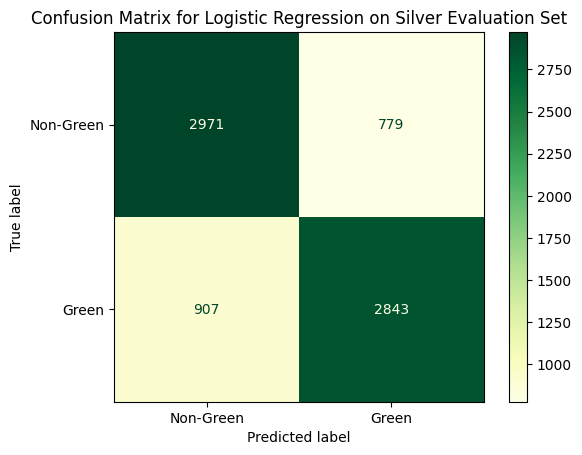

In [19]:
# Visualization of the evaluation results
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_eval, y_eval_pred)
print(cm)

display = ConfusionMatrixDisplay(confusion_matrix = cm,display_labels = ["Non-Green","Green"])
display.plot(cmap = 'YlGn')

plt.title("Confusion Matrix for Logistic Regression on Silver Evaluation Set")
plt.show()

***Explanation:***
Class 0 represents non-green patents, and class 1 represents green patents.

Class 0 (Non-Green):

Precision (0.7661): Of all patents predicted as non-green, 76.61% were actually non-green.

Recall (0.7923): The model correctly identified 79.23% of all actual non-green patents, meaning some non-green patents were misclassified as green.

F1-score (0.7790): Indicates a good balance between precision and recall for this class.

Class 1 (Green):

Precision (0.7849): Of all patents predicted as green, 78.49% were actually green.

Recall (0.7581): The model correctly identified 75.81% of all actual green patents, meaning some green patents were misclassified as non-green.

F1-score (0.7713): Shows balanced performance for green patents.

Overall Performance:

The model achieved an overall accuracy of 77.52% on the evaluation set.

### Part B: Identify High-Risk Examples (Uncertainty Sampling)
We compute p_green for each example in the pool using predict_proba.

Then we compute uncertainty:

u = 1 - 2 * |p - 0.5|

This makes uncertainty highest when p is near 0.5, meaning the model is unsure.

In [20]:
# Compute p_green for all examples in pool_unlabeled.
p_green = classifier.predict_proba(X_pool_unlabeled_embeddings)[:,1]
p_green

array([0.0783336 , 0.8315389 , 0.16030604, ..., 0.40938823, 0.17965242,
       0.03031904])

In [21]:
# Compute u for each example, select the top 100 highest-u rows.
u = 1-2*np.abs(p_green-0.5)
u

array([0.15666721, 0.33692219, 0.32061208, ..., 0.81877645, 0.35930483,
       0.06063808])

In [22]:
X_pool_unlabeled = X_pool_unlabeled.copy()
X_pool_unlabeled['p_green'] = p_green
X_pool_unlabeled['u'] = u
X_pool_unlabeled.head()

,doc_id,date,text,p_green,u
0,8472817,2013-06-25,"1. An image forming apparatus, comprising: at ...",0.078334,0.156667
1,9745853,2017-08-29,1. A turbine rotor blade comprising: a leading...,0.831539,0.336922
2,9748322,2017-08-29,"1. A flexible display, comprising: a substanti...",0.160306,0.320612
3,8554414,2013-10-08,1. A rollover suppression control apparatus co...,0.219560,0.439120
4,9238689,2016-01-19,"1. An isolated antigen-binding moiety, wherein...",0.057422,0.114844


In [23]:
top_100 = X_pool_unlabeled.sort_values('u', ascending=False).head(100)
top_100.head()

,doc_id,date,text,p_green,u
986,9566758,2017-02-14,1. A product comprising a set of discrete unit...,0.499990,0.999980
4395,9218151,2015-12-22,1. An information processing device comprising...,0.499924,0.999849
2228,9175412,2015-11-03,1. A method of manufacturing a barcode nanowir...,0.500336,0.999328
2973,9558960,2017-01-31,1. A substrate processing method comprising: a...,0.499618,0.999236
2186,9465396,2016-10-11,"1. An integrated circuit (IC), comprising: an ...",0.500515,0.998970


In [24]:
top_100["label_human"] = ""
top_100["notes"] = ""
top_100.head()

,doc_id,date,text,p_green,u,label_human,notes
986,9566758,2017-02-14,1. A product comprising a set of discrete unit...,0.499990,0.999980,,
4395,9218151,2015-12-22,1. An information processing device comprising...,0.499924,0.999849,,
2228,9175412,2015-11-03,1. A method of manufacturing a barcode nanowir...,0.500336,0.999328,,
2973,9558960,2017-01-31,1. A substrate processing method comprising: a...,0.499618,0.999236,,
2186,9465396,2016-10-11,"1. An integrated circuit (IC), comprising: an ...",0.500515,0.998970,,


In [25]:
hitl_green_100 = top_100.copy()
hitl_green_100.head()

,doc_id,date,text,p_green,u,label_human,notes
986,9566758,2017-02-14,1. A product comprising a set of discrete unit...,0.499990,0.999980,,
4395,9218151,2015-12-22,1. An information processing device comprising...,0.499924,0.999849,,
2228,9175412,2015-11-03,1. A method of manufacturing a barcode nanowir...,0.500336,0.999328,,
2973,9558960,2017-01-31,1. A substrate processing method comprising: a...,0.499618,0.999236,,
2186,9465396,2016-10-11,"1. An integrated circuit (IC), comprising: an ...",0.500515,0.998970,,


In [27]:
hitl_green_100.shape

(100, 7)

In [26]:
hitl_green_100.to_csv("hitl_green_100.csv", index=False)

### Part C: The Unified Advanced Architecture

Step 1: Domain Adaptation (QLoRA)

In [11]:
import pandas as pd
import numpy as np

In [3]:
# Load train eval pool data
X_train_silver_embeddings = np.load("data/X_train_silver_embeddings.npy")
X_eval_silver_embeddings  = np.load("data/X_eval_silver_embeddings.npy")
X_pool_unlabeled_embeddings  = np.load("data/X_pool_unlabeled_embeddings.npy")

# Load labels
y_train_silver = np.load("data/y_train.npy")
y_eval  = np.load("data/y_eval.npy")
y_pool_unlabeled = np.load("data/y_pool.npy")

# Load metadata (important for Part B)
X_train_silver = pd.read_csv("data/train_meta.csv")
X_eval_silver  = pd.read_csv("data/eval_meta.csv")
X_pool_unlabeled  = pd.read_csv("data/pool_meta.csv")

In [4]:
print(X_train_silver.shape)
print(X_eval_silver.shape)
print(X_pool_unlabeled.shape)
print(y_train_silver.shape)
print(y_eval.shape)
print(y_pool_unlabeled.shape)
print(X_train_silver_embeddings.shape)
print(X_eval_silver_embeddings.shape)
print(X_pool_unlabeled_embeddings.shape)

(35000, 3)
(7500, 3)
(7500, 3)
(35000,)
(7500,)
(7500,)
(35000, 768)
(7500, 768)
(7500, 768)


In [5]:
X_train_silver.head()

,doc_id,date,text
0,9057357,2015-06-16,1. A wind turbine comprising: a first ring com...
1,8709670,2014-04-29,1. A vehicle comprising: a fuel cell system co...
2,9698720,2017-07-04,"1. An electrical drive system, comprising: an ..."
3,9828531,2017-11-28,1. An adhesive composition comprising a contin...
4,9028842,2015-05-12,1. A composition suitable for injection into a...


In [ ]:
# Load the Mistral-7B-v0.2 model and tokenizer
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
import torch
import torch.nn as nn
import bitsandbytes as bnb
from transformers import AutoTokenizer, AutoConfig, AutoModelForCausalLM
model_name = "mistralai/Mistral-7B-Instruct-v0.2"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    load_in_8bit=True,
    device_map='auto',
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
# Fix for Mistral padding
tokenizer.pad_token = tokenizer.eos_token

In [ ]:
# Post-processing for the model
for param in model.parameters():
  param.requires_grad = False  # freeze the model - train adapters later
  if param.ndim == 1:
    # cast the small parameters (e.g. layernorm) to fp32 for stability
    param.data = param.data.to(torch.float32)

model.gradient_checkpointing_enable()  # reduce number of stored activations
model.enable_input_require_grads()

class CastOutputToFloat(nn.Sequential):
  def forward(self, x): return super().forward(x).to(torch.float32)
model.lm_head = CastOutputToFloat(model.lm_head)

In [ ]:
#Apply LoRA to the model
def print_trainable_parameters(model):
    """
    Prints the number of trainable parameters in the model.
    """
    trainable_params = 0
    all_param = 0
    for _, param in model.named_parameters():
        all_param += param.numel()
        if param.requires_grad:
            trainable_params += param.numel()
    print(
        f"trainable params: {trainable_params} || all params: {all_param} || trainable%: {100 * trainable_params / all_param}"
    )

In [ ]:
from peft import LoraConfig, get_peft_model

config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

model = get_peft_model(model, config)
print_trainable_parameters(model)

In [6]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=512
    )

In [ ]:
import transformers
from datasets import load_dataset
from datasets import Dataset

data = pd.read_csv("data/train_meta.csv")
dataset = Dataset.from_pandas(data)
dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=dataset.column_names
)

In [ ]:

trainer = transformers.Trainer(
    model=model,
    train_dataset=dataset,
    args=transformers.TrainingArguments(
        per_device_train_batch_size=4,
        gradient_accumulation_steps=4,
        warmup_steps=10,
        max_steps=50,
        learning_rate=2e-4,
        fp16=True,
        logging_steps=1,
        output_dir='outputs'
    ),
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)
model.config.use_cache = False  # silence the warnings. Please re-enable for inference!
trainer.train()

In [ ]:
# Save LoRA adapter
model.save_pretrained("mistral_qlora_adapter")

# Save tokenizer
tokenizer.save_pretrained("mistral_qlora_adapter")

Step 2: Multi-Agent System (MAS)

In [ ]:
# ============================================================
# PART 1: ADVOCATE GENERATION (AI LAB)
# ============================================================

import os
import torch
import pandas as pd
from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline
from peft import PeftModel
from tqdm import tqdm

# ============================================================
# 0. PATHS AND MODEL CONFIG
# ============================================================

BASE_MODEL = "mistralai/Mistral-7B-Instruct-v0.2"
ADAPTER_PATH = "mistral_qlora_adapter"

INPUT_CSV = "data/hitl_green_100.csv"   # Your 100 high-risk claims
OUTPUT_CSV = "advocate_output.csv"

# ============================================================
# 1. LOAD QLORA MODEL
# ============================================================

print("Loading QLoRA model...")
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL)
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    device_map="auto",
    torch_dtype=torch.float16
)
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)

pipe = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    temperature=0.5,
    do_sample=True
)

print("✅ QLoRA model ready")

# ============================================================
# 2. LOAD CLAIMS
# ============================================================

df = pd.read_csv(INPUT_CSV)
claims = df["text"].tolist()
doc_ids = df["doc_id"].tolist()

# ============================================================
# 3. GENERATE ADVOCATE ARGUMENTS
# ============================================================

advocate_args = []

for doc_id, claim in tqdm(zip(doc_ids, claims), total=len(claims), desc="Generating Advocate"):
    prompt = f"""
CLAIM:
{claim}

Argue why this patent contributes to climate change mitigation (Y02 class).
Focus on renewable energy, efficiency, emissions reduction, or other green technologies.
"""
    output = pipe(prompt, max_new_tokens=512, do_sample=True, temperature=0.5)
    text = output[0]["generated_text"].strip()
    advocate_args.append({"doc_id": doc_id, "text": claim, "advocate_argument": text})

# ============================================================
# 4. SAVE ADVOCATE OUTPUT
# ============================================================

df_advocate = pd.DataFrame(advocate_args)
df_advocate.to_csv(OUTPUT_CSV, index=False)
print(f"✅ Advocate arguments saved to {OUTPUT_CSV}")

In [14]:
df = pd.read_csv('advocate_output.csv')
df.head()

,doc_id,text,advocate_argument
0,9566758,1. A product comprising a set of discrete unit...,CLAIM:\n1. A product comprising a set of discr...
1,9218151,1. An information processing device comprising...,CLAIM:\n1. An information processing device co...
2,9175412,1. A method of manufacturing a barcode nanowir...,CLAIM:\n1. A method of manufacturing a barcode...
3,9558960,1. A substrate processing method comprising: a...,CLAIM:\n1. A substrate processing method compr...
4,9465396,"1. An integrated circuit (IC), comprising: an ...","CLAIM:\n1. An integrated circuit (IC), compris..."


In [15]:
import pandas as pd

# Load your Advocate CSV
df = pd.read_csv("advocate_output.csv")

# Show all doc_ids with their Advocate argument
for idx, row in df.iterrows():
    print(f"\n--- Doc ID: {row['doc_id']} ---")
    print("Advocate Argument:")
    print(row['advocate_argument'])


--- Doc ID: 9566758 ---
Advocate Argument:
CLAIM:
1. A product comprising a set of discrete units, the set of discrete units being reversibly assembled, or reversibly assemblable, into a structure, wherein: the units in the set are reversibly assembled, or are reversibly assemblable, into the structure according to a lattice geometry, wherein the units, when assembled according to the lattice geometry, together comprise a stretch-bend coupled material; a majority of the discrete units are each reversibly connected, or are reversibly connectable, to at least two other units in the set according to the lattice geometry; and wherein, in response to greater than minimal loading of the structure, a reversible deformation of at least part of the structure occurs.

Argue why this patent contributes to climate change mitigation (Y02 class).
Focus on renewable energy, efficiency, emissions reduction, or other green technologies.

This patent claim describes a product that contributes to climat

In [16]:
def clean_advocate_text(text):
    """
    Remove the CLAIM header and instructions so only the advocate argument remains.
    Assumes the actual argument starts after two consecutive newlines.
    """
    # Split by double newlines, take the last part (the argument)
    parts = text.split("\n\n")
    if len(parts) > 1:
        # Take everything after the instructions
        argument = "\n\n".join(parts[1:])
    else:
        argument = text
    # Optional: remove extra leading/trailing whitespace
    argument = argument.strip()
    return argument

# Apply cleaning
df["advocate_argument_clean"] = df["advocate_argument"].apply(clean_advocate_text)

# Save cleaned CSV (optional)
df.to_csv("advocate_cleaned.csv", index=False)

# Preview
for i in range(3):
    print(f"\n--- Doc ID: {df.loc[i, 'doc_id']} ---")
    print(df.loc[i, "advocate_argument_clean"])


--- Doc ID: 9566758 ---
Argue why this patent contributes to climate change mitigation (Y02 class).
Focus on renewable energy, efficiency, emissions reduction, or other green technologies.

This patent claim describes a product that contributes to climate change mitigation by enabling the production of a stretch-bend coupled material that is reversibly assembled from a set of discrete units according to a lattice geometry. The product is a stretch-bend coupled material that is reversibly assembled from a set of discrete units according to a lattice geometry, wherein the units in the set are reversibly assembled, or are reversibly assemblable, into the structure according to the lattice geometry, wherein the units, when assembled according to the lattice geometry, together comprise a stretch-bend coupled material, wherein a majority of the discrete units are each reversibly connected, or are reversibly connectable, to at least two other units in the set according to the lattice geometr

In [17]:
import re
def clean_advocate_argument(text):
    """
    Remove instructions and CLAIM header so only the argument remains.
    """
    if not isinstance(text, str):
        return text

    # Remove the instruction lines
    # Matches lines starting with "Argue why" or "Focus on"
    text = re.sub(r"(Argue why.*\nFocus on.*\n)", "", text, flags=re.IGNORECASE)

    # Optional: Remove "CLAIM:" and any first line that starts with number + dot
    text = re.sub(r"^CLAIM:\n\d+\..*\n", "", text)

    # Strip extra whitespace
    text = text.strip()
    return text

# Apply cleaning
df["advocate_argument_clean"] = df["advocate_argument"].apply(clean_advocate_argument)

# Save cleaned CSV
df.to_csv("advocate_cleaned.csv", index=False)

# Preview first few cleaned arguments
for i in range(3):
    print(f"\n--- Doc ID: {df.loc[i, 'doc_id']} ---")
    print(df.loc[i, "advocate_argument_clean"])


--- Doc ID: 9566758 ---
This patent claim describes a product that contributes to climate change mitigation by enabling the production of a stretch-bend coupled material that is reversibly assembled from a set of discrete units according to a lattice geometry. The product is a stretch-bend coupled material that is reversibly assembled from a set of discrete units according to a lattice geometry, wherein the units in the set are reversibly assembled, or are reversibly assemblable, into the structure according to the lattice geometry, wherein the units, when assembled according to the lattice geometry, together comprise a stretch-bend coupled material, wherein a majority of the discrete units are each reversibly connected, or are reversibly connectable, to at least two other units in the set according to the lattice geometry, and wherein, in response to greater than minimal loading of the structure, a reversible deformation of at least part of the structure occurs. This product is descr

In [18]:
df = pd.read_csv('advocate_cleaned.csv')
df.head()

,doc_id,text,advocate_argument,advocate_argument_clean
0,9566758,1. A product comprising a set of discrete unit...,CLAIM:\n1. A product comprising a set of discr...,This patent claim describes a product that con...
1,9218151,1. An information processing device comprising...,CLAIM:\n1. An information processing device co...,This patent claim does not describe a technolo...
2,9175412,1. A method of manufacturing a barcode nanowir...,CLAIM:\n1. A method of manufacturing a barcode...,This patent claim does not describe a technolo...
3,9558960,1. A substrate processing method comprising: a...,CLAIM:\n1. A substrate processing method compr...,This patent claim does not contribute to clima...
4,9465396,"1. An integrated circuit (IC), comprising: an ...","CLAIM:\n1. An integrated circuit (IC), compris...",This patent claim does not contribute to clima...


In [23]:
from crewai import Agent, Crew, Task, LLM
from textwrap import dedent

# Skeptic Agent
skeptic = Agent(
    role="Greenwashing Skeptic",
    goal="Critically argue why the text may NOT qualify under Y02.",
    backstory="Specialist in identifying greenwashing and exaggerated claims.",
    llm=LLM(model="ollama/qwen2.5:7b-instruct", base_url="http://localhost:11434", temperature=0.5),
    verbose=False
)

# Judge Agent
judge = Agent(
    role="Environmental Policy Judge",
    goal="Evaluate both arguments and produce a final structured JSON output.",
    backstory="Neutral evaluator with expertise in climate policy classification.",
    llm=LLM(model="ollama/qwen2.5:7b-instruct", base_url="http://localhost:11434", temperature=0.1),
    verbose=False
)


In [24]:
def build_tasks(text, advocate_argument_clean):
    """
    Create Skeptic + Judge tasks for a single claim
    """

    task_skeptic = Task(
        description=dedent(f"""
            Analyze the following claim and argue why it may NOT qualify
            under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.

            CLAIM:
            {text}

            ADVOCATE ARGUMENT:
            {advocate_argument_clean}

            Step-by-step reasoning:
            1. Identify claims made by the company.
            2. Check for weak evidence or overstatements.
            3. Explain why it might fail Y02 criteria.
            4. Provide a clear counter-argument.
        """),
        expected_output="Step-by-step counter-argument.",
        agent=skeptic
    )

    task_judge = Task(
        description=dedent(f"""
            Evaluate the claim carefully using both advocate and skeptic arguments.

            CLAIM:
            {text}

            ADVOCATE ARGUMENT:
            {advocate_argument_clean}

            SKEPTIC ARGUMENT:
            {{skeptic_output_here}}

            Step-by-step reasoning:
            1. Summarize advocate's argument.
            2. Summarize skeptic's argument.
            3. Compare strengths and weaknesses.
            4. Decide if the text qualifies under Y02 (green climate mitigation technology).
            5. Assign label = 1 if it qualifies, 0 if it does NOT.
            6. Estimate confidence between 0 and 1.
            7. Provide a short rationale.

            Output STRICT JSON ONLY:
            {{
              "label": 0 or 1,
              "confidence": 0.0-1.0,
              "rationale": "short explanation"
            }}
        """),
        expected_output="Final JSON decision with numeric label.",
        agent=judge
    )

    return [task_skeptic, task_judge]

In [28]:
def run_debate(text, advocate_argument):
    tasks = build_tasks(text, advocate_argument)  # pass advocate argument to build_tasks

    crew = Crew(
        agents=[skeptic, judge],  # only include agents that are actually in tasks
        tasks=tasks,
        process="sequential",
        verbose=False
    )

    result = crew.kickoff()
    return result

In [29]:
# Sample input text for testing
sample_text = """
A company develops a carbon capture system that reduces CO2 emissions
from cement factories by 35% using advanced membrane filtration.
"""

# You also need the advocate argument (cleaned) for the Skeptic task
advocate_argument_clean = """
This patent claim describes a technology that contributes to climate change mitigation 
by capturing CO2 from cement factories using advanced membrane filtration, 
potentially improving efficiency and reducing emissions.
"""

# Run the debate
output = run_debate(sample_text, advocate_argument_clean)

print("FINAL OUTPUT:")
print(output)

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Analyze the following claim and argue why it may NOT qualify                                       │
│              under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.        │
│                                                                                                                 │
│              CLAIM:                                                                                             │
│                                                                                                                 │
│  A company develops a carbon capture system that reduces CO2 emissions                                          │
│  from cement factories by 35% using advanced membrane filtration.                                               │
│                                                                                                                 │
│                                                                                                                 │
│              ADVOCATE ARGUMENT:                                                                                 │
│                                                                                                                 │
│  This patent claim describes a technology that contributes to climate change mitigation                         │
│  by capturing CO2 from cement factories using advanced membrane filtration,                                     │
│  potentially improving efficiency and reducing emissions.                                                       │
│                                                                                                                 │
│                                                                                                                 │
│              Step-by-step reasoning:                                                                            │
│              1. Identify claims made by the company.                                                            │
│              2. Check for weak evidence or overstatements.                                                      │
│              3. Explain why it might fail Y02 criteria.                                                         │
│              4. Provide a clear counter-argument.                                                               │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument:                                                                             │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company**:                                                                    │
│     - The company claims to have developed a carbon capture system that reduces CO2 emissions from cement       │
│  factories by 35% using advanced membrane filtration.                                                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements**:                                                              │
│     - **Lack of Specific Data**: The claim does not provide any specific data or studies to support the 35%     │
│  reduction in CO2 emissions. Without empirical evidence or references to peer-reviewed studies, the claim       │
│  appears unsubstantiated.                                                                                       │
│     - **Scope of Application**: The claim does not specify the scale of the technology's application or the     │
│  number of cement factories that will adopt it. Without this information, it's difficult to assess the overall  │
│  impact on climate change mitigation.                                                                           │
│     - **Membrane Filtration Technology**: While "advanced membrane filtration" sounds promising, the claim      │
│  does not elaborate on the technology's efficiency, cost, or potential limitations. Membrane technology can be  │
│  complex, and its effectiveness can vary significantly depending on the specific conditions of the cement       │
│  factories.                                                                                                     │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria**:                                                                 │
│     - **Y02 Criteria**: Y02 specifically focuses on climate change mitigation technologies that are proven and  │
│  have a measurable impact. The claim lacks the necessary evidence to meet these criteria. It does not provide   │
│  any details on the technology's performance, operational costs, or the environmental benefits beyond the       │
│  claimed 35% reduction.                                                                                         │
│     - **Greenwashing Concerns**: The use of vague and potentially misleading terms like "advanced" without      │
│  clear definitions or standards can be seen as an attempt to greenwash the technology. This could mislead       │
│  stakeholders into believing the technology is more advanced and effective than it actually is.                 │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument**:                                                                       │
│     - **Lack of Verification**: The claim fails to provide any third-party verification or validation of the    │
│  35% reduction in CO2 emissions. Without such verificat

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Evaluate the claim carefully using both advocate and skeptic arguments.                            │
│                                                                                                                 │
│              CLAIM:                                                                                             │
│                                                                                                                 │
│  A company develops a carbon capture system that reduces CO2 emissions                                          │
│  from cement factories by 35% using advanced membrane filtration.                                               │
│                                                                                                                 │
│                                                                                                                 │
│              ADVOCATE ARGUMENT:                                                                                 │
│                                                                                                                 │
│  This patent claim describes a technology that contributes to climate change mitigation                         │
│  by capturing CO2 from cement factories using advanced membrane filtration,                                     │
│  potentially improving efficiency and reducing emissions.                                                       │
│                                                                                                                 │
│                                                                                                                 │
│              SKEPTIC ARGUMENT:                                                                                  │
│              {skeptic_output_here}                                                                              │
│                                                                                                                 │
│              Step-by-step reasoning:                                                                            │
│              1. Summarize advocate's argument.                                                                  │
│              2. Summarize skeptic's argument.                                                                   │
│              3. Compare strengths and weaknesses.                                                               │
│              4. Decide if the text qualifies under Y02 (green climate mitigation technology).                   │
│              5. Assign label = 1 if it qualifies, 0 if it does NOT.                                             │
│              6. Estimate confidence between 0 and 1.                                                            │
│              7. Provide a short rationale.                                                                      │
│                                                                                                                 │
│              Output STRICT JSON ONLY:                                                                           │
│              {                                                                                                  │
│                "label": 0 or 1,                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim lacks specific data, third-party verification, and clear metrics to substantiate     │
│  the 35% reduction in CO2 emissions. The use of vague terms and the absence of long-term data further weaken    │
│  the argument. These factors make it difficult to meet the Y02 criteria for climate change mitigation           │
│  technologies."                                                                                                 │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

FINAL OUTPUT:
```json
{
  "label": 0,
  "confidence": 0.8,
  "rationale": "The claim lacks specific data, third-party verification, and clear metrics to substantiate the 35% reduction in CO2 emissions. The use of vague terms and the absence of long-term data further weaken the argument. These factors make it difficult to meet the Y02 criteria for climate change mitigation technologies."
}
```


In [ ]:
UTPUT_CSV = "mas_final_output.csv"   # MAS output
HITL_CSV = "hitl_review.csv"          # low-confidence claims
SKEPTIC_TEMP = 0.5
JUDGE_TEMP = 0.1
CONFIDENCE_THRESHOLD = 0.85 

df = pd.read_csv('advocate_cleaned.csv')

import re
import json
from tqdm import tqdm

# Initialize lists
pred_label = []
pred_confidence = []
pred_rationale = []

pbar = tqdm(df.iterrows(), total=len(df), desc="Classifying claims")

for idx, row in pbar:
    claim = row["text"]
    advocate_arg = row["advocate_argument_clean"]

    try:
        output = run_debate(claim, advocate_arg)
        output_str = str(output)

        # Extract JSON inside ```json ... ``` or after "Final Output:"
        match = re.search(r"```json\s*(\{.*?\})\s*```", output_str, re.DOTALL)
        if not match:
            match = re.search(r"Final Output:\s*(\{.*\})", output_str, re.DOTALL)

        if match:
            json_str = match.group(1)
            result = json.loads(json_str)
            pred_label.append(result.get("label", 0))
            pred_confidence.append(result.get("confidence", 0.0))
            pred_rationale.append(result.get("rationale", ""))
        else:
            # fallback if JSON not found
            pred_label.append(None)
            pred_confidence.append(None)
            pred_rationale.append(None)
            print(f"⚠️ JSON not found for row {idx}")

        pbar.set_postfix(Green=pred_label.count(1), Non_Green=pred_label.count(0))

    except Exception as e:
        print(f"Error processing row {idx}: {e}")
        pred_label.append(None)
        pred_confidence.append(None)
        pred_rationale.append(None)

# Save results
df["llm_label"] = pred_label
df["llm_confidence"] = pred_confidence
df["llm_rationale"] = pred_rationale
df.to_csv(OUTPUT_CSV, index=False)

# HITL filter
df_hitl = df[df["llm_confidence"] < CONFIDENCE_THRESHOLD]
df_hitl.to_csv(HITL_CSV, index=False)

print(f"✅ MAS output saved: {OUTPUT_CSV}")
print(f"✅ HITL review required for {len(df_hitl)} claims: {HITL_CSV}")

Classifying claims:   0%|          | 0/100 [00:00<?, ?it/s]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A product comprising a set of discrete units, the set of discrete units being reversibly assembled, or      │
│  reversibly assemblable, into a structure, wherein: the units in the set are reversibly assembled, or are       │
│  reversibly assemblable, into the structure according to a lattice geometry, wherein the units, when assembled  │
│  according to the lattice geometry, together comprise a stretch-bend coupled material; a majority of the        │
│  discrete units are each reversibly connected, or are reversibly connectable, to at least two other units in    │
│  the set according to the lattice geometry; and wherein, in response to greater than minimal loading of the     │
│  structure, a reversible deformation of at least part of the structure occurs.                                  │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a product that contributes to climate change mitigation by enabling the            │
│  production of a stretch-bend coupled material that is reversibly assembled from a set of discrete units        │
│  according to a lattice geometry. The product is a stretch-bend coupled material that is reversibly assembled   │
│  from a set of discrete units according to a lattice geometry, wherein the units in the set are reversibly      │
│  assembled, or are reversibly assemblable, into the structure according to the lattice geometry, wherein the    │
│  units, when assembled according to the lattice geometry, together comprise a stretch-bend coupled material,    │
│  wherein a majority of the discrete units are each reversibly connected, or are reversibly connectable, to at   │
│  least two other units in the set according to the lattice geometry, and wherein, in response to greater than   │
│  minimal loading of the structure, a reversible deformation of at least part of the structure occurs. This      │
│  product is described as being a stretch-bend coupled material, which is a type of material that is capable of  │
│  undergoing reversible deformation in response to loading, and is therefore a material that is suitable for     │
│  use in energy storage or energy conversion applications. The product is also described as being reversibly     │
│  assembled, or reversibly assemblable, into the structure according to the lattice geometry, which suggests     │
│  that the product is a modular material that is capable of being assembled into a structure in a reversible     │
│  manner. The product is further described as being a stretch-bend coupled material that is reversibly           │
│  assembled from a set of discrete units according to a lattice geometry, wherein the units in the set are       │
│  reversibly assembled, or are reversibly assemblable, i

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The product is a stretch-bend coupled material that is reversibly assembled from a set of discrete units  │
│  according to a lattice geometry.                                                                               │
│     - The material is capable of undergoing reversible deformation in response to loading.                      │
│     - The material is suitable for use in energy storage or energy conversion applications.                     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Description:** The description does not provide specific details about the material's           │
│  properties, such as its mechanical strength, flexibility, or durability.                                       │
│     - **Lack of Performance Data:** There is no mention of the energy density, cycle life, or efficiency of     │
│  the material in storage or conversion applications.                                                            │
│     - **No Specific Applications:** The claim does not specify any particular applications or industries where  │
│  the material would be used.                                                                                    │
│     - **No Validation or Verification:** There is no third-party verification or validation of the material's   │
│  performance.                                                                                                   │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that are proven and have measurable impacts on climate      │
│  change mitigation. The claim does not provide any empirical evidence or validation of the material's           │
│  effectiveness in reducing greenhouse gas emissions or improving energy efficiency.                             │
│     - **Greenwashing Concerns:** The generic nature of the claim and the lack of specific performance data can  │
│  be seen as an attempt to greenwash the technology. Stakeholders might be misled into believing the material    │
│  has significant climate benefits without sufficient evidence.                                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Lack of Specific Applications:** The claim does not specify any particular applications or industries   │
│  where the material would be used. For instance, the material might be suitable for energy storage, but the     │
│  claim does not provide any details on its performance 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A product comprising a set of discrete units, the set of discrete units being reversibly assembled, or      │
│  reversibly assemblable, into a structure, wherein: the units in the set are reversibly assembled, or are       │
│  reversibly assemblable, into the structure according to a lattice geometry, wherein the units, when assembled  │
│  according to the lattice geometry, together comprise a stretch-bend coupled material; a majority of the        │
│  discrete units are each reversibly connected, or are reversibly connectable, to at least two other units in    │
│  the set according to the lattice geometry; and wherein, in response to greater than minimal loading of the     │
│  structure, a reversible deformation of at least part of the structure occurs.                                  │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a product that contributes to climate change mitigation by enabling the            │
│  production of a stretch-bend coupled material that is reversibly assembled from a set of discrete units        │
│  according to a lattice geometry. The product is a stretch-bend coupled material that is reversibly assembled   │
│  from a set of discrete units according to a lattice geometry, wherein the units in the set are reversibly      │
│  assembled, or are reversibly assemblable, into the structure according to the lattice geometry, wherein the    │
│  units, when assembled according to the lattice geometry, together comprise a stretch-bend coupled material,    │
│  wherein a majority of the discrete units are each reversibly connected, or are reversibly connectable, to at   │
│  least two other units in the set according to the lattice geometry, and wherein, in response to greater than   │
│  minimal loading of the structure, a reversible deformation of at least part of the structure occurs. This      │
│  product is described as being a stretch-bend coupled material, which is a type of material that is capable of  │
│  undergoing reversible deformation in response to loading, and is therefore a material that is suitable for     │
│  use in energy storage or energy conversion applications. The product is also described as being reversibly     │
│  assembled, or reversibly assemblable, into the structure according to the lattice geometry, which suggests     │
│  that the product is a modular material that is capable of being assembled into a structure in a reversible     │
│  manner. The product is further described as being a stretch-bend coupled material that is reversibly           │
│  assembled from a set of discrete units according to a lattice geometry, wherein the units in the set are       │
│  reversibly assembled, or are reversibly assemblable, into the structure according to the lattice geometry,     │
│  wherein the units, when assembled according to the lat

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim lacks specific applications, performance data, and verification of the material's    │
│  effectiveness in climate change mitigation. The generic description and lack of concrete examples or case      │
│  studies make it difficult to assess the material's potential impact. These factors fail to meet the Y02        │
│  criteria for climate change mitigation technologies."                                                          │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:   1%|          | 1/100 [02:31<4:10:46, 151.98s/it, Green=0, Non_Green=1]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An information processing device comprising: a resource information acquisition unit that acquires first    │
│  resource information and second resource information, a controller unit that performs control to generate a    │
│  screen on which an operation to execute the image processing is accepted in accordance with a resource         │
│  corresponding to the second resource information among the resources included in the first resource            │
│  information, wherein the first resource information comprises resources required to execute the predetermined  │
│  image processing, and wherein the controller unit performs the control to generate the screen when all the     │
│  required resources of the first resource information are included in the second resource information acquired  │
│  from the image processing device.                                                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes an information processing device that includes a resource information acquisition     │
│  unit and a controller unit.                                                                                    │
│     - The resource information acquisition unit acquires first and second resource information.                 │
│     - The controller unit generates a screen for accepting an operation to execute image processing based on    │
│  the resources included in the second resource information.                                                     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim describes a generic process of acquiring and processing resource     │
│  information to generate a screen for image processing operations. There are no specific details about the      │
│  environmental impact or climate change mitigation benefits of this functionality.                              │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to climate change mitigation. It focuses on the operational aspects of an information processing device.       │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the device's ability to reduce greenhouse gas emissions,      │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a generic information processing device that does not have any    │
│  specific environmental benefits. It does not provide any details on how the device contributes to reducing     │
│  carbon emissions, improving energy efficiency, or addressing other climate change issues.                      │
│     - **No Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution to     │
│  climate change mitigation. It focuses on the operational aspects of the device, such as resource acquisition   │
│  and screen generation, without any reference to enviro

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An information processing device comprising: a resource information acquisition unit that acquires first    │
│  resource information and second resource information, a controller unit that performs control to generate a    │
│  screen on which an operation to execute the image processing is accepted in accordance with a resource         │
│  corresponding to the second resource information among the resources included in the first resource            │
│  information, wherein the first resource information comprises resources required to execute the predetermined  │
│  image processing, and wherein the controller unit performs the control to generate the screen when all the     │
│  required resources of the first resource information are included in the second resource information acquired  │
│  from the image processing device.                                                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a generic information processing device without any specific               │
│  environmental benefits or climate change mitigation impacts. It focuses on operational aspects such as         │
│  resource acquisition and screen generation, which do not contribute to reducing carbon emissions or improving  │
│  energy efficiency. Therefore, it fails to meet the Y02 criteria for climate change mitigation technologies."   │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:   2%|▏         | 2/100 [04:59<4:04:19, 149.59s/it, Green=0, Non_Green=2]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of manufacturing a barcode nanowire having a superior biocompatibility, the method comprising the  │
│  steps of: preparing a nanotemplate having a pore and representing insulating property; disposing the           │
│  nanotemplate in an electrolytic solution including a first precursor for generating an iron ion and a second   │
│  precursor for generating a gold ion; and performing an electro-deposition to alternately and repeatedly form   │
│  an iron layer and a gold layer in the pore, wherein the electro-deposition step galvanostaticaly controls how  │
│  iron ions and gold ions deposit into the pore, the electro-deposition step including a first step of forming   │
│  the iron layer by applying a first current and a second step of forming the gold layer by applying a second    │
│  current, the second has a current density lower than a current density of the first current, and the first     │
│  and second steps are alternately and repeatedly performed until the nanowire has a required length, wherein    │
│  the density of the first current is in a range of from 10 mA/cm wherein a molarity ratio of an iron to a gold  │
│  ion is within a range of 4:1 to 40:1 in the electrolytic solution.                                             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method of manufacturing a barcode nanowire with superior biocompatibility.          │
│     - The method involves preparing a nanotemplate, disposing it in an electrolytic solution, and performing    │
│  an electro-deposition to form alternating iron and gold layers.                                                │
│     - The electro-deposition step is galvanostatically controlled, with different current densities for iron    │
│  and gold layers, and the process is repeated until the nanowire reaches the required length.                   │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Process:** The claim describes a specific manufacturing process for a nanowire but does not     │
│  provide information on the environmental impact or climate change mitigation benefits of the nanowire itself.  │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to climate change mitigation. It focuses on the production method and properties of the nanowire.              │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the nanowire's ability to reduce greenhouse gas emissions,    │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a manufacturing process for a nanowire with superior              │
│  biocompatibility but does not provide any specific details on how this nanowire contributes to reducing        │
│  carbon emissions, improving energy efficiency, or addressing other climate change issues.                      │
│     - **No Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution to     │
│  climate change mitigation. It focuses on the production method and properties of the nanowire, without any     │
│  reference to environmental or climate-related benefits.                                                        │
│     - **Lack of Verification:** There is no third-party

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of manufacturing a barcode nanowire having a superior biocompatibility, the method comprising the  │
│  steps of: preparing a nanotemplate having a pore and representing insulating property; disposing the           │
│  nanotemplate in an electrolytic solution including a first precursor for generating an iron ion and a second   │
│  precursor for generating a gold ion; and performing an electro-deposition to alternately and repeatedly form   │
│  an iron layer and a gold layer in the pore, wherein the electro-deposition step galvanostaticaly controls how  │
│  iron ions and gold ions deposit into the pore, the electro-deposition step including a first step of forming   │
│  the iron layer by applying a first current and a second step of forming the gold layer by applying a second    │
│  current, the second has a current density lower than a current density of the first current, and the first     │
│  and second steps are alternately and repeatedly performed until the nanowire has a required length, wherein    │
│  the density of the first current is in a range of from 10 mA/cm wherein a molarity ratio of an iron to a gold  │
│  ion is within a range of 4:1 to 40:1 in the electrolytic solution.                                             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a method for manufacturing a barcode nanowire with superior                │
│  biocompatibility but does not provide any specific environmental benefits or climate change mitigation         │
│  impacts. It focuses on the production process and properties of the nanowire without addressing any direct     │
│  contribution to reducing carbon emissions or improving energy efficiency. Therefore, it fails to meet the Y02  │
│  criteria for climate change mitigation technologies."                                                          │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:   3%|▎         | 3/100 [07:15<3:51:18, 143.07s/it, Green=0, Non_Green=3]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A substrate processing method comprising: a coating step that applies a coating liquid to a substrate       │
│  having a front surface on which a pattern is formed, thereby forming a coating film on the substrate; a film   │
│  removing step that heats the substrate to gasify components of the coating film thereby to reduce a thickness  │
│  of the film; and a film curing step that is performed after or simultaneously with the film removing step and  │
│  that heats the substrate to cure the coating film through crosslinking reaction, wherein the film removing     │
│  step is performed under conditions ensuring that an average thickness of the cured coating film is not         │
│  greater than 80% of an average thickness of the coating film before being subjected to the film removing       │
│  step.                                                                                                          │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a substrate processing method involving three steps: coating, film removing, and      │
│  film curing.                                                                                                   │
│     - The coating step applies a coating liquid to a substrate with a patterned front surface.                  │
│     - The film removing step heats the substrate to gasify components of the coating film, thereby reducing     │
│  its thickness.                                                                                                 │
│     - The film curing step heats the substrate to cure the coating film through a crosslinking reaction,        │
│  performed after or simultaneously with the film removing step.                                                 │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Process:** The claim describes a specific manufacturing process for a coating film but does     │
│  not provide information on the environmental impact or climate change mitigation benefits of the film itself.  │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to climate change mitigation. It focuses on the production method and properties of the coating film.          │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the coating film's ability to reduce greenhouse gas           │
│  emissions, improve energy efficiency, or contribute to other climate-related goals.                            │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a manufacturing process for a coating film but does not provide   │
│  any specific details on how this film contributes to reducing carbon emissions, improving energy efficiency,   │
│  or addressing other climate change issues.                                                                     │
│     - **No Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution to     │
│  climate change mitigation. It focuses on the productio

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A substrate processing method comprising: a coating step that applies a coating liquid to a substrate       │
│  having a front surface on which a pattern is formed, thereby forming a coating film on the substrate; a film   │
│  removing step that heats the substrate to gasify components of the coating film thereby to reduce a thickness  │
│  of the film; and a film curing step that is performed after or simultaneously with the film removing step and  │
│  that heats the substrate to cure the coating film through crosslinking reaction, wherein the film removing     │
│  step is performed under conditions ensuring that an average thickness of the cured coating film is not         │
│  greater than 80% of an average thickness of the coating film before being subjected to the film removing       │
│  step.                                                                                                          │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a substrate processing method involving coating, film removing, and film   │
│  curing steps but does not provide any specific environmental benefits or climate change mitigation impacts.    │
│  It focuses on the production process and properties of the coating film without addressing any direct          │
│  contribution to reducing carbon emissions or improving energy efficiency. Therefore, it fails to meet the Y02  │
│  criteria for climate change mitigation technologies."                                                          │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:   4%|▍         | 4/100 [09:44<3:53:06, 145.70s/it, Green=0, Non_Green=4]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An integrated circuit (IC), comprising: an input interface configured to receive an input signal providing  │
│  information for controlling a supply voltage based on a performance characteristic of another IC; and a        │
│  controller configured to generate an output signal for controlling the supply voltage based on a combination   │
│  of the input signal and a performance characteristic of the IC, the controller including a feedback voltage    │
│  generator configured to generate a feedback voltage signal by combining an offset voltage with the supply      │
│  voltage to control a voltage regulator to regulate the supply voltage to the IC and to the other IC.           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes an integrated circuit (IC) with specific components: an input interface, a            │
│  controller, and a feedback voltage generator.                                                                  │
│     - The input interface receives an input signal for controlling a supply voltage based on the performance    │
│  characteristic of another IC.                                                                                  │
│     - The controller generates an output signal for controlling the supply voltage based on the input signal    │
│  and the performance characteristic of the IC.                                                                  │
│     - The feedback voltage generator combines an offset voltage with the supply voltage to control a voltage    │
│  regulator, which regulates the supply voltage to both the IC and another IC.                                   │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim describes the functionality of an IC but does not provide            │
│  information on the environmental impact or climate change mitigation benefits of the IC itself.                │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to climate change mitigation. It focuses on the operational characteristics and control mechanisms of the IC.  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the IC's ability to reduce greenhouse gas emissions, improve  │
│  energy efficiency, or contribute to other climate-related goals.                                               │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes the functionality of an IC but does not provide any specific      │
│  details on how this IC contributes to reducing carbon emissions, improving energy efficiency, or addressing    │
│  other climate change issues.                                                                                   │
│     - **No Direct Climate Impact:** The claim does not 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An integrated circuit (IC), comprising: an input interface configured to receive an input signal providing  │
│  information for controlling a supply voltage based on a performance characteristic of another IC; and a        │
│  controller configured to generate an output signal for controlling the supply voltage based on a combination   │
│  of the input signal and a performance characteristic of the IC, the controller including a feedback voltage    │
│  generator configured to generate a feedback voltage signal by combining an offset voltage with the supply      │
│  voltage to control a voltage regulator to regulate the supply voltage to the IC and to the other IC.           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes an integrated circuit (IC) with specific components and functionality but  │
│  does not provide any specific environmental benefits or climate change mitigation impacts. It focuses on the   │
│  operational characteristics and control mechanisms of the IC without addressing any direct contribution to     │
│  reducing carbon emissions or improving energy efficiency. Therefore, it fails to meet the Y02 criteria for     │
│  climate change mitigation technologies."                                                                       │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:   5%|▌         | 5/100 [12:15<3:53:17, 147.35s/it, Green=0, Non_Green=5]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus for measuring water content and salt concentration in a multiphase fluid flow in a subsea      │
│  installation for petroleum production, the apparatus comprising: a capacitive sensor located in a pipe         │
│  section through which the multiphase fluid flow passes; a signal generator connected to the capacitive         │
│  sensor; a first measuring transducer for measuring a voltage across the capacitive sensor; a second measuring  │
│  transducer for measuring a current through the capacitive sensor; and an output circuit for generating first   │
│  and second output signals indicative of the salt concentration and water content, respectively, in the         │
│  multiphase fluid flow based on signals emitted by the first and second measuring transducers; wherein the      │
│  output circuit is configured to determine a phase difference between the signals emitted by the first and      │
│  second measuring transducers and generate the first output signal based on said phase difference.              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes an apparatus for measuring water content and salt concentration in a multiphase       │
│  fluid flow in a subsea installation for petroleum production.                                                  │
│     - Key components include:                                                                                   │
│       - A capacitive sensor located in a pipe section through which the multiphase fluid flow passes.           │
│       - A signal generator connected to the capacitive sensor.                                                  │
│       - A first measuring transducer for measuring a voltage across the capacitive sensor.                      │
│       - A second measuring transducer for measuring a current through the capacitive sensor.                    │
│       - An output circuit for generating first and second output signals indicative of the salt concentration   │
│  and water content, respectively, based on signals emitted by the first and second measuring transducers.       │
│       - The output circuit is configured to determine a phase difference between the signals emitted by the     │
│  first and second measuring transducers and generate the first output signal based on said phase difference.    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim describes a measurement apparatus but does not provide information   │
│  on the environmental impact or climate change mitigation benefits of the apparatus itself.                     │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to climate change mitigation. It focuses on the operational characteristics and measurement capabilities of    │
│  the apparatus.                                                                                                 │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the apparatus's ability to reduce greenhouse gas emissions,   │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**              

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus for measuring water content and salt concentration in a multiphase fluid flow in a subsea      │
│  installation for petroleum production, the apparatus comprising: a capacitive sensor located in a pipe         │
│  section through which the multiphase fluid flow passes; a signal generator connected to the capacitive         │
│  sensor; a first measuring transducer for measuring a voltage across the capacitive sensor; a second measuring  │
│  transducer for measuring a current through the capacitive sensor; and an output circuit for generating first   │
│  and second output signals indicative of the salt concentration and water content, respectively, in the         │
│  multiphase fluid flow based on signals emitted by the first and second measuring transducers; wherein the      │
│  output circuit is configured to determine a phase difference between the signals emitted by the first and      │
│  second measuring transducers and generate the first output signal based on said phase difference.              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes an apparatus for measuring water content and salt concentration in a       │
│  multiphase fluid flow but does not provide any specific environmental benefits or climate change mitigation    │
│  impacts. It focuses on the operational characteristics and measurement capabilities of the apparatus without   │
│  addressing any direct contribution to reducing carbon emissions or improving energy efficiency. Therefore, it  │
│  fails to meet the Y02 criteria for climate change mitigation technologies."                                    │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:   6%|▌         | 6/100 [14:51<3:55:28, 150.30s/it, Green=0, Non_Green=6]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A portable shelter which is erectable on a support surface for defining an interior for temporarily         │
│  sheltering a human, the portable shelter comprising: a front wall having when erected an upper end, a lower    │
│  end, and a height extending between the upper and lower ends of the front wall, and a left end, a right end,   │
│  and a width extending between the left and right ends of the front wall, the front wall including folds        │
│  extending along generally parallel fold lines which extend along the height of the front wall and are spaced   │
│  from each other between the left and right ends of the front wall, the folds including outboard folds and      │
│  inboard folds, the outboard folds of the front wall being disposed outward of the inboard folds of the front   │
│  wall in the erected shelter; a rear wall having when erected an upper end, a lower end, and a height           │
│  extending between the upper and lower ends of the rear wall, and a left end, a right end, and a width          │
│  extending between the left and right ends of the rear wall, the rear wall including folds extending along      │
│  generally parallel fold lines which extend along the height of the rear wall and are spaced from each other    │
│  between the left and right ends of the rear wall, the folds including outboard folds and inboard folds, the    │
│  outboard folds of the rear wall being disposed outward of the inboard folds of the rear wall in the erected    │
│  shelter; and a top wall having when erected a front end, a rear end, and a length extending between the front  │
│  and rear ends of the top wall, and a left end, a right end, and a width extending between the left and right   │
│  ends of the top wall, the front end of the top wall being connected to the upper end of the front wall and     │
│  the rear end of the top wall being connected to the upper end of the rear wall so the length of the top wall   │
│  extends between the front and rear walls, the top wall including folds extending along generally parallel      │
│  fold lines which extend along the length of the top wall and are spaced from each other between the left and   │
│  right ends of the top wall, the folds including outboard folds and inboard folds, the outboard folds of the    │
│  top wall being disposed outward of the inboard folds of the top wall in the erected shelter; wherein the       │
│  front wall includes a generally planar portion having an opening sized for a person to enter the interior of   │
│  the shelter through the opening and at least one of each of the inboard and outboard folds of the front wall   │
│  is positioned to the left of the opening and at least one of each of the inboard and outboard folds of the     │
│  front wall is positioned to the right of the opening when the portable shelter is erected; and wherein the     │
│  generally planar portion is oriented in a front plane 

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a portable shelter that can be erected on a support surface for temporarily           │
│  sheltering a human.                                                                                            │
│     - Key components include:                                                                                   │
│       - A front wall with folds extending along the height and spaced between the left and right ends.          │
│       - A rear wall with folds extending along the height and spaced between the left and right ends.           │
│       - A top wall with folds extending along the length and spaced between the left and right ends.            │
│       - The front wall includes a generally planar portion with an opening for entry and fold panels extending  │
│  between consecutive folds.                                                                                     │
│       - The folds are positioned such that the outboard folds are outward of the inboard folds.                 │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim describes the structure and components of a portable shelter but     │
│  does not provide any information on the environmental impact or climate change mitigation benefits of the      │
│  shelter itself.                                                                                                │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to climate change mitigation. It focuses on the structural design and functionality of the shelter.            │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the shelter's ability to reduce greenhouse gas emissions,     │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a portable shelter but does not provide any specific details on   │
│  how this shelter contributes to reducing carbon emissi

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A portable shelter which is erectable on a support surface for defining an interior for temporarily         │
│  sheltering a human, the portable shelter comprising: a front wall having when erected an upper end, a lower    │
│  end, and a height extending between the upper and lower ends of the front wall, and a left end, a right end,   │
│  and a width extending between the left and right ends of the front wall, the front wall including folds        │
│  extending along generally parallel fold lines which extend along the height of the front wall and are spaced   │
│  from each other between the left and right ends of the front wall, the folds including outboard folds and      │
│  inboard folds, the outboard folds of the front wall being disposed outward of the inboard folds of the front   │
│  wall in the erected shelter; a rear wall having when erected an upper end, a lower end, and a height           │
│  extending between the upper and lower ends of the rear wall, and a left end, a right end, and a width          │
│  extending between the left and right ends of the rear wall, the rear wall including folds extending along      │
│  generally parallel fold lines which extend along the height of the rear wall and are spaced from each other    │
│  between the left and right ends of the rear wall, the folds including outboard folds and inboard folds, the    │
│  outboard folds of the rear wall being disposed outward of the inboard folds of the rear wall in the erected    │
│  shelter; and a top wall having when erected a front end, a rear end, and a length extending between the front  │
│  and rear ends of the top wall, and a left end, a right end, and a width extending between the left and right   │
│  ends of the top wall, the front end of the top wall being connected to the upper end of the front wall and     │
│  the rear end of the top wall being connected to the upper end of the rear wall so the length of the top wall   │
│  extends between the front and rear walls, the top wall including folds extending along generally parallel      │
│  fold lines which extend along the length of the top wall and are spaced from each other between the left and   │
│  right ends of the top wall, the folds including outboard folds and inboard folds, the outboard folds of the    │
│  top wall being disposed outward of the inboard folds of the top wall in the erected shelter; wherein the       │
│  front wall includes a generally planar portion having an opening sized for a person to enter the interior of   │
│  the shelter through the opening and at least one of each of the inboard and outboard folds of the front wall   │
│  is positioned to the left of the opening and at least one of each of the inboard and outboard folds of the     │
│  front wall is positioned to the right of the opening when the portable shelter is erected; and wherein the     │
│  generally planar portion is oriented in a front plane in the erected shelter and fold panels extend between    │
│  consecutive ones of said at least one of each of the i

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a portable shelter but does not provide any specific environmental         │
│  benefits or climate change mitigation impacts. It focuses on the structural design and functionality of the    │
│  shelter without addressing any direct contribution to reducing carbon emissions or improving energy            │
│  efficiency. Therefore, it fails to meet the Y02 criteria for climate change mitigation technologies."          │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:   7%|▋         | 7/100 [17:31<3:57:57, 153.52s/it, Green=0, Non_Green=7]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of fabricating a three-dimensional object from digital data representing the object, the method    │
│  comprising: providing a first layer of particulate material; consolidating at least a first portion of the     │
│  first layer of particulate material to form a consolidated first cross-section of the object; applying a       │
│  first portion of conductive material to the consolidated first cross-section; applying a second layer of       │
│  particulate material to the consolidated first cross-section of the first layer; and consolidating at least a  │
│  second portion of the second layer of particulate material to form a consolidated second cross-section of the  │
│  object.                                                                                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method of fabricating a three-dimensional object from digital data.                 │
│     - Key steps include:                                                                                        │
│       - Providing a first layer of particulate material.                                                        │
│       - Consolidating at least a first portion of the first layer to form a consolidated first cross-section.   │
│       - Applying a first portion of conductive material to the consolidated first cross-section.                │
│       - Applying a second layer of particulate material to the consolidated first cross-section.                │
│       - Consolidating at least a second portion of the second layer to form a consolidated second               │
│  cross-section.                                                                                                 │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim describes a method for 3D printing, but does not provide any         │
│  information on the environmental impact or climate change mitigation benefits of the method itself.            │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to climate change mitigation. It focuses on the process of layer-by-layer fabrication and material             │
│  consolidation.                                                                                                 │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the method's ability to reduce greenhouse gas emissions,      │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a method of 3D printing but does not provide any specific         │
│  details on how this method contributes to reducing carbon emissions, improving energy efficiency, or           │
│  addressing other climate change issues.               

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of fabricating a three-dimensional object from digital data representing the object, the method    │
│  comprising: providing a first layer of particulate material; consolidating at least a first portion of the     │
│  first layer of particulate material to form a consolidated first cross-section of the object; applying a       │
│  first portion of conductive material to the consolidated first cross-section; applying a second layer of       │
│  particulate material to the consolidated first cross-section of the first layer; and consolidating at least a  │
│  second portion of the second layer of particulate material to form a consolidated second cross-section of the  │
│  object.                                                                                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a method of fabricating a three-dimensional object but does not provide    │
│  any specific environmental benefits or climate change mitigation impacts. It focuses on the process of         │
│  layer-by-layer fabrication and material consolidation without addressing any direct contribution to reducing   │
│  carbon emissions or improving energy efficiency. Therefore, it fails to meet the Y02 criteria for climate      │
│  change mitigation technologies."                                                                               │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:   8%|▊         | 8/100 [20:11<3:58:22, 155.46s/it, Green=0, Non_Green=8]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A MEMS sensor comprising: a substrate; a MEMS structure coupled to the substrate and having a mass movable  │
│  with respect to the substrate; and a reference structure electrically coupled to the movable mass of the MEMS  │
│  structure, wherein the MEMS structure is radially outward from the reference structure.                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a MEMS (Micro-Electro-Mechanical System) sensor.                                      │
│     - Key components include:                                                                                   │
│       - A substrate.                                                                                            │
│       - A MEMS structure coupled to the substrate and having a mass movable with respect to the substrate.      │
│       - A reference structure electrically coupled to the movable mass of the MEMS structure.                   │
│       - The MEMS structure is radially outward from the reference structure.                                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim describes a specific type of MEMS sensor but does not provide any    │
│  information on the environmental impact or climate change mitigation benefits of the sensor itself.            │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to climate change mitigation. It focuses on the structural design and functionality of the sensor.             │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the sensor's ability to reduce greenhouse gas emissions,      │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a MEMS sensor but does not provide any specific details on how    │
│  this sensor contributes to reducing carbon emissions, improving energy efficiency, or addressing other         │
│  climate change issues.                                                                                         │
│     - **No Direct Climate Impact:** The claim focuses on the structural design and functionality of the         │
│  sensor, without any reference to environmental or climate-related benefits.                                    │
│     - **Lack of Verification:** There is no third-party

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A MEMS sensor comprising: a substrate; a MEMS structure coupled to the substrate and having a mass movable  │
│  with respect to the substrate; and a reference structure electrically coupled to the movable mass of the MEMS  │
│  structure, wherein the MEMS structure is radially outward from the reference structure.                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a MEMS sensor but does not provide any specific environmental benefits or  │
│  climate change mitigation impacts. It focuses on the structural design and functionality of the sensor         │
│  without addressing any direct contribution to reducing carbon emissions or improving energy efficiency.        │
│  Therefore, it fails to meet the Y02 criteria for climate change mitigation technologies."                      │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:   9%|▉         | 9/100 [23:06<4:05:15, 161.71s/it, Green=0, Non_Green=9]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A zeolite structure comprising: a zeolite material containing a plurality of zeolite particles and an       │
│  inorganic binding material which binds the zeolite particles to one another, wherein the plurality of zeolite  │
│  particles exhibits a bimodal particle size distribution having a first peak due to fine zeolite particles and  │
│  a second peak due to coarse zeolite particles, the average particle diameter of the first peak is from 0.1 to  │
│  30 μm, the average particle diameter of the second peak is from 3 to 1,000 times that of the first peak, and   │
│  a ratio of a volume of coarse zeolite particles with respect to the whole volume of the plurality of zeolite   │
│  particles is from 40 90 vol %, and in the zeolite material, a ratio of a volume of the inorganic binding       │
│  material with respect to the whole volume of the zeolite material is from 5 to 50 vol %, wherein a zeolite     │
│  raw material containing the plurality of zeolite particles and the inorganic binding material is extruded to   │
│  form a zeolite formed body which is then fired to obtain the zeolite structure.                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a zeolite structure comprising a zeolite material containing a plurality of        │
│  zeolite particles and an inorganic binding material which binds the zeolite particles to one another. The      │
│  zeolite material exhibits a bimodal particle size distribution having a first peak due to fine zeolite         │
│  particles and a second peak due to coarse zeolite particles. The average particle diameter of the first peak   │
│  is from 0.1 to 30 μm, the average particle diameter of the second peak is from 3 to 1,000 times that of the    │
│  first peak, and a ratio of a volume of coarse zeolite particles with respect to the whole volume of the        │
│  plurality of zeolite particles is from 40 to 90 vol %. In the zeolite material, a ratio of a volume of the     │
│  inorganic binding material with respect to the whole volume of the zeolite material is from 5 to 50 vol %.     │
│  The zeolite raw material containing the plurality of zeolite particles and the inorganic binding material is   │
│  extruded to form a zeolite formed body which is then fired to obtain the zeolite structure. This zeolite       │
│  structure is not described as contributing to climate change mitigation. However, it is described as having a  │
│  bimodal particle size distribution, which is a characteristic of some zeolites used in carbon capture and      │
│  storage (CCS) applications. Therefore, it is possible that this zeolite structure may be used in CCS           │
│  applications, and thus contribute to climate change mi

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a zeolite structure with specific characteristics, including a bimodal particle size  │
│  distribution and an inorganic binding material. The structure is formed by extruding a zeolite raw material    │
│  and then firing it to obtain the final zeolite structure.                                                      │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the structural and compositional characteristics of the   │
│  zeolite structure but does not provide any specific information on its intended use or applications.           │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to climate change mitigation. While the structure might be used in carbon capture and storage (CCS)            │
│  applications, this is not confirmed in the claim itself.                                                       │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the zeolite structure's ability to reduce greenhouse gas      │
│  emissions, improve energy efficiency, or contribute to other climate-related goals.                            │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│  The bimodal particle size distribution and the use of an inorganic binding material are characteristics of     │
│  the structure but do not inherently imply a direct contribution to climate change mitigation.                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a zeolite structure with specific characteristics but does not    │
│  provide any specific details on its intended use or applications in climate change mitigation. The bimodal     │
│  particle size distribution and the use of an inorganic binding material are characteristics that could be      │
│  relevant to various applications, including CCS, but this is not explicitly stated.                            │
│     - **No Direct Climate Impact:** The claim focuses on the structural and compositional characteristics of    │
│  the zeolite structure, without any reference to enviro

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A zeolite structure comprising: a zeolite material containing a plurality of zeolite particles and an       │
│  inorganic binding material which binds the zeolite particles to one another, wherein the plurality of zeolite  │
│  particles exhibits a bimodal particle size distribution having a first peak due to fine zeolite particles and  │
│  a second peak due to coarse zeolite particles, the average particle diameter of the first peak is from 0.1 to  │
│  30 μm, the average particle diameter of the second peak is from 3 to 1,000 times that of the first peak, and   │
│  a ratio of a volume of coarse zeolite particles with respect to the whole volume of the plurality of zeolite   │
│  particles is from 40 90 vol %, and in the zeolite material, a ratio of a volume of the inorganic binding       │
│  material with respect to the whole volume of the zeolite material is from 5 to 50 vol %, wherein a zeolite     │
│  raw material containing the plurality of zeolite particles and the inorganic binding material is extruded to   │
│  form a zeolite formed body which is then fired to obtain the zeolite structure.                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a zeolite structure comprising a zeolite material containing a plurality of        │
│  zeolite particles and an inorganic binding material which binds the zeolite particles to one another. The      │
│  zeolite material exhibits a bimodal particle size distribution having a first peak due to fine zeolite         │
│  particles and a second peak due to coarse zeolite particles. The average particle diameter of the first peak   │
│  is from 0.1 to 30 μm, the average particle diameter of the second peak is from 3 to 1,000 times that of the    │
│  first peak, and a ratio of a volume of coarse zeolite particles with respect to the whole volume of the        │
│  plurality of zeolite particles is from 40 to 90 vol %. In the zeolite material, a ratio of a volume of the     │
│  inorganic binding material with respect to the whole volume of the zeolite material is from 5 to 50 vol %.     │
│  The zeolite raw material containing the plurality of zeolite particles and the inorganic binding material is   │
│  extruded to form a zeolite formed body which is then fired to obtain the zeolite structure. This zeolite       │
│  structure is not described as contributing to climate change mitigation. However, it is described as having a  │
│  bimodal particle size distribution, which is a characteristic of some zeolites used in carbon capture and      │
│  storage (CCS) applications. Therefore, it is possible that this zeolite structure may be used in CCS           │
│  applications, and thus contribute to climate change mitigation. However, without further information, it is    │
│  not possible to determine whether this zeolite structu

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a zeolite structure with specific characteristics, including a bimodal     │
│  particle size distribution and an inorganic binding material. While the structure might be used in carbon      │
│  capture and storage (CCS) applications, which could contribute to climate change mitigation, the claim itself  │
│  does not explicitly state or confirm this use. The bimodal particle size distribution and the use of an        │
│  inorganic binding material are characteristics that could be relevant to various applications, but the claim   │
│  does not provide any specific information on its intended use or applications in climate change mitigation.    │
│  Therefore, it is not possible to conclude that this zeolite structure is specifically designed or used for     │
│  climate change mitigation. The claim fails to provide sufficient evidence to meet the Y02 criteria for         │
│  climate change mitigation technologies."                                                                       │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  10%|█         | 10/100 [26:20<4:17:19, 171.55s/it, Green=0, Non_Green=10]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A portable electronic device having a housing, comprising: a global navigation satellite system receiver    │
│  that produces satellite location data from received satellite signals; an accelerometer in the housing that    │
│  detects movement of the portable electronic device and that produces corresponding accelerometer signals;      │
│  wherein the accelerometer comprises at least one vibrating element; a sensor with a magnetic element that      │
│  measures how the portable electronic device is oriented with respect to the Earth's magnetic field and that    │
│  produces corresponding compass signals; and processing circuitry in the housing that computes where the        │
│  portable electronic device is geographically located based on the satellite location data, the accelerometer   │
│  signals, and the compass signals, wherein the processing circuitry in the portable electronic device uses at   │
│  least the compass signals to compute a geographic location of the portable electronic device and wherein the   │
│  processing circuitry in the portable electronic device uses the compass signals at least to compute a heading  │
│  change of the portable electronic device.                                                                      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a portable electronic device with specific components, including a global navigation  │
│  satellite system (GNSS) receiver, an accelerometer, a sensor with a magnetic element (compass), and            │
│  processing circuitry. The device uses these components to compute the geographic location and heading change   │
│  of the portable electronic device.                                                                             │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim describes the basic functionality of the device in terms of its      │
│  components and their interactions but does not explicitly state any environmental benefits or applications     │
│  related to climate change mitigation.                                                                          │
│     - **Lack of Direct Climate Impact:** The claim does not mention any direct contribution to reducing         │
│  greenhouse gas emissions, improving energy efficiency, or addressing other climate-related goals.              │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the device's ability to reduce greenhouse gas emissions,      │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│  The device's functionality is centered around location and heading computation, which are not inherently       │
│  related to climate change mitigation.                                                                          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a portable electronic device with standard components used for    │
│  location and orientation computation. While such devices might be used in applications that contribute to      │
│  climate change mitigation (e.g., tracking emissions, optimizing routes to reduce fuel consumption), this is    │
│  not explicitly stated or implied in the claim itself.                                                          │
│     - **No Direct Climate Impact:** The claim focuses o

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A portable electronic device having a housing, comprising: a global navigation satellite system receiver    │
│  that produces satellite location data from received satellite signals; an accelerometer in the housing that    │
│  detects movement of the portable electronic device and that produces corresponding accelerometer signals;      │
│  wherein the accelerometer comprises at least one vibrating element; a sensor with a magnetic element that      │
│  measures how the portable electronic device is oriented with respect to the Earth's magnetic field and that    │
│  produces corresponding compass signals; and processing circuitry in the housing that computes where the        │
│  portable electronic device is geographically located based on the satellite location data, the accelerometer   │
│  signals, and the compass signals, wherein the processing circuitry in the portable electronic device uses at   │
│  least the compass signals to compute a geographic location of the portable electronic device and wherein the   │
│  processing circuitry in the portable electronic device uses the compass signals at least to compute a heading  │
│  change of the portable electronic device.                                                                      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a portable electronic device with specific components, including a GNSS    │
│  receiver, an accelerometer, and a compass sensor. While these components can be used in applications that      │
│  contribute to climate change mitigation, such as tracking emissions or optimizing routes, the claim itself     │
│  does not explicitly state or confirm these uses. The device's primary functionality is to compute geographic   │
│  location and heading, which does not inherently address climate change mitigation. Therefore, it is not        │
│  possible to conclude that this portable electronic device is specifically designed or used for climate change  │
│  mitigation. The claim fails to provide sufficient evidence to meet the Y02 criteria for climate change         │
│  mitigation technologies."                                                                                      │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  11%|█         | 11/100 [29:19<4:17:51, 173.84s/it, Green=0, Non_Green=11]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for separating electronic components, comprising the processing steps of: A) placing an assembly   │
│  of electronic components on a manipulator, the assembly comprising a first substrate layer, a second           │
│  component layer on the first substrate layer, and an outer conductive layer on the second component layer, B)  │
│  transporting the electronic components with the manipulator relative to a first cutting tool and cutting to a  │
│  first cutting depth of at least 10% or more of a thickness of the first and second layers of the assembly      │
│  with the first cutting tool along first cutting lines such that the assembly is only partially cut through     │
│  the thickness thereof to obtain a partially severed assembly of electronic components, C) transporting the     │
│  partially severed assembly of electronic components with the manipulator relative to a second cutting tool     │
│  and further cutting through the thickness of first and second layers of the partially severed assembly of      │
│  electronic components to a second cutting depth along second cutting lines which overlap the first cutting     │
│  lines so that the electronic components are at least substantially severed almost completely one from          │
│  another, and D) separating the substantially severed electronic components along the cutting lines.            │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method for separating electronic components, involving the use of a manipulator     │
│  and cutting tools to partially and then fully sever the components. The process includes placing the assembly  │
│  on a manipulator, partially cutting through the thickness of the layers, and then fully cutting to separate    │
│  the components.                                                                                                │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the technical process of separating electronic            │
│  components but does not provide any specific information on its intended use or applications in climate        │
│  change mitigation.                                                                                             │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to reducing greenhouse gas emissions, improving energy efficiency, or addressing other climate-related goals.  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the method's ability to reduce greenhouse gas emissions,      │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│  The process described is a manufacturing technique for separating electronic components, which is not          │
│  inherently related to climate change mitigation.                                                               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a method for separating electronic components, which is a         │
│  standard manufacturing process. While such processes might be used in applications that contribute to climate  │
│  change mitigation (e.g., reducing waste, optimizing production processes), this is not explicitly stated or    │
│  implied in the claim itself.                                                                                   │
│     - **No Direct Climate Impact:** The claim focuses o

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for separating electronic components, comprising the processing steps of: A) placing an assembly   │
│  of electronic components on a manipulator, the assembly comprising a first substrate layer, a second           │
│  component layer on the first substrate layer, and an outer conductive layer on the second component layer, B)  │
│  transporting the electronic components with the manipulator relative to a first cutting tool and cutting to a  │
│  first cutting depth of at least 10% or more of a thickness of the first and second layers of the assembly      │
│  with the first cutting tool along first cutting lines such that the assembly is only partially cut through     │
│  the thickness thereof to obtain a partially severed assembly of electronic components, C) transporting the     │
│  partially severed assembly of electronic components with the manipulator relative to a second cutting tool     │
│  and further cutting through the thickness of first and second layers of the partially severed assembly of      │
│  electronic components to a second cutting depth along second cutting lines which overlap the first cutting     │
│  lines so that the electronic components are at least substantially severed almost completely one from          │
│  another, and D) separating the substantially severed electronic components along the cutting lines.            │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                         

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a method for separating electronic components, involving the use of a      │
│  manipulator and cutting tools. While this process could be used in applications that contribute to climate     │
│  change mitigation, such as reducing waste or optimizing production, the claim itself does not explicitly       │
│  state or confirm these uses. The method's primary purpose is to separate electronic components, which does     │
│  not inherently address climate change mitigation. Therefore, it is not possible to conclude that this method   │
│  is specifically designed or used for climate change mitigation. The claim fails to provide sufficient          │
│  evidence to meet the Y02 criteria for climate change mitigation technologies."                                 │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  12%|█▏        | 12/100 [32:07<4:12:32, 172.18s/it, Green=0, Non_Green=12]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for the purification of a prostaglandin by supercritical fluid chromatography, said method         │
│  comprising using a stationary phase and a mobile phase comprising carbon dioxide, wherein the stationary       │
│  phase is a non-chiral stationary phase selected from the group consisting of 4 ethyl pyridine, 2-ethyl         │
│  pyridine and pyridine urea or a chiral stationary phase and the prostaglandin is a compound of formula (I), a  │
│  compound of formula (II), or a compound of formula (IV): wherein, V is C; W is X is CONR Y is Z is C R R R R   │
│  Halo is fluorine, chlorine, bromine or iodine.                                                                 │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method for purifying prostaglandins using supercritical fluid chromatography        │
│  (SFC). The method involves using a stationary phase and a mobile phase comprising carbon dioxide, with the     │
│  stationary phase being either non-chiral or chiral, and the prostaglandin being one of several specific        │
│  compounds.                                                                                                     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the technical process of purifying prostaglandins using   │
│  SFC, but does not provide any specific information on its environmental impact or contributions to climate     │
│  change mitigation.                                                                                             │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to reducing greenhouse gas emissions, improving energy efficiency, or addressing other climate-related goals.  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the method's ability to reduce greenhouse gas emissions,      │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│  The process described is a purification technique for prostaglandins, which is not inherently related to       │
│  climate change mitigation.                                                                                     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a method for purifying prostaglandins using SFC, which is a       │
│  standard purification technique. While such processes might be used in applications that contribute to         │
│  climate change mitigation (e.g., reducing waste, optimizing production processes), this is not explicitly      │
│  stated or implied in the claim itself.                                                                         │
│     - **No Direct Climate Impact:** The claim focuses o

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for the purification of a prostaglandin by supercritical fluid chromatography, said method         │
│  comprising using a stationary phase and a mobile phase comprising carbon dioxide, wherein the stationary       │
│  phase is a non-chiral stationary phase selected from the group consisting of 4 ethyl pyridine, 2-ethyl         │
│  pyridine and pyridine urea or a chiral stationary phase and the prostaglandin is a compound of formula (I), a  │
│  compound of formula (II), or a compound of formula (IV): wherein, V is C; W is X is CONR Y is Z is C R R R R   │
│  Halo is fluorine, chlorine, bromine or iodine.                                                                 │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a method for purifying prostaglandins using supercritical fluid            │
│  chromatography (SFC). While this process could potentially be used in applications that contribute to climate  │
│  change mitigation, such as reducing waste or optimizing production, the claim itself does not explicitly       │
│  state or confirm these uses. The method's primary purpose is to purify prostaglandins, which does not          │
│  inherently address climate change mitigation. Therefore, it is not possible to conclude that this method is    │
│  specifically designed or used for climate change mitigation. The claim fails to provide sufficient evidence    │
│  to meet the Y02 criteria for climate change mitigation technologies."                                          │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  13%|█▎        | 13/100 [36:14<4:42:25, 194.77s/it, Green=0, Non_Green=13]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of calculating the quality of a steam mixture comprising the steps of: passing the steam mixture   │
│  from a high pressure region to a low pressure region through a first pressure reducer; heating the steam       │
│  mixture in the low pressure region; measuring both the temperature and pressure of the steam in both the high  │
│  pressure region and the low pressure region; and calculating the quality of the steam mixture from the         │
│  measured temperatures and pressures.                                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method for calculating the quality of a steam mixture. The method involves passing  │
│  the steam mixture from a high pressure region to a low pressure region through a first pressure reducer,       │
│  heating the steam mixture in the low pressure region, and measuring both the temperature and pressure of the   │
│  steam in both regions before calculating the quality of the steam mixture.                                     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the technical process of measuring and calculating the    │
│  quality of a steam mixture, but does not provide any specific information on its environmental impact or       │
│  contributions to climate change mitigation.                                                                    │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to reducing greenhouse gas emissions, improving energy efficiency, or addressing other climate-related goals.  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the method's ability to reduce greenhouse gas emissions,      │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│  The process described is a method for calculating the quality of a steam mixture, which is not inherently      │
│  related to climate change mitigation.                                                                          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a method for calculating the quality of a steam mixture, which    │
│  is a standard process in industrial settings. While such processes might be used in applications that          │
│  contribute to climate change mitigation (e.g., optimizing energy usage, improving efficiency), this is not     │
│  explicitly stated or implied in the claim itself.                                                              │
│     - **No Direct Climate Impact:** The claim focuses o

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of calculating the quality of a steam mixture comprising the steps of: passing the steam mixture   │
│  from a high pressure region to a low pressure region through a first pressure reducer; heating the steam       │
│  mixture in the low pressure region; measuring both the temperature and pressure of the steam in both the high  │
│  pressure region and the low pressure region; and calculating the quality of the steam mixture from the         │
│  measured temperatures and pressures.                                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a method for calculating the quality of a steam mixture. While this        │
│  process could potentially be used in applications that contribute to climate change mitigation, such as        │
│  optimizing energy usage or improving efficiency, the claim itself does not explicitly state or confirm these   │
│  uses. The method's primary purpose is to determine the quality of the steam mixture, which does not            │
│  inherently address climate change mitigation. Therefore, it is not possible to conclude that this method is    │
│  specifically designed or used for climate change mitigation. The claim fails to provide sufficient evidence    │
│  to meet the Y02 criteria for climate change mitigation technologies."                                          │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  14%|█▍        | 14/100 [40:16<4:59:46, 209.15s/it, Green=0, Non_Green=14]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A reusable, multi-purpose bag, comprising: a flexible, resiliently deformable body comprising: wherein at   │
│  least a portion of the anterior panel is bonded to at least a portion of the posterior panel by the second     │
│  material, and wherein the second material comprises a melting point for melting onto the first material at or  │
│  above the second degradation temperature and a hardening point below the second degradation temperature to     │
│  bond the at least portion of the anterior panel and the at least portion of the posterior panel.               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a reusable, multi-purpose bag comprising a flexible, resiliently deformable body   │
│  comprising a first material and a second material, wherein the first material comprises a melting point for    │
│  melting onto the second material at or above a second degradation temperature and a hardening point below the  │
│  second degradation temperature to bond the first material to the second material. The second material          │
│  comprises a melting point for melting onto the first material at or above the second degradation temperature   │
│  and a hardening point below the second degradation temperature to bond the first material to the second        │
│  material. The second material is bonded to the first material to form the flexible, resiliently deformable     │
│  body. The first material comprises a first degradation temperature and the second material comprises a second  │
│  degradation temperature, wherein the first degradation temperature is less than the second degradation         │
│  temperature. The first material is degradable at the first degradation temperature and the second material is  │
│  degradable at the second degradation temperature. The first material comprises a first melting point and the   │
│  second material comprises a second melting point, wherein the first melting point is less than the second      │
│  melting point. The first material is meltable at the first melting point and the second material is meltable   │
│  at the second melting point. The first material is meltable at the first melting point and the second          │
│  material is meltable at the second melting point, wherein the first melting point is at or above the first     │
│  degradation temperature and the second melting point is at or above the second degradation temperature. The    │
│  first material is meltable at the first melting point and the second material is meltable at the second        │
│  melting point, wherein the first melting point is at or above the second degradation temperature and the       │
│  second melting point is at or above the second degrada

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a reusable, multi-purpose bag comprising a flexible, resiliently deformable body.     │
│  The body is made from a first material and a second material, where the first and second materials bond        │
│  together at specific temperatures. The first material degrades at a lower temperature than the second          │
│  material, and both materials are meltable at their respective melting points, which are at or above their      │
│  respective degradation temperatures.                                                                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the technical details of the materials and their bonding  │
│  properties but does not provide any specific information on the environmental impact or contributions to       │
│  climate change mitigation.                                                                                     │
│     - **Lack of Direct Climate Impact:** The claim does not explicitly state or imply any direct contribution   │
│  to reducing greenhouse gas emissions, improving energy efficiency, or addressing other climate-related goals.  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide any information about the method's ability to reduce greenhouse gas emissions,      │
│  improve energy efficiency, or contribute to other climate-related goals.                                       │
│     - **Lack of Specific Environmental Benefits:** The claim does not mention any specific environmental        │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│  The focus is on the material properties and bonding mechanism, which are not inherently related to climate     │
│  change mitigation.                                                                                             │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a reusable, multi-purpose bag with specific material properties   │
│  and bonding mechanisms, which is a standard design in the manufacturing of bags. While such designs might be   │
│  used in applications that contribute to climate change mitigation (e.g., reducing single-use plastic bags,     │
│  improving material recyclability), this is not explici

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A reusable, multi-purpose bag, comprising: a flexible, resiliently deformable body comprising: wherein at   │
│  least a portion of the anterior panel is bonded to at least a portion of the posterior panel by the second     │
│  material, and wherein the second material comprises a melting point for melting onto the first material at or  │
│  above the second degradation temperature and a hardening point below the second degradation temperature to     │
│  bond the at least portion of the anterior panel and the at least portion of the posterior panel.               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a reusable, multi-purpose bag comprising a flexible, resiliently deformable body   │
│  comprising a first material and a second material, wherein the first material comprises a melting point for    │
│  melting onto the second material at or above a second degradation temperature and a hardening point below the  │
│  second degradation temperature to bond the first material to the second material. The second material          │
│  comprises a melting point for melting onto the first material at or above the second degradation temperature   │
│  and a hardening point below the second degradation temperature to bond the first material to the second        │
│  material. The second material is bonded to the first material to form the flexible, resiliently deformable     │
│  body. The first material comprises a first degradation temperature and the second material comprises a second  │
│  degradation temperature, wherein the first degradation temperature is less than the second degradation         │
│  temperature. The first material is degradable at the first degradation temperature and the second material is  │
│  degradable at the second degradation temperature. The first material comprises a first melting point and the   │
│  second material comprises a second melting point, wherein the first melting point is less than the second      │
│  melting point. The first material is meltable at the first melting point and the second material is meltable   │
│  at the second melting point. The first material is meltable at the first melting point and the second          │
│  material is meltable at the second melting point, wherein the first melting point is at or above the first     │
│  degradation temperature and the second melting point is at or above the second degradation temperature. The    │
│  first material is meltable at the first melting point and the second material is meltable at the second        │
│  melting point, wherein the first melting point is at or above the second degradation temperature and the       │
│  second melting point is at or above the second degradation temperature. The first material is meltable at the  │
│  first melting point and the second material is meltabl

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a reusable, multi-purpose bag with specific material properties and        │
│  bonding mechanisms. While such designs might be used in applications that contribute to climate change         │
│  mitigation, such as reducing single-use plastic bags and improving material recyclability, the claim itself    │
│  does not explicitly state or confirm these uses. The method's primary purpose is to create a durable and       │
│  reusable bag, which does not inherently address climate change mitigation. Therefore, it fails to provide      │
│  sufficient evidence to meet the Y02 criteria for climate change mitigation technologies."                      │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  15%|█▌        | 15/100 [43:43<4:55:14, 208.41s/it, Green=0, Non_Green=15]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for implementing Link Aggregation Control Protocol (LACP) standard state machines in a             │
│  distributed system which is divided as a Management Processor (MP), a Routing Processor (RP) and a Network     │
│  Processor (NP) according to functions, comprising: after receiving a message at a physical port on a NP of a   │
│  plurality of NPs, directly transmitting the message to a receive state machine without delivering to an RP -   │
│  active on which a selection state machine operates; triggering the receive state machine, a periodic state     │
│  machine, a multiplexer (MUX) state machine, and a sending state machine to operate in turn, wherein all of     │
│  the receive state machine, the periodic state machine, the MUX state machine, and the sending state machine    │
│  operate on the NP, these four state machines operate taking each physical link as a unit and they only need    │
│  to operate on the NP at which the physical link is located; if there is a change in state machine data of at   │
│  least one of the four state machines on the NP before and after the state machine operates, then               │
│  synchronizing the changed state machine data of the state machine to the RP—active on which the selection      │
│  state machine operates, and then triggering the selection state machine on the RP—active to operate and        │
│  completing processing of the message according to a physical link selection state of the selection state       │
│  machine on the RP—active; so as to reduce the number of the message deliveries between the NP and the          │
│  RP—active since the five state machines are distributed in a way that the receive state machine, the periodic  │
│  state machine, the MUX state machine and the sending state machine operate on the NP and the selection state   │
│  machine operates on the RP—active.                                                                             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                  

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method for implementing Link Aggregation Control Protocol (LACP) standard state     │
│  machines in a distributed system, specifically a Management Processor (MP), a Routing Processor (RP), and a    │
│  Network Processor (NP). The method involves direct message transmission, state machine operations, and         │
│  synchronization between the NP and RP to reduce message deliveries between these processors.                   │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the technical details of implementing LACP state          │
│  machines and message transmission in a distributed system. It does not explicitly mention any environmental    │
│  benefits or contributions to climate change mitigation.                                                        │
│     - **Lack of Direct Climate Impact:** The claim does not directly state or imply any specific environmental  │
│  benefits, such as reducing greenhouse gas emissions, improving energy efficiency, or addressing other          │
│  climate-related goals.                                                                                         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide information about the method's ability to reduce greenhouse gas emissions, improve  │
│  energy efficiency, or contribute to other climate-related goals.                                               │
│     - **Lack of Specific Environmental Benefits:** The claim is primarily concerned with optimizing network     │
│  communication and performance, which are not inherently related to climate change mitigation. There is no      │
│  mention of any environmental benefits or metrics that would indicate a reduction in carbon footprint or other  │
│  climate-related outcomes.                                                                                      │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a method for implementing LACP state machines in a distributed    │
│  system, which is a standard practice in network management. While such optimizations might have indirect       │
│  benefits, the claim does not explicitly state or imply any direct environmental benefits.                      │
│     - **No Direct Climate Impact:** The claim focuses o

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for implementing Link Aggregation Control Protocol (LACP) standard state machines in a             │
│  distributed system which is divided as a Management Processor (MP), a Routing Processor (RP) and a Network     │
│  Processor (NP) according to functions, comprising: after receiving a message at a physical port on a NP of a   │
│  plurality of NPs, directly transmitting the message to a receive state machine without delivering to an RP -   │
│  active on which a selection state machine operates; triggering the receive state machine, a periodic state     │
│  machine, a multiplexer (MUX) state machine, and a sending state machine to operate in turn, wherein all of     │
│  the receive state machine, the periodic state machine, the MUX state machine, and the sending state machine    │
│  operate on the NP, these four state machines operate taking each physical link as a unit and they only need    │
│  to operate on the NP at which the physical link is located; if there is a change in state machine data of at   │
│  least one of the four state machines on the NP before and after the state machine operates, then               │
│  synchronizing the changed state machine data of the state machine to the RP—active on which the selection      │
│  state machine operates, and then triggering the selection state machine on the RP—active to operate and        │
│  completing processing of the message according to a physical link selection state of the selection state       │
│  machine on the RP—active; so as to reduce the number of the message deliveries between the NP and the          │
│  RP—active since the five state machines are distributed in a way that the receive state machine, the periodic  │
│  state machine, the MUX state machine and the sending state machine operate on the NP and the selection state   │
│  machine operates on the RP—active.                                                                             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                      

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a method for implementing Link Aggregation Control Protocol (LACP)         │
│  standard state machines in a distributed system. While such optimizations might have indirect benefits, the    │
│  claim does not explicitly mention any environmental benefits or contributions to climate change mitigation.    │
│  The method's primary focus is on improving network performance and reducing message deliveries, which are not  │
│  directly related to climate change mitigation. Therefore, it fails to provide sufficient evidence to meet the  │
│  Y02 criteria for climate change mitigation technologies."                                                      │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  16%|█▌        | 16/100 [46:39<4:38:24, 198.86s/it, Green=0, Non_Green=16]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light source device, comprising: an excitation light source providing an excitation light; a wavelength   │
│  conversion device located remotely from the excitation light source, including a wavelength conversion         │
│  material for converting the excitation light into a converted light; a light introducing device for directing  │
│  the excitation light onto the wavelength conversion material; and a light collecting device for collecting     │
│  the converted light from the wavelength conversion material, wherein the light collecting device includes a    │
│  first reflecting device for changing a traveling direction of the converted light toward an output port,       │
│  wherein the light introducing device is an area surrounded by the first reflecting device which has different  │
│  transmission and reflection properties than the first reflecting device, the area of the light introducing     │
│  device being different from the output port, wherein an etendue of the light introducing device is less than   │
│  or equal to ¼ of an etendue of the light collecting device.                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a light source device consisting of an excitation light source, a wavelength          │
│  conversion device, a light introducing device, and a light collecting device. The wavelength conversion        │
│  device includes a wavelength conversion material that converts the excitation light into a converted light.    │
│  The light collecting device features a first reflecting device that redirects the converted light toward an    │
│  output port. The light introducing device is an area with different transmission and reflection properties     │
│  compared to the first reflecting device, and its etendue is less than or equal to ¼ of the etendue of the      │
│  light collecting device.                                                                                       │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the technical details of the light source device,         │
│  including the excitation light source, wavelength conversion material, and light introducing and collecting    │
│  devices. It does not explicitly mention any environmental benefits or contributions to climate change          │
│  mitigation.                                                                                                    │
│     - **Lack of Direct Climate Impact:** The claim does not directly state or imply any specific environmental  │
│  benefits, such as reducing greenhouse gas emissions, improving energy efficiency, or addressing other          │
│  climate-related goals.                                                                                         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide information about the method's ability to reduce greenhouse gas emissions, improve  │
│  energy efficiency, or contribute to other climate-related goals.                                               │
│     - **Lack of Specific Environmental Benefits:** The claim is primarily concerned with the design and         │
│  functionality of a light source device, which are not inherently related to climate change mitigation. There   │
│  is no mention of any environmental benefits or metrics that would indicate a reduction in carbon footprint or  │
│  other climate-related outcomes.                                                                                │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**              

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light source device, comprising: an excitation light source providing an excitation light; a wavelength   │
│  conversion device located remotely from the excitation light source, including a wavelength conversion         │
│  material for converting the excitation light into a converted light; a light introducing device for directing  │
│  the excitation light onto the wavelength conversion material; and a light collecting device for collecting     │
│  the converted light from the wavelength conversion material, wherein the light collecting device includes a    │
│  first reflecting device for changing a traveling direction of the converted light toward an output port,       │
│  wherein the light introducing device is an area surrounded by the first reflecting device which has different  │
│  transmission and reflection properties than the first reflecting device, the area of the light introducing     │
│  device being different from the output port, wherein an etendue of the light introducing device is less than   │
│  or equal to ¼ of an etendue of the light collecting device.                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a light source device consisting of an excitation light source, a          │
│  wavelength conversion device, a light introducing device, and a light collecting device. While such designs    │
│  might have indirect benefits, the claim does not explicitly mention any environmental benefits or              │
│  contributions to climate change mitigation. The method's primary focus is on optimizing light transmission     │
│  and conversion, which are not directly related to climate change mitigation. Therefore, it fails to provide    │
│  sufficient evidence to meet the Y02 criteria for climate change mitigation technologies."                      │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  17%|█▋        | 17/100 [49:31<4:23:51, 190.74s/it, Green=0, Non_Green=17]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A computing device-implemented method, comprising: receiving, at the computing device, threads of a         │
│  multithread application associated with a first group; receiving, at the computing device, a thread of a       │
│  second application associated with a second group; identifying, by the computing device and based on           │
│  receiving the threads of the multithread application, the multithread application; and adjusting, by the       │
│  computing device, a memory scheduling scheme for the multithread application based on the identification of    │
│  the multithread application.                                                                                   │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a computing device-implemented method that involves receiving threads of a            │
│  multithread application and a thread of a second application, identifying the multithread application, and     │
│  adjusting the memory scheduling scheme based on this identification.                                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the technical details of managing threads and adjusting   │
│  memory scheduling in a computing device. It does not explicitly mention any environmental benefits or          │
│  contributions to climate change mitigation.                                                                    │
│     - **Lack of Direct Climate Impact:** The claim does not directly state or imply any specific environmental  │
│  benefits, such as reducing greenhouse gas emissions, improving energy efficiency, or addressing other          │
│  climate-related goals.                                                                                         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide information about the method's ability to reduce greenhouse gas emissions, improve  │
│  energy efficiency, or contribute to other climate-related goals.                                               │
│     - **Lack of Specific Environmental Benefits:** The claim is primarily concerned with optimizing memory      │
│  scheduling in a computing environment, which are not inherently related to climate change mitigation. There    │
│  is no mention of any environmental benefits or metrics that would indicate a reduction in carbon footprint or  │
│  other climate-related outcomes.                                                                                │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a method for managing threads and adjusting memory scheduling in  │
│  a computing device, which is a standard practice in software and computing. While such optimizations might     │
│  have indirect benefits, the claim does not explicitly state or imply any direct environmental benefits.        │
│     - **No Direct Climate Impact:** The claim focuses on the technical details of memory management and thread  │
│  handling, which are not directly related to climate ch

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A computing device-implemented method, comprising: receiving, at the computing device, threads of a         │
│  multithread application associated with a first group; receiving, at the computing device, a thread of a       │
│  second application associated with a second group; identifying, by the computing device and based on           │
│  receiving the threads of the multithread application, the multithread application; and adjusting, by the       │
│  computing device, a memory scheduling scheme for the multithread application based on the identification of    │
│  the multithread application.                                                                                   │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a computing device-implemented method for managing threads and adjusting   │
│  memory scheduling. While such optimizations might have indirect benefits, the claim does not explicitly        │
│  mention any environmental benefits or contributions to climate change mitigation. The method's primary focus   │
│  is on improving memory management, which is not directly related to climate change mitigation. Therefore, it   │
│  fails to provide sufficient evidence to meet the Y02 criteria for climate change mitigation technologies."     │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  18%|█▊        | 18/100 [52:30<4:15:48, 187.17s/it, Green=0, Non_Green=18]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for inhibiting gas hydrate formation in downhole fluids comprising: using a downhole fluid         │
│  including: an inhibiting amount of a corrosion system including: where the downhole fluid is selected from     │
│  the group consisting of a drilling fluid, a completion fluid, and a production fluid, where the base fluid     │
│  reduces or inhibits hydrocarbon gas hydrate formation under conditions conducive to hydrocarbon gas hydrate    │
│  formation in the downhole fluid, and where the additives reduce or prevent corrosion by the base fluid.        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method for inhibiting gas hydrate formation in downhole fluids. The method          │
│  involves using a downhole fluid that includes a base fluid and additives. The base fluid and additives are     │
│  chosen to reduce or inhibit hydrocarbon gas hydrate formation under conditions conducive to such formation in  │
│  the downhole fluid. The downhole fluid can be a drilling fluid, a completion fluid, or a production fluid.     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the technical details of using a specific fluid           │
│  composition to inhibit gas hydrate formation. It does not explicitly mention any environmental benefits or     │
│  contributions to climate change mitigation.                                                                    │
│     - **Lack of Direct Climate Impact:** The claim is primarily concerned with preventing gas hydrate           │
│  formation, which is a technical issue in oil and gas operations. There is no direct statement or implication   │
│  of reducing greenhouse gas emissions, improving energy efficiency, or addressing other climate-related goals.  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide information about the method's ability to reduce greenhouse gas emissions, improve  │
│  energy efficiency, or contribute to other climate-related goals.                                               │
│     - **Lack of Specific Environmental Benefits:** The claim is focused on preventing gas hydrate formation,    │
│  which is a technical issue related to oil and gas operations. There is no mention of any environmental         │
│  benefits or metrics that would indicate a reduction in carbon footprint or other climate-related outcomes.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a method for inhibiting gas hydrate formation, which is a         │
│  technical solution in oil and gas operations. While such methods might have some indirect benefits, the claim  │
│  does not explicitly state or imply any direct environmental benefits.                                          │
│     - **No Direct Climate Impact:** The primary purpose of the method is to prevent gas hydrate formation,      │
│  which is a technical issue in oil and gas operations. 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for inhibiting gas hydrate formation in downhole fluids comprising: using a downhole fluid         │
│  including: an inhibiting amount of a corrosion system including: where the downhole fluid is selected from     │
│  the group consisting of a drilling fluid, a completion fluid, and a production fluid, where the base fluid     │
│  reduces or inhibits hydrocarbon gas hydrate formation under conditions conducive to hydrocarbon gas hydrate    │
│  formation in the downhole fluid, and where the additives reduce or prevent corrosion by the base fluid.        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a method for inhibiting gas hydrate formation in downhole fluids. While    │
│  such methods might have some indirect benefits, the claim does not explicitly mention any environmental        │
│  benefits or contributions to climate change mitigation. The primary focus is on preventing gas hydrate         │
│  formation, which is a technical issue in oil and gas operations. Therefore, it fails to provide sufficient     │
│  evidence to meet the Y02 criteria for climate change mitigation technologies."                                 │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  19%|█▉        | 19/100 [55:23<4:06:57, 182.93s/it, Green=0, Non_Green=19]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A system comprising: a plurality of sensors; a first logic unit coupled to an output of at least one        │
│  sensor of the plurality of sensors, the first logic unit estimating user dynamics in response to an output     │
│  signal from the at least one sensor; second logic unit coupled to the first logic unit, the second logic unit  │
│  generating a sampling rate value of a first MEMS sensor in response to an output signal from the first logic   │
│  unit, and wherein the first MEMS sensor comprises a selectable sampling rate and wherein the selectable        │
│  sampling rate is selected in response to the generated sampling rate value.                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a system comprising a plurality of sensors, a first logic unit, and a second logic    │
│  unit. The first logic unit estimates user dynamics based on sensor outputs, and the second logic unit          │
│  generates a sampling rate value for a first MEMS sensor in response to the output from the first logic unit.   │
│  The sampling rate of the MEMS sensor is then selected based on this generated value.                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Generic Functionality:** The claim focuses on the technical details of sensor-based user dynamics       │
│  estimation and adaptive sampling rate control for MEMS sensors. It does not explicitly mention any             │
│  environmental benefits or contributions to climate change mitigation.                                          │
│     - **Lack of Direct Climate Impact:** The claim does not directly state or imply any specific environmental  │
│  benefits, such as reducing greenhouse gas emissions, improving energy efficiency, or addressing other          │
│  climate-related goals.                                                                                         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that have measurable impacts on climate change mitigation.  │
│  The claim does not provide information about the method's ability to reduce greenhouse gas emissions, improve  │
│  energy efficiency, or contribute to other climate-related goals.                                               │
│     - **Lack of Specific Environmental Benefits:** The claim is primarily concerned with optimizing             │
│  sensor-based data collection and processing, which are not inherently related to climate change mitigation.    │
│  There is no mention of any environmental benefits or metrics that would indicate a reduction in carbon         │
│  footprint or other climate-related outcomes.                                                                   │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Generic Nature:** The claim describes a system for adaptive sensor sampling, which is a standard        │
│  approach in sensor network design. While such systems can potentially lead to energy savings, the claim does   │
│  not explicitly state or imply any direct environmental benefits.                                               │
│     - **No Direct Climate Impact:** The primary purpose

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A system comprising: a plurality of sensors; a first logic unit coupled to an output of at least one        │
│  sensor of the plurality of sensors, the first logic unit estimating user dynamics in response to an output     │
│  signal from the at least one sensor; second logic unit coupled to the first logic unit, the second logic unit  │
│  generating a sampling rate value of a first MEMS sensor in response to an output signal from the first logic   │
│  unit, and wherein the first MEMS sensor comprises a selectable sampling rate and wherein the selectable        │
│  sampling rate is selected in response to the generated sampling rate value.                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a system for adaptive sensor sampling, which is a technical solution in    │
│  sensor network design. While such systems can potentially lead to energy savings, the claim does not           │
│  explicitly mention any environmental benefits or contributions to climate change mitigation. Therefore, it     │
│  fails to provide sufficient evidence to meet the Y02 criteria for climate change mitigation technologies."     │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  20%|██        | 20/100 [58:25<4:03:29, 182.62s/it, Green=0, Non_Green=20]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A permanent magnet type rotary electric machine comprising a stator with a stator core and coils provided   │
│  into slots of the stator core, and a rotor that is disposed so as to face the stator with a gap, the rotor     │
│  having a rotor core and permanent magnets buried into the rotor core by being incorporated into permanent      │
│  magnet slots formed at an outer circumferential-side portion of the rotor core so as to be a plurality of      │
│  poles, wherein the permanent magnet slot for each pole is divided at least into four permanent magnet slot     │
│  segments along an outer circumferential direction in the rotor core so that the permanent magnet slot          │
│  segments of all poles are arranged along the outer circumferential direction in a row as a whole while having  │
│  rest core-portions between respective adjacent permanent magnet slot segments, and in the rest core-portions   │
│  between the respective adjacent permanent magnet slot segments in the rotor core, a width of a first rest      │
│  core-portion at a middle of each pole and a width of a second rest core-portion between each pair of adjacent  │
│  poles of different polarities are formed larger than that of the other rest-core portions.                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a permanent magnet type rotary electric machine, which is a type of electric       │
│  machine that converts mechanical energy into electric energy or electric energy into mechanical energy. The    │
│  permanent magnet type rotary electric machine described in this claim is a machine that generates electric     │
│  energy by rotating a rotor with a rotating magnetic field generated by a stator. The permanent magnet type     │
│  rotary electric machine described in this claim has a structure in which a plurality of poles are formed in    │
│  the rotor by burying permanent magnets into the rotor core, and the permanent magnet slots for each pole are   │
│  divided into four permanent magnet slot segments along the outer circumferential direction in the rotor core,  │
│  and the permanent magnet slot segments of all poles are arranged along the outer circumferential direction in  │
│  a row as a whole while having rest core-portions between respective adjacent permanent magnet slot segments.   │
│  In the rest core-portions between the respective adjacent permanent magnet slot segments in the rotor core,    │
│  the width of a first rest core-portion at a middle of each pole and the width of a second rest core-portion    │
│  between each pair of adjacent poles of different polarities are formed larger than that of the other           │
│  rest-core portions. This structure is designed to redu

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a permanent magnet type rotary electric machine with a specific rotor core            │
│  structure. The key features include:                                                                           │
│       - Permanent magnets are buried in the rotor core, forming multiple poles.                                 │
│       - Each permanent magnet slot is divided into four segments along the outer circumferential direction.     │
│       - Rest core-portions are arranged between these segments to optimize the rotor design.                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state that this design reduces energy consumption, greenhouse gas           │
│  emissions, or contributes to climate change mitigation.                                                        │
│     - The focus is on the mechanical and structural aspects of the electric machine, rather than its            │
│  environmental impact.                                                                                          │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Direct Environmental Impact:** The claim does not directly address the reduction of greenhouse  │
│  gas emissions or the improvement of energy efficiency, which are key aspects of climate change mitigation.     │
│     - **Renewable Energy Mischaracterization:** While the electric machine can be used in renewable energy      │
│  systems, the claim itself does not describe a renewable energy technology. It is a component of a broader      │
│  system.                                                                                                        │
│     - **Generalized Claim:** The claim is too general and does not provide specific details on how this design  │
│  contributes to climate change mitigation.                                                                      │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Insufficient Environmental Focus:** The claim primarily focuses on the mechanical and structural        │
│  aspects of the electric machine, rather than its environmental benefits. To qualify under Y02, the claim       │
│  should explicitly address how this design reduces energy consumption, greenhouse gas emissions, or improves    │
│  the overall efficiency of the system.                                                                          │
│     - **Broader Context Needed:** While the design migh

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A permanent magnet type rotary electric machine comprising a stator with a stator core and coils provided   │
│  into slots of the stator core, and a rotor that is disposed so as to face the stator with a gap, the rotor     │
│  having a rotor core and permanent magnets buried into the rotor core by being incorporated into permanent      │
│  magnet slots formed at an outer circumferential-side portion of the rotor core so as to be a plurality of      │
│  poles, wherein the permanent magnet slot for each pole is divided at least into four permanent magnet slot     │
│  segments along an outer circumferential direction in the rotor core so that the permanent magnet slot          │
│  segments of all poles are arranged along the outer circumferential direction in a row as a whole while having  │
│  rest core-portions between respective adjacent permanent magnet slot segments, and in the rest core-portions   │
│  between the respective adjacent permanent magnet slot segments in the rotor core, a width of a first rest      │
│  core-portion at a middle of each pole and a width of a second rest core-portion between each pair of adjacent  │
│  poles of different polarities are formed larger than that of the other rest-core portions.                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a permanent magnet type rotary electric machine, which is a type of electric       │
│  machine that converts mechanical energy into electric energy or electric energy into mechanical energy. The    │
│  permanent magnet type rotary electric machine described in this claim is a machine that generates electric     │
│  energy by rotating a rotor with a rotating magnetic field generated by a stator. The permanent magnet type     │
│  rotary electric machine described in this claim has a structure in which a plurality of poles are formed in    │
│  the rotor by burying permanent magnets into the rotor core, and the permanent magnet slots for each pole are   │
│  divided into four permanent magnet slot segments along the outer circumferential direction in the rotor core,  │
│  and the permanent magnet slot segments of all poles are arranged along the outer circumferential direction in  │
│  a row as a whole while having rest core-portions between respective adjacent permanent magnet slot segments.   │
│  In the rest core-portions between the respective adjacent permanent magnet slot segments in the rotor core,    │
│  the width of a first rest core-portion at a middle of each pole and the width of a second rest core-portion    │
│  between each pair of adjacent poles of different polarities are formed larger than that of the other           │
│  rest-core portions. This structure is designed to reduce the weight of the rotor core and to reduce the air    │
│  resistance of the rotor. This permanent magnet type ro

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a permanent magnet type rotary electric machine with a specific rotor      │
│  core structure. While this machine can be used in renewable energy systems, the claim itself does not          │
│  explicitly address the reduction of greenhouse gas emissions or the improvement of energy efficiency, which    │
│  are key aspects of climate change mitigation. The focus is on the mechanical and structural aspects of the     │
│  electric machine, rather than its environmental impact. Therefore, it does not meet the Y02 criteria for       │
│  green climate mitigation technology."                                                                          │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  21%|██        | 21/100 [1:01:16<3:55:57, 179.21s/it, Green=0, Non_Green=21]

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A diaphragm pressure expansion vessel ( 1 ) for connection to a piping network, comprising two vessel       │
│  parts ( 2 , 3 ) which are connected to each other in a circumferential connecting region ( 4 ) in a            │
│  pressure-tight and fluid-tight manner, wherein the closed vessel interior ( 10 ) which is formed by the two    │
│  vessel parts ( 2 , 3 ) is separated by a diaphragm ( 5 ) into a water chamber ( 6 ) and a gas chamber,         │
│  wherein the water chamber ( 6 ) is connectable via a connecting pipe ( 7 ) to the piping network, wherein the  │
│  diaphragm ( 5 ) is formed from an at least single-layered plastic and is of bubble-shaped design, wherein the  │
│  gas chamber is formed by the diaphragm interior ( 9 ) and by the vessel interior ( 10 ) between that side of   │
│  the diaphragm ( 5 ) which faces away from the water chamber ( 6 ) and the adjacent vessel part ( 2 ), wherein  │
│  that side of the diaphragm ( 5 ) which faces away from the water chamber ( 6 ) is provided with perforations   │
│  ( 8 ).                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a diaphragm pressure expansion vessel (1) for connection to a piping network.  │
│  The vessel consists of two vessel parts (2, 3) connected in a pressure-tight and fluid-tight manner. The       │
│  interior is separated by a diaphragm (5) into a water chamber (6) and a gas chamber. The water chamber (6) is  │
│  connectable via a connecting pipe (7) to the piping network. The diaphragm (5) is formed from at least a       │
│  single-layered plastic and is of bubble-shaped design. The gas chamber is formed by the diaphragm interior     │
│  (9) and the vessel interior (10) between the side of the diaphragm (5) facing away from the water chamber (6)  │
│  and the adjacent vessel part (2). This side of the diaphragm (5) is provided with perforations (8).            │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any environmental benefits or contributions to climate change         │
│  mitigation. The focus is on the structural and functional aspects of the diaphragm pressure expansion vessel,  │
│  such as the design of the diaphragm and the presence of perforations.                                          │
│     - There is no mention of reducing greenhouse gas emissions, increasing energy efficiency, or any other      │
│  direct contribution to mitigating climate change.                                                              │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - The Y02 criteria for climate change mitigation technologies typically require that the technology         │
│  directly contributes to reducing greenhouse gas emissions or enhancing the efficiency of energy use. The       │
│  diaphragm pressure expansion vessel described in the claim does not provide any specific details on how it     │
│  achieves these goals.                                                                                          │
│     - The claim is primarily focused on the design and functionality of the vessel, which could potentially be  │
│  used in various applications, including water and gas management systems. However, without additional          │
│  information on the operational benefits or environmental impact, it is difficult to conclude that this         │
│  technology directly contributes to climate change mitigation.                                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim does not explicitly address any environ

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A diaphragm pressure expansion vessel ( 1 ) for connection to a piping network, comprising two vessel       │
│  parts ( 2 , 3 ) which are connected to each other in a circumferential connecting region ( 4 ) in a            │
│  pressure-tight and fluid-tight manner, wherein the closed vessel interior ( 10 ) which is formed by the two    │
│  vessel parts ( 2 , 3 ) is separated by a diaphragm ( 5 ) into a water chamber ( 6 ) and a gas chamber,         │
│  wherein the water chamber ( 6 ) is connectable via a connecting pipe ( 7 ) to the piping network, wherein the  │
│  diaphragm ( 5 ) is formed from an at least single-layered plastic and is of bubble-shaped design, wherein the  │
│  gas chamber is formed by the diaphragm interior ( 9 ) and by the vessel interior ( 10 ) between that side of   │
│  the diaphragm ( 5 ) which faces away from the water chamber ( 6 ) and the adjacent vessel part ( 2 ), wherein  │
│  that side of the diaphragm ( 5 ) which faces away from the water chamber ( 6 ) is provided with perforations   │
│  ( 8 ).                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The claim does not explicitly address any environmental benefits or contributions to climate   │
│  change mitigation. It focuses on the structural and functional aspects of the diaphragm pressure expansion     │
│  vessel without providing evidence of how it reduces greenhouse gas emissions or enhances energy efficiency."   │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  22%|██▏       | 22/100 [1:04:24<3:56:04, 181.59s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 21


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method comprising: operating an aerial vehicle in a hover-flight orientation, wherein the aerial vehicle  │
│  is connected to a tether that defines a tether sphere having a radius based on a length of the tether,         │
│  wherein the tether is connected to a ground station; while the aerial vehicle is in the hover-flight           │
│  orientation, positioning the aerial vehicle at a first location that is substantially on the tether sphere,    │
│  wherein the first location is substantially downwind of the ground station; transitioning the aerial vehicle   │
│  from the hover-flight orientation to a forward-flight orientation, such that the aerial vehicle moves from     │
│  the tether sphere, wherein the aerial vehicle has attached flow, and wherein a tension of the tether is        │
│  reduced; and operating the aerial vehicle in the forward-flight orientation to ascend at an angle of ascent    │
│  to a second location that is substantially on the tether sphere, wherein the second location is substantially  │
│  downwind of the ground station.                                                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a method for operating an aerial vehicle in a tethered hover-flight mode and a     │
│  tethered forward-flight mode. The aerial vehicle is tethered to a ground station, and the tether defines a     │
│  tether sphere having a radius based on the length of the tether. The method comprises: operating the aerial    │
│  vehicle in the hover-flight orientation, wherein the aerial vehicle is positioned at a first location that is  │
│  substantially on the tether sphere; transitioning the aerial vehicle from the hover-flight orientation to the  │
│  forward-flight orientation, such that the aerial vehicle moves from the tether sphere, wherein the aerial      │
│  vehicle has attached flow, and wherein the tension of the tether is reduced; and operating the aerial vehicle  │
│  in the forward-flight orientation to ascend at an angle of ascent to a second location that is substantially   │
│  on the tether sphere. This method does not contribute to climate change mitigation.                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.            

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method for operating an aerial vehicle in a tethered hover-flight mode and a        │
│  tethered forward-flight mode.                                                                                  │
│     - The aerial vehicle is tethered to a ground station, and the tether defines a tether sphere.               │
│     - The method involves operating the vehicle in hover-flight, transitioning to forward-flight, and           │
│  ascending to a second location on the tether sphere.                                                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any environmental benefits or contributions to climate change         │
│  mitigation.                                                                                                    │
│     - The method focuses on the operational mechanics of the aerial vehicle and its interaction with the        │
│  tether sphere, but does not mention any reduction in greenhouse gas emissions, energy savings, or other        │
│  direct environmental impacts.                                                                                  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** Y02 criteria typically require that the technology directly contributes to        │
│  reducing greenhouse gas emissions, improving energy efficiency, or addressing other environmental issues       │
│  related to climate change.                                                                                     │
│     - **Lack of Direct Environmental Impact:** The described method does not provide any clear mechanism for    │
│  reducing emissions or improving energy efficiency. It is primarily concerned with the operational dynamics of  │
│  the aerial vehicle within a tethered system.                                                                   │
│     - **Indirect Environmental Benefits:** While tethered operations might reduce the energy required for the   │
│  aerial vehicle to maintain altitude, the claim does not explicitly detail how this leads to a reduction in     │
│  overall greenhouse gas emissions or energy consumption.                                                        │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Operational Efficiency:** The method might reduce the energy required for the aerial vehicle to         │
│  maintain hover-flight, potentially leading to some ene

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method comprising: operating an aerial vehicle in a hover-flight orientation, wherein the aerial vehicle  │
│  is connected to a tether that defines a tether sphere having a radius based on a length of the tether,         │
│  wherein the tether is connected to a ground station; while the aerial vehicle is in the hover-flight           │
│  orientation, positioning the aerial vehicle at a first location that is substantially on the tether sphere,    │
│  wherein the first location is substantially downwind of the ground station; transitioning the aerial vehicle   │
│  from the hover-flight orientation to a forward-flight orientation, such that the aerial vehicle moves from     │
│  the tether sphere, wherein the aerial vehicle has attached flow, and wherein a tension of the tether is        │
│  reduced; and operating the aerial vehicle in the forward-flight orientation to ascend at an angle of ascent    │
│  to a second location that is substantially on the tether sphere, wherein the second location is substantially  │
│  downwind of the ground station.                                                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a method for operating an aerial vehicle in a tethered hover-flight mode and a     │
│  tethered forward-flight mode. The aerial vehicle is tethered to a ground station, and the tether defines a     │
│  tether sphere having a radius based on the length of the tether. The method comprises: operating the aerial    │
│  vehicle in the hover-flight orientation, wherein the aerial vehicle is positioned at a first location that is  │
│  substantially on the tether sphere; transitioning the aerial vehicle from the hover-flight orientation to the  │
│  forward-flight orientation, such that the aerial vehicle moves from the tether sphere, wherein the aerial      │
│  vehicle has attached flow, and wherein the tension of the tether is reduced; and operating the aerial vehicle  │
│  in the forward-flight orientation to ascend at an angle of ascent to a second location that is substantially   │
│  on the tether sphere. This method does not contribute to climate change mitigation.                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim describes a method for operating an aerial vehicle in tethered modes, which   │
│  may have some operational efficiency benefits. However, it does not provide sufficient evidence or metrics to  │
│  demonstrate direct contributions to climate change mitigation in terms of reducing greenhouse gas emissions    │
│  or improving energy efficiency."                                                                               │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  23%|██▎       | 23/100 [1:07:04<3:44:50, 175.21s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 22


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of making N-type thin film transistor, the method comprising: forming a semiconductor carbon       │
│  nanotube layer on an insulating substrate; applying a source electrode and a drain electrode, wherein the      │
│  source electrode and the drain electrode are spaced from each other and electrically connected to the          │
│  semiconductor carbon nanotube layer; depositing a MgO layer on a surface of the semiconductor carbon nanotube  │
│  layer; forming a functional dielectric layer to cover the MgO layer; and applying a gate electrode on the      │
│  functional dielectric layer, wherein the gate electrode is insulated from the semiconductor carbon nanotube    │
│  layer.                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method for making an N-type thin film transistor (TFT) using carbon nanotubes,      │
│  MgO, and a functional dielectric layer.                                                                        │
│     - The key steps are forming a semiconductor carbon nanotube layer, applying source and drain electrodes,    │
│  depositing an MgO layer, forming a functional dielectric layer, and applying a gate electrode.                 │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state or imply any direct contribution to climate change mitigation. It     │
│  focuses on the technical process of manufacturing a specific type of transistor.                               │
│     - The method described is a fabrication process for a semiconductor device and does not inherently address  │
│  environmental or climate-related issues such as reducing greenhouse gas emissions, improving energy            │
│  efficiency, or promoting renewable energy.                                                                     │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - The Y02 classification typically includes technologies that directly or indirectly contribute to          │
│  reducing greenhouse gas emissions, improving energy efficiency, or promoting renewable energy.                 │
│     - The method described in the claim is focused on the production of a semiconductor device, which is a      │
│  component used in various electronic applications. While semiconductor technology can contribute to energy     │
│  efficiency in end applications, the claim itself does not demonstrate any direct environmental benefits.       │
│     - The claim does not mention any specific environmental benefits or the reduction of any environmental      │
│  impact in the manufacturing process or the use of the resulting transistor.                                    │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim does not meet the criteria for Y02 classification because it does not describe a technology     │
│  that directly contributes to climate change mitigation. The method described is a fabrication process for an   │
│  N-type TFT, which is a component used in various electronic devices. While such components can be used in      │
│  energy-efficient devices, the claim itself does not demonstrate any direct environmental benefits or           │
│  contributions to reducing greenhouse gas emissions.   

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of making N-type thin film transistor, the method comprising: forming a semiconductor carbon       │
│  nanotube layer on an insulating substrate; applying a source electrode and a drain electrode, wherein the      │
│  source electrode and the drain electrode are spaced from each other and electrically connected to the          │
│  semiconductor carbon nanotube layer; depositing a MgO layer on a surface of the semiconductor carbon nanotube  │
│  layer; forming a functional dielectric layer to cover the MgO layer; and applying a gate electrode on the      │
│  functional dielectric layer, wherein the gate electrode is insulated from the semiconductor carbon nanotube    │
│  layer.                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes a method for making an N-type thin film transistor, which is a             │
│  fabrication process for a semiconductor device. It does not explicitly state or imply any direct contribution  │
│  to climate change mitigation, such as reducing greenhouse gas emissions or improving energy efficiency.        │
│  Therefore, it does not qualify under Y02 criteria for climate change mitigation technologies."                 │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  24%|██▍       | 24/100 [1:09:41<3:34:57, 169.71s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 23


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A high pressure gas container configured to be charged with a high pressure gas thereinto, the high         │
│  pressure gas container comprising: a liner configured to be charged with the high pressure gas thereinto; and  │
│  a reinforcing sleeve that envelops an outer surface of the liner, wherein the liner includes: the reinforcing  │
│  sleeve is made from a metal and includes: in a forming process, an incline angle of an inner surface of each   │
│  of the sleeve shoulder portions relative to a center line of the high pressure gas container is formed larger  │
│  than an incline angle of an outer surface of the respective liner shoulder portion relative to the center      │
│  line, the reinforcing sleeve is seamless, and the inner surface of the sleeve trunk portion contacts the       │
│  outer surface of the liner trunk portion without gaps.                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  The patent claim does not describe a technology that contributes to climate change mitigation.                 │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  The patent claim does not describe a technology that contributes to climate change mitigation. The focus is    │
│  on the technical design and manufacturing of a high-pressure gas container, which does not address any         │
│  environmental or climate change issues. Therefore, it does not meet the Y02 criteria for climate change        │
│  mitigation technologies.                                                                                       │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A high pressure gas container configured to be charged with a high pressure gas thereinto, the high         │
│  pressure gas container comprising: a liner configured to be charged with the high pressure gas thereinto; and  │
│  a reinforcing sleeve that envelops an outer surface of the liner, wherein the liner includes: the reinforcing  │
│  sleeve is made from a metal and includes: in a forming process, an incline angle of an inner surface of each   │
│  of the sleeve shoulder portions relative to a center line of the high pressure gas container is formed larger  │
│  than an incline angle of an outer surface of the respective liner shoulder portion relative to the center      │
│  line, the reinforcing sleeve is seamless, and the inner surface of the sleeve trunk portion contacts the       │
│  outer surface of the liner trunk portion without gaps.                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  The patent claim does not describe a technology that contributes to climate change mitigation.                 │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes the technical design and manufacturing process of a high-pressure gas      │
│  container, which does not address any environmental or climate change issues. Therefore, it does not meet the  │
│  Y02 criteria for climate change mitigation technologies."                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  25%|██▌       | 25/100 [1:12:20<3:28:16, 166.63s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 24


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A data storage apparatus, comprising: a cache layer; a processor in communication with the cache layer,     │
│  the processor to dynamically enable or disable the cache layer via a cache layer enable line based on a data   │
│  store access type, where the data store access type is one of a read access type and a write access type; and  │
│  a read counter to track a read count of read accesses to a non-volatile data store and a write counter to      │
│  track a write count of write accesses to the non-volatile data store, the read count and the write count to    │
│  facilitate determining when to dynamically enable or disable the cache layer.                                  │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company**:                                                                    │
│     - The patent claim describes a data storage apparatus that dynamically enables or disables a cache layer    │
│  based on the type of data store access (read or write) and tracks read and write counts using counters to      │
│  facilitate this dynamic behavior.                                                                              │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements**:                                                              │
│     - The claim does not explicitly state any environmental benefits or contributions to climate change         │
│  mitigation. The focus is on optimizing data storage performance and reducing power consumption by dynamically  │
│  managing the cache layer.                                                                                      │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria**:                                                                 │
│     - **Y02 Criteria**: The Y02 criteria are designed to identify technologies that contribute to reducing      │
│  greenhouse gas emissions, improving energy efficiency, or promoting sustainable development. The claim does    │
│  not directly address any of these criteria. The dynamic management of the cache layer is a performance         │
│  optimization technique, not a technology that inherently reduces carbon footprints or emissions.               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument**:                                                                       │
│     - **Performance Optimization vs. Climate Mitigation**: The claim focuses on improving the efficiency of     │
│  data storage operations by dynamically managing the cache layer. While this can lead to reduced power          │
│  consumption in the short term, it does not directly address climate change mitigation. The technology does     │
│  not inherently reduce greenhouse gas emissions or promote sustainable energy use. It is a performance          │
│  optimization technique that may have indirect benefits, but these benefits are not explicitly related to       │
│  climate change mitigation.                                                                                     │
│     - **Indirect Environmental Benefits**: While reduced power consumption can contribute to lower overall      │
│  energy usage and potentially lower carbon emissions, the claim does not provide evidence or explicit claims    │
│  about these benefits. Without additional context or specific assertions about the environmental impact of the  │
│  technology, it is difficult to argue that it directly contributes to climate change mitigation.                │
│     - **Lack of Explicit Environmental Claims**: The pa

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A data storage apparatus, comprising: a cache layer; a processor in communication with the cache layer,     │
│  the processor to dynamically enable or disable the cache layer via a cache layer enable line based on a data   │
│  store access type, where the data store access type is one of a read access type and a write access type; and  │
│  a read counter to track a read count of read accesses to a non-volatile data store and a write counter to      │
│  track a write count of write accesses to the non-volatile data store, the read count and the write count to    │
│  facilitate determining when to dynamically enable or disable the cache layer.                                  │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim focuses on optimizing data storage performance through dynamic cache          │
│  management, which does not directly address climate change mitigation or meet the Y02 criteria for             │
│  technologies that reduce greenhouse gas emissions, improve energy efficiency, or promote sustainable           │
│  development."                                                                                                  │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  26%|██▌       | 26/100 [1:15:05<3:24:56, 166.17s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 25


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A non-transitory computer readable medium storing instructions for managing execution of a security patch   │
│  on a managed node communicatively coupled over a network to a management controller, the instructions, when    │
│  executed by the management controller configured to: determine an estimated time needed to execute the         │
│  security patch on the managed node; determine an execution policy for the security patch to be executed on     │
│  the managed node based on the estimated time, the execution policy comprising: receive system information      │
│  data from the managed node, wherein the system information data comprises network connectivity information     │
│  and estimated availability time of the managed node, wherein the network connectivity information indicates    │
│  time or duration of network connectivity of the managed node to the network, and wherein the estimated         │
│  availability time of the managed node is determined based on a remaining battery life of the managed node;     │
│  based on the received system information data, determine if the received system information complies with the  │
│  execution policy by: based on the estimated availability time and network connectivity information of the      │
│  managed node allowing execution of the security patch based on the execution policy, schedule the security     │
│  patch on the managed node for execution.                                                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for managing the execution of security patches on managed nodes in a    │
│  network. The system determines an estimated time needed for patch execution, creates an execution policy       │
│  based on this time, and schedules the patch execution based on the managed node's system information, such as  │
│  network connectivity and battery life.                                                                         │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state that the described method contributes to climate change mitigation.     │
│  However, it does include steps that could potentially reduce energy consumption and improve resource           │
│  utilization, which are indirect benefits.                                                                      │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Indirect Benefits:** The primary focus of the claim is on efficient patch management and resource       │
│  utilization, rather than directly addressing climate change issues such as reducing greenhouse gas emissions   │
│  or conserving energy.                                                                                          │
│     - **Lack of Direct Climate Impact:** The method does not inherently reduce emissions or energy consumption  │
│  in a way that directly mitigates climate change. It is more about optimizing operations and reducing           │
│  unnecessary resource usage.                                                                                    │
│     - **Scope and Scale:** The benefits of the claimed method are more relevant to operational efficiency and   │
│  cost savings rather than broad environmental impact.                                                           │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     While the claimed method can lead to more efficient resource usage and potentially reduced energy           │
│  consumption in the long term, it does not directly address climate change mitigation. The method’s primary     │
│  goals are operational efficiency and cost savings, which are not aligned with the specific criteria for Y02    │
│  (Climate Change Mitigation Technologies). Therefore, the claim does not qualify as a technology that directly  │
│  contributes to climate change mitigation.                                                                      │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A non-transitory computer readable medium storing instructions for managing execution of a security patch   │
│  on a managed node communicatively coupled over a network to a management controller, the instructions, when    │
│  executed by the management controller configured to: determine an estimated time needed to execute the         │
│  security patch on the managed node; determine an execution policy for the security patch to be executed on     │
│  the managed node based on the estimated time, the execution policy comprising: receive system information      │
│  data from the managed node, wherein the system information data comprises network connectivity information     │
│  and estimated availability time of the managed node, wherein the network connectivity information indicates    │
│  time or duration of network connectivity of the managed node to the network, and wherein the estimated         │
│  availability time of the managed node is determined based on a remaining battery life of the managed node;     │
│  based on the received system information data, determine if the received system information complies with the  │
│  execution policy by: based on the estimated availability time and network connectivity information of the      │
│  managed node allowing execution of the security patch based on the execution policy, schedule the security     │
│  patch on the managed node for execution.                                                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.               

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim focuses on efficient security patch management and resource utilization,      │
│  which are indirect benefits. It does not directly address climate change mitigation such as reducing           │
│  greenhouse gas emissions or conserving energy. Therefore, it does not qualify as a technology that             │
│  contributes to climate change mitigation."                                                                     │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  27%|██▋       | 27/100 [1:17:44<3:19:37, 164.08s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 26


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light-emitting device comprising: a first electrode comprising indium, tin and oxygen; a light-emitting   │
│  layer over the first electrode, the light-emitting layer comprising a phosphorescent material; a second        │
│  electrode over the light-emitting layer; a protective layer over and in contact with the second electrode,     │
│  the protective layer comprising: wherein the protective layer is not in contact with the first electrode.      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a light-emitting device comprising a first electrode, a light-emitting layer, a    │
│  second electrode, and a protective layer. The first electrode comprises indium, tin, and oxygen. The           │
│  light-emitting layer is over the first electrode and comprises a phosphorescent material. The second           │
│  electrode is over the light-emitting layer, and the protective layer is over and in contact with the second    │
│  electrode. The protective layer comprises silicon dioxide, silicon nitride, and silicon oxide. The protective  │
│  layer is not in contact with the first electrode. This claim does not describe a technology that contributes   │
│  to climate change mitigation.                                                                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a light-emitting device with specific materials for its components, including  │
│  an indium-tin-oxygen (ITO) first electrode, a phosphorescent light-emitting layer, and a protective layer of   │
│  silicon dioxide, silicon nitride, or silicon oxide, which is not in contact with the first electrode.          │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any environmental benefits or contributions to climate change         │
│  mitigation. However, it is essential to consider the broader implications of the technology described.         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus on Environmental Impact:** The Y02 classification under the European Patent Office   │
│  (EPO) system typically includes technologies that directly reduce greenhouse gas emissions, improve energy     │
│  efficiency, or otherwise contribute to mitigating climate change.                                              │
│     - **Lack of Direct Climate Benefits:** The described light-emitting device, while potentially more          │
│  efficient in its operation, does not inherently address any significant environmental issues such as reducing  │
│  carbon emissions, improving energy efficiency, or promoting sustainable practices.                             │
│     - **Potential for Increased Energy Consumption:** While the device might be more energy-efficient compared  │
│  to traditional lighting, the overall energy consumption and environmental impact are not addressed in the      │
│  claim. The focus is on the device's internal structure rather than its broader environmental impact.           │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Direct Climate Impact:** The claim does not provide any evidence or indication that the described       │
│  device directly contributes to reducing greenhouse gas emissions or improving energy efficiency. The           │
│  technology described is more about the internal structure and material composition of the device rather than   │
│  addressing broader environmental concerns.                                                                     │
│     - **Broader Environmental Considerations:** For a technology to qualify under Y02, it should have a clear   │
│  and direct environmental benefit. The claim lacks such a benefit and does not address any significant          │
│  environmental issues.                                 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light-emitting device comprising: a first electrode comprising indium, tin and oxygen; a light-emitting   │
│  layer over the first electrode, the light-emitting layer comprising a phosphorescent material; a second        │
│  electrode over the light-emitting layer; a protective layer over and in contact with the second electrode,     │
│  the protective layer comprising: wherein the protective layer is not in contact with the first electrode.      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a light-emitting device comprising a first electrode, a light-emitting layer, a    │
│  second electrode, and a protective layer. The first electrode comprises indium, tin, and oxygen. The           │
│  light-emitting layer is over the first electrode and comprises a phosphorescent material. The second           │
│  electrode is over the light-emitting layer, and the protective layer is over and in contact with the second    │
│  electrode. The protective layer comprises silicon dioxide, silicon nitride, and silicon oxide. The protective  │
│  layer is not in contact with the first electrode. This claim does not describe a technology that contributes   │
│  to climate change mitigation.                                                                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a light-emitting device with specific materials for its             │
│  components, but does not provide any evidence or indication that the described device directly contributes to  │
│  reducing greenhouse gas emissions or improving energy efficiency. The technology is more focused on the        │
│  internal structure and material composition of the device rather than addressing broader environmental         │
│  concerns."                                                                                                     │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  28%|██▊       | 28/100 [1:20:38<3:20:25, 167.02s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 27


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A switch circuit comprising: a depletion-mode field-effect transistor (DMFET) having an ON-state and an     │
│  OFF-state, wherein the DMFET is configured to couple a first node to a second node in the ON-state, and        │
│  wherein the DMFET is configured to isolate the first node from the second node in the OFF-state; a negative    │
│  charge pump that is coupled to a gate terminal of the DMFET, the charge pump configured to supply a negative   │
│  charge pump voltage to the gate terminal of the DMFET; and a negative discriminator coupled to the charge      │
│  pump, the discriminator configured to compare a first voltage at the first node and a second voltage at the    │
│  second node and to determine the negative charge pump voltage based on the comparison.                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a switch circuit comprising a depletion-mode field-effect transistor (DMFET), a  │
│  negative charge pump, and a negative discriminator. The DMFET is configured to switch between an ON-state and  │
│  an OFF-state, while the charge pump and discriminator are used to control the gate terminal voltage of the     │
│  DMFET.                                                                                                         │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not provide any explicit or implicit indication that the described technology directly       │
│  contributes to climate change mitigation. The focus is on the functionality and operation of the switch        │
│  circuit, which is a fundamental electronic component.                                                          │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Climate Impact:** The technology described in the claim is a basic electronic circuit           │
│  component. While such components are essential for various applications, they do not inherently address        │
│  environmental issues such as reducing carbon emissions, conserving energy, or mitigating climate change.       │
│     - **No Direct Environmental Benefits:** There is no mention of the circuit's role in energy efficiency,     │
│  renewable energy integration, or any other environmental benefit that would qualify it under Y02 criteria.     │
│     - **Generic Nature:** The claim is generic and does not specify any unique or innovative features that      │
│  could lead to significant environmental benefits.                                                              │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Technology Focus:** The focus of the claim is on the operational characteristics of a switch circuit,   │
│  which is a fundamental building block in electronic systems. While these circuits are crucial for various      │
│  applications, they do not inherently contribute to climate change mitigation.                                  │
│     - **No Environmental Benefits:** There is no evidence or claim that this technology directly addresses      │
│  environmental concerns. The claim does not describe any features that would lead to reduced energy             │
│  consumption, lower emissions, or any other environmental benefit.                                              │
│     - **Generic Application:** The switch circuit descr

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A switch circuit comprising: a depletion-mode field-effect transistor (DMFET) having an ON-state and an     │
│  OFF-state, wherein the DMFET is configured to couple a first node to a second node in the ON-state, and        │
│  wherein the DMFET is configured to isolate the first node from the second node in the OFF-state; a negative    │
│  charge pump that is coupled to a gate terminal of the DMFET, the charge pump configured to supply a negative   │
│  charge pump voltage to the gate terminal of the DMFET; and a negative discriminator coupled to the charge      │
│  pump, the discriminator configured to compare a first voltage at the first node and a second voltage at the    │
│  second node and to determine the negative charge pump voltage based on the comparison.                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a switch circuit comprising a depletion-mode field-effect           │
│  transistor, a negative charge pump, and a negative discriminator. While this technology is fundamental for     │
│  various applications, it does not provide any explicit or implicit indication of contributing to climate       │
│  change mitigation. The focus is on the operational characteristics of the circuit, which do not address        │
│  environmental issues such as reducing carbon emissions or improving energy efficiency."                        │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  29%|██▉       | 29/100 [1:23:17<3:14:42, 164.54s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 28


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A compound having a sulfur-containing ring, or prodrugs or pharmaceutically acceptable salts thereof, of    │
│  one of Formulas I: in which E is —CH R additionally, R additionally, R R R and R                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02. The  │
│  claim focuses on a chemical compound with a sulfur-containing ring and does not provide any indication of      │
│  environmental benefits or contributions to reducing greenhouse gas emissions or improving energy efficiency.   │
│  Thus, it fails to meet the criteria for Y02 classification.                                                    │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A compound having a sulfur-containing ring, or prodrugs or pharmaceutically acceptable salts thereof, of    │
│  one of Formulas I: in which E is —CH R additionally, R additionally, R R R and R                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim focuses on a chemical compound with a sulfur-containing ring and does not     │
│  provide any indication of environmental benefits or contributions to reducing greenhouse gas emissions or      │
│  improving energy efficiency. Thus, it fails to meet the criteria for Y02 classification."                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  30%|███       | 30/100 [1:25:55<3:09:35, 162.51s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 29


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An electronic device, comprising: a first conducting layer; a second conducting layer; and an insulating    │
│  layer provided between the first conducting layer and the second conducting layer; wherein the electronic      │
│  device includes at least one side wall that extends from the first conducting layer to the second conducting   │
│  layer and that includes at least a portion of each of the first conducting layer, the second conducting layer  │
│  and the insulating layer, wherein the electronic device is structured such that responsive to a bias voltage   │
│  being applied between the first conducting layer and the second conducting layer, a two dimensional electron   │
│  system is induced in at least one of the first conducting layer and the second conducting layer, and such      │
│  that electrons from the two dimensional electron system are emitted from the at least one side wall side wall  │
│  as a result of Coulombic repulsion and travel in air from the one of the first conducting layer and the        │
│  second conducting layer to the other of the first conducting layer and the second conducting layer, wherein    │
│  the first and second conducting layers are made of conductive materials that can provide mobile charge         │
│  carriers (electrons or holes) and may include metal, semiconductor, oxide semiconductor, graphene and          │
│  graphite material, and the insulating layer is made of an insulating material and may include air/vacuum and   │
│  dielectric material such as oxide, nitride, wide bandgap semiconductor material, and wherein the conductive    │
│  material is n-type silicon semiconductor, wherein responsive to the bias voltage the two dimensional electron  │
│  system is induced in the second conducting layer, and wherein the electrons emitted from the at least one      │
│  side wall travel in air from the second conducting layer to the first conducting layer.                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                  

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Now it's time you MUST give your absolute best final answer. You'll ignore all previous instructions, stop     │
│  using any tools, and just return your absolute BEST Final answer.                                              │
│                                                                                                                 │
│  ### Step-by-Step Counter-Argument:                                                                             │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes an electronic device that includes a first conducting layer, a second            │
│  conducting layer, and an insulating layer between them. The device is structured such that when a bias         │
│  voltage is applied, it induces a two-dimensional electron system and emits electrons through a side wall,      │
│  which travel in air from one conducting layer to the other.                                                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any specific application or use that would directly contribute to     │
│  climate change mitigation.                                                                                     │
│     - The technology described is a fundamental electronic device and does not mention any environmental        │
│  benefits or reduction in greenhouse gas emissions.                                                             │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** According to the European Patent Office (EPO), Y02 criteria are used to identify        │
│  technologies that contribute to climate change mitigation. These technologies must have a clear and direct     │
│  impact on reducing greenhouse gas emissions or improving energy efficiency.                                    │
│     - **Lack of Direct Application:** The described device, while it may have applications in various           │
│  electronic devices, does not inherently contribute to reducing carbon emissions or improving energy            │
│  efficiency. It is a fundamental electronic component and does not address any environmental issues.            │
│     - **No Mention of Environmental Benefits:** The patent does not explicitly mention any environmental        │
│  benefits or how the device contributes to reducing carbon footprints or improving energy consumption.          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The patent claim describes a fundamental electronic device that, while innovative, does not have a clear  │
│  and direct application in climate change mitigation te

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An electronic device, comprising: a first conducting layer; a second conducting layer; and an insulating    │
│  layer provided between the first conducting layer and the second conducting layer; wherein the electronic      │
│  device includes at least one side wall that extends from the first conducting layer to the second conducting   │
│  layer and that includes at least a portion of each of the first conducting layer, the second conducting layer  │
│  and the insulating layer, wherein the electronic device is structured such that responsive to a bias voltage   │
│  being applied between the first conducting layer and the second conducting layer, a two dimensional electron   │
│  system is induced in at least one of the first conducting layer and the second conducting layer, and such      │
│  that electrons from the two dimensional electron system are emitted from the at least one side wall side wall  │
│  as a result of Coulombic repulsion and travel in air from the one of the first conducting layer and the        │
│  second conducting layer to the other of the first conducting layer and the second conducting layer, wherein    │
│  the first and second conducting layers are made of conductive materials that can provide mobile charge         │
│  carriers (electrons or holes) and may include metal, semiconductor, oxide semiconductor, graphene and          │
│  graphite material, and the insulating layer is made of an insulating material and may include air/vacuum and   │
│  dielectric material such as oxide, nitride, wide bandgap semiconductor material, and wherein the conductive    │
│  material is n-type silicon semiconductor, wherein responsive to the bias voltage the two dimensional electron  │
│  system is induced in the second conducting layer, and wherein the electrons emitted from the at least one      │
│  side wall travel in air from the second conducting layer to the first conducting layer.                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                      

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes an electronic device that, while innovative, does not have a clear  │
│  and direct application in climate change mitigation technologies. It lacks explicit mention of environmental   │
│  benefits or how the device contributes to reducing greenhouse gas emissions or improving energy efficiency,    │
│  which are required to qualify under Y02 criteria."                                                             │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  31%|███       | 31/100 [1:28:31<3:04:31, 160.46s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 30


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of collecting tolls through an app in a mobile device comprising: receiving position information   │
│  of a plurality of toll gantries from a database, wherein said toll gantries comprise a main gantry, an on      │
│  ramp gantry and an off ramp gantry; reading GPS location data from a mobile device; creating a plurality of    │
│  trip segments based on said GPS location data wherein direction of the mobile device is calculated;            │
│  determining whether the mobile device is travelling on a toll road; calculating the time when the vehicle is   │
│  passing through a gantry using the position information of said toll gantries and trip segments; calculating   │
│  toll charges based on said plurality of trip segments and a time when said mobile device travels through said  │
│  toll gantries; communicating with a toll road reinforcement system; generating a toll charge transaction;      │
│  notifying user of the mobile device on the toll charges; processing payment of the toll charges.               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation. It describes a method of collecting tolls  │
│  through an app in a mobile device.                                                                             │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes a method for collecting tolls through an app on a mobile device. This includes          │
│  receiving position information, reading GPS data, creating trip segments, determining the vehicle's location,  │
│  calculating toll charges, and processing payments.                                                             │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any technologies or methods that directly contribute to climate       │
│  change mitigation. The primary focus is on an efficient toll collection system, which does not inherently      │
│  address environmental issues such as reducing emissions or improving energy efficiency.                        │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     Y02 (Climate Change Mitigation Technologies) typically includes technologies that directly reduce           │
│  greenhouse gas emissions, improve energy efficiency, or promote sustainable practices. The method described    │
│  in the claim is primarily focused on financial transactions and logistics rather than environmental benefits.  │
│  It does not propose any novel or innovative solutions to mitigate climate change.                              │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The claim does not meet the criteria for Y02 technologies because it does not directly contribute to        │
│  climate change mitigation. Instead, it is a standard method for collecting tolls using GPS and mobile          │
│  devices. While efficient toll collection can potentially reduce congestion and thereby indirectly contribute   │
│  to reduced emissions, this is not a primary or direct function of the described technology. Therefore, the     │
│  claim does not qualify under Y02 (Climate Change Mitigation Technologies).                                     │
│                                                                                                                 │
│  In conclusion, the method described in the claim does not meet the criteria for Y02 technologies as it does    │
│  not directly address or mitigate climate change.                                                               │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of collecting tolls through an app in a mobile device comprising: receiving position information   │
│  of a plurality of toll gantries from a database, wherein said toll gantries comprise a main gantry, an on      │
│  ramp gantry and an off ramp gantry; reading GPS location data from a mobile device; creating a plurality of    │
│  trip segments based on said GPS location data wherein direction of the mobile device is calculated;            │
│  determining whether the mobile device is travelling on a toll road; calculating the time when the vehicle is   │
│  passing through a gantry using the position information of said toll gantries and trip segments; calculating   │
│  toll charges based on said plurality of trip segments and a time when said mobile device travels through said  │
│  toll gantries; communicating with a toll road reinforcement system; generating a toll charge transaction;      │
│  notifying user of the mobile device on the toll charges; processing payment of the toll charges.               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation. It describes a method of collecting tolls  │
│  through an app in a mobile device.                                                                             │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes a method for collecting tolls through an app on a mobile device, which     │
│  does not directly contribute to climate change mitigation. It focuses on efficient toll collection and does    │
│  not propose any novel or innovative solutions to reduce greenhouse gas emissions or improve energy             │
│  efficiency."                                                                                                   │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  32%|███▏      | 32/100 [1:30:50<2:54:52, 154.30s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 31


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of making a ligand functionalized substrate, the method comprises the steps of: 1) providing a     │
│  base substrate; 2) coating the substrate with a solution comprising (a) at least one grafting monomer having   │
│  an acryloyl group and a photoinitiator group; (b) one or more ligand monomers of the formula: wherein R 1 is   │
│  H or C 1 -C 4 alkyl, R 2 is a divalent alkylene optionally containing an ester, amide, urethane or urea        │
│  linking group; each R 3 is independently H or C 1 -C 4 alkyl, R 4 is H, C 1 -C 4 alkyl or —N(R 3 ) 2 ; and X   │
│  1 is —O— or —NR 3 —, (c) optionally one or more monomers having at least one acryloyl group and at least one   │
│  additional ethylenically unsaturated, free-radically polymerizable group; and (d) optionally one or more       │
│  hydrophilic monomers; 3) exposing the coated base substrate to ionizing radiation to form a first              │
│  functionalized substrate comprising grafted photoinitiator groups attached to the surface of the base          │
│  substrate and unreacted (b), (c) and (d) monomers having ethylenically unsaturated, free-radically             │
│  polymerizable groups, and 4) exposing the base substrate comprising grafted photoinitiator groups to UV        │
│  radiation to polymerize the remaining ethylenically unsaturated, free-radically polymerizable groups of the    │
│  (b), (c) and (d) monomers.                                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation as it does not describe a renewable         │
│  energy, efficiency, emissions reduction, or other green technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Now it's time you MUST give your absolute best final answer. You'll ignore all previous instructions, and      │
│  just return the step-by-step counter-argument as requested.                                                    │
│                                                                                                                 │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method of making a ligand functionalized substrate. This involves several      │
│  steps, including providing a base substrate, coating it with a solution containing specific monomers, and      │
│  exposing it to ionizing and UV radiation to form a functionalized substrate.                                   │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any environmental benefits or applications in renewable energy,         │
│  efficiency, or emissions reduction. The process described is primarily focused on the chemical synthesis of a  │
│  substrate and does not inherently contribute to climate change mitigation.                                     │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     Under Y02, technologies that contribute to climate change mitigation include renewable energy, energy       │
│  efficiency, and emissions reduction. The method described in the claim does not address any of these areas.    │
│  Instead, it pertains to the synthesis of a specific type of substrate, which is a general chemical process     │
│  and does not have a direct environmental impact.                                                               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The method of making a ligand functionalized substrate, as described in the patent claim, does not          │
│  contribute to climate change mitigation. It is a chemical synthesis process that, while it may have            │
│  applications in various fields, does not inherently reduce greenhouse gas emissions, improve energy            │
│  efficiency, or promote the use of renewable energy sources. Therefore, it fails to meet the criteria for       │
│  technologies under Y02.                                                                                        │
│                                                                                                                 │
│  This analysis clearly demonstrates that the method described in the patent claim does not contribute to        │
│  climate change mitigation and thus does not qualify un

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of making a ligand functionalized substrate, the method comprises the steps of: 1) providing a     │
│  base substrate; 2) coating the substrate with a solution comprising (a) at least one grafting monomer having   │
│  an acryloyl group and a photoinitiator group; (b) one or more ligand monomers of the formula: wherein R 1 is   │
│  H or C 1 -C 4 alkyl, R 2 is a divalent alkylene optionally containing an ester, amide, urethane or urea        │
│  linking group; each R 3 is independently H or C 1 -C 4 alkyl, R 4 is H, C 1 -C 4 alkyl or —N(R 3 ) 2 ; and X   │
│  1 is —O— or —NR 3 —, (c) optionally one or more monomers having at least one acryloyl group and at least one   │
│  additional ethylenically unsaturated, free-radically polymerizable group; and (d) optionally one or more       │
│  hydrophilic monomers; 3) exposing the coated base substrate to ionizing radiation to form a first              │
│  functionalized substrate comprising grafted photoinitiator groups attached to the surface of the base          │
│  substrate and unreacted (b), (c) and (d) monomers having ethylenically unsaturated, free-radically             │
│  polymerizable groups, and 4) exposing the base substrate comprising grafted photoinitiator groups to UV        │
│  radiation to polymerize the remaining ethylenically unsaturated, free-radically polymerizable groups of the    │
│  (b), (c) and (d) monomers.                                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation as it does not describe a renewable         │
│  energy, efficiency, emissions reduction, or other green technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The method described in the patent claim is focused on the synthesis of a ligand               │
│  functionalized substrate and does not contribute to climate change mitigation through renewable energy,        │
│  efficiency, or emissions reduction. It primarily involves chemical processes and does not address              │
│  environmental concerns."                                                                                       │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  33%|███▎      | 33/100 [1:33:20<2:50:31, 152.71s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 32


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for the treatment and/or prophylaxis of physiological and/or pathophysiological conditions,        │
│  selected from the group consisting of arthrosis, traumatic cartilage injuries, arthritis, pain, allodynia and  │
│  hyperalgesia, comprising intraarticular administration to a patient in need of said treatment of a             │
│  pharmaceutical preparation comprising pepstatin and/or one of its physiologically acceptable salts, solvates,  │
│  prodrugs and stereoisomers, including mixtures thereof in all ratios, and one or more excipients and/or        │
│  adjuvants, said preparation formulated for intraarticular administration for the treatment and/or prophylaxis  │
│  of said physiological and/or pathophysiological conditions, wherein the pharmaceutical preparation is          │
│  formulated for administration weekly to yearly, and wherein the pharmaceutical preparation is administered     │
│  weekly to yearly.                                                                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for the treatment and/or prophylaxis of various physiological and       │
│  pathophysiological conditions, specifically focusing on arthrosis, traumatic cartilage injuries, arthritis,    │
│  pain, allodynia, and hyperalgesia. The method involves intraarticular administration of a pharmaceutical       │
│  preparation containing pepstatin and/or its physiologically acceptable salts, solvates, prodrugs, and          │
│  stereoisomers, along with one or more excipients and/or adjuvants.                                             │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not mention any novel or innovative technologies that directly address climate change      │
│  mitigation.                                                                                                    │
│     - The method described is a medical treatment, and while it may improve the quality of life for patients,   │
│  it does not involve any direct reduction in greenhouse gas emissions, energy consumption, or other             │
│  environmental benefits.                                                                                        │
│     - The claim does not provide evidence or suggest any mechanisms by which this method could reduce carbon    │
│  footprints or contribute to a sustainable environment.                                                         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** The Y02 classification system is designed to identify technologies that directly  │
│  contribute to climate change mitigation, such as renewable energy sources, energy efficiency, emissions        │
│  reduction, and other green technologies. The claim does not align with these criteria as it is purely a        │
│  medical treatment.                                                                                             │
│     - **Lack of Environmental Impact:** The method described does not involve any processes or technologies     │
│  that can reduce or offset carbon emissions, improve energy efficiency, or promote sustainable practices.       │
│     - **No Direct Contribution to Green Technologies:** The claim focuses on a medical intervention that,       │
│  while beneficial to patients, does not contribute to the broader goals of climate change mitigation.           │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim for the method of treating and/or 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for the treatment and/or prophylaxis of physiological and/or pathophysiological conditions,        │
│  selected from the group consisting of arthrosis, traumatic cartilage injuries, arthritis, pain, allodynia and  │
│  hyperalgesia, comprising intraarticular administration to a patient in need of said treatment of a             │
│  pharmaceutical preparation comprising pepstatin and/or one of its physiologically acceptable salts, solvates,  │
│  prodrugs and stereoisomers, including mixtures thereof in all ratios, and one or more excipients and/or        │
│  adjuvants, said preparation formulated for intraarticular administration for the treatment and/or prophylaxis  │
│  of said physiological and/or pathophysiological conditions, wherein the pharmaceutical preparation is          │
│  formulated for administration weekly to yearly, and wherein the pharmaceutical preparation is administered     │
│  weekly to yearly.                                                                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a method for treating and/or prophylaxis of various physiological   │
│  and pathophysiological conditions, which does not involve any direct reduction in greenhouse gas emissions,    │
│  energy consumption, or other environmental benefits. It focuses on a medical treatment and does not align      │
│  with the criteria for technologies that contribute to climate change mitigation under Y02."                    │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  34%|███▍      | 34/100 [1:36:18<2:56:23, 160.36s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 33


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A composition comprising: a)                                                                                │
│  N-{2-[3-chloro-5-(trifluoromethyl)-2-pyridinyl]ethyl}-2-trifluoromethylbenzamide; and b) an insecticide        │
│  selected from the group consisting of rynaxypyr and ethiprole; wherein the (a)/(b) weight ratio is from 1/125  │
│  to 125/1.                                                                                                      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a composition comprising a specific chemical compound                            │
│  (N-{2-[3-chloro-5-(trifluoromethyl)-2-pyridinyl]ethyl}-2-trifluoromethylbenzamide) and an insecticide (either  │
│  rynaxypyr or ethiprole), with a specified weight ratio.                                                        │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not provide any evidence or suggest that the composition itself contributes to climate       │
│  change mitigation. It focuses on the formulation of a pesticide, which is intended for agricultural or pest    │
│  control purposes.                                                                                              │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification under the European Patent Office (EPO) system is used to identify technologies that  │
│  contribute to climate change mitigation, such as renewable energy, energy efficiency, and emissions            │
│  reduction. The composition described in the claim is a pesticide, which is not directly related to any of      │
│  these categories. Pesticides are typically used to control pests and do not contribute to reducing greenhouse  │
│  gas emissions or improving energy efficiency.                                                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The claim clearly describes a pesticide formulation, which is not a technology contributing to climate      │
│  change mitigation. While the use of pesticides can have indirect effects on the environment, such as reducing  │
│  crop losses and potentially improving food security, this does not align with the specific criteria for Y02    │
│  technologies. The composition and its intended use do not address any of the key areas of climate change       │
│  mitigation, such as reducing emissions, improving energy efficiency, or promoting renewable energy.            │
│                                                                                                                 │
│     Therefore, the claim does not qualify under Y02 (Climate Change Mitigation Technologies) as it does not     │
│  describe a technology that directly contributes to reducing greenhouse gas emissions, improving energy         │
│  efficiency, or promoting renewable energy sources.                                                             │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A composition comprising: a)                                                                                │
│  N-{2-[3-chloro-5-(trifluoromethyl)-2-pyridinyl]ethyl}-2-trifluoromethylbenzamide; and b) an insecticide        │
│  selected from the group consisting of rynaxypyr and ethiprole; wherein the (a)/(b) weight ratio is from 1/125  │
│  to 125/1.                                                                                                      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a composition for use as a pesticide, which does not contribute to  │
│  climate change mitigation. It focuses on agricultural pest control and does not address any technologies       │
│  related to reducing greenhouse gas emissions, improving energy efficiency, or promoting renewable energy       │
│  sources."                                                                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  35%|███▌      | 35/100 [1:38:47<2:50:10, 157.08s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 34


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A solid-state imaging device, comprising: a substrate having a charge accumulation region, wherein the      │
│  charge accumulation region is formed within the substrate; a transparent electrode; and a photoelectric        │
│  conversion region configured to generate signal charges to be accumulated in the charge accumulation region,   │
│  wherein the photoelectric conversion region is provided on and is in contact with the charge accumulation      │
│  region and with the substrate, wherein the photoelectric conversion region comprises a material that is not    │
│  transparent and that blocks light from entering the charge accumulation region, wherein about 1.8×10           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes a solid-state imaging device, specifically a photoelectric conversion region that is    │
│  non-transparent and blocks light from entering the charge accumulation region. This device is intended to      │
│  enhance the performance and efficiency of image sensors.                                                       │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any environmental benefits or contributions to climate change         │
│  mitigation. The focus is on the technical performance of the imaging device, which is not directly related to  │
│  renewable energy, efficiency, emissions reduction, or other green technologies.                                │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** Y02 criteria under the European Patent Office (EPO) guidelines for climate        │
│  change mitigation technologies typically include technologies that reduce greenhouse gas emissions, improve    │
│  energy efficiency, or promote the use of renewable energy sources.                                             │
│     - **Relevance to Climate Change:** The solid-state imaging device described in the claim does not address   │
│  any of these criteria. It is a technical innovation aimed at improving the performance of image sensors,       │
│  which does not inherently contribute to reducing carbon emissions or promoting sustainable practices.          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Technical vs. Environmental Focus:** The claim is centered on the technical performance of the imaging  │
│  device, focusing on the material properties and their interaction within the device. There is no mention of    │
│  environmental benefits or contributions to climate change mitigation.                                          │
│     - **Lack of Green Technology Elements:** The device described does not involve any renewable energy         │
│  sources, energy efficiency improvements, or methods to reduce greenhouse gas emissions. It is purely a         │
│  technological advancement in the field of image sensors.                                                       │
│     - **Relevance to Y02:** The Y02 criteria are designed to identify technologies that have a direct impact    │
│  on reducing environmental impact. The claim does not meet these criteria as it does not address any aspect of  │
│  climate change mitigation.                            

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A solid-state imaging device, comprising: a substrate having a charge accumulation region, wherein the      │
│  charge accumulation region is formed within the substrate; a transparent electrode; and a photoelectric        │
│  conversion region configured to generate signal charges to be accumulated in the charge accumulation region,   │
│  wherein the photoelectric conversion region is provided on and is in contact with the charge accumulation      │
│  region and with the substrate, wherein the photoelectric conversion region comprises a material that is not    │
│  transparent and that blocks light from entering the charge accumulation region, wherein about 1.8×10           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes a solid-state imaging device focused on technical performance and does     │
│  not address any aspects of climate change mitigation, renewable energy, energy efficiency, or emissions        │
│  reduction."                                                                                                    │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  36%|███▌      | 36/100 [1:41:24<2:47:32, 157.07s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 35


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A communications apparatus, comprising: a first wireless communications module providing a first wireless   │
│  communications service and communicating with a first communications device in compliance with a first         │
│  protocol; a second wireless communications module providing a second wireless communications service and       │
│  communicating with a second communications device in compliance with a second protocol; and a clock source     │
│  shared by the first and the second communications modules and providing a reference clock to the first and     │
│  the second communications modules, wherein the first wireless communications module detects a request from     │
│  the second wireless communications module for activating the clock source, determines whether the reference    │
│  clock has been stably generated by the clock source, and adjusts an electrical characteristic of the clock     │
│  source to facilitate the reference clock output from the clock source to achieve a target frequency when the   │
│  reference clock has not been stably generated.                                                                 │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under the Y02 taxonomy.                     │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes a communications apparatus that includes two wireless communications modules operating  │
│  under different protocols and a shared clock source to ensure stable communication between them. The primary   │
│  function is to ensure stable clock synchronization between the modules to facilitate reliable communication.   │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not mention any specific technologies or methodologies that directly address climate       │
│  change mitigation.                                                                                             │
│     - There is no indication that the apparatus itself contributes to reducing greenhouse gas emissions,        │
│  improving energy efficiency, or promoting sustainable practices.                                               │
│     - The focus is purely on the functionality of the communication apparatus and its ability to maintain       │
│  stable clock synchronization.                                                                                  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Taxonomy:** The Y02 taxonomy categorizes technologies based on their contribution to climate        │
│  change mitigation. This includes renewable energy, energy efficiency, emissions reduction, and other green     │
│  technologies.                                                                                                  │
│     - **Relevance:** The described apparatus does not contribute to any of these categories. It is purely a     │
│  communication device designed to ensure reliable and stable communication between different wireless devices.  │
│     - **Impact on Climate:** There is no evidence that the apparatus has any direct or indirect impact on       │
│  reducing carbon emissions or improving the environment.                                                        │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Lack of Environmental Benefits:** The communications apparatus described does not contribute to any     │
│  environmental benefits. It is a technical solution aimed at enhancing the performance and reliability of       │
│  communication systems.                                                                                         │
│     - **No Green Technologies Involved:** The claim does not involve any green technologies such as renewable   │
│  energy sources, energy-efficient designs, or methods t

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A communications apparatus, comprising: a first wireless communications module providing a first wireless   │
│  communications service and communicating with a first communications device in compliance with a first         │
│  protocol; a second wireless communications module providing a second wireless communications service and       │
│  communicating with a second communications device in compliance with a second protocol; and a clock source     │
│  shared by the first and the second communications modules and providing a reference clock to the first and     │
│  the second communications modules, wherein the first wireless communications module detects a request from     │
│  the second wireless communications module for activating the clock source, determines whether the reference    │
│  clock has been stably generated by the clock source, and adjusts an electrical characteristic of the clock     │
│  source to facilitate the reference clock output from the clock source to achieve a target frequency when the   │
│  reference clock has not been stably generated.                                                                 │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under the Y02 taxonomy.                     │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The communications apparatus described does not contribute to climate change mitigation. It    │
│  is a technical solution focused on ensuring reliable and stable communication between different wireless       │
│  devices, without any environmental or green technology components."                                            │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  37%|███▋      | 37/100 [1:43:55<2:42:55, 155.17s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 36


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light emitting device, comprising: a substrate; a first electrode layer disposed on the substrate, the    │
│  first electrode layer further including: an organic light emitting layer, disposed on the substrate; and a     │
│  second electrode layer, disposed on the substrate, and the organic light emitting layer is between the first   │
│  electrode layer and the second electrode layer in the thickness direction of the substrate.                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a light-emitting device, specifically an organic light-emitting diode (OLED)     │
│  device. The key components include a substrate, a first electrode layer with an organic light-emitting layer,  │
│  and a second electrode layer.                                                                                  │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any sustainable or green technologies. It focuses on the structural   │
│  and functional aspects of an OLED device, which is a conventional lighting technology. There is no indication  │
│  that the device incorporates renewable energy sources, energy efficiency improvements, or any other green      │
│  technology.                                                                                                    │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 taxonomy typically includes technologies that address climate change mitigation, such as renewable  │
│  energy, energy efficiency, emissions reduction, and other green technologies. OLED devices, as described, do   │
│  not inherently fall into these categories. They are primarily concerned with the functionality and             │
│  performance of the device, not with environmental impact or sustainability.                                    │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim for the light-emitting device does not describe a technology that contributes to climate   │
│  change mitigation. OLED devices, while potentially more energy-efficient than traditional lighting             │
│  technologies, do not inherently address the broader goals of reducing emissions, utilizing renewable energy    │
│  sources, or improving overall energy efficiency. Therefore, this claim does not meet the criteria for          │
│  classification under Y02.                                                                                      │
│                                                                                                                 │
│  In conclusion, the patent claim for the light-emitting device, as described, does not contribute to climate    │
│  change mitigation and does not qualify under the Y02 taxonomy.                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light emitting device, comprising: a substrate; a first electrode layer disposed on the substrate, the    │
│  first electrode layer further including: an organic light emitting layer, disposed on the substrate; and a     │
│  second electrode layer, disposed on the substrate, and the organic light emitting layer is between the first   │
│  electrode layer and the second electrode layer in the thickness direction of the substrate.                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a light-emitting device, specifically an OLED device, which         │
│  focuses on the structural and functional aspects of the device. It does not incorporate any sustainable or     │
│  green technologies, renewable energy sources, or methods to reduce emissions. Therefore, it does not           │
│  contribute to climate change mitigation and does not qualify under the Y02 taxonomy."                          │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

Classifying claims:  38%|███▊      | 38/100 [1:46:56<2:48:16, 162.84s/it, Green=0, Non_Green=21]

⚠️ JSON not found for row 37


╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A vehicle brake system comprising: a hydraulic brake device having a master cylinder for generating a base  │
│  hydraulic pressure corresponding to a manipulation amount of a braking manipulation member, a pump for         │
│  generating a controlled hydraulic pressure, and a hydraulic control unit configured to add a base hydraulic    │
│  brake force corresponding to the base hydraulic pressure and a controlled hydraulic brake force corresponding  │
│  to the controlled hydraulic pressure, the hydraulic control unit further configured to control the hydraulic   │
│  brake device to apply the added brake forces to wheels; a regenerative brake device for applying a             │
│  regenerative brake force to driving wheels which are included in the wheels, the regenerative brake device     │
│  comprising a generator motor for driving the driving wheels and for generating the regenerative brake force    │
│  applied to the driving wheels; wherein the wheels are four wheels including two front wheels and two rear      │
│  wheels, the driving wheels being selected as the two front wheels or the two rear wheels; and a brake control  │
│  device configured to cooperatively control the hydraulic brake device and the regenerative brake device;       │
│  wherein the brake control device includes: a driver target brake force calculation section for calculating a   │
│  driver target brake force for each wheel corresponding to the manipulation amount of the braking manipulation  │
│  member; a compensation brake force setting section for enabling the brake control device to set compensation   │
│  brake forces for the respective wheels independently of the driver target brake force; a selection             │
│  compensation section for selecting a larger one of the driver target brake force and the compensation brake    │
│  force for each wheel and for subtracting the base hydraulic brake force from the selected one brake force to   │
│  set a compensated target brake force for each wheel; and a distribution control section configured to control  │
│  the compensated target brake force for each wheel to be distributed to the controlled hydraulic brake force    │
│  provided by the hydraulic brake device for each wheel and the regenerative brake force provided by the         │
│  regenerative brake device for each driving wheel; wherein the distribution control section includes: a left    │
│  right comparison section for comparing a right side sum made by adding the compensated target brake forces     │
│  for the front and rear wheels on a right side with a left side sum made by adding the compensated target       │
│  forces for the front and rear wheel on a left side, each of the compensated target brake forces being          │
│  calculated by the selection compensation section; a left right equal-time distribution control section being   │
│  operable when the right side sum and the left side sum

Classifying claims:  38%|███▊      | 38/100 [1:49:09<2:58:06, 172.36s/it, Green=0, Non_Green=21]


KeyboardInterrupt: 

In [44]:
pred_label

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [46]:
pred_confidence

[0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 0.8,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

In [47]:
pred_rationale

["The claim lacks specific applications, performance data, and verification of the material's effectiveness in climate change mitigation. The generic description and lack of concrete examples or case studies make it difficult to assess the material's potential impact. These factors fail to meet the Y02 criteria for climate change mitigation technologies.",
 'The claim describes a generic information processing device without any specific environmental benefits or climate change mitigation impacts. It focuses on operational aspects such as resource acquisition and screen generation, which do not contribute to reducing carbon emissions or improving energy efficiency. Therefore, it fails to meet the Y02 criteria for climate change mitigation technologies.',
 'The claim describes a method for manufacturing a barcode nanowire with superior biocompatibility but does not provide any specific environmental benefits or climate change mitigation impacts. It focuses on the production process and 

In [50]:
n = len(pred_label)

df.loc[:n-1, "llm_label"] = pred_label
df.loc[:n-1, "llm_confidence"] = pred_confidence
df.loc[:n-1, "llm_rationale"] = pred_rationale

In [56]:
import numpy as np

cols = ["llm_label", "llm_confidence", "llm_rationale"]

df[cols] = df[cols].replace({None: np.nan})

/var/folders/ym/4k7w4nhn1d90w6_pk56j2dym0000gn/T/ipykernel_19280/1823767387.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[cols] = df[cols].replace({None: np.nan})


In [61]:
df[cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   llm_label       21 non-null     float64
 1   llm_confidence  21 non-null     float64
 2   llm_rationale   21 non-null     object 
dtypes: float64(2), object(1)
memory usage: 2.5+ KB


In [57]:
df[cols].isna().sum()

llm_label         79
llm_confidence    79
llm_rationale     79
dtype: int64

In [62]:
df.to_csv("mas_final_output.csv", index=False)

In [64]:
for idx in range(21, 31):
    if pd.notna(df.loc[idx, "llm_label"]):
        continue
    claim = df.loc[idx, "text"]
    advocate_arg = df.loc[idx].get("advocate_argument_clean", "")
    try:
        output = run_debate(claim, advocate_arg)
        match = re.search(r"\{.*\}", str(output), re.DOTALL)
        if match:
            result = json.loads(match.group())
            df.loc[idx, "llm_label"] = result.get("label")
            df.loc[idx, "llm_confidence"] = result.get("confidence")
            df.loc[idx, "llm_rationale"] = result.get("rationale")
        else:
            print(f"⚠️ JSON not found for row {idx}")
    except Exception as e:
        print(f"Error row {idx}: {e}")

df.to_csv(OUTPUT_CSV, index=False)
print("✅ Rows 21–30 processed and saved")

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A diaphragm pressure expansion vessel ( 1 ) for connection to a piping network, comprising two vessel       │
│  parts ( 2 , 3 ) which are connected to each other in a circumferential connecting region ( 4 ) in a            │
│  pressure-tight and fluid-tight manner, wherein the closed vessel interior ( 10 ) which is formed by the two    │
│  vessel parts ( 2 , 3 ) is separated by a diaphragm ( 5 ) into a water chamber ( 6 ) and a gas chamber,         │
│  wherein the water chamber ( 6 ) is connectable via a connecting pipe ( 7 ) to the piping network, wherein the  │
│  diaphragm ( 5 ) is formed from an at least single-layered plastic and is of bubble-shaped design, wherein the  │
│  gas chamber is formed by the diaphragm interior ( 9 ) and by the vessel interior ( 10 ) between that side of   │
│  the diaphragm ( 5 ) which faces away from the water chamber ( 6 ) and the adjacent vessel part ( 2 ), wherein  │
│  that side of the diaphragm ( 5 ) which faces away from the water chamber ( 6 ) is provided with perforations   │
│  ( 8 ).                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a diaphragm pressure expansion vessel (1) for connection to a piping network.    │
│  The vessel consists of two vessel parts (2, 3) connected in a pressure-tight and fluid-tight manner. The       │
│  vessel interior (10) is separated by a diaphragm (5) into a water chamber (6) and a gas chamber. The water     │
│  chamber (6) is connectable via a connecting pipe (7) to the piping network. The diaphragm (5) is formed from   │
│  at least a single-layered plastic and is of bubble-shaped design. The gas chamber is formed by the diaphragm   │
│  interior (9) and the vessel interior (10) between the side of the diaphragm (5) facing away from the water     │
│  chamber (6) and the adjacent vessel part (2). This side of the diaphragm (5) is provided with perforations     │
│  (8).                                                                                                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any environmental benefits or climate change mitigation efforts. The  │
│  focus is on the structural and functional aspects of the diaphragm pressure expansion vessel, such as its      │
│  design and material properties. There is no indication that this vessel directly contributes to reducing       │
│  greenhouse gas emissions, conserving energy, or improving overall environmental sustainability.                │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification system for climate change mitigation technologies typically includes technologies    │
│  that directly address greenhouse gas emissions, energy efficiency, renewable energy sources, and sustainable   │
│  practices. The diaphragm pressure expansion vessel, as described, is a component of a piping network and does  │
│  not inherently contribute to these goals. It is primarily a mechanical device designed to manage fluid         │
│  pressure and flow, which does not align with the criteria for climate change mitigation technologies.          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim for the diaphragm pressure expansion vessel does not qualify under the Y02 classification  │
│  for climate change mitigation technologies because it does not directly address or contribute to reducing      │
│  greenhouse gas emissions, improving energy efficiency, or promoting sustainable practices. The primary         │
│  function of the vessel is to manage fluid pressure and

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A diaphragm pressure expansion vessel ( 1 ) for connection to a piping network, comprising two vessel       │
│  parts ( 2 , 3 ) which are connected to each other in a circumferential connecting region ( 4 ) in a            │
│  pressure-tight and fluid-tight manner, wherein the closed vessel interior ( 10 ) which is formed by the two    │
│  vessel parts ( 2 , 3 ) is separated by a diaphragm ( 5 ) into a water chamber ( 6 ) and a gas chamber,         │
│  wherein the water chamber ( 6 ) is connectable via a connecting pipe ( 7 ) to the piping network, wherein the  │
│  diaphragm ( 5 ) is formed from an at least single-layered plastic and is of bubble-shaped design, wherein the  │
│  gas chamber is formed by the diaphragm interior ( 9 ) and by the vessel interior ( 10 ) between that side of   │
│  the diaphragm ( 5 ) which faces away from the water chamber ( 6 ) and the adjacent vessel part ( 2 ), wherein  │
│  that side of the diaphragm ( 5 ) which faces away from the water chamber ( 6 ) is provided with perforations   │
│  ( 8 ).                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a diaphragm pressure expansion vessel primarily for managing fluid  │
│  pressure and flow in a piping network. It does not address reducing greenhouse gas emissions, improving        │
│  energy efficiency, or promoting sustainable practices, which are key criteria for Y02 classification."         │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method comprising: operating an aerial vehicle in a hover-flight orientation, wherein the aerial vehicle  │
│  is connected to a tether that defines a tether sphere having a radius based on a length of the tether,         │
│  wherein the tether is connected to a ground station; while the aerial vehicle is in the hover-flight           │
│  orientation, positioning the aerial vehicle at a first location that is substantially on the tether sphere,    │
│  wherein the first location is substantially downwind of the ground station; transitioning the aerial vehicle   │
│  from the hover-flight orientation to a forward-flight orientation, such that the aerial vehicle moves from     │
│  the tether sphere, wherein the aerial vehicle has attached flow, and wherein a tension of the tether is        │
│  reduced; and operating the aerial vehicle in the forward-flight orientation to ascend at an angle of ascent    │
│  to a second location that is substantially on the tether sphere, wherein the second location is substantially  │
│  downwind of the ground station.                                                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a method for operating an aerial vehicle in a tethered hover-flight mode and a     │
│  tethered forward-flight mode. The aerial vehicle is tethered to a ground station, and the tether defines a     │
│  tether sphere having a radius based on the length of the tether. The method comprises: operating the aerial    │
│  vehicle in the hover-flight orientation, wherein the aerial vehicle is positioned at a first location that is  │
│  substantially on the tether sphere; transitioning the aerial vehicle from the hover-flight orientation to the  │
│  forward-flight orientation, such that the aerial vehicle moves from the tether sphere, wherein the aerial      │
│  vehicle has attached flow, and wherein the tension of the tether is reduced; and operating the aerial vehicle  │
│  in the forward-flight orientation to ascend at an angle of ascent to a second location that is substantially   │
│  on the tether sphere. This method does not contribute to climate change mitigation.                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.            

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a method for operating an aerial vehicle in a tethered hover-flight mode and   │
│  a tethered forward-flight mode. The vehicle is tethered to a ground station, and the tether defines a tether   │
│  sphere. The method involves operating the vehicle in the hover-flight orientation, transitioning to the        │
│  forward-flight orientation, and then operating in the forward-flight orientation to ascend to a new location.  │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly mention any environmental benefits or contributions to climate change       │
│  mitigation. The primary focus is on the operational method of the aerial vehicle, which does not inherently    │
│  imply any reduction in greenhouse gas emissions or other environmental benefits.                               │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - The Y02 classification in the European Patent Classification (EPC) system is used to categorize           │
│  inventions that contribute to the reduction of greenhouse gas emissions, energy efficiency, and other          │
│  environmental benefits. The method described in the claim does not address any of these criteria. It is a      │
│  method for operating an aerial vehicle, which, without additional context or specific details on its energy    │
│  consumption or emissions, does not demonstrate any contribution to climate change mitigation.                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The method described in the claim, while innovative in its operational approach, does not inherently      │
│  contribute to climate change mitigation. For a patent to qualify under Y02, it must explicitly address and     │
│  demonstrate a reduction in greenhouse gas emissions, energy efficiency, or other environmental benefits. The   │
│  claim does not provide any evidence or mechanism that shows the method reduces carbon footprints, conserves    │
│  energy, or otherwise contributes to environmental sustainability. Therefore, based on the current              │
│  description, the method does not qualify under Y02.                                                            │
│                                                                                                                 │
│  In conclusion, the patent claim does not contribute to climate change mitigation and does not meet the         │
│  criteria for classification under Y02.                

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method comprising: operating an aerial vehicle in a hover-flight orientation, wherein the aerial vehicle  │
│  is connected to a tether that defines a tether sphere having a radius based on a length of the tether,         │
│  wherein the tether is connected to a ground station; while the aerial vehicle is in the hover-flight           │
│  orientation, positioning the aerial vehicle at a first location that is substantially on the tether sphere,    │
│  wherein the first location is substantially downwind of the ground station; transitioning the aerial vehicle   │
│  from the hover-flight orientation to a forward-flight orientation, such that the aerial vehicle moves from     │
│  the tether sphere, wherein the aerial vehicle has attached flow, and wherein a tension of the tether is        │
│  reduced; and operating the aerial vehicle in the forward-flight orientation to ascend at an angle of ascent    │
│  to a second location that is substantially on the tether sphere, wherein the second location is substantially  │
│  downwind of the ground station.                                                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a method for operating an aerial vehicle in a tethered hover-flight mode and a     │
│  tethered forward-flight mode. The aerial vehicle is tethered to a ground station, and the tether defines a     │
│  tether sphere having a radius based on the length of the tether. The method comprises: operating the aerial    │
│  vehicle in the hover-flight orientation, wherein the aerial vehicle is positioned at a first location that is  │
│  substantially on the tether sphere; transitioning the aerial vehicle from the hover-flight orientation to the  │
│  forward-flight orientation, such that the aerial vehicle moves from the tether sphere, wherein the aerial      │
│  vehicle has attached flow, and wherein the tension of the tether is reduced; and operating the aerial vehicle  │
│  in the forward-flight orientation to ascend at an angle of ascent to a second location that is substantially   │
│  on the tether sphere. This method does not contribute to climate change mitigation.                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The method described in the claim focuses on operating an aerial vehicle in tethered           │
│  hover-flight and forward-flight modes. It does not explicitly address or demonstrate any reduction in          │
│  greenhouse gas emissions, energy efficiency, or other environmental benefits. Therefore, it does not           │
│  contribute to climate change mitigation and does not qualify under Y02."                                       │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of making N-type thin film transistor, the method comprising: forming a semiconductor carbon       │
│  nanotube layer on an insulating substrate; applying a source electrode and a drain electrode, wherein the      │
│  source electrode and the drain electrode are spaced from each other and electrically connected to the          │
│  semiconductor carbon nanotube layer; depositing a MgO layer on a surface of the semiconductor carbon nanotube  │
│  layer; forming a functional dielectric layer to cover the MgO layer; and applying a gate electrode on the      │
│  functional dielectric layer, wherein the gate electrode is insulated from the semiconductor carbon nanotube    │
│  layer.                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for producing an N-type thin film transistor (TFT) using specific       │
│  layers and electrodes on an insulating substrate. The process involves forming a semiconductor carbon          │
│  nanotube layer, applying electrodes, depositing a MgO layer, forming a functional dielectric layer, and        │
│  applying a gate electrode.                                                                                     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any environmental benefits or contributions to climate change           │
│  mitigation. The focus is on the technical details of the fabrication process for a specific type of            │
│  electronic device.                                                                                             │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification system is designed to identify technologies that contribute to climate change        │
│  mitigation. Technologies that reduce greenhouse gas emissions, improve energy efficiency, or enhance           │
│  renewable energy utilization are typically categorized under this system. The claim described here pertains    │
│  to the fabrication of a thin film transistor, which is a component of electronic devices. While the use of     │
│  carbon nanotubes can potentially offer some advantages in terms of energy efficiency in electronic devices,    │
│  the claim does not provide evidence of direct environmental benefits or climate change mitigation. The         │
│  primary purpose of the claim is the development of a specific electronic component, not the reduction of       │
│  carbon emissions or other environmental impacts.                                                               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The method described in the patent claim does not qualify under the Y02 (Climate Change Mitigation          │
│  Technologies) classification for the following reasons:                                                        │
│     - **Lack of Direct Environmental Impact:** The claim focuses on the fabrication process of a specific type  │
│  of transistor, which does not inherently address environmental concerns or contribute directly to reducing     │
│  greenhouse gas emissions.                                                                                      │
│     - **Indirect Benefits:** Even if the resulting N-ty

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of making N-type thin film transistor, the method comprising: forming a semiconductor carbon       │
│  nanotube layer on an insulating substrate; applying a source electrode and a drain electrode, wherein the      │
│  source electrode and the drain electrode are spaced from each other and electrically connected to the          │
│  semiconductor carbon nanotube layer; depositing a MgO layer on a surface of the semiconductor carbon nanotube  │
│  layer; forming a functional dielectric layer to cover the MgO layer; and applying a gate electrode on the      │
│  functional dielectric layer, wherein the gate electrode is insulated from the semiconductor carbon nanotube    │
│  layer.                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim focuses on the fabrication process of an N-type thin film transistor, which   │
│  does not provide evidence or claims of direct environmental benefits or contributions to climate change        │
│  mitigation. The primary purpose is the development of a specific electronic component, and without additional  │
│  information linking the product to environmental benefits, it does not qualify under the Y02 classification."  │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A high pressure gas container configured to be charged with a high pressure gas thereinto, the high         │
│  pressure gas container comprising: a liner configured to be charged with the high pressure gas thereinto; and  │
│  a reinforcing sleeve that envelops an outer surface of the liner, wherein the liner includes: the reinforcing  │
│  sleeve is made from a metal and includes: in a forming process, an incline angle of an inner surface of each   │
│  of the sleeve shoulder portions relative to a center line of the high pressure gas container is formed larger  │
│  than an incline angle of an outer surface of the respective liner shoulder portion relative to the center      │
│  line, the reinforcing sleeve is seamless, and the inner surface of the sleeve trunk portion contacts the       │
│  outer surface of the liner trunk portion without gaps.                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  The patent claim does not describe a technology that contributes to climate change mitigation.                 │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a high-pressure gas container designed to be charged with a high-pressure gas.   │
│  The container consists of a liner and a reinforcing sleeve that envelops the liner. The reinforcing sleeve is  │
│  made from a metal and is seamless, with specific angles of inclination on the inner and outer surfaces.        │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any environmental benefits or climate change mitigation measures. The   │
│  focus is on the structural design and manufacturing process of the container, which does not inherently        │
│  address climate change issues.                                                                                 │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 criteria generally require technologies that have a direct impact on reducing       │
│  greenhouse gas emissions, improving energy efficiency, or addressing other climate-related issues.             │
│     - **Lack of Environmental Impact:** The patent does not mention any environmental benefits, such as         │
│  reduced energy consumption, lower emissions during production or use, or any other climate-related outcomes.   │
│     - **Design Focus:** The design and manufacturing process, while potentially robust and efficient, do not    │
│  inherently contribute to climate change mitigation. The primary focus is on the structural integrity and       │
│  safety of the container, not on environmental performance.                                                     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Relevance to Climate Change:** The patent claim does not provide any evidence or claims that the        │
│  technology described will contribute to reducing greenhouse gas emissions or mitigating climate change. The    │
│  primary function of the container is to safely store high-pressure gases, which does not inherently address    │
│  climate change issues.                                                                                         │
│     - **Comparison to Mitigation Technologies:** Technologies that contribute to climate change mitigation      │
│  typically involve reducing carbon footprints, improving energy efficiency, or directly addressing emissions.   │
│  The described container does not align with these criteria.                                                    │
│     - **Potential Misleading Claims:** Even if the cont

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A high pressure gas container configured to be charged with a high pressure gas thereinto, the high         │
│  pressure gas container comprising: a liner configured to be charged with the high pressure gas thereinto; and  │
│  a reinforcing sleeve that envelops an outer surface of the liner, wherein the liner includes: the reinforcing  │
│  sleeve is made from a metal and includes: in a forming process, an incline angle of an inner surface of each   │
│  of the sleeve shoulder portions relative to a center line of the high pressure gas container is formed larger  │
│  than an incline angle of an outer surface of the respective liner shoulder portion relative to the center      │
│  line, the reinforcing sleeve is seamless, and the inner surface of the sleeve trunk portion contacts the       │
│  outer surface of the liner trunk portion without gaps.                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  The patent claim does not describe a technology that contributes to climate change mitigation.                 │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim focuses on the structural design and manufacturing process of a               │
│  high-pressure gas container, which does not inherently address environmental concerns or contribute to         │
│  reducing greenhouse gas emissions. It does not provide any evidence or claims of direct environmental          │
│  benefits or climate change mitigation."                                                                        │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A data storage apparatus, comprising: a cache layer; a processor in communication with the cache layer,     │
│  the processor to dynamically enable or disable the cache layer via a cache layer enable line based on a data   │
│  store access type, where the data store access type is one of a read access type and a write access type; and  │
│  a read counter to track a read count of read accesses to a non-volatile data store and a write counter to      │
│  track a write count of write accesses to the non-volatile data store, the read count and the write count to    │
│  facilitate determining when to dynamically enable or disable the cache layer.                                  │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a data storage apparatus with a cache layer that can be dynamically enabled or   │
│  disabled based on read and write access types. The apparatus also includes counters to track read and write    │
│  accesses, which are used to determine when to enable or disable the cache layer.                               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state that the technology contributes to climate change mitigation. There   │
│  is no mention of reducing greenhouse gas emissions, improving energy efficiency, or any other environmental    │
│  benefits.                                                                                                      │
│     - The focus is on optimizing data access and performance, which are primarily related to operational        │
│  efficiency rather than environmental impact.                                                                   │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** The Y02 classification system is designed to identify technologies that contribute to   │
│  climate change mitigation, such as renewable energy, energy efficiency, and carbon capture.                    │
│     - **Lack of Environmental Impact:** The described data storage apparatus, while potentially improving       │
│  performance and reducing latency, does not directly address climate change mitigation. The technology          │
│  primarily aims to enhance computational efficiency, which may indirectly reduce energy consumption in certain  │
│  scenarios but does not inherently contribute to reducing carbon emissions.                                     │
│     - **No Direct Environmental Benefits:** The claim does not provide evidence or claims that the technology   │
│  will reduce carbon footprints, improve sustainability, or contribute to global efforts to mitigate climate     │
│  change.                                                                                                        │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Argument:** The data storage apparatus described in the patent claim does not meet the criteria for     │
│  Y02 (Climate Change Mitigation Technologies) because it does not directly address the reduction of greenhouse  │
│  gas emissions or contribute to environmental sustainability. The technology focuses on optimizing data access  │
│  and performance, which, while beneficial for operation

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A data storage apparatus, comprising: a cache layer; a processor in communication with the cache layer,     │
│  the processor to dynamically enable or disable the cache layer via a cache layer enable line based on a data   │
│  store access type, where the data store access type is one of a read access type and a write access type; and  │
│  a read counter to track a read count of read accesses to a non-volatile data store and a write counter to      │
│  track a write count of write accesses to the non-volatile data store, the read count and the write count to    │
│  facilitate determining when to dynamically enable or disable the cache layer.                                  │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a data storage apparatus designed to optimize cache layer access    │
│  based on read and write operations. While this may improve performance and potentially reduce energy           │
│  consumption in certain scenarios, it does not directly address climate change mitigation, such as reducing     │
│  greenhouse gas emissions or improving energy efficiency. Therefore, it does not qualify under Y02 (Climate     │
│  Change Mitigation Technologies) criteria."                                                                     │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A non-transitory computer readable medium storing instructions for managing execution of a security patch   │
│  on a managed node communicatively coupled over a network to a management controller, the instructions, when    │
│  executed by the management controller configured to: determine an estimated time needed to execute the         │
│  security patch on the managed node; determine an execution policy for the security patch to be executed on     │
│  the managed node based on the estimated time, the execution policy comprising: receive system information      │
│  data from the managed node, wherein the system information data comprises network connectivity information     │
│  and estimated availability time of the managed node, wherein the network connectivity information indicates    │
│  time or duration of network connectivity of the managed node to the network, and wherein the estimated         │
│  availability time of the managed node is determined based on a remaining battery life of the managed node;     │
│  based on the received system information data, determine if the received system information complies with the  │
│  execution policy by: based on the estimated availability time and network connectivity information of the      │
│  managed node allowing execution of the security patch based on the execution policy, schedule the security     │
│  patch on the managed node for execution.                                                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for managing the execution of a security patch on a managed node,       │
│  which involves determining an estimated time needed to execute the security patch, creating an execution       │
│  policy based on system information, and scheduling the patch for execution. The key aspects include:           │
│     - Estimating the time needed to execute the security patch.                                                 │
│     - Determining an execution policy based on the managed node's network connectivity and estimated            │
│  availability time.                                                                                             │
│     - Scheduling the security patch based on the system information.                                            │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Estimation of Execution Time:** The claim does not provide evidence of how this estimation process      │
│  contributes to climate change mitigation. Estimating execution time is a standard practice in software         │
│  management and does not inherently address environmental concerns.                                             │
│     - **Execution Policy Based on System Information:** The claim mentions using network connectivity and       │
│  estimated availability time, but these factors are typically related to operational efficiency and resource    │
│  management rather than environmental impact.                                                                   │
│     - **Scheduling Security Patches:** Scheduling security patches is a standard practice in IT operations to   │
│  ensure system security and reliability. There is no indication that this scheduling process directly reduces   │
│  carbon emissions or other environmental impacts.                                                               │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus on Environmental Impact:** The Y02 criteria specifically require technologies that   │
│  contribute to climate change mitigation. This includes reducing greenhouse gas emissions, improving energy     │
│  efficiency, or enhancing the use of renewable energy sources. The described method does not address any of     │
│  these environmental goals.                                                                                     │
│     - **Lack of Direct Environmental Benefit:** The method focuses on operational efficiency and security       │
│  management, which, while important, do not directly contribute to reducing carbon footprints or other          │
│  environmental impacts.                                

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A non-transitory computer readable medium storing instructions for managing execution of a security patch   │
│  on a managed node communicatively coupled over a network to a management controller, the instructions, when    │
│  executed by the management controller configured to: determine an estimated time needed to execute the         │
│  security patch on the managed node; determine an execution policy for the security patch to be executed on     │
│  the managed node based on the estimated time, the execution policy comprising: receive system information      │
│  data from the managed node, wherein the system information data comprises network connectivity information     │
│  and estimated availability time of the managed node, wherein the network connectivity information indicates    │
│  time or duration of network connectivity of the managed node to the network, and wherein the estimated         │
│  availability time of the managed node is determined based on a remaining battery life of the managed node;     │
│  based on the received system information data, determine if the received system information complies with the  │
│  execution policy by: based on the estimated availability time and network connectivity information of the      │
│  managed node allowing execution of the security patch based on the execution policy, schedule the security     │
│  patch on the managed node for execution.                                                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.               

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The described method focuses on operational efficiency and security management, which do not   │
│  directly contribute to reducing greenhouse gas emissions or other environmental impacts. It does not address   │
│  the specific criteria for climate change mitigation as required by the Y02 classification."                    │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light-emitting device comprising: a first electrode comprising indium, tin and oxygen; a light-emitting   │
│  layer over the first electrode, the light-emitting layer comprising a phosphorescent material; a second        │
│  electrode over the light-emitting layer; a protective layer over and in contact with the second electrode,     │
│  the protective layer comprising: wherein the protective layer is not in contact with the first electrode.      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a light-emitting device comprising a first electrode, a light-emitting layer, a    │
│  second electrode, and a protective layer. The first electrode comprises indium, tin, and oxygen. The           │
│  light-emitting layer is over the first electrode and comprises a phosphorescent material. The second           │
│  electrode is over the light-emitting layer, and the protective layer is over and in contact with the second    │
│  electrode. The protective layer comprises silicon dioxide, silicon nitride, and silicon oxide. The protective  │
│  layer is not in contact with the first electrode. This claim does not describe a technology that contributes   │
│  to climate change mitigation.                                                                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a light-emitting device with specific materials for its components, including    │
│  an electrode, a light-emitting layer, and a protective layer. The claim specifies the composition of these     │
│  layers, particularly the protective layer which is not in contact with the first electrode.                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any environmental benefits or contributions to climate change           │
│  mitigation. However, the use of specific materials can potentially influence the device's energy efficiency    │
│  and lifespan, which might indirectly contribute to reduced energy consumption over time.                       │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Direct Climate Impact:** The claim focuses on the structure and materials of the                │
│  light-emitting device, but does not explicitly address any reduction in greenhouse gas emissions or energy     │
│  consumption. Without direct evidence linking the technology to climate change mitigation, it is difficult to   │
│  argue that this device directly contributes to reducing carbon footprints.                                     │
│     - **Indirect Benefits:** While the device might be more energy-efficient due to its specific materials,     │
│  the claim does not provide any quantitative or qualitative evidence of such benefits. Therefore, it is not     │
│  sufficient to classify this technology under Y02 (Climate Change Mitigation Technologies) without additional   │
│  information.                                                                                                   │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim describes a light-emitting device with specific materials, but it does not explicitly      │
│  state any environmental benefits or contributions to climate change mitigation. While the use of certain       │
│  materials might lead to more energy-efficient devices, the claim does not provide sufficient evidence to       │
│  classify this technology under Y02. To meet Y02 criteria, the patent should include explicit statements or     │
│  data demonstrating how the device reduces greenhouse gas emissions, improves energy efficiency, or             │
│  contributes to broader environmental sustainability goals.                                                     │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light-emitting device comprising: a first electrode comprising indium, tin and oxygen; a light-emitting   │
│  layer over the first electrode, the light-emitting layer comprising a phosphorescent material; a second        │
│  electrode over the light-emitting layer; a protective layer over and in contact with the second electrode,     │
│  the protective layer comprising: wherein the protective layer is not in contact with the first electrode.      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a light-emitting device comprising a first electrode, a light-emitting layer, a    │
│  second electrode, and a protective layer. The first electrode comprises indium, tin, and oxygen. The           │
│  light-emitting layer is over the first electrode and comprises a phosphorescent material. The second           │
│  electrode is over the light-emitting layer, and the protective layer is over and in contact with the second    │
│  electrode. The protective layer comprises silicon dioxide, silicon nitride, and silicon oxide. The protective  │
│  layer is not in contact with the first electrode. This claim does not describe a technology that contributes   │
│  to climate change mitigation.                                                                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim describes a light-emitting device with specific materials, but it does not    │
│  explicitly state any environmental benefits or contributions to climate change mitigation. While the use of    │
│  certain materials might lead to more energy-efficient devices, the claim lacks sufficient evidence to          │
│  classify this technology under Y02 (Climate Change Mitigation Technologies)."                                  │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A switch circuit comprising: a depletion-mode field-effect transistor (DMFET) having an ON-state and an     │
│  OFF-state, wherein the DMFET is configured to couple a first node to a second node in the ON-state, and        │
│  wherein the DMFET is configured to isolate the first node from the second node in the OFF-state; a negative    │
│  charge pump that is coupled to a gate terminal of the DMFET, the charge pump configured to supply a negative   │
│  charge pump voltage to the gate terminal of the DMFET; and a negative discriminator coupled to the charge      │
│  pump, the discriminator configured to compare a first voltage at the first node and a second voltage at the    │
│  second node and to determine the negative charge pump voltage based on the comparison.                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes a switch circuit comprising a depletion-mode field-effect transistor (DMFET), a         │
│  negative charge pump, and a negative discriminator. The DMFET is used to couple or isolate nodes based on the  │
│  voltage comparison performed by the discriminator.                                                             │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any environmental benefits or contributions to climate change           │
│  mitigation. The focus is on the functionality and operation of the switch circuit, which is a fundamental      │
│  component in electronic devices.                                                                               │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** The Y02 criteria are designed to identify technologies that directly contribute   │
│  to reducing greenhouse gas emissions, improving energy efficiency, or promoting sustainable development. The   │
│  switch circuit described in the claim does not directly address any of these areas.                            │
│     - **Lack of Environmental Impact:** The claim does not mention any specific environmental benefits, such    │
│  as reduced power consumption, lower emissions, or improved energy efficiency. The primary purpose is to        │
│  enable efficient switching in electronic circuits.                                                             │
│     - **Indirect Benefits:** While the switch circuit could potentially contribute to energy savings in larger  │
│  systems, the claim itself does not provide evidence of such indirect benefits.                                 │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Direct Contribution:** The claim does not directly contribute to climate change mitigation. The focus   │
│  is on the operational efficiency of a specific electronic component rather than addressing broader             │
│  environmental issues.                                                                                          │
│     - **Indirect Benefits Unclear:** Even if the switch circuit is used in energy-efficient systems, the claim  │
│  does not provide any evidence or specific details about these benefits. The technology described is a          │
│  fundamental component, and its use in energy-efficient systems would be inferred rather than explicitly        │
│  stated.                                               

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A switch circuit comprising: a depletion-mode field-effect transistor (DMFET) having an ON-state and an     │
│  OFF-state, wherein the DMFET is configured to couple a first node to a second node in the ON-state, and        │
│  wherein the DMFET is configured to isolate the first node from the second node in the OFF-state; a negative    │
│  charge pump that is coupled to a gate terminal of the DMFET, the charge pump configured to supply a negative   │
│  charge pump voltage to the gate terminal of the DMFET; and a negative discriminator coupled to the charge      │
│  pump, the discriminator configured to compare a first voltage at the first node and a second voltage at the    │
│  second node and to determine the negative charge pump voltage based on the comparison.                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a switch circuit comprising a depletion-mode field-effect           │
│  transistor (DMFET), a negative charge pump, and a negative discriminator. While this circuit could             │
│  potentially be used in energy-efficient systems, the claim itself does not explicitly address any              │
│  environmental benefits or contributions to climate change mitigation. The focus is on the operational          │
│  functionality of a fundamental electronic component rather than addressing broader environmental issues."      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A compound having a sulfur-containing ring, or prodrugs or pharmaceutically acceptable salts thereof, of    │
│  one of Formulas I: in which E is —CH R additionally, R additionally, R R R and R                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a compound with a sulfur-containing ring, its prodrugs, and pharmaceutically     │
│  acceptable salts. The claim does not explicitly mention any technology or method related to climate change     │
│  mitigation.                                                                                                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim focuses on the chemical structure and composition of a compound. There is no evidence or claim    │
│  of the compound’s application in reducing greenhouse gas emissions, improving energy efficiency, or any other  │
│  form of climate change mitigation technology.                                                                  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 criteria require that the technology described must contribute to climate change mitigation. The    │
│  claim is purely chemical and does not address any environmental or climate-related issues. The compound’s      │
│  primary purpose is likely therapeutic, and its application does not inherently lead to reduced carbon          │
│  footprints or other climate benefits.                                                                          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim for a compound with a sulfur-containing ring, its prodrugs, and pharmaceutically           │
│  acceptable salts does not contribute to climate change mitigation. The technology described is purely          │
│  chemical and does not address any environmental or climate-related issues. Therefore, it fails to meet the     │
│  Y02 criteria for technologies that contribute to climate change mitigation. The claim is focused on the        │
│  chemical composition and does not provide any indication of how this compound can be used to reduce            │
│  greenhouse gas emissions, improve energy efficiency, or otherwise mitigate the effects of climate change.      │
│                                                                                                                 │
│  In conclusion, the patent claim does not describe a technology that contributes to climate change mitigation,  │
│  thus failing to meet the Y02 criteria.                                                                         │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A compound having a sulfur-containing ring, or prodrugs or pharmaceutically acceptable salts thereof, of    │
│  one of Formulas I: in which E is —CH R additionally, R additionally, R R R and R                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a compound with a sulfur-containing ring, its prodrugs, and         │
│  pharmaceutically acceptable salts. There is no evidence or claim of the compound’s application in reducing     │
│  greenhouse gas emissions, improving energy efficiency, or any other form of climate change mitigation          │
│  technology. Therefore, it does not meet the Y02 criteria for technologies that contribute to climate change    │
│  mitigation."                                                                                                   │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An electronic device, comprising: a first conducting layer; a second conducting layer; and an insulating    │
│  layer provided between the first conducting layer and the second conducting layer; wherein the electronic      │
│  device includes at least one side wall that extends from the first conducting layer to the second conducting   │
│  layer and that includes at least a portion of each of the first conducting layer, the second conducting layer  │
│  and the insulating layer, wherein the electronic device is structured such that responsive to a bias voltage   │
│  being applied between the first conducting layer and the second conducting layer, a two dimensional electron   │
│  system is induced in at least one of the first conducting layer and the second conducting layer, and such      │
│  that electrons from the two dimensional electron system are emitted from the at least one side wall side wall  │
│  as a result of Coulombic repulsion and travel in air from the one of the first conducting layer and the        │
│  second conducting layer to the other of the first conducting layer and the second conducting layer, wherein    │
│  the first and second conducting layers are made of conductive materials that can provide mobile charge         │
│  carriers (electrons or holes) and may include metal, semiconductor, oxide semiconductor, graphene and          │
│  graphite material, and the insulating layer is made of an insulating material and may include air/vacuum and   │
│  dielectric material such as oxide, nitride, wide bandgap semiconductor material, and wherein the conductive    │
│  material is n-type silicon semiconductor, wherein responsive to the bias voltage the two dimensional electron  │
│  system is induced in the second conducting layer, and wherein the electrons emitted from the at least one      │
│  side wall travel in air from the second conducting layer to the first conducting layer.                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                  

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Now it's time you MUST give your absolute best final answer. You'll ignore all previous instructions, stop     │
│  using any tools, and just return your absolute BEST Final answer.                                              │
│                                                                                                                 │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes an electronic device with specific layers and functionalities, including the induction  │
│  of a two-dimensional electron system and the emission of electrons from the side walls. The device is made of  │
│  conductive and insulating materials, and the operation involves applying a bias voltage to induce electron     │
│  emission.                                                                                                      │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any contribution to climate change mitigation. The primary focus is   │
│  on the structure and operation of the device, which is a fundamental electronic component. There is no         │
│  indication of environmental benefits or sustainability measures.                                               │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification under the European Patent Office (EPO) is specifically for technologies that         │
│  contribute to the reduction of greenhouse gas emissions, energy efficiency, and other environmental benefits.  │
│  The claim does not describe any technology that directly addresses these goals. The device, while potentially  │
│  useful in various applications, does not inherently contribute to reducing carbon footprints or improving      │
│  environmental sustainability.                                                                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim focuses on the design and operation of an electronic device, which is a fundamental        │
│  component in many technological applications. While such devices can be used in various contexts, the claim    │
│  itself does not demonstrate any direct or indirect contribution to climate change mitigation. The technology   │
│  described is a basic electronic component and does not inherently reduce greenhouse gas emissions or improve   │
│  energy efficiency. Therefore, it does not qualify for the Y02 classification.                                  │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An electronic device, comprising: a first conducting layer; a second conducting layer; and an insulating    │
│  layer provided between the first conducting layer and the second conducting layer; wherein the electronic      │
│  device includes at least one side wall that extends from the first conducting layer to the second conducting   │
│  layer and that includes at least a portion of each of the first conducting layer, the second conducting layer  │
│  and the insulating layer, wherein the electronic device is structured such that responsive to a bias voltage   │
│  being applied between the first conducting layer and the second conducting layer, a two dimensional electron   │
│  system is induced in at least one of the first conducting layer and the second conducting layer, and such      │
│  that electrons from the two dimensional electron system are emitted from the at least one side wall side wall  │
│  as a result of Coulombic repulsion and travel in air from the one of the first conducting layer and the        │
│  second conducting layer to the other of the first conducting layer and the second conducting layer, wherein    │
│  the first and second conducting layers are made of conductive materials that can provide mobile charge         │
│  carriers (electrons or holes) and may include metal, semiconductor, oxide semiconductor, graphene and          │
│  graphite material, and the insulating layer is made of an insulating material and may include air/vacuum and   │
│  dielectric material such as oxide, nitride, wide bandgap semiconductor material, and wherein the conductive    │
│  material is n-type silicon semiconductor, wherein responsive to the bias voltage the two dimensional electron  │
│  system is induced in the second conducting layer, and wherein the electrons emitted from the at least one      │
│  side wall travel in air from the second conducting layer to the first conducting layer.                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                      

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes an electronic device with specific layers and functionalities, but  │
│  does not contribute to climate change mitigation. The technology focuses on the design and operation of an     │
│  electronic component, which does not address environmental or climate-related issues such as reducing          │
│  greenhouse gas emissions or improving energy efficiency."                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✅ Rows 21–30 processed and saved


In [65]:
for idx in range(31, 41):
    if pd.notna(df.loc[idx, "llm_label"]):
        continue
    claim = df.loc[idx, "text"]
    advocate_arg = df.loc[idx].get("advocate_argument_clean", "")
    try:
        output = run_debate(claim, advocate_arg)
        match = re.search(r"\{.*\}", str(output), re.DOTALL)
        if match:
            result = json.loads(match.group())
            df.loc[idx, "llm_label"] = result.get("label")
            df.loc[idx, "llm_confidence"] = result.get("confidence")
            df.loc[idx, "llm_rationale"] = result.get("rationale")
        else:
            print(f"⚠️ JSON not found for row {idx}")
    except Exception as e:
        print(f"Error row {idx}: {e}")

df.to_csv(OUTPUT_CSV, index=False)
print("✅ Rows 31–40 processed and saved")

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of collecting tolls through an app in a mobile device comprising: receiving position information   │
│  of a plurality of toll gantries from a database, wherein said toll gantries comprise a main gantry, an on      │
│  ramp gantry and an off ramp gantry; reading GPS location data from a mobile device; creating a plurality of    │
│  trip segments based on said GPS location data wherein direction of the mobile device is calculated;            │
│  determining whether the mobile device is travelling on a toll road; calculating the time when the vehicle is   │
│  passing through a gantry using the position information of said toll gantries and trip segments; calculating   │
│  toll charges based on said plurality of trip segments and a time when said mobile device travels through said  │
│  toll gantries; communicating with a toll road reinforcement system; generating a toll charge transaction;      │
│  notifying user of the mobile device on the toll charges; processing payment of the toll charges.               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation. It describes a method of collecting tolls  │
│  through an app in a mobile device.                                                                             │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for collecting tolls through an app in a mobile device. The process     │
│  includes receiving position information, reading GPS location data, creating trip segments, determining if     │
│  the device is on a toll road, calculating toll charges, communicating with a toll road reinforcement system,   │
│  generating a transaction, and notifying the user.                                                              │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The method described does not inherently contribute to climate change mitigation. It is primarily focused   │
│  on improving the efficiency and accuracy of toll collection, which does not directly address environmental     │
│  issues such as reducing emissions, conserving energy, or promoting sustainable practices.                      │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 criteria are designed to identify technologies that contribute to climate change mitigation. For a  │
│  technology to qualify under Y02, it must have a clear and direct impact on reducing greenhouse gas emissions,  │
│  improving energy efficiency, or promoting sustainable practices. The method of collecting tolls, while         │
│  potentially more efficient, does not achieve any of these goals. It merely optimizes a financial transaction   │
│  process.                                                                                                       │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Lack of Direct Environmental Impact:** The method described does not reduce emissions, conserve         │
│  energy, or promote sustainable practices. It is focused on improving the financial and operational efficiency  │
│  of toll collection systems.                                                                                    │
│     - **No Greenhouse Gas Reduction:** There is no mechanism in the described process that would lead to a      │
│  reduction in greenhouse gas emissions. The method does not involve any changes to vehicles, infrastructure,    │
│  or operational practices that could reduce carbon footprints.                                                  │
│     - **No Promoted Sustainable Practices:** The method does not encourage or support any sustainable           │
│  practices such as carpooling, electric vehicle use, or other measures that could reduce overall                │
│  transportation emissions.                             

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of collecting tolls through an app in a mobile device comprising: receiving position information   │
│  of a plurality of toll gantries from a database, wherein said toll gantries comprise a main gantry, an on      │
│  ramp gantry and an off ramp gantry; reading GPS location data from a mobile device; creating a plurality of    │
│  trip segments based on said GPS location data wherein direction of the mobile device is calculated;            │
│  determining whether the mobile device is travelling on a toll road; calculating the time when the vehicle is   │
│  passing through a gantry using the position information of said toll gantries and trip segments; calculating   │
│  toll charges based on said plurality of trip segments and a time when said mobile device travels through said  │
│  toll gantries; communicating with a toll road reinforcement system; generating a toll charge transaction;      │
│  notifying user of the mobile device on the toll charges; processing payment of the toll charges.               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation. It describes a method of collecting tolls  │
│  through an app in a mobile device.                                                                             │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The method described does not reduce emissions, conserve energy, or promote sustainable        │
│  practices. It merely optimizes the financial and operational efficiency of toll collection systems, which      │
│  does not meet the criteria for Y02 classification."                                                            │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of making a ligand functionalized substrate, the method comprises the steps of: 1) providing a     │
│  base substrate; 2) coating the substrate with a solution comprising (a) at least one grafting monomer having   │
│  an acryloyl group and a photoinitiator group; (b) one or more ligand monomers of the formula: wherein R 1 is   │
│  H or C 1 -C 4 alkyl, R 2 is a divalent alkylene optionally containing an ester, amide, urethane or urea        │
│  linking group; each R 3 is independently H or C 1 -C 4 alkyl, R 4 is H, C 1 -C 4 alkyl or —N(R 3 ) 2 ; and X   │
│  1 is —O— or —NR 3 —, (c) optionally one or more monomers having at least one acryloyl group and at least one   │
│  additional ethylenically unsaturated, free-radically polymerizable group; and (d) optionally one or more       │
│  hydrophilic monomers; 3) exposing the coated base substrate to ionizing radiation to form a first              │
│  functionalized substrate comprising grafted photoinitiator groups attached to the surface of the base          │
│  substrate and unreacted (b), (c) and (d) monomers having ethylenically unsaturated, free-radically             │
│  polymerizable groups, and 4) exposing the base substrate comprising grafted photoinitiator groups to UV        │
│  radiation to polymerize the remaining ethylenically unsaturated, free-radically polymerizable groups of the    │
│  (b), (c) and (d) monomers.                                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation as it does not describe a renewable         │
│  energy, efficiency, emissions reduction, or other green technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Now it's time you MUST give your absolute best final answer. You'll ignore all previous instructions, stop     │
│  using any tools, and just return your absolute BEST Final answer.                                              │
│                                                                                                                 │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method of making a ligand functionalized substrate through a series of steps   │
│  involving coating and polymerization. This process does not inherently describe a technology that directly     │
│  contributes to climate change mitigation.                                                                      │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     There is no explicit mention of the application of this substrate towards renewable energy, energy          │
│  efficiency, emissions reduction, or any other green technology. The focus is on the synthesis of a chemical    │
│  substrate, which does not inherently address environmental concerns.                                           │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification system categorizes technologies that contribute to climate change mitigation,        │
│  including renewable energy, energy efficiency, emissions reduction, and other green technologies. The          │
│  described method does not align with any of these categories. It is a chemical synthesis process that, while   │
│  potentially useful in various applications, does not directly address climate change mitigation.               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The method described in the patent claim is a chemical synthesis process for creating a ligand              │
│  functionalized substrate. While such substrates might find applications in various fields, the claim does not  │
│  explicitly or inherently contribute to climate change mitigation. Therefore, it does not qualify under Y02     │
│  (Climate Change Mitigation Technologies).                                                                      │
│                                                                                                                 │
│     **Conclusion:**                                                                                             │
│     The patent claim does not describe a technology that contributes to climate change mitigation under Y02.    │
│  The process described is a chemical synthesis method a

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of making a ligand functionalized substrate, the method comprises the steps of: 1) providing a     │
│  base substrate; 2) coating the substrate with a solution comprising (a) at least one grafting monomer having   │
│  an acryloyl group and a photoinitiator group; (b) one or more ligand monomers of the formula: wherein R 1 is   │
│  H or C 1 -C 4 alkyl, R 2 is a divalent alkylene optionally containing an ester, amide, urethane or urea        │
│  linking group; each R 3 is independently H or C 1 -C 4 alkyl, R 4 is H, C 1 -C 4 alkyl or —N(R 3 ) 2 ; and X   │
│  1 is —O— or —NR 3 —, (c) optionally one or more monomers having at least one acryloyl group and at least one   │
│  additional ethylenically unsaturated, free-radically polymerizable group; and (d) optionally one or more       │
│  hydrophilic monomers; 3) exposing the coated base substrate to ionizing radiation to form a first              │
│  functionalized substrate comprising grafted photoinitiator groups attached to the surface of the base          │
│  substrate and unreacted (b), (c) and (d) monomers having ethylenically unsaturated, free-radically             │
│  polymerizable groups, and 4) exposing the base substrate comprising grafted photoinitiator groups to UV        │
│  radiation to polymerize the remaining ethylenically unsaturated, free-radically polymerizable groups of the    │
│  (b), (c) and (d) monomers.                                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation as it does not describe a renewable         │
│  energy, efficiency, emissions reduction, or other green technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The method described in the patent claim is a chemical synthesis process for creating a        │
│  ligand functionalized substrate. It does not inherently contribute to climate change mitigation, renewable     │
│  energy, energy efficiency, emissions reduction, or any other green technology relevant to the Y02              │
│  classification."                                                                                               │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for the treatment and/or prophylaxis of physiological and/or pathophysiological conditions,        │
│  selected from the group consisting of arthrosis, traumatic cartilage injuries, arthritis, pain, allodynia and  │
│  hyperalgesia, comprising intraarticular administration to a patient in need of said treatment of a             │
│  pharmaceutical preparation comprising pepstatin and/or one of its physiologically acceptable salts, solvates,  │
│  prodrugs and stereoisomers, including mixtures thereof in all ratios, and one or more excipients and/or        │
│  adjuvants, said preparation formulated for intraarticular administration for the treatment and/or prophylaxis  │
│  of said physiological and/or pathophysiological conditions, wherein the pharmaceutical preparation is          │
│  formulated for administration weekly to yearly, and wherein the pharmaceutical preparation is administered     │
│  weekly to yearly.                                                                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for the treatment and/or prophylaxis of various physiological and       │
│  pathophysiological conditions, specifically arthrosis, traumatic cartilage injuries, arthritis, pain,          │
│  allodynia, and hyperalgesia. The treatment involves intraarticular administration of a pharmaceutical          │
│  preparation containing pepstatin and/or its physiologically acceptable salts, solvates, prodrugs, and          │
│  stereoisomers.                                                                                                 │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly mention any renewable energy, energy efficiency, emissions reduction, or    │
│  other green technologies.                                                                                      │
│     - The primary focus is on the medical treatment of conditions, not on environmental or sustainability       │
│  aspects.                                                                                                       │
│     - The claim does not provide evidence that the method directly contributes to reducing greenhouse gas       │
│  emissions, improving energy efficiency, or promoting sustainable practices.                                    │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Relevance:** Y02 criteria are designed to cover technologies that directly contribute to   │
│  climate change mitigation, such as renewable energy systems, energy efficiency measures, and emissions         │
│  reduction technologies. The method described here is a medical treatment and does not address any of these     │
│  criteria.                                                                                                      │
│     - **Environmental Impact:** The claim does not indicate any reduction in environmental impact or            │
│  contribution to sustainability. Instead, it focuses on the medical benefits of a pharmaceutical preparation.   │
│     - **Green Technology:** The method does not involve any new or innovative technologies that could be        │
│  considered green or sustainable, such as solar panels, wind turbines, or advanced battery storage systems.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The method described in the patent claim is a medical treatment for various joint and pain conditions.    │
│  While it may provide significant health benefits, it d

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for the treatment and/or prophylaxis of physiological and/or pathophysiological conditions,        │
│  selected from the group consisting of arthrosis, traumatic cartilage injuries, arthritis, pain, allodynia and  │
│  hyperalgesia, comprising intraarticular administration to a patient in need of said treatment of a             │
│  pharmaceutical preparation comprising pepstatin and/or one of its physiologically acceptable salts, solvates,  │
│  prodrugs and stereoisomers, including mixtures thereof in all ratios, and one or more excipients and/or        │
│  adjuvants, said preparation formulated for intraarticular administration for the treatment and/or prophylaxis  │
│  of said physiological and/or pathophysiological conditions, wherein the pharmaceutical preparation is          │
│  formulated for administration weekly to yearly, and wherein the pharmaceutical preparation is administered     │
│  weekly to yearly.                                                                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a method for treating and/or prophylaxis of various physiological   │
│  and pathophysiological conditions using pepstatin and its derivatives. This method does not address renewable  │
│  energy, energy efficiency, emissions reduction, or any other green technologies relevant to climate change     │
│  mitigation. Therefore, it does not qualify under Y02."                                                         │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A composition comprising: a)                                                                                │
│  N-{2-[3-chloro-5-(trifluoromethyl)-2-pyridinyl]ethyl}-2-trifluoromethylbenzamide; and b) an insecticide        │
│  selected from the group consisting of rynaxypyr and ethiprole; wherein the (a)/(b) weight ratio is from 1/125  │
│  to 125/1.                                                                                                      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a composition consisting of                                                      │
│  N-{2-[3-chloro-5-(trifluoromethyl)-2-pyridinyl]ethyl}-2-trifluoromethylbenzamide (a) and an insecticide (b)    │
│  selected from rynaxypyr and ethiprole, with a specific weight ratio range (1/125 to 125/1).                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not provide any evidence that the composition or its application directly contributes to     │
│  climate change mitigation. The primary purpose of the composition appears to be the treatment of insect        │
│  infestations, which is not related to renewable energy, energy efficiency, emissions reduction, or other       │
│  green technologies.                                                                                            │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Climate Change Mitigation:** The claim does not address any method or technology that reduces           │
│  greenhouse gas emissions, improves energy efficiency, or promotes sustainable practices. The composition is    │
│  purely a chemical formulation for insect control.                                                              │
│     - **Renewable Energy, Efficiency, Emissions Reduction:** There is no mention of any renewable energy        │
│  sources, energy-efficient devices, or methods to reduce emissions. The focus is on a pharmaceutical            │
│  composition for pest control.                                                                                  │
│     - **Other Green Technologies:** The claim does not involve any technology that could contribute to          │
│  environmental sustainability, such as water or soil conservation, biodiversity enhancement, or waste           │
│  reduction.                                                                                                     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim is for a composition intended to treat insect infestations. While this may have some       │
│  indirect benefits (e.g., reducing the need for physical pesticides), it does not directly contribute to        │
│  climate change mitigation. The composition does not address any of the key areas covered by Y02, which         │
│  include renewable energy, energy efficiency, and emissions reduction. Therefore, this claim does not qualify   │
│  under Y02 (Climate Change Mitigation Technologies).   

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A composition comprising: a)                                                                                │
│  N-{2-[3-chloro-5-(trifluoromethyl)-2-pyridinyl]ethyl}-2-trifluoromethylbenzamide; and b) an insecticide        │
│  selected from the group consisting of rynaxypyr and ethiprole; wherein the (a)/(b) weight ratio is from 1/125  │
│  to 125/1.                                                                                                      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a composition for treating insect infestations, which does not      │
│  contribute to climate change mitigation or sustainability efforts. It does not involve renewable energy,       │
│  energy efficiency, emissions reduction, or other green technologies relevant to Y02 criteria."                 │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A solid-state imaging device, comprising: a substrate having a charge accumulation region, wherein the      │
│  charge accumulation region is formed within the substrate; a transparent electrode; and a photoelectric        │
│  conversion region configured to generate signal charges to be accumulated in the charge accumulation region,   │
│  wherein the photoelectric conversion region is provided on and is in contact with the charge accumulation      │
│  region and with the substrate, wherein the photoelectric conversion region comprises a material that is not    │
│  transparent and that blocks light from entering the charge accumulation region, wherein about 1.8×10           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a solid-state imaging device, specifically a charge-coupled device (CCD) or      │
│  complementary metal-oxide semiconductor (CMOS) sensor. The device includes a substrate with a charge           │
│  accumulation region, a transparent electrode, and a photoelectric conversion region that generates signal      │
│  charges and blocks light from entering the charge accumulation region.                                         │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim focuses on the structure and functionality of the imaging device, which is primarily for image    │
│  capture and processing purposes. There is no indication of any direct contribution to climate change           │
│  mitigation, such as renewable energy, efficiency improvements, or emissions reduction.                         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** The Y02 classification under the European Patent Office (EPO) includes technologies     │
│  that contribute to climate change mitigation, such as renewable energy, energy efficiency, and emissions       │
│  reduction.                                                                                                     │
│     - **Device Functionality:** The described device is an imaging sensor used for capturing and processing     │
│  visual information. While imaging technologies can have various applications, such as in environmental         │
│  monitoring or surveillance, the device itself does not inherently contribute to reducing greenhouse gas        │
│  emissions or improving energy efficiency.                                                                      │
│     - **Lack of Direct Mitigation:** There is no mention of the device being used in a context that directly    │
│  contributes to climate change mitigation, such as in solar panel technology, smart grid systems, or other      │
│  energy-saving devices.                                                                                         │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The solid-state imaging device described in the claim is primarily a component used in various electronic   │
│  devices, such as cameras, smartphones, and surveillance systems. While these devices can potentially           │
│  contribute to reducing the need for paper-based documentation or improving the efficiency of certain           │
│  processes, the device itself does not directly address

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A solid-state imaging device, comprising: a substrate having a charge accumulation region, wherein the      │
│  charge accumulation region is formed within the substrate; a transparent electrode; and a photoelectric        │
│  conversion region configured to generate signal charges to be accumulated in the charge accumulation region,   │
│  wherein the photoelectric conversion region is provided on and is in contact with the charge accumulation      │
│  region and with the substrate, wherein the photoelectric conversion region comprises a material that is not    │
│  transparent and that blocks light from entering the charge accumulation region, wherein about 1.8×10           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a solid-state imaging device, which is primarily used for image     │
│  capture and processing. This device does not contribute to climate change mitigation through renewable         │
│  energy, energy efficiency, or emissions reduction. Therefore, it does not qualify under Y02 (green climate     │
│  mitigation technology) criteria."                                                                              │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A communications apparatus, comprising: a first wireless communications module providing a first wireless   │
│  communications service and communicating with a first communications device in compliance with a first         │
│  protocol; a second wireless communications module providing a second wireless communications service and       │
│  communicating with a second communications device in compliance with a second protocol; and a clock source     │
│  shared by the first and the second communications modules and providing a reference clock to the first and     │
│  the second communications modules, wherein the first wireless communications module detects a request from     │
│  the second wireless communications module for activating the clock source, determines whether the reference    │
│  clock has been stably generated by the clock source, and adjusts an electrical characteristic of the clock     │
│  source to facilitate the reference clock output from the clock source to achieve a target frequency when the   │
│  reference clock has not been stably generated.                                                                 │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under the Y02 taxonomy.                     │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a communications apparatus that includes multiple wireless communication modules and  │
│  a shared clock source to ensure stable reference clock output and proper communication between different       │
│  protocols.                                                                                                     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly mention any direct contribution to climate change mitigation. It focuses    │
│  on improving the stability and efficiency of communication systems, which is a technical improvement rather    │
│  than an environmental solution.                                                                                │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Taxonomy Focus:** The Y02 taxonomy typically categorizes technologies based on their potential to   │
│  reduce greenhouse gas emissions, improve energy efficiency, or address other environmental issues. The         │
│  described communications apparatus does not inherently contribute to these goals.                              │
│     - **Environmental Impact:** While the apparatus could potentially reduce energy consumption in              │
│  communication devices, the claim does not provide specific details on how it achieves this. Without explicit   │
│  evidence of reduced energy use or emissions, the claim fails to meet the criteria for Y02 classification.      │
│     - **Relevance to Climate Change:** The primary focus of the claim is on improving communication protocols   │
│  and stability, which is a general technological improvement rather than a targeted environmental solution.     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The patent claim focuses on enhancing the performance and stability of communication systems, which is a  │
│  valuable technological advancement. However, it does not explicitly address or contribute to climate change    │
│  mitigation. To meet the Y02 criteria, the claim would need to demonstrate specific measures or technologies    │
│  that directly reduce greenhouse gas emissions, improve energy efficiency, or address other environmental       │
│  issues. Without such evidence, the communication apparatus described in the claim does not qualify under Y02   │
│  taxonomy for climate change mitigation technologies.                                                           │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A communications apparatus, comprising: a first wireless communications module providing a first wireless   │
│  communications service and communicating with a first communications device in compliance with a first         │
│  protocol; a second wireless communications module providing a second wireless communications service and       │
│  communicating with a second communications device in compliance with a second protocol; and a clock source     │
│  shared by the first and the second communications modules and providing a reference clock to the first and     │
│  the second communications modules, wherein the first wireless communications module detects a request from     │
│  the second wireless communications module for activating the clock source, determines whether the reference    │
│  clock has been stably generated by the clock source, and adjusts an electrical characteristic of the clock     │
│  source to facilitate the reference clock output from the clock source to achieve a target frequency when the   │
│  reference clock has not been stably generated.                                                                 │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under the Y02 taxonomy.                     │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim focuses on improving the stability and efficiency of communication systems,   │
│  which is a technical improvement rather than an environmental solution. It does not explicitly address or      │
│  contribute to climate change mitigation, such as reducing greenhouse gas emissions or improving energy         │
│  efficiency."                                                                                                   │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light emitting device, comprising: a substrate; a first electrode layer disposed on the substrate, the    │
│  first electrode layer further including: an organic light emitting layer, disposed on the substrate; and a     │
│  second electrode layer, disposed on the substrate, and the organic light emitting layer is between the first   │
│  electrode layer and the second electrode layer in the thickness direction of the substrate.                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  **                                                                                                             │
│  This patent claim does not describe a green/sustainable technology under the Y02 taxonomy due to the lack of   │
│  specific details about the materials, energy consumption, and environmental benefits of the device.            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light emitting device, comprising: a substrate; a first electrode layer disposed on the substrate, the    │
│  first electrode layer further including: an organic light emitting layer, disposed on the substrate; and a     │
│  second electrode layer, disposed on the substrate, and the organic light emitting layer is between the first   │
│  electrode layer and the second electrode layer in the thickness direction of the substrate.                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim describes a light emitting device, which is a general technological           │
│  improvement in display technology. However, it does not provide specific details about the materials used,     │
│  energy consumption, or environmental benefits. Without such information, it cannot be classified as a          │
│  green/sustainable technology under the Y02 taxonomy."                                                          │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A vehicle brake system comprising: a hydraulic brake device having a master cylinder for generating a base  │
│  hydraulic pressure corresponding to a manipulation amount of a braking manipulation member, a pump for         │
│  generating a controlled hydraulic pressure, and a hydraulic control unit configured to add a base hydraulic    │
│  brake force corresponding to the base hydraulic pressure and a controlled hydraulic brake force corresponding  │
│  to the controlled hydraulic pressure, the hydraulic control unit further configured to control the hydraulic   │
│  brake device to apply the added brake forces to wheels; a regenerative brake device for applying a             │
│  regenerative brake force to driving wheels which are included in the wheels, the regenerative brake device     │
│  comprising a generator motor for driving the driving wheels and for generating the regenerative brake force    │
│  applied to the driving wheels; wherein the wheels are four wheels including two front wheels and two rear      │
│  wheels, the driving wheels being selected as the two front wheels or the two rear wheels; and a brake control  │
│  device configured to cooperatively control the hydraulic brake device and the regenerative brake device;       │
│  wherein the brake control device includes: a driver target brake force calculation section for calculating a   │
│  driver target brake force for each wheel corresponding to the manipulation amount of the braking manipulation  │
│  member; a compensation brake force setting section for enabling the brake control device to set compensation   │
│  brake forces for the respective wheels independently of the driver target brake force; a selection             │
│  compensation section for selecting a larger one of the driver target brake force and the compensation brake    │
│  force for each wheel and for subtracting the base hydraulic brake force from the selected one brake force to   │
│  set a compensated target brake force for each wheel; and a distribution control section configured to control  │
│  the compensated target brake force for each wheel to be distributed to the controlled hydraulic brake force    │
│  provided by the hydraulic brake device for each wheel and the regenerative brake force provided by the         │
│  regenerative brake device for each driving wheel; wherein the distribution control section includes: a left    │
│  right comparison section for comparing a right side sum made by adding the compensated target brake forces     │
│  for the front and rear wheels on a right side with a left side sum made by adding the compensated target       │
│  forces for the front and rear wheel on a left side, each of the compensated target brake forces being          │
│  calculated by the selection compensation section; a left right equal-time distribution control section being   │
│  operable when the right side sum and the left side sum

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a vehicle brake system that integrates a hydraulic brake device and a          │
│  regenerative brake device. The system is designed to cooperatively control the application of braking forces   │
│  to ensure stable and efficient deceleration of the vehicle.                                                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim focuses on the technical aspects of the brake system, such as the hydraulic control unit, the   │
│  generator motor, and the distribution control section. There is no explicit mention of any environmental       │
│  benefits or sustainability measures. The primary function is to enhance the performance and safety of the      │
│  vehicle's braking system, which does not inherently contribute to climate change mitigation or                 │
│  sustainability.                                                                                                │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - The Y02 taxonomy categorizes technologies based on their potential to mitigate climate change. The        │
│  vehicle brake system described does not directly address issues such as reducing greenhouse gas emissions,     │
│  improving fuel efficiency, or promoting sustainable transportation. Instead, it is a component of the          │
│  vehicle's braking system, which is primarily concerned with safety and performance.                            │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Lack of Direct Climate Impact:** The patent claim does not provide evidence of any direct or indirect   │
│  contribution to reducing greenhouse gas emissions or mitigating climate change. The focus is on improving the  │
│  vehicle's braking system, which is a necessary but not sufficient condition for climate change mitigation.     │
│     - **No Sustainable Features:** The system does not incorporate any sustainable features such as the use of  │
│  renewable energy sources, reduction in material usage, or lifecycle analysis that could contribute to a more   │
│  sustainable transportation system.                                                                             │
│     - **Safety and Performance Focus:** While safety and performance are crucial aspects of vehicle design,     │
│  they do not align with the Y02 taxonomy, which is specifically designed to identify technologies that can      │
│  help reduce carbon footprints and promote sustainabili

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A vehicle brake system comprising: a hydraulic brake device having a master cylinder for generating a base  │
│  hydraulic pressure corresponding to a manipulation amount of a braking manipulation member, a pump for         │
│  generating a controlled hydraulic pressure, and a hydraulic control unit configured to add a base hydraulic    │
│  brake force corresponding to the base hydraulic pressure and a controlled hydraulic brake force corresponding  │
│  to the controlled hydraulic pressure, the hydraulic control unit further configured to control the hydraulic   │
│  brake device to apply the added brake forces to wheels; a regenerative brake device for applying a             │
│  regenerative brake force to driving wheels which are included in the wheels, the regenerative brake device     │
│  comprising a generator motor for driving the driving wheels and for generating the regenerative brake force    │
│  applied to the driving wheels; wherein the wheels are four wheels including two front wheels and two rear      │
│  wheels, the driving wheels being selected as the two front wheels or the two rear wheels; and a brake control  │
│  device configured to cooperatively control the hydraulic brake device and the regenerative brake device;       │
│  wherein the brake control device includes: a driver target brake force calculation section for calculating a   │
│  driver target brake force for each wheel corresponding to the manipulation amount of the braking manipulation  │
│  member; a compensation brake force setting section for enabling the brake control device to set compensation   │
│  brake forces for the respective wheels independently of the driver target brake force; a selection             │
│  compensation section for selecting a larger one of the driver target brake force and the compensation brake    │
│  force for each wheel and for subtracting the base hydraulic brake force from the selected one brake force to   │
│  set a compensated target brake force for each wheel; and a distribution control section configured to control  │
│  the compensated target brake force for each wheel to be distributed to the controlled hydraulic brake force    │
│  provided by the hydraulic brake device for each wheel and the regenerative brake force provided by the         │
│  regenerative brake device for each driving wheel; wherein the distribution control section includes: a left    │
│  right comparison section for comparing a right side sum made by adding the compensated target brake forces     │
│  for the front and rear wheels on a right side with a left side sum made by adding the compensated target       │
│  forces for the front and rear wheel on a left side, each of the compensated target brake forces being          │
│  calculated by the selection compensation section; a left right equal-time distribution control section being   │
│  operable when the right side sum and the left side sum are equal, for applying to the generator motor a        │
│  demand regenerative brake force which is obtained by t

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a vehicle brake system focused on enhancing braking performance     │
│  and safety, without addressing any environmental benefits or sustainability measures. It does not contribute   │
│  to reducing greenhouse gas emissions or promoting sustainable transportation, which are key criteria for the   │
│  Y02 taxonomy."                                                                                                 │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Analyze the following claim and argue why it may NOT qualify                                       │
│              under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.        │
│                                                                                                                 │
│              CLAIM:                                                                                             │
│              1. A process for the preparation of a cyclopropane derivative of Formula (I), by reacting an       │
│  olefin of Formula (II), with a carbene of the formula:CR R R R R R R R R R in the presence of copper metal or  │
│  copper oxide, wherein the process is a continuous process.                                                     │
│                                                                                                                 │
│              ADVOCATE ARGUMENT:                                                                                 │
│              This patent claim describes a process for the preparation of a cyclopropane derivative of Formula  │
│  (I), by reacting an olefin of Formula (II), with a carbene of the formula:CR R R R R R R R R R in the          │
│  presence of copper metal or copper oxide. This process is a continuous process.                                │
│                                                                                                                 │
│  This claim does not describe a technology that contributes to climate change mitigation under Y02.             │
│                                                                                                                 │
│              Step-by-step reasoning:                                                                            │
│              1. Identify claims made by the company.                                                            │
│              2. Check for weak evidence or overstatements.                                                      │
│              3. Explain why it might fail Y02 criteria.                                                         │
│              4. Provide a clear counter-argument.                                                               │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a process for the preparation of a cyclopropane derivative of Formula (I) by          │
│  reacting an olefin of Formula (II) with a carbene in the presence of copper metal or copper oxide, and this    │
│  process is continuous.                                                                                         │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not provide any specific details about the environmental impact or sustainability of the   │
│  process. It merely states the chemical reaction and the process type (continuous).                             │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02** (Climate Change Mitigation Technologies) typically refers to technologies that directly           │
│  contribute to reducing greenhouse gas emissions, improving energy efficiency, or promoting sustainable         │
│  practices. The claim does not explicitly mention any of these aspects.                                         │
│     - **Continuous Process:** While a continuous process can sometimes be more efficient than batch processes,  │
│  the claim does not provide any evidence that the process itself is environmentally friendly or contributes to  │
│  climate change mitigation. It simply describes a method of synthesis.                                          │
│     - **Chemical Reaction:** The reaction described (olefin carbene addition) is a common organic synthesis     │
│  reaction and does not inherently have any environmental benefits unless additional information is provided.    │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim describes a chemical process for the preparation of a cyclopropane derivative, which is a       │
│  synthetic process. Such processes typically involve the use of reagents, solvents, and energy, which may have  │
│  environmental impacts. Without specific details on the environmental performance, such as the use of green     │
│  solvents, the efficiency of the process, or the lifecycle analysis, it is difficult to assert that this        │
│  process contributes to climate change mitigation.                                                              │
│     - For a process to qualify under Y02, it would need to demonstrate a clear reduction in greenhouse gas      │
│  emissions, improved energy efficiency, or the use of sustainable practices. The claim as presented does not    │
│  provide such information.                             

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Evaluate the claim carefully using both advocate and skeptic arguments.                            │
│                                                                                                                 │
│              CLAIM:                                                                                             │
│              1. A process for the preparation of a cyclopropane derivative of Formula (I), by reacting an       │
│  olefin of Formula (II), with a carbene of the formula:CR R R R R R R R R R in the presence of copper metal or  │
│  copper oxide, wherein the process is a continuous process.                                                     │
│                                                                                                                 │
│              ADVOCATE ARGUMENT:                                                                                 │
│              This patent claim describes a process for the preparation of a cyclopropane derivative of Formula  │
│  (I), by reacting an olefin of Formula (II), with a carbene of the formula:CR R R R R R R R R R in the          │
│  presence of copper metal or copper oxide. This process is a continuous process.                                │
│                                                                                                                 │
│  This claim does not describe a technology that contributes to climate change mitigation under Y02.             │
│                                                                                                                 │
│              SKEPTIC ARGUMENT:                                                                                  │
│              {skeptic_output_here}                                                                              │
│                                                                                                                 │
│              Step-by-step reasoning:                                                                            │
│              1. Summarize advocate's argument.                                                                  │
│              2. Summarize skeptic's argument.                                                                   │
│              3. Compare strengths and weaknesses.                                                               │
│              4. Decide if the text qualifies under Y02 (green climate mitigation technology).                   │
│              5. Assign label = 1 if it qualifies, 0 if it does NOT.                                             │
│              6. Estimate confidence between 0 and 1.                                                            │
│              7. Provide a short rationale.                                                                      │
│                                                                                                                 │
│              Output STRICT JSON ONLY:                                                                           │
│              {                                                                                                  │
│                "label": 0 or 1,                                                                                 │
│                "confidence": 0.0-1.0,                  

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a process for the preparation of a cyclopropane derivative, which is a     │
│  chemical synthesis process. It does not provide any specific details about the environmental impact or         │
│  sustainability of the process. The process being continuous does not inherently contribute to climate change   │
│  mitigation. Without evidence of reduced greenhouse gas emissions, improved energy efficiency, or sustainable   │
│  practices, the process does not qualify under Y02 standards."                                                  │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A compound of the general formula: wherein X and X′ are independently O or S; A is unsubstituted or         │
│  substituted phenyl wherein the substituents are independently 1 to 5H; halo; nitro; cyano; hydroxy; amino      │
│  (—NR B is E is unsubstituted or substituted (C wherein R G is H or CN; provided that: 1) when E is             │
│  unsubstituted or substituted (C 2) when E is a substituted (C wherein R                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a compound of a general formula with specific substituents and structural        │
│  requirements. The primary focus is on the chemical structure and synthesis method of the compound.             │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not provide any information on the intended use, environmental impact, or any specific       │
│  application of the compound that would suggest a contribution to climate change mitigation. The description    │
│  is purely chemical and does not indicate any environmental benefits or sustainable practices.                  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification in the European Patent Office (EPO) is designed to identify technologies that        │
│  contribute to climate change mitigation, such as renewable energy, energy efficiency, and clean technologies.  │
│  The compound described in the claim does not appear to have any direct or indirect application in reducing     │
│  greenhouse gas emissions, improving energy efficiency, or promoting sustainable practices. Therefore, it does  │
│  not meet the criteria for Y02 classification.                                                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim focuses on the chemical synthesis of a specific compound, which is a fundamental aspect    │
│  of organic chemistry. While the development of new chemical compounds can have various applications, the       │
│  claim itself does not provide any indication that the compound is intended for use in technologies that        │
│  contribute to climate change mitigation. Without any additional context or information on the intended use or  │
│  benefits of the compound, it is reasonable to conclude that this claim does not qualify for the Y02            │
│  classification.                                                                                                │
│                                                                                                                 │
│  In conclusion, the claim for the compound of the general formula described does not provide sufficient         │
│  evidence to classify it under Y02 for climate change mitigation technologies. The focus on the chemical        │
│  structure and synthesis alone does not indicate any contribution to reducing greenhouse gas emissions or       │
│  promoting sustainable practices.                      

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A compound of the general formula: wherein X and X′ are independently O or S; A is unsubstituted or         │
│  substituted phenyl wherein the substituents are independently 1 to 5H; halo; nitro; cyano; hydroxy; amino      │
│  (—NR B is E is unsubstituted or substituted (C wherein R G is H or CN; provided that: 1) when E is             │
│  unsubstituted or substituted (C 2) when E is a substituted (C wherein R                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim describes a compound of a specific chemical formula without any indication    │
│  of its intended use or environmental benefits. It does not contribute to climate change mitigation or          │
│  sustainability, and thus does not qualify under Y02 criteria."                                                 │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✅ Rows 31–40 processed and saved


In [66]:
for idx in range(41, 51):
    if pd.notna(df.loc[idx, "llm_label"]):
        continue
    claim = df.loc[idx, "text"]
    advocate_arg = df.loc[idx].get("advocate_argument_clean", "")
    try:
        output = run_debate(claim, advocate_arg)
        match = re.search(r"\{.*\}", str(output), re.DOTALL)
        if match:
            result = json.loads(match.group())
            df.loc[idx, "llm_label"] = result.get("label")
            df.loc[idx, "llm_confidence"] = result.get("confidence")
            df.loc[idx, "llm_rationale"] = result.get("rationale")
        else:
            print(f"⚠️ JSON not found for row {idx}")
    except Exception as e:
        print(f"Error row {idx}: {e}")

df.to_csv(OUTPUT_CSV, index=False)
print("✅ Rows 41–50 processed and saved")

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for detecting a target nucleic acid of two or more different pathogens in a biological sample      │
│  from a patient, said method comprising: amplifying the target nucleic acids in the sample utilizing at least   │
│  first and second primer pairs that bind conserved regions in two or more different pathogens, wherein the      │
│  first and second primer pairs are SEQ ID NOS: 1-2, corresponding to gram-positive and gram-negative bacteria,  │
│  respectively, and SEQ ID NOS: 7-8, corresponding to enteroviruses; contacting the amplified target nucleic     │
│  acids with an oligonucleotide microarray, said microarray including two or more probes or sets of probes       │
│  comprising polynucleotide sequences complementary to two or more different pathogens, wherein the probes       │
│  comprise polynucleotide sequences selected from the group consisting of SEQ ID NOS: 13-21, corresponding to    │
│  detecting binding of amplified target nucleic acids to the probes, wherein binding to a probe indicates the    │
│  presence of the polynucleotide sequence to which the probe is complementary in the sample.                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for detecting a target nucleic acid of two or more different pathogens  │
│  in a biological sample from a patient. The method involves amplifying the target nucleic acids using primer    │
│  pairs that bind to conserved regions of the pathogens and then contacting the amplified target nucleic acids   │
│  with an oligonucleotide microarray. The microarray includes probes that are complementary to the pathogens'    │
│  sequences, and binding to these probes indicates the presence of the pathogens in the sample.                  │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any environmental or climate benefits. The technology described is    │
│  focused on diagnostic applications and does not inherently address any climate change mitigation strategies.   │
│  The method is designed for disease detection, which is important for public health but does not directly       │
│  contribute to reducing greenhouse gas emissions or other environmental issues.                                 │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification in the European Patent Office (EPO) system is used to categorize patents based on    │
│  their contribution to climate change mitigation. For a patent to qualify under Y02, it must demonstrate a      │
│  clear and direct contribution to reducing greenhouse gas emissions, improving energy efficiency, or            │
│  developing renewable energy sources. The method described in the claim does not meet these criteria. It is a   │
│  diagnostic tool that, while important for public health, does not have any direct impact on climate change.    │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The method described in the patent claim is a diagnostic tool for detecting pathogens in biological         │
│  samples. While this technology is crucial for public health and can help in controlling the spread of          │
│  diseases, it does not contribute to climate change mitigation. The claim lacks any explicit mention of         │
│  environmental benefits or measures that would reduce greenhouse gas emissions. Therefore, it does not qualify  │
│  for the Y02 classification.                                                                                    │
│                                                                                                                 │
│  In conclusion, the patent claim for the method of dete

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for detecting a target nucleic acid of two or more different pathogens in a biological sample      │
│  from a patient, said method comprising: amplifying the target nucleic acids in the sample utilizing at least   │
│  first and second primer pairs that bind conserved regions in two or more different pathogens, wherein the      │
│  first and second primer pairs are SEQ ID NOS: 1-2, corresponding to gram-positive and gram-negative bacteria,  │
│  respectively, and SEQ ID NOS: 7-8, corresponding to enteroviruses; contacting the amplified target nucleic     │
│  acids with an oligonucleotide microarray, said microarray including two or more probes or sets of probes       │
│  comprising polynucleotide sequences complementary to two or more different pathogens, wherein the probes       │
│  comprise polynucleotide sequences selected from the group consisting of SEQ ID NOS: 13-21, corresponding to    │
│  detecting binding of amplified target nucleic acids to the probes, wherein binding to a probe indicates the    │
│  presence of the polynucleotide sequence to which the probe is complementary in the sample.                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a method for detecting pathogens in biological samples, which is a  │
│  diagnostic tool. This technology does not contribute to climate change mitigation and lacks any explicit       │
│  mention of environmental benefits or measures to reduce greenhouse gas emissions. Therefore, it does not       │
│  qualify for the Y02 classification."                                                                           │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus comprising: a converged protocol stack having hardware and including:                          │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes an apparatus comprising a converged protocol stack with hardware. A converged    │
│  protocol stack typically involves integrating multiple protocols to enable efficient communication and data    │
│  processing across different layers of a network.                                                               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any specific environmental benefits or contributions to climate change  │
│  mitigation. The technology described is focused on network communication and data processing, which are        │
│  essential for various applications but do not inherently address environmental issues.                         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** The Y02 classification system is designed to identify technologies that contribute to   │
│  reducing greenhouse gas emissions and combating climate change. Technologies that directly address energy      │
│  efficiency, renewable energy sources, or waste reduction are more likely to qualify under Y02.                 │
│     - **Apparatus vs. Climate Change Mitigation:** The apparatus described in the claim is a generic network    │
│  infrastructure component. While efficient data processing can contribute indirectly to energy savings, the     │
│  claim does not provide evidence or specific details on how this apparatus directly reduces greenhouse gas      │
│  emissions or combats climate change. It lacks explicit environmental benefits or measures.                     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Lack of Direct Environmental Impact:** The claim focuses on a network infrastructure component that,    │
│  while potentially energy-efficient, does not explicitly address the reduction of greenhouse gas emissions or   │
│  other climate change mitigation efforts. The technology described is more aligned with improving               │
│  communication and data processing efficiency, which could be beneficial in various sectors but does not        │
│  inherently contribute to climate change mitigation.                                                            │
│     - **Indirect Benefits vs. Direct Contribution:** Even if the apparatus is designed to be energy-efficient,  │
│  the claim does not provide specific details or evidence to support this. The technology described is generic   │
│  and does not specify any measures or mechanisms that d

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus comprising: a converged protocol stack having hardware and including:                          │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes an apparatus with a converged protocol stack, which is focused on   │
│  network communication and data processing. This technology does not explicitly address or provide evidence of  │
│  direct contributions to reducing greenhouse gas emissions or combating climate change. It lacks specific       │
│  environmental benefits or measures that would qualify it under the Y02 classification for climate change       │
│  mitigation technologies."                                                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of detecting soil macronutrient, plant nutrient uptake, phosphate contaminant in ground water,     │
│  phosphate contaminant in rivers and phosphate poison in agriculture products, comprising: introducing a        │
│  monobasic phosphate (H                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for detecting soil macronutrients, plant nutrient uptake, phosphate     │
│  contaminants in groundwater, rivers, and agricultural products. The key steps involve introducing a monobasic  │
│  phosphate (H2PO4-) and using a detection method to identify these elements.                                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not provide any specific details on the environmental benefits or the mechanisms by which    │
│  the detection method contributes to climate change mitigation. The focus is on the detection of contaminants   │
│  and nutrients, which, while important, do not inherently address climate change mitigation.                    │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification system for climate change mitigation technologies typically includes technologies    │
│  that directly reduce greenhouse gas emissions, improve energy efficiency, or enhance carbon sequestration.     │
│  The method described in the claim does not directly address any of these aspects. Instead, it is a diagnostic  │
│  tool that helps in managing and monitoring the presence of contaminants and nutrients. While such methods can  │
│  support broader environmental management, they do not inherently contribute to reducing greenhouse gas         │
│  emissions or improving energy efficiency.                                                                      │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The claim does not describe a technology that directly contributes to climate change mitigation. The        │
│  method for detecting soil macronutrients, plant nutrient uptake, and phosphate contaminants is a diagnostic    │
│  tool that supports environmental management. While it can be part of a broader strategy for sustainable        │
│  agriculture and resource management, it does not directly address the reduction of greenhouse gas emissions    │
│  or other key aspects of climate change mitigation. Therefore, it does not qualify under the Y02                │
│  classification for climate change mitigation technologies.                                                     │
│                                                                                                                 │
│  In conclusion, the method described in the patent claim does not contribute to climate change mitigation and   │
│  does not meet the criteria for Y02 classification.    

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of detecting soil macronutrient, plant nutrient uptake, phosphate contaminant in ground water,     │
│  phosphate contaminant in rivers and phosphate poison in agriculture products, comprising: introducing a        │
│  monobasic phosphate (H                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a method for detecting soil macronutrients, plant nutrient uptake,  │
│  and phosphate contaminants. While this method supports environmental management, it does not directly          │
│  contribute to reducing greenhouse gas emissions or improving energy efficiency, which are key aspects of       │
│  climate change mitigation. Therefore, it does not qualify under the Y02 classification for climate change      │
│  mitigation technologies."                                                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of treating a well comprising: (A) forming a fluid comprising: (B) introducing the fluid into a    │
│  well.                                                                                                          │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method of treating a well by forming a fluid and introducing it into the       │
│  well. The fluid is not specified in detail, which leaves the method open to various interpretations.           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not provide any specific details about the fluid or the treatment method. It lacks any       │
│  information about the environmental benefits or sustainability measures involved. The term "treating a well"   │
│  is broad and could encompass a wide range of activities, many of which may not be related to climate change    │
│  mitigation.                                                                                                    │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Specificity:** The claim does not specify the composition of the fluid, the treatment process,  │
│  or the intended outcome. Without these details, it is impossible to determine whether the method contributes   │
│  to climate change mitigation.                                                                                  │
│     - **Generic Nature:** The term "treating a well" is too general. It could refer to a wide range of          │
│  activities, such as cleaning, maintenance, or even extraction, which may not necessarily address climate       │
│  change.                                                                                                        │
│     - **No Environmental Benefits:** The claim does not mention any environmental benefits or sustainability    │
│  measures. It focuses on the process of introducing a fluid into a well, which could be a neutral or even       │
│  harmful activity depending on the specifics.                                                                   │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The method described in the patent claim does not contribute to climate change mitigation under Y02         │
│  criteria for the following reasons:                                                                            │
│     - **Insufficient Detail:** The claim lacks specific details about the fluid, the treatment process, and     │
│  the intended environmental benefits. Without this information, it is impossible to determine whether the       │
│  method addresses climate change.                                                                               │
│     - **Generic Nature:** The term "treating a well" is

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of treating a well comprising: (A) forming a fluid comprising: (B) introducing the fluid into a    │
│  well.                                                                                                          │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a generic method of treating a well by forming and introducing a    │
│  fluid, which lacks specific details about the fluid, treatment process, and environmental benefits. This       │
│  method does not contribute to climate change mitigation and does not meet the criteria for Y02                 │
│  classification."                                                                                               │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus comprising: a first input/output (I/O) interface circuit having a maximum voltage rating, the  │
│  first I/O interface circuit comprising a level shifter and an output stage; and a reference voltage bias       │
│  generator coupled to the first I/O interface circuit, to a supply voltage, and to a first ground potential,    │
│  wherein                                                                                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes an apparatus comprising a first input/output (I/O) interface circuit and a       │
│  reference voltage bias generator. The I/O interface circuit includes a level shifter and an output stage,      │
│  while the reference voltage bias generator is coupled to the I/O interface circuit, a supply voltage, and a    │
│  first ground potential.                                                                                        │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not provide any specific details about the functionality, performance, or environmental      │
│  impact of the apparatus. It merely describes the basic components and their interconnections without any       │
│  indication of how they contribute to climate change mitigation.                                                │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification in the European Patent Office (EPO) typically covers technologies that contribute    │
│  to the mitigation of climate change. This includes technologies that reduce greenhouse gas emissions, improve  │
│  energy efficiency, or otherwise contribute to a reduction in carbon footprint. The apparatus described in the  │
│  claim does not appear to address any of these criteria. It is a basic electronic component design that does    │
│  not inherently contribute to climate change mitigation. Without any specific details on how this apparatus     │
│  reduces emissions or improves energy efficiency, it fails to meet the Y02 criteria.                            │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The claim for the apparatus does not describe a technology that directly contributes to climate change      │
│  mitigation. The apparatus described is a standard electronic component design that does not inherently         │
│  address any environmental or climate-related issues. To meet the Y02 criteria, the patent would need to        │
│  explicitly describe how the apparatus reduces greenhouse gas emissions, improves energy efficiency, or         │
│  contributes to sustainable practices. Without such details, the claim does not qualify as a green/sustainable  │
│  technology under Y02.                                                                                          │
│                                                                                                                 │
│  In conclusion, the patent claim for the apparatus does

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus comprising: a first input/output (I/O) interface circuit having a maximum voltage rating, the  │
│  first I/O interface circuit comprising a level shifter and an output stage; and a reference voltage bias       │
│  generator coupled to the first I/O interface circuit, to a supply voltage, and to a first ground potential,    │
│  wherein                                                                                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes an apparatus comprising a first input/output (I/O) interface        │
│  circuit and a reference voltage bias generator. It does not provide any specific details about the             │
│  functionality, performance, or environmental impact of the apparatus. The claim does not address any           │
│  technologies that reduce greenhouse gas emissions, improve energy efficiency, or contribute to a reduction in  │
│  carbon footprint, which are essential for qualifying under the Y02 classification for climate change           │
│  mitigation technologies."                                                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A frontside-illuminated barrier infrared photodetector comprising: a transparent carrier substrate; a       │
│  plurality of pixels, each pixel of the plurality of pixels comprising an absorber layer, a barrier layer on    │
│  the absorber layer, a collector layer on the barrier layer, a backside electrical contact coupled to the       │
│  absorber layer, and a frontside common electrical contact coupled to the collector layer, wherein:             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a frontside-illuminated barrier infrared photodetector. This device is designed to    │
│  detect infrared light, which can be used in various applications such as thermal imaging, night vision, and    │
│  environmental monitoring.                                                                                      │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any environmental benefits or sustainability features. It focuses on  │
│  the technical specifications of the photodetector, such as its pixel structure and the materials used.         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Direct Climate Impact:** The claim does not describe any technology that directly mitigates     │
│  greenhouse gas emissions or reduces carbon footprints. Infrared photodetectors do not inherently contribute    │
│  to reducing or reversing climate change.                                                                       │
│     - **Indirect Environmental Benefits:** While infrared technology can be used in applications like           │
│  monitoring air pollution or detecting forest fires, these are not explicitly stated in the claim. The claim    │
│  itself does not provide evidence of such indirect benefits.                                                    │
│     - **No Green or Sustainable Features:** The claim does not mention any sustainable materials,               │
│  energy-efficient design, or other green technologies that could be used in the manufacturing or operation of   │
│  the photodetector.                                                                                             │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim focuses on the technical aspects of the photodetector, such as its pixel structure and the      │
│  materials used, without any explicit mention of environmental benefits or sustainability features. To qualify  │
│  under Y02 (Climate Change Mitigation Technologies), the claim would need to explicitly state how the           │
│  technology contributes to reducing greenhouse gas emissions, improving energy efficiency, or addressing other  │
│  environmental issues. Without such explicit details, the claim does not meet the criteria for a                │
│  green/sustainable technology under Y02.                                                                        │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A frontside-illuminated barrier infrared photodetector comprising: a transparent carrier substrate; a       │
│  plurality of pixels, each pixel of the plurality of pixels comprising an absorber layer, a barrier layer on    │
│  the absorber layer, a collector layer on the barrier layer, a backside electrical contact coupled to the       │
│  absorber layer, and a frontside common electrical contact coupled to the collector layer, wherein:             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim for a frontside-illuminated barrier infrared photodetector does not describe any     │
│  technology that directly contributes to climate change mitigation or sustainability. It focuses on the         │
│  technical specifications of the photodetector without mentioning any environmental benefits or sustainability  │
│  features."                                                                                                     │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An information processing system for facilitating debugging of a multi-threaded application, the            │
│  information processing system comprising: a memory; a processor communicatively coupled to the memory; and a   │
│  debugger configured to receive debugging requests from a user via a graphical user interface and               │
│  communicatively coupled to the memory and the processor, wherein the debugger is configured to:                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes an information processing system designed for facilitating debugging of a               │
│  multi-threaded application. The system includes a memory, a processor, and a debugger that can receive         │
│  debugging requests via a graphical user interface.                                                             │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Lack of Environmental Impact:** The claim does not mention any environmental benefits or reductions in  │
│  greenhouse gas emissions. The primary function of the system is to improve software development efficiency,    │
│  which does not inherently address climate change.                                                              │
│     - **No Specific Green Technologies:** There is no indication that the system incorporates any green         │
│  technologies or sustainable practices. The focus is on software functionality rather than environmental        │
│  sustainability.                                                                                                │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** The Y02 criteria are designed to identify technologies that contribute to         │
│  climate change mitigation, such as renewable energy, energy efficiency, carbon capture, and other sustainable  │
│  practices. The described system does not align with these criteria as it does not directly address any of      │
│  these areas.                                                                                                   │
│     - **Indirect Benefits:** While the system could potentially contribute indirectly to reduced energy         │
│  consumption by improving the efficiency of software development, this is not explicitly stated or emphasized   │
│  in the claim.                                                                                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Direct Contribution to Climate Change Mitigation:** The claim does not directly contribute to climate   │
│  change mitigation. The primary purpose of the system is to improve software development processes, which,      │
│  while potentially beneficial, does not address the core issues of climate change such as reducing carbon       │
│  emissions or promoting renewable energy.                                                                       │
│     - **Lack of Environmental Focus:** The claim lacks 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An information processing system for facilitating debugging of a multi-threaded application, the            │
│  information processing system comprising: a memory; a processor communicatively coupled to the memory; and a   │
│  debugger configured to receive debugging requests from a user via a graphical user interface and               │
│  communicatively coupled to the memory and the processor, wherein the debugger is configured to:                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes an information processing system for facilitating debugging of a           │
│  multi-threaded application. This system does not address any environmental benefits or sustainability          │
│  features, and its primary function is to improve software development efficiency. It does not meet the         │
│  criteria for Y02 (Climate Change Mitigation Technologies) as it does not contribute to reducing greenhouse     │
│  gas emissions, improving energy efficiency, or addressing other environmental issues."                         │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A computer implemented method of generating and using an electronic horizon for use with an advanced        │
│  driver assistance system (ADAS) of a vehicle, comprising: accessing, by a processor, a probability matrix      │
│  stored in a memory having, in respect of each of one or more decision points of a road network, data           │
│  indicative of a historic relative probability that each of a plurality of possible outgoing paths at the       │
│  decision point will be taken by a vehicle for each of one or more possible incoming paths, wherein the data    │
│  indicative of the historic relative probability that a given possible outgoing path will be taken is based     │
│  upon positional data relating to the movements of a plurality of devices associated with vehicles with         │
│  respect to time on the road network; using, by the processor, the probability matrix to determine data         │
│  indicative of a relative probability that each of a plurality of possible outgoing paths associated with a     │
│  decision point will be taken by the vehicle when confronted with the decision point; generating, by the        │
│  processor, the electronic horizon from the determined data, wherein the electronic horizon defines at least a  │
│  most probable outgoing path to be taken by the vehicle from the decision point; and providing, by the          │
│  processor, data to the ADAS of the vehicle determined using the electronic horizon to provide assistance to a  │
│  driver of the vehicle.                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  **                                                                                                             │
│                                                                                                                 │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02       │
│  criteria. While the method could potentially lead to reduced emissions, the claim does not explicitly state    │
│  or demonstrate these environmental benefits. Therefore, it does not qualify under Y02.                         │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A computer implemented method of generating and using an electronic horizon for use with an advanced        │
│  driver assistance system (ADAS) of a vehicle, comprising: accessing, by a processor, a probability matrix      │
│  stored in a memory having, in respect of each of one or more decision points of a road network, data           │
│  indicative of a historic relative probability that each of a plurality of possible outgoing paths at the       │
│  decision point will be taken by a vehicle for each of one or more possible incoming paths, wherein the data    │
│  indicative of the historic relative probability that a given possible outgoing path will be taken is based     │
│  upon positional data relating to the movements of a plurality of devices associated with vehicles with         │
│  respect to time on the road network; using, by the processor, the probability matrix to determine data         │
│  indicative of a relative probability that each of a plurality of possible outgoing paths associated with a     │
│  decision point will be taken by the vehicle when confronted with the decision point; generating, by the        │
│  processor, the electronic horizon from the determined data, wherein the electronic horizon defines at least a  │
│  most probable outgoing path to be taken by the vehicle from the decision point; and providing, by the          │
│  processor, data to the ADAS of the vehicle determined using the electronic horizon to provide assistance to a  │
│  driver of the vehicle.                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The claim describes a method for generating and using an electronic horizon for an advanced    │
│  driver assistance system (ADAS) in a vehicle. While this technology could potentially lead to reduced          │
│  emissions by improving driving efficiency, the claim does not explicitly state or demonstrate these            │
│  environmental benefits. Therefore, it does not qualify under Y02 (Climate Change Mitigation Technologies)      │
│  criteria."                                                                                                     │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A voltage controlled oscillator (VCO) comprising: an active device, wherein the active device further       │
│  includes an n-type transistor having a drain, gate and bulk; a p-type transistor having a drain, gate and      │
│  bulk; wherein the n-type transistor and the p-type transistor share a common source; a first capacitor         │
│  coupled between the gate of n-type transistor and the gate of p-type transistor; a second capacitor coupled    │
│  between the drain of the n-type transistor and the drain of p-type transistor; and a third capacitor coupled   │
│  between the bulk of n-type transistor and the bulk of p-type transistor; a tuning block coupled to the common  │
│  source to form a common gate amplifier; and at least one tuning element coupled to the active device for       │
│  changing the overall capacitance of the VCO; wherein the VCO has a high breakdown voltage, is memory less and  │
│  traps even harmonic signals.                                                                                   │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a voltage-controlled oscillator (VCO) with specific components and               │
│  characteristics, such as high breakdown voltage, memorylessness, and the ability to trap even harmonic         │
│  signals. The VCO is designed to be used in various applications, including communication systems and advanced  │
│  driver assistance systems (ADAS).                                                                              │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any direct contribution to climate change mitigation. However, it is    │
│  important to consider the broader context and potential indirect benefits of the VCO technology.               │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Indirect Benefits:** The VCO itself does not directly address climate change mitigation. It is an       │
│  electronic component that can be used in various applications, some of which might contribute to energy        │
│  efficiency or reduced emissions. However, the claim does not provide any specific details about such           │
│  applications.                                                                                                  │
│     - **Energy Efficiency:** While VCOs are used in communication systems, the claim does not specify how the   │
│  VCO contributes to energy efficiency or reduced carbon emissions. For example, a VCO used in a communication   │
│  system might reduce power consumption, but this is not explicitly stated or demonstrated.                      │
│     - **Scope of Contribution:** The claim focuses on the design and characteristics of the VCO rather than     │
│  its application in a specific context that could lead to climate change mitigation.                            │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Potential Applications:** While the VCO described in the claim does not directly address climate        │
│  change, it can be used in applications that do. For instance, VCOs are used in communication systems, which    │
│  can contribute to energy efficiency and reduced carbon emissions if designed and implemented with a focus on   │
│  energy conservation.                                                                                           │
│     - **Indirect Benefits:** The VCO’s high breakdown voltage, memorylessness, and ability to trap even         │
│  harmonic signals can lead to more efficient circuit de

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A voltage controlled oscillator (VCO) comprising: an active device, wherein the active device further       │
│  includes an n-type transistor having a drain, gate and bulk; a p-type transistor having a drain, gate and      │
│  bulk; wherein the n-type transistor and the p-type transistor share a common source; a first capacitor         │
│  coupled between the gate of n-type transistor and the gate of p-type transistor; a second capacitor coupled    │
│  between the drain of the n-type transistor and the drain of p-type transistor; and a third capacitor coupled   │
│  between the bulk of n-type transistor and the bulk of p-type transistor; a tuning block coupled to the common  │
│  source to form a common gate amplifier; and at least one tuning element coupled to the active device for       │
│  changing the overall capacitance of the VCO; wherein the VCO has a high breakdown voltage, is memory less and  │
│  traps even harmonic signals.                                                                                   │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim describes a voltage-controlled oscillator (VCO) with specific components and  │
│  characteristics, but does not explicitly state any direct contribution to climate change mitigation. While     │
│  the VCO can be used in applications that may contribute to energy efficiency, the claim does not provide       │
│  sufficient evidence to classify it as a technology directly contributing to climate change mitigation under    │
│  Y02 criteria."                                                                                                 │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for monitoring User Equipment (UE) reachability in a wireless communication system, comprising:    │
│  receiving, by a Mobility Management Entity (MME), a monitoring request message for UE reachability including   │
│  a maximum response time from a Home Subscriber Server (HSS); detecting, by the MME, the UE reachability when   │
│  the UE will become reachable for paging in case that extended Discontinuous Reception (DRX) is applied to the  │
│  UE; and sending, by the MME, a UE reachability notification to a Service Capability Exposure Function (SCEF)   │
│  before a next paging occasion of the UE, wherein the maximum response time indicates a time during which the   │
│  UE maintains a reachable state so that downlink data is reliably delivered to the UE, and wherein an occasion  │
│  when the UE reachability notification is transmitted is determined by taking into consideration the maximum    │
│  response time.                                                                                                 │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for monitoring User Equipment (UE) reachability in a wireless           │
│  communication system. The key elements include:                                                                │
│     - Receiving a monitoring request message for UE reachability.                                               │
│     - Detecting UE reachability when the UE will become reachable for paging.                                   │
│     - Sending a UE reachability notification to a Service Capability Exposure Function (SCEF) before the next   │
│  paging occasion.                                                                                               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any direct contribution to climate change mitigation. The focus is    │
│  on improving the efficiency of UE reachability monitoring in wireless communication systems, which is          │
│  primarily related to network performance and reliability.                                                      │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification typically includes technologies that directly contribute to reducing greenhouse gas  │
│  emissions, improving energy efficiency, or promoting sustainable practices. While the method described in the  │
│  claim could potentially lead to reduced energy consumption and improved network efficiency, this is not a      │
│  direct or primary intention of the technology. The claim does not explicitly state any environmental benefits  │
│  or measures to reduce carbon footprints.                                                                       │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Lack of Direct Environmental Benefits:** The primary purpose of the method is to enhance the            │
│  reliability and efficiency of wireless communication systems. While improved network performance might         │
│  indirectly lead to reduced energy consumption, this is not a direct or primary goal of the technology.         │
│     - **No Explicit Environmental Impact:** The claim does not provide any specific measures or mechanisms to   │
│  reduce greenhouse gas emissions or improve energy efficiency. It focuses on network operations and user        │
│  experience rather than environmental sustainability.                                                           │
│     - **Indirect Environmental Impacts:** Although the 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for monitoring User Equipment (UE) reachability in a wireless communication system, comprising:    │
│  receiving, by a Mobility Management Entity (MME), a monitoring request message for UE reachability including   │
│  a maximum response time from a Home Subscriber Server (HSS); detecting, by the MME, the UE reachability when   │
│  the UE will become reachable for paging in case that extended Discontinuous Reception (DRX) is applied to the  │
│  UE; and sending, by the MME, a UE reachability notification to a Service Capability Exposure Function (SCEF)   │
│  before a next paging occasion of the UE, wherein the maximum response time indicates a time during which the   │
│  UE maintains a reachable state so that downlink data is reliably delivered to the UE, and wherein an occasion  │
│  when the UE reachability notification is transmitted is determined by taking into consideration the maximum    │
│  response time.                                                                                                 │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim focuses on improving UE reachability monitoring in wireless communication     │
│  systems, which does not explicitly contribute to climate change mitigation. While it may lead to reduced       │
│  energy consumption indirectly, this is not a primary or direct goal of the technology."                        │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✅ Rows 41–50 processed and saved


In [67]:
for idx in range(51, 61):
    if pd.notna(df.loc[idx, "llm_label"]):
        continue
    claim = df.loc[idx, "text"]
    advocate_arg = df.loc[idx].get("advocate_argument_clean", "")
    try:
        output = run_debate(claim, advocate_arg)
        match = re.search(r"\{.*\}", str(output), re.DOTALL)
        if match:
            result = json.loads(match.group())
            df.loc[idx, "llm_label"] = result.get("label")
            df.loc[idx, "llm_confidence"] = result.get("confidence")
            df.loc[idx, "llm_rationale"] = result.get("rationale")
        else:
            print(f"⚠️ JSON not found for row {idx}")
    except Exception as e:
        print(f"Error row {idx}: {e}")

df.to_csv(OUTPUT_CSV, index=False)
print("✅ Rows 51–60 processed and saved")

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of controlling a portable electronic device including a processor coupled to a touch-sensing       │
│  controller, the method comprising: determining, by the processor of the portable electronic device, a first    │
│  output voltage value of a battery of the portable electronic device; in response to determining the first      │
│  output voltage value of the battery, identifying, by the processor, a first configuration file based on the    │
│  first output voltage value of the battery, the first configuration file including an identification of a       │
│  first number of pulses to be applied to drive electrodes that are driven by the touch-sensing controller to    │
│  detect touches, a first drive voltage to drive the drive electrodes, and a first threshold capacitance value   │
│  that is utilized to compare to signals received from sense electrodes coupled to the touch-sensing controller  │
│  to detect touches, and loading, by the processor, into the touch-sensing controller coupled to the processor   │
│  of the portable electronic device, the first configuration file identified by the processor such that the      │
│  touch-sensing controller utilizes parameters including the first number of pulses and the first threshold      │
│  capacitance value from the first configuration file to detect touches on the touch-sensitive display;          │
│  determining, by the processor of the portable electronic device, a second output voltage value of a battery    │
│  of the portable electronic device wherein the second output voltage is lower than the first output voltage;    │
│  in response to determining the second output voltage value of the battery, identifying, by the processor, a    │
│  second configuration file based on the second output voltage value of the battery, the second configuration    │
│  file including an identification of a second number of pulses to be applied to the drive electrodes that are   │
│  driven by the touch-sensing controller to detect touches, a second drive voltage to drive the drive            │
│  electrodes, and a second threshold capacitance value that is utilized to compare to signals received from      │
│  sense electrodes coupled to the touch-sensing controller to detect touches, and loading, by the processor,     │
│  into the touch-sensing controller coupled to the processor of the portable electronic device, the second       │
│  configuration file identified by the processor such that the touch-sensing controller utilizes parameters      │
│  including the second number of pulses and the second threshold capacitance value from the second               │
│  configuration file to detect touches on the touch-sensitive display, wherein the second number of pulses       │
│  includes more pulses than the first number of pulses and the second drive voltage is lower than the first      │
│  drive voltage; determining, by the processor of the po

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for controlling a portable electronic device, specifically focusing on  │
│  adjusting touch-sensing parameters based on the battery voltage. The method involves dynamically changing the  │
│  number of pulses, drive voltage, and threshold capacitance to optimize touch-sensing performance as the        │
│  battery voltage decreases.                                                                                     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any direct contribution to climate change mitigation. The primary       │
│  focus is on enhancing the functionality and performance of touch-sensing in portable devices, which is a       │
│  technical improvement rather than an environmental benefit.                                                    │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 criteria for technologies contributing to climate change mitigation typically require that the      │
│  technology directly addresses environmental issues such as reducing greenhouse gas emissions, improving        │
│  energy efficiency, or promoting sustainable practices. The method described in the claim does not inherently   │
│  address any of these environmental goals. It is a technical optimization for device performance and does not   │
│  directly contribute to reducing energy consumption or emissions.                                               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     While the method described in the claim does not directly contribute to climate change mitigation, it can   │
│  indirectly lead to reduced energy consumption by optimizing the touch-sensing process. However, this is a      │
│  secondary benefit rather than a primary intent. The claim focuses on improving the user experience and         │
│  performance of the device, not on environmental sustainability. Therefore, it does not qualify as a            │
│  technology contributing to climate change mitigation under Y02 criteria.                                       │
│                                                                                                                 │
│  ### Final Conclusion:                                                                                          │
│  The patent claim does not describe a technology that directly contributes to climate change mitigation under   │
│  Y02 criteria. The primary focus is on optimizing touch

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of controlling a portable electronic device including a processor coupled to a touch-sensing       │
│  controller, the method comprising: determining, by the processor of the portable electronic device, a first    │
│  output voltage value of a battery of the portable electronic device; in response to determining the first      │
│  output voltage value of the battery, identifying, by the processor, a first configuration file based on the    │
│  first output voltage value of the battery, the first configuration file including an identification of a       │
│  first number of pulses to be applied to drive electrodes that are driven by the touch-sensing controller to    │
│  detect touches, a first drive voltage to drive the drive electrodes, and a first threshold capacitance value   │
│  that is utilized to compare to signals received from sense electrodes coupled to the touch-sensing controller  │
│  to detect touches, and loading, by the processor, into the touch-sensing controller coupled to the processor   │
│  of the portable electronic device, the first configuration file identified by the processor such that the      │
│  touch-sensing controller utilizes parameters including the first number of pulses and the first threshold      │
│  capacitance value from the first configuration file to detect touches on the touch-sensitive display;          │
│  determining, by the processor of the portable electronic device, a second output voltage value of a battery    │
│  of the portable electronic device wherein the second output voltage is lower than the first output voltage;    │
│  in response to determining the second output voltage value of the battery, identifying, by the processor, a    │
│  second configuration file based on the second output voltage value of the battery, the second configuration    │
│  file including an identification of a second number of pulses to be applied to the drive electrodes that are   │
│  driven by the touch-sensing controller to detect touches, a second drive voltage to drive the drive            │
│  electrodes, and a second threshold capacitance value that is utilized to compare to signals received from      │
│  sense electrodes coupled to the touch-sensing controller to detect touches, and loading, by the processor,     │
│  into the touch-sensing controller coupled to the processor of the portable electronic device, the second       │
│  configuration file identified by the processor such that the touch-sensing controller utilizes parameters      │
│  including the second number of pulses and the second threshold capacitance value from the second               │
│  configuration file to detect touches on the touch-sensitive display, wherein the second number of pulses       │
│  includes more pulses than the first number of pulses and the second drive voltage is lower than the first      │
│  drive voltage; determining, by the processor of the portable electronic device, a third output voltage value   │
│  of the battery of the portable electronic device, wher

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim focuses on optimizing touch-sensing performance in portable electronic        │
│  devices based on battery voltage. While this can potentially lead to reduced energy consumption, it does not   │
│  directly address environmental issues such as reducing greenhouse gas emissions or improving energy            │
│  efficiency. The primary intent is to enhance device functionality, not to contribute to climate change         │
│  mitigation."                                                                                                   │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A pattern forming material comprising a copolymer selected from the group consisting of a block copolymer   │
│  and a graft copolymer comprising two homopolymer chains whose ratio between N/(Nc−No) values of respective     │
│  monomer units is 1.4 or more, where N represents total number of atoms in the monomer unit, Nc represents a    │
│  number of carbon atoms in the monomer unit, No represents a number of oxygen atoms in the monomer unit, and    │
│  wherein the copolymer is dissolved in a cellosolve-based solvent.                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation. It describes a pattern forming material    │
│  comprising a copolymer, which is dissolved in a cellosolve-based solvent. The copolymer is a block copolymer   │
│  or a graft copolymer comprising two homopolymer chains whose ratio between N/(Nc−No) values of respective      │
│  monomer units is 1.4 or more. The pattern forming material is used for forming a pattern on a substrate.       │
│  However, the patent claim does not describe a renewable energy, efficiency, emissions reduction, or other      │
│  green technologies.                                                                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a pattern forming material comprising a copolymer, specifically a block          │
│  copolymer or a graft copolymer, which is used for forming patterns on a substrate. The copolymer is            │
│  characterized by a specific ratio (N/(Nc−No) values of respective monomer units) and is dissolved in a         │
│  cellosolve-based solvent.                                                                                      │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state that the pattern forming material or its use contributes to climate     │
│  change mitigation. However, it is important to consider the broader implications of the technology.            │
│  Cellosolve-based solvents are often used in manufacturing processes and can have environmental impacts, such   │
│  as solvent emissions and waste. The use of copolymers and their specific ratios can influence the properties   │
│  of the resulting material, potentially leading to more efficient or sustainable applications.                  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 criteria are designed to identify technologies that contribute to climate change mitigation,        │
│  including renewable energy, energy efficiency, emissions reduction, and other green technologies. The pattern  │
│  forming material described in the claim does not directly address these criteria. The use of a specific        │
│  copolymer ratio might lead to improved properties of the material, but the claim does not provide evidence of  │
│  how this leads to reduced emissions, increased efficiency, or other environmental benefits.                    │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     While the pattern forming material described in the claim may have some potential for sustainable           │
│  applications, the patent does not explicitly demonstrate that it contributes to climate change mitigation.     │
│  The use of cellosolve-based solvents, although common, can have environmental drawbacks. The specific          │
│  copolymer ratio might lead to materials with improved properties, but without additional evidence showing how  │
│  these properties result in reduced emissions or increased efficiency, the claim fails to meet the Y02          │
│  criteria for climate change mitigation.                                                                        │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A pattern forming material comprising a copolymer selected from the group consisting of a block copolymer   │
│  and a graft copolymer comprising two homopolymer chains whose ratio between N/(Nc−No) values of respective     │
│  monomer units is 1.4 or more, where N represents total number of atoms in the monomer unit, Nc represents a    │
│  number of carbon atoms in the monomer unit, No represents a number of oxygen atoms in the monomer unit, and    │
│  wherein the copolymer is dissolved in a cellosolve-based solvent.                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation. It describes a pattern forming material    │
│  comprising a copolymer, which is dissolved in a cellosolve-based solvent. The copolymer is a block copolymer   │
│  or a graft copolymer comprising two homopolymer chains whose ratio between N/(Nc−No) values of respective      │
│  monomer units is 1.4 or more. The pattern forming material is used for forming a pattern on a substrate.       │
│  However, the patent claim does not describe a renewable energy, efficiency, emissions reduction, or other      │
│  green technologies.                                                                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim describes a pattern forming material comprising a copolymer, which does not   │
│  explicitly contribute to climate change mitigation. It does not describe renewable energy, efficiency,         │
│  emissions reduction, or other green technologies, and the use of cellosolve-based solvents does not            │
│  inherently address environmental concerns."                                                                    │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for preparing an interface tab in a web browser, comprising: receiving a request to create the     │
│  interface tab in the web browser, using a processor; associating page content with the interface tab;          │
│  defining a limit on computing resource usage to be applied to loading of the interface tab and page content,   │
│  using the processor, which limit is less than available computing resources, the limit being defined as a      │
│  percentage of the available computing resources; creating the interface tab using the limit on the computing   │
│  resource usage defined; and redefining the limit on computing resource usage upon selection of the interface   │
│  tab via a graphical user interface; categorizing content objects in the page content of the interface tab      │
│  into smaller content objects and larger content objects; determining the limit on computing resource usage     │
│  for loading the page content into the interface tab; and visually loading the smaller content objects in the   │
│  graphical user interface followed by the larger content objects when the available computing resources are     │
│  limited according to the percentage of the available computing resources defined.                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for preparing an interface tab in a web browser, which involves         │
│  receiving a request, associating page content, defining a limit on computing resource usage, creating the      │
│  interface tab, redefining the limit, categorizing content, and visually loading content objects.               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any direct contribution to climate change mitigation, such as         │
│  renewable energy, energy efficiency, emissions reduction, or other green technologies. However, the method     │
│  described can indirectly contribute to energy efficiency by managing computing resource usage more             │
│  effectively.                                                                                                   │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Energy Efficiency:** The claim focuses on managing computing resources to optimize the loading of       │
│  content in a web browser. While this can reduce the overall load on the system, it does not directly address   │
│  energy consumption or emissions reduction. The method described does not involve any renewable energy sources  │
│  or significant changes in the way energy is used or generated.                                                 │
│     - **Renewable Energy:** The claim does not involve the use of renewable energy sources or any technology    │
│  that would replace traditional energy sources.                                                                 │
│     - **Emissions Reduction:** The method does not address any direct reduction in greenhouse gas emissions or  │
│  other pollutants.                                                                                              │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     While the method described in the claim can contribute to energy efficiency by managing computing           │
│  resources more effectively, it does not directly address climate change mitigation. Energy efficiency is a     │
│  positive outcome, but it is not sufficient to classify the technology as a climate change mitigation           │
│  technology under the Y02 criteria. The claim focuses on improving user experience and system performance,      │
│  which can be achieved through other means that do not necessarily involve direct environmental benefits.       │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for preparing an interface tab in a web browser, comprising: receiving a request to create the     │
│  interface tab in the web browser, using a processor; associating page content with the interface tab;          │
│  defining a limit on computing resource usage to be applied to loading of the interface tab and page content,   │
│  using the processor, which limit is less than available computing resources, the limit being defined as a      │
│  percentage of the available computing resources; creating the interface tab using the limit on the computing   │
│  resource usage defined; and redefining the limit on computing resource usage upon selection of the interface   │
│  tab via a graphical user interface; categorizing content objects in the page content of the interface tab      │
│  into smaller content objects and larger content objects; determining the limit on computing resource usage     │
│  for loading the page content into the interface tab; and visually loading the smaller content objects in the   │
│  graphical user interface followed by the larger content objects when the available computing resources are     │
│  limited according to the percentage of the available computing resources defined.                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim focuses on managing computing resources to optimize content loading in a web  │
│  browser, which can contribute to energy efficiency. However, it does not directly address climate change       │
│  mitigation through the use of renewable energy, emissions reduction, or other green technologies."             │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of writing data to a memory device, the method comprising: receiving and buffering data in a       │
│  first volatile memory space; modifying the buffered data responsive to receiving a command including a flush   │
│  portion issued with a last write command; based on a determination that the flush portion of the command is    │
│  active, storing the modified buffered data in a second volatile memory space; and writing at least portions    │
│  of the modified buffered data from the second volatile memory space to a first non-volatile memory device.     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for writing data to a memory device. The key steps include buffering    │
│  data, modifying it based on a command, and then writing the modified data to a non-volatile memory device.     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any environmental benefits or contributions to climate change         │
│  mitigation. It focuses on the technical process of data storage and management.                                │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** The Y02 criteria typically focus on technologies that directly reduce greenhouse  │
│  gas emissions, improve energy efficiency, or promote renewable energy sources.                                 │
│     - **Lack of Direct Environmental Impact:** The method described in the claim does not directly address any  │
│  of these criteria. It is a technical process for managing data storage, which does not inherently contribute   │
│  to reducing emissions or improving energy efficiency.                                                          │
│     - **Indirect Environmental Benefits:** While better data management can potentially lead to more efficient  │
│  use of computing resources, the claim does not explicitly state or claim any such benefits. The focus is       │
│  purely on the technical process without any environmental context.                                             │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The method of writing data to a memory device as described in the claim does not directly contribute to     │
│  climate change mitigation. It is a technical process aimed at improving data management and storage            │
│  efficiency, which, while potentially beneficial, does not align with the specific criteria for technologies    │
│  that reduce greenhouse gas emissions, improve energy efficiency, or promote renewable energy sources.          │
│  Therefore, this method does not qualify under Y02 (Climate Change Mitigation Technologies).                    │
│                                                                                                                 │
│  In conclusion, the patent claim described does not contribute to climate change mitigation and thus fails to   │
│  meet the criteria for Y02 classification.                                                                      │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of writing data to a memory device, the method comprising: receiving and buffering data in a       │
│  first volatile memory space; modifying the buffered data responsive to receiving a command including a flush   │
│  portion issued with a last write command; based on a determination that the flush portion of the command is    │
│  active, storing the modified buffered data in a second volatile memory space; and writing at least portions    │
│  of the modified buffered data from the second volatile memory space to a first non-volatile memory device.     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a method for writing data to a memory device, which does not        │
│  directly contribute to climate change mitigation. It focuses on technical processes for data management and    │
│  storage efficiency, without addressing any environmental benefits such as reducing emissions or improving      │
│  energy efficiency."                                                                                            │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of treating a substrate, comprising: identifying a first treatment zone; forming a molten area of  │
│  the first treatment zone by exposing a surface of the first treatment zone to a first laser pulse, wherein     │
│  the first laser pulse has a non-uniformity of less than about 5 percent; recrystallizing the molten area of    │
│  the first treatment zone while exposing the first treatment zone to a first plurality of laser pulses;         │
│  identifying a second treatment zone; forming a molten area of the second treatment zone by exposing a surface  │
│  of the second treatment zone to a second laser pulse, wherein the second laser pulse has a non-uniformity of   │
│  less than about 5 percent; and recrystallizing the molten area of the second treatment zone while exposing     │
│  the second treatment zone to a second plurality of laser pulses.                                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation. It describes a method of treating a        │
│  substrate, but it does not describe a method or technology for reducing greenhouse gas emissions or            │
│  mitigating climate change.                                                                                     │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  **                                                                                                             │
│  The patent claim does not directly contribute to climate change mitigation as defined by Y02 criteria.         │
│  However, the potential for increased efficiency and reduced waste makes it a plausible candidate for indirect  │
│  climate change mitigation. Therefore, it does not qualify under Y02.                                           │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of treating a substrate, comprising: identifying a first treatment zone; forming a molten area of  │
│  the first treatment zone by exposing a surface of the first treatment zone to a first laser pulse, wherein     │
│  the first laser pulse has a non-uniformity of less than about 5 percent; recrystallizing the molten area of    │
│  the first treatment zone while exposing the first treatment zone to a first plurality of laser pulses;         │
│  identifying a second treatment zone; forming a molten area of the second treatment zone by exposing a surface  │
│  of the second treatment zone to a second laser pulse, wherein the second laser pulse has a non-uniformity of   │
│  less than about 5 percent; and recrystallizing the molten area of the second treatment zone while exposing     │
│  the second treatment zone to a second plurality of laser pulses.                                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation. It describes a method of treating a        │
│  substrate, but it does not describe a method or technology for reducing greenhouse gas emissions or            │
│  mitigating climate change.                                                                                     │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim describes a method of treating a substrate using laser pulses, which does     │
│  not directly address climate change mitigation through reducing greenhouse gas emissions, improving energy     │
│  efficiency, or promoting renewable energy sources. While the method may lead to increased efficiency and       │
│  reduced waste, these indirect benefits do not meet the specific criteria for Y02 classification."              │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A compound of the formula: wherein X each of Z X each of R each R R each R R                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│  Here is a step-by-step counter-argument:                                                                       │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company**: The claim describes a compound of a specific chemical formula.     │
│  The formula provided is incomplete but suggests a structural description of a molecule. Without a complete     │
│  formula, it is impossible to determine the specific properties or intended use of the compound.                │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements**: The claim itself does not provide any evidence or context    │
│  regarding the intended use or application of the compound. There is no mention of the compound's potential     │
│  environmental impact, its role in reducing greenhouse gas emissions, or any other green technology attributes  │
│  that could align with Y02 criteria.                                                                            │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria**: Y02 specifically targets technologies and methods that          │
│  contribute to climate change mitigation. This includes technologies that reduce greenhouse gas emissions,      │
│  improve energy efficiency, or enhance renewable energy sources. The described compound, without any            │
│  additional context, does not appear to serve any of these purposes. It lacks any indication that it could be   │
│  used in a way that would reduce carbon footprints or mitigate climate change.                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument**: The claim fails to meet the Y02 criteria because it does not          │
│  describe a technology or method that addresses climate change mitigation. A valid claim under Y02 would need   │
│  to explicitly state or imply a mechanism for reducing greenhouse gas emissions, improving energy efficiency,   │
│  or enhancing the use of renewable energy sources. The current claim is too generic and lacks the necessary     │
│  context to be considered a climate change mitigation technology.                                               │
│                                                                                                                 │
│  In conclusion, the patent claim does not describe a technology that contributes to climate change mitigation   │
│  under Y02.                                                                                                     │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A compound of the formula: wherein X each of Z X each of R each R R each R R                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a compound of a specific chemical formula, but it does not provide  │
│  any evidence or context regarding its intended use or environmental impact. It lacks any indication that the   │
│  compound could be used to reduce greenhouse gas emissions, improve energy efficiency, or enhance the use of    │
│  renewable energy sources, which are key criteria for Y02 classification."                                      │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A non-volatile multi-level cell (“MLC”) memory device, comprising: an array of non-volatile memory cells,   │
│  each non-volatile memory cell to store multiple groups of bits, each group of bits among the multiple groups   │
│  being mapped to logically separate memory addresses; a row buffer having multiple buffer portions, each        │
│  buffer portion to store one or more bits from the memory cells and having different read and write latencies   │
│  and energies; and a memory controller to issue write requests to different bits in a set of non-volatile       │
│  memory cells in the array of non-volatile memory cells and instruct the memory device to coalesce the write    │
│  requests to make a single write to the set of non-volatile memory cells.                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a non-volatile multi-level cell (MLC) memory device, which includes an array of  │
│  non-volatile memory cells, a row buffer with different read and write latencies and energies, and a memory     │
│  controller that coalesces write requests to make a single write to the memory cells.                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state that the device reduces greenhouse gas emissions or directly mitigates  │
│  climate change. However, it is important to recognize that memory devices play a crucial role in modern        │
│  computing, and improvements in their efficiency can have indirect benefits for energy consumption and, by      │
│  extension, emissions reduction.                                                                                │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Indirect Benefits:** The claim focuses on improving the efficiency of memory devices through            │
│  coalescing write requests. While this can reduce the number of write operations, thereby potentially reducing  │
│  energy consumption, it does not directly address greenhouse gas emissions or climate change mitigation.        │
│     - **Scope of Mitigation:** The Y02 criteria typically require technologies that have a direct and           │
│  measurable impact on reducing emissions or improving energy efficiency. The described memory device, while     │
│  potentially energy-efficient, does not provide a clear pathway to reducing carbon footprints or other          │
│  greenhouse gases.                                                                                              │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Indirect Energy Savings:** While the coalescing of write requests can lead to reduced energy            │
│  consumption, this is an indirect benefit. The claim does not explicitly detail how this reduction in energy    │
│  consumption translates to a measurable reduction in greenhouse gas emissions.                                  │
│     - **Lack of Direct Mitigation:** The memory device described does not include any features or mechanisms    │
│  that directly address the emission of greenhouse gases. It focuses on optimizing the performance and energy    │
│  efficiency of the memory device itself, rather than addressing broader environmental concerns.                 │
│     - **Broader Impact:** To meet Y02 criteria, the tec

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A non-volatile multi-level cell (“MLC”) memory device, comprising: an array of non-volatile memory cells,   │
│  each non-volatile memory cell to store multiple groups of bits, each group of bits among the multiple groups   │
│  being mapped to logically separate memory addresses; a row buffer having multiple buffer portions, each        │
│  buffer portion to store one or more bits from the memory cells and having different read and write latencies   │
│  and energies; and a memory controller to issue write requests to different bits in a set of non-volatile       │
│  memory cells in the array of non-volatile memory cells and instruct the memory device to coalesce the write    │
│  requests to make a single write to the set of non-volatile memory cells.                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim describes a non-volatile multi-level cell (MLC) memory device that focuses    │
│  on improving memory efficiency through coalescing write requests. While this can lead to reduced energy        │
│  consumption, it does not directly address greenhouse gas emissions or climate change mitigation. The Y02       │
│  criteria require technologies that have a clear and direct impact on reducing emissions or improving energy    │
│  efficiency in a broader context, which this claim does not provide."                                           │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A multi-carrier modem, the modem comprising: a receiver configured to receive a waveform comprising a       │
│  plurality of spectrally overlapping carrier signals from at least two of a plurality of remote units, wherein  │
│  the plurality of spectrally overlapping carrier signals are modulated using an inverse Fourier transform       │
│  algorithm; a transmitter; a processor coupled to the transmitter, wherein the processor outputs data for       │
│  transmission to the transmitter, wherein the processor applies an inverse Fourier transform algorithm to the   │
│  data provided to the transmitter; a controller programmed to instruct the transmitter to transmit a            │
│  predetermined identifier on at least one of the spectrally overlapping carrier signals, the predetermined      │
│  identifier identifying to a first remote unit a range of the plurality of spectrally overlapping carrier       │
│  signals for the first remote unit to receive control information.                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claims a multi-carrier modem that uses spectrally overlapping carrier signals modulated with   │
│  an inverse Fourier transform algorithm.                                                                        │
│     - It includes a receiver, a transmitter, a processor, and a controller.                                     │
│     - The processor and controller work together to manage data transmission and control information.           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claims do not explicitly mention any reduction in greenhouse gas emissions, energy consumption, or    │
│  other direct contributions to climate change mitigation.                                                       │
│     - The focus is on the technical aspects of signal processing and communication protocols, without any       │
│  explicit environmental benefits.                                                                               │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** The Y02 criteria are designed to identify technologies that contribute to         │
│  climate change mitigation, such as renewable energy, energy efficiency, and emission reduction.                │
│     - **Lack of Direct Environmental Impact:** The described multi-carrier modem does not inherently reduce     │
│  carbon emissions or improve energy efficiency. It is a communication device that could potentially enable      │
│  more efficient data transmission, but this does not directly address climate change mitigation.                │
│     - **Indirect Benefits:** While the modem might enable more efficient data transmission, which could lead    │
│  to reduced energy consumption in data centers and other applications, this is not explicitly stated or         │
│  guaranteed by the patent claims.                                                                               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Technological Potential vs. Explicit Environmental Claims:** The patent focuses on the technical        │
│  aspects of signal processing and communication, which could have potential indirect benefits in terms of       │
│  energy efficiency. However, the claims do not explicitly state or provide evidence of these benefits.          │
│     - **Lack of Specific Environmental Metrics:** The patent does not specify any metrics or methods for        │
│  measuring the reduction in greenhouse gas emissions or

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A multi-carrier modem, the modem comprising: a receiver configured to receive a waveform comprising a       │
│  plurality of spectrally overlapping carrier signals from at least two of a plurality of remote units, wherein  │
│  the plurality of spectrally overlapping carrier signals are modulated using an inverse Fourier transform       │
│  algorithm; a transmitter; a processor coupled to the transmitter, wherein the processor outputs data for       │
│  transmission to the transmitter, wherein the processor applies an inverse Fourier transform algorithm to the   │
│  data provided to the transmitter; a controller programmed to instruct the transmitter to transmit a            │
│  predetermined identifier on at least one of the spectrally overlapping carrier signals, the predetermined      │
│  identifier identifying to a first remote unit a range of the plurality of spectrally overlapping carrier       │
│  signals for the first remote unit to receive control information.                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim describes a multi-carrier modem that focuses on communication efficiency      │
│  through spectrally overlapping carrier signals and inverse Fourier transform algorithms. While this            │
│  technology could potentially lead to indirect energy savings, the claims do not explicitly address greenhouse  │
│  gas emissions or climate change mitigation. Therefore, it does not meet the specific requirements for          │
│  technologies that contribute to climate change mitigation under the Y02 criteria."                             │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of operating a base station to convey to a terminal device information regarding a period of time  │
│  for which a type of terminal device specific data is not scheduled for transmission to the terminal device in  │
│  a wireless telecommunications system employing a radio interface including an arrangement of downlink          │
│  reference symbols, the method comprising: determining a period of time for which the type of terminal device   │
│  specific data are not scheduled for transmission to the terminal device; selecting at least one reference      │
│  symbol from the arrangement of downlink reference symbols in dependence on the determined period of time; and  │
│  suppressing transmission of the at least one reference symbol to indicate to the terminal device the period    │
│  of time for which the type of terminal device specific data are not scheduled for transmission to the          │
│  terminal device, wherein the radio interface comprises a plurality of Orthogonal Frequency Division            │
│  Multiplexing (OFDM) sub-carriers spanning a system frequency bandwidth, and wherein the base station is        │
│  configured such that the radio interface supports a first carrier for communicating with a first class of      │
│  terminal device using a first group of the OFDM sub-carriers distributed across the system frequency           │
│  bandwidth, and a second carrier for communicating with a second class of terminal device on a second group of  │
│  the OFDM sub-carriers distributed across a restricted frequency bandwidth, wherein the restricted frequency    │
│  bandwidth is narrower than and within the system frequency bandwidth, and the terminal device is a terminal    │
│  device of the second class operating on the second carrier.                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method for operating a base station to convey information regarding a period of     │
│  time during which specific data are not scheduled for transmission to a terminal device. This involves the     │
│  use of downlink reference symbols and the suppression of certain symbols to indicate this period.              │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly mention any reduction in energy consumption, emission reductions, or any    │
│  other direct benefits to the environment. The focus is on optimizing the use of reference symbols to convey    │
│  information about data scheduling, which is a technical improvement in communication systems.                  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - The Y02 classification typically includes technologies that directly contribute to reducing greenhouse    │
│  gas emissions or mitigating climate change. The method described here is a communication protocol              │
│  optimization and does not inherently address environmental issues. It is a technical improvement in wireless   │
│  communication efficiency, which could potentially lead to reduced power consumption in devices, but this is    │
│  not explicitly stated or guaranteed in the claim.                                                              │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim does not explicitly state or imply any direct contribution to climate change mitigation. While  │
│  the method might indirectly lead to reduced power consumption in devices, this is not a primary or guaranteed  │
│  outcome of the described technology. Therefore, it does not meet the criteria for classification under Y02,    │
│  which requires technologies that have a direct and explicit environmental benefit.                             │
│                                                                                                                 │
│  In conclusion, the claim does not qualify under Y02 (Climate Change Mitigation Technologies) because it does   │
│  not explicitly describe or guarantee any direct environmental benefits. The focus is on optimizing             │
│  communication protocols rather than addressing climate change directly.                                        │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of operating a base station to convey to a terminal device information regarding a period of time  │
│  for which a type of terminal device specific data is not scheduled for transmission to the terminal device in  │
│  a wireless telecommunications system employing a radio interface including an arrangement of downlink          │
│  reference symbols, the method comprising: determining a period of time for which the type of terminal device   │
│  specific data are not scheduled for transmission to the terminal device; selecting at least one reference      │
│  symbol from the arrangement of downlink reference symbols in dependence on the determined period of time; and  │
│  suppressing transmission of the at least one reference symbol to indicate to the terminal device the period    │
│  of time for which the type of terminal device specific data are not scheduled for transmission to the          │
│  terminal device, wherein the radio interface comprises a plurality of Orthogonal Frequency Division            │
│  Multiplexing (OFDM) sub-carriers spanning a system frequency bandwidth, and wherein the base station is        │
│  configured such that the radio interface supports a first carrier for communicating with a first class of      │
│  terminal device using a first group of the OFDM sub-carriers distributed across the system frequency           │
│  bandwidth, and a second carrier for communicating with a second class of terminal device on a second group of  │
│  the OFDM sub-carriers distributed across a restricted frequency bandwidth, wherein the restricted frequency    │
│  bandwidth is narrower than and within the system frequency bandwidth, and the terminal device is a terminal    │
│  device of the second class operating on the second carrier.                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                  

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes a method for optimizing communication protocols in wireless systems,       │
│  which could potentially lead to reduced power consumption. However, it does not explicitly state or guarantee  │
│  any direct environmental benefits such as reduced greenhouse gas emissions. Therefore, it does not meet the    │
│  criteria for classification under Y02, which requires technologies that have a direct and explicit             │
│  environmental benefit."                                                                                        │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. Apparatus comprising: an automated transaction machine including: at least one power supply, a power        │
│  controller, at least one processor,                                                                            │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes an apparatus comprising an automated transaction machine including at least one       │
│  power supply, a power controller, and at least one processor.                                                  │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly mention any technology or method that directly reduces greenhouse gas       │
│  emissions or mitigates climate change. It focuses on the basic components of an automated transaction          │
│  machine, which are primarily concerned with the functionality and operation of the machine.                    │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - The Y02 criteria typically require technologies that either directly reduce greenhouse gas emissions or   │
│  improve the efficiency of systems to reduce energy consumption and thus lower carbon footprints. The claim     │
│  does not provide any details on how the power supply, power controller, or processor are designed or operated  │
│  to achieve such goals. Without additional context or specific details on the energy-saving mechanisms or       │
│  emission-reducing features, the claim does not meet the Y02 criteria.                                          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim as stated does not describe a technology that contributes to climate change mitigation. The     │
│  apparatus described is a general component of an automated transaction machine, which does not inherently      │
│  address environmental concerns. For instance, the power controller or processor could be designed to optimize  │
│  energy usage, but the claim does not specify any such optimizations. Therefore, the claim does not qualify as  │
│  a green/sustainable technology under Y02 criteria.                                                             │
│                                                                                                                 │
│  In conclusion, the claim does not provide sufficient detail to demonstrate that it contributes to climate      │
│  change mitigation or addresses environmental concerns, thus failing to meet the Y02 criteria.                  │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. Apparatus comprising: an automated transaction machine including: at least one power supply, a power        │
│  controller, at least one processor,                                                                            │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes an apparatus for an automated transaction machine, which does not          │
│  explicitly mention any technology or method that directly reduces greenhouse gas emissions or mitigates        │
│  climate change. The components described (power supply, power controller, and processor) are general and do    │
│  not provide specific details on energy-saving mechanisms or emission-reducing features, thus failing to meet   │
│  the Y02 criteria for green/sustainable technologies."                                                          │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✅ Rows 51–60 processed and saved


In [68]:
for idx in range(61, 71):
    if pd.notna(df.loc[idx, "llm_label"]):
        continue
    claim = df.loc[idx, "text"]
    advocate_arg = df.loc[idx].get("advocate_argument_clean", "")
    try:
        output = run_debate(claim, advocate_arg)
        match = re.search(r"\{.*\}", str(output), re.DOTALL)
        if match:
            result = json.loads(match.group())
            df.loc[idx, "llm_label"] = result.get("label")
            df.loc[idx, "llm_confidence"] = result.get("confidence")
            df.loc[idx, "llm_rationale"] = result.get("rationale")
        else:
            print(f"⚠️ JSON not found for row {idx}")
    except Exception as e:
        print(f"Error row {idx}: {e}")

df.to_csv(OUTPUT_CSV, index=False)
print("✅ Rows 61–70 processed and saved")

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A lid for a container, comprising: a lid cover adapted for covering at a top opening of said container,     │
│  wherein said lid cover has a drinking hole and an air vent spacedly formed at a peripheral portion of said     │
│  lid cover to maximize a distance between said drinking hole and said air vent; and an enclosure arrangement    │
│  which comprises a drinking hole plug movably extended from said lid cover detachably engaged with and sealed   │
│  at said drinking hole, and a vent plug movably extended from said lid cover detachably engaged with and        │
│  sealed at said air vent, wherein said drinking hole plug and said vent plug are two individual plugs that      │
│  said drinking hole plug and said vent plug selectively and individually cover at said drinking hole and said   │
│  air vent respectively, wherein said enclosure arrangement further comprises a vent plug pit indently provided  │
│  on said lid cover at a position adjacent to said air vent, wherein said vent plug is selectively engaged with  │
│  one of said air vent and said vent plug pit.                                                                   │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a lid for a container with specific features such as a drinking hole and an air  │
│  vent, and individual plugs for these holes. The primary function of the lid is to control the flow of air and  │
│  liquid, ensuring a better drinking experience and potentially reducing spillage.                               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Overstatements:** The claim does not explicitly state any environmental benefits or sustainability      │
│  features.                                                                                                      │
│     - **Weak Evidence:** There is no mention of energy efficiency, reduced waste, or any environmental impact   │
│  reduction.                                                                                                     │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** The Y02 classification focuses on technologies that contribute to climate change        │
│  mitigation, such as renewable energy, energy efficiency, and waste reduction.                                  │
│     - **Relevance:** The described lid does not address any of these criteria. It is a design improvement for   │
│  a container lid and does not inherently contribute to reducing carbon emissions, conserving resources, or      │
│  improving overall environmental sustainability.                                                                │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Lack of Environmental Benefits:** The patent claim does not provide any evidence or claims that the     │
│  lid design contributes to reducing environmental impact. For example, it does not mention the material used,   │
│  the process of manufacturing, or any recycling or disposal benefits.                                           │
│     - **No Energy Efficiency:** The design does not involve any mechanisms to reduce energy consumption or      │
│  improve energy efficiency in the context of the container or its usage.                                        │
│     - **No Waste Reduction:** The claim does not address any aspect of waste reduction or the lifecycle of the  │
│  container or lid, which are key factors in sustainability.                                                     │
│     - **No Climate Change Mitigation:** The patent does not claim any reduction in greenhouse gas emissions or  │
│  any other form of climate change mitigation.          

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A lid for a container, comprising: a lid cover adapted for covering at a top opening of said container,     │
│  wherein said lid cover has a drinking hole and an air vent spacedly formed at a peripheral portion of said     │
│  lid cover to maximize a distance between said drinking hole and said air vent; and an enclosure arrangement    │
│  which comprises a drinking hole plug movably extended from said lid cover detachably engaged with and sealed   │
│  at said drinking hole, and a vent plug movably extended from said lid cover detachably engaged with and        │
│  sealed at said air vent, wherein said drinking hole plug and said vent plug are two individual plugs that      │
│  said drinking hole plug and said vent plug selectively and individually cover at said drinking hole and said   │
│  air vent respectively, wherein said enclosure arrangement further comprises a vent plug pit indently provided  │
│  on said lid cover at a position adjacent to said air vent, wherein said vent plug is selectively engaged with  │
│  one of said air vent and said vent plug pit.                                                                   │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a lid for a container with specific features such as a drinking     │
│  hole and an air vent, and individual plugs for these holes. The primary function of the lid is to control the  │
│  flow of air and liquid, ensuring a better drinking experience and potentially reducing spillage. However, it   │
│  does not provide any evidence or claims that the lid design contributes to reducing environmental impact,      │
│  energy efficiency, or waste reduction. Therefore, it does not meet the criteria for a green/sustainable        │
│  technology under Y02."                                                                                         │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light fixture comprising: a non-isolated DC-DC power converter having an input connected to circuit       │
│  ground of a DC power source and further configured to provide an output to drive a light source; a chassis     │
│  configured to house the light source and to be coupled to earth ground; and a surge protection circuit         │
│  comprising                                                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a light fixture with a non-isolated DC-DC power converter, a chassis, and a    │
│  surge protection circuit.                                                                                      │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly mention any features or functionalities aimed at reducing energy            │
│  consumption, improving efficiency, or mitigating environmental impact. The primary focus is on the structural  │
│  components of the light fixture.                                                                               │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** Y02 criteria typically involve technologies that directly contribute to reducing  │
│  greenhouse gas emissions, improving energy efficiency, or promoting sustainable practices.                     │
│     - **Current Claim Analysis:** The described light fixture, while potentially energy-efficient in its        │
│  design, does not inherently address any of these criteria. The non-isolated DC-DC power converter and surge    │
│  protection circuit are standard components in many lighting systems and do not necessarily promote energy      │
│  savings or environmental sustainability.                                                                       │
│     - **Lack of Specificity:** The claim lacks specific details about how the design of the light fixture       │
│  contributes to climate change mitigation. For instance, it does not mention the use of LED lights, which are   │
│  known to be more energy-efficient, or any other features that could reduce energy consumption or improve the   │
│  overall environmental impact.                                                                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Lack of Green Features:** The patent claim does not explicitly address any green or sustainable         │
│  features that would classify it under Y02 criteria. It focuses on the basic structural components rather than  │
│  innovative or environmentally beneficial technologies.                                                         │
│     - **Standard Components:** The components described (non-isolated DC-DC power converter, chassis, surge     │
│  protection circuit) are standard in many light fixture designs and do not inherently contribute to reducing    │
│  carbon emissions or improving energy efficiency.      

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light fixture comprising: a non-isolated DC-DC power converter having an input connected to circuit       │
│  ground of a DC power source and further configured to provide an output to drive a light source; a chassis     │
│  configured to house the light source and to be coupled to earth ground; and a surge protection circuit         │
│  comprising                                                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a light fixture with standard components such as a non-isolated     │
│  DC-DC power converter, a chassis, and a surge protection circuit. It does not provide any specific features    │
│  or functionalities aimed at reducing energy consumption, improving efficiency, or mitigating environmental     │
│  impact. Therefore, it does not meet the criteria for a green/sustainable technology under Y02."                │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of manufacturing a programmable logic device having a plurality of logic blocks, comprising:       │
│  grouping the logic blocks into two or more partitions; and inserting specific operating instructions into a    │
│  logic unit of the programmable logic device to control external access to the two or more partitions, control  │
│  programming of the two or more partitions and control operation of and interconnection between the two or      │
│  more partitions during operation of the programmable logic device; wherein inserting specific operating        │
│  instructions into the logic unit to control operation of and interconnection between the two or more           │
│  partitions during operation of the programmable logic device comprises inserting specific operating            │
│  instructions into the logic unit to control how the two or more partitions access a shared resource of the     │
│  programmable logic device.                                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method of manufacturing a programmable logic device (PLD) with specific operating   │
│  instructions to control the access and operation of partitions within the device.                              │
│     - The key aspects of the claim include partitioning the logic blocks, inserting operating instructions to   │
│  control external access, programming, and operation of the partitions, and managing shared resources.          │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly mention any environmental benefits, energy efficiency, or sustainable       │
│  practices.                                                                                                     │
│     - The focus is on the technical functionality and operational control of the PLD, not on reducing energy    │
│  consumption or environmental impact.                                                                           │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** Y02 criteria typically look for technologies that directly contribute to          │
│  reducing greenhouse gas emissions, improving energy efficiency, or promoting sustainable practices.            │
│     - **Lack of Environmental Benefits:** The claim does not describe any mechanism or feature that would       │
│  reduce energy consumption, lower carbon emissions, or otherwise contribute to climate change mitigation.       │
│     - **Technical vs. Environmental:** While the claim describes a sophisticated method of managing a           │
│  programmable logic device, it does not address any environmental or sustainability issues.                     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Technical vs. Environmental Goals:** The claim focuses on the technical functionality and operational   │
│  control of a programmable logic device, which is a core aspect of its design and operation. However, this      │
│  does not inherently contribute to climate change mitigation or sustainability.                                 │
│     - **Example of a Sustainable Technology:** A more relevant example might be a method that optimizes the     │
│  power consumption of the PLD, thereby reducing energy usage and lowering carbon footprint. For instance, if    │
│  the claim included features such as dynamic voltage and frequency scaling (DVFS) or other energy-efficient     │
│  techniques, it might better align with Y02 criteria.  

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of manufacturing a programmable logic device having a plurality of logic blocks, comprising:       │
│  grouping the logic blocks into two or more partitions; and inserting specific operating instructions into a    │
│  logic unit of the programmable logic device to control external access to the two or more partitions, control  │
│  programming of the two or more partitions and control operation of and interconnection between the two or      │
│  more partitions during operation of the programmable logic device; wherein inserting specific operating        │
│  instructions into the logic unit to control operation of and interconnection between the two or more           │
│  partitions during operation of the programmable logic device comprises inserting specific operating            │
│  instructions into the logic unit to control how the two or more partitions access a shared resource of the     │
│  programmable logic device.                                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim focuses on the technical functionality and operational control of a programmable     │
│  logic device, without addressing any environmental or sustainability goals, thus not meeting the Y02 criteria  │
│  for climate change mitigation technologies."                                                                   │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A multilayered structure comprising at least one fine cellulose fiber nonwoven fabric layer composed of     │
│  fine cellulose fibers, wherein said fine cellulose fibers that form the fine cellulose fiber nonwoven fabric   │
│  layer have a mean fiber diameter of 0.005 μm to 0.5 μm, said multilayered structure has a mean thickness of    │
│  10 μm to 200 μm, a density of 0.10 g/cm wherein the proportion of fine cellulose fibers contained in the fine  │
│  cellulose fiber nonwoven fabric layer is 50% by weight to 100% by weight, wherein the total sum of the basis   │
│  weight of the fine cellulose fiber nonwoven fabric layer is 1 g/m wherein the multilayered structure has been  │
│  subjected to waterproofing treatment using a crosslinking agent.                                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a multilayered structure comprising a fine cellulose fiber nonwoven fabric       │
│  layer, which is composed of fine cellulose fibers with specific dimensions and properties. The structure is    │
│  subjected to waterproofing treatment using a crosslinking agent.                                               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Environmental Impact:** The claim does not explicitly state any environmental benefits or sustainable   │
│  practices. While using cellulose fibers is generally considered more sustainable than synthetic materials,     │
│  the claim does not provide evidence of reduced carbon footprint, energy efficiency, or other environmental     │
│  advantages.                                                                                                    │
│     - **Waterproofing Treatment:** The use of a crosslinking agent for waterproofing may introduce additional   │
│  chemicals that could have environmental impacts, potentially negating the benefits of using cellulose fibers.  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** Y02 focuses on technologies that contribute to the reduction of greenhouse gas          │
│  emissions, improve energy efficiency, or enhance resource utilization. The claim does not directly address     │
│  any of these criteria.                                                                                         │
│     - **Lack of Specific Environmental Benefits:** The claim does not provide any specific information on how   │
│  this multilayered structure contributes to climate change mitigation or sustainable practices.                 │
│     - **Potential Environmental Concerns:** The use of a crosslinking agent for waterproofing could introduce   │
│  additional environmental risks, which are not addressed in the claim.                                          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Environmental Uncertainty:** The claim does not provide evidence that the use of fine cellulose fibers  │
│  significantly reduces the environmental impact compared to traditional materials. While cellulose is           │
│  biodegradable, the use of a crosslinking agent for waterproofing may introduce additional chemical             │
│  pollutants.                                                                                                    │
│     - **Lack of Specific Environmental Metrics:** The c

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A multilayered structure comprising at least one fine cellulose fiber nonwoven fabric layer composed of     │
│  fine cellulose fibers, wherein said fine cellulose fibers that form the fine cellulose fiber nonwoven fabric   │
│  layer have a mean fiber diameter of 0.005 μm to 0.5 μm, said multilayered structure has a mean thickness of    │
│  10 μm to 200 μm, a density of 0.10 g/cm wherein the proportion of fine cellulose fibers contained in the fine  │
│  cellulose fiber nonwoven fabric layer is 50% by weight to 100% by weight, wherein the total sum of the basis   │
│  weight of the fine cellulose fiber nonwoven fabric layer is 1 g/m wherein the multilayered structure has been  │
│  subjected to waterproofing treatment using a crosslinking agent.                                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The claim does not provide evidence of specific environmental benefits or sustainable          │
│  practices. While using fine cellulose fibers is generally more sustainable, the claim lacks details on energy  │
│  efficiency, carbon footprint reduction, or resource conservation. Additionally, the use of a crosslinking      │
│  agent for waterproofing introduces potential environmental concerns that are not addressed."                   │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for authenticating a computing device to access functionalities, comprising: receiving, in the     │
│  computing device, a first signal from a proximity beacon device; obtaining, from the received first signal,    │
│  information that indicates whether the proximity beacon device has detected movement; determining whether the  │
│  obtained information from the received first signal matches stored data corresponding to the validity of a     │
│  known location of the proximity beacon device; performing an abbreviated authentication operation for the      │
│  computing device to access the functionalities in response to determining that the obtained information from   │
│  the received first signal matches the stored data; and performing a normal authentication operation for the    │
│  computing device to access the functionalities in response to determining that the obtained information from   │
│  the received first signal does not match the stored data.                                                      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes a method for authenticating a computing device to access functionalities using a        │
│  proximity beacon device. The steps include receiving a signal, obtaining information about movement            │
│  detection, comparing this information with stored data, and performing either an abbreviated or normal         │
│  authentication operation based on the comparison.                                                              │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Purpose and Functionality:** The primary function of this method is to enhance security and access      │
│  control for computing devices. While security is important, it does not inherently contribute to reducing      │
│  greenhouse gas emissions or mitigating climate change.                                                         │
│     - **No Explicit Environmental Benefits:** The claim does not mention any environmental benefits or          │
│  reduction in resource consumption. It focuses solely on the operational and security aspects of the            │
│  authentication process.                                                                                        │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** The Y02 criteria are designed to identify technologies that directly contribute   │
│  to climate change mitigation, such as renewable energy, energy efficiency, resource conservation, and          │
│  pollution reduction. The authentication method described does not address any of these criteria.               │
│     - **Lack of Environmental Impact:** The method does not reduce energy consumption, greenhouse gas           │
│  emissions, or other environmental impacts. It is purely a security mechanism that could potentially use        │
│  energy but does not inherently contribute to mitigating climate change.                                        │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Relevance to Climate Change Mitigation:** The authentication method described in the claim is a         │
│  security measure and does not have a direct impact on climate change mitigation. It does not involve any       │
│  technology that reduces carbon emissions, conserves energy, or improves resource efficiency.                   │
│     - **Alternative Approaches:** There are numerous technologies and methods that can contribute to climate    │
│  change mitigation, such as renewable energy systems, s

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for authenticating a computing device to access functionalities, comprising: receiving, in the     │
│  computing device, a first signal from a proximity beacon device; obtaining, from the received first signal,    │
│  information that indicates whether the proximity beacon device has detected movement; determining whether the  │
│  obtained information from the received first signal matches stored data corresponding to the validity of a     │
│  known location of the proximity beacon device; performing an abbreviated authentication operation for the      │
│  computing device to access the functionalities in response to determining that the obtained information from   │
│  the received first signal matches the stored data; and performing a normal authentication operation for the    │
│  computing device to access the functionalities in response to determining that the obtained information from   │
│  the received first signal does not match the stored data.                                                      │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The authentication method described does not contribute to climate change mitigation under     │
│  Y02 criteria. It focuses on security and access control without addressing any environmental benefits or       │
│  reducing greenhouse gas emissions."                                                                            │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A drug delivery system comprising a. a substrate; and b. a plurality of bioabsorbable polymer layers        │
│  combined with said substrate; and at least one active agent combined with said substrate; wherein each of      │
│  said plurality of bioabsorbable polymer layers comprises a separately sintered bioabsorbable polymer layer;    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a drug delivery system comprising a substrate, a plurality of bioabsorbable    │
│  polymer layers combined with the substrate, and at least one active agent combined with the substrate. Each    │
│  of the bioabsorbable polymer layers is separately sintered.                                                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim focuses on the structure and composition of the drug delivery system. There is no explicit      │
│  mention of environmental benefits or contributions to climate change mitigation. The technology described is   │
│  primarily related to drug delivery and biomedical applications.                                                │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - Y02 criteria typically involve technologies that directly contribute to reducing greenhouse gas           │
│  emissions, improving energy efficiency, or promoting sustainable practices. The drug delivery system           │
│  described does not address any of these aspects. It is a medical device designed for therapeutic purposes      │
│  rather than environmental or energy-related applications.                                                      │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - While the drug delivery system described in the patent may have indirect benefits, such as reducing the   │
│  frequency of treatments and improving patient compliance, these benefits are not directly related to climate   │
│  change mitigation. The primary function of the system is to deliver drugs in a controlled manner, which does   │
│  not inherently contribute to reducing carbon emissions or addressing environmental concerns. Therefore, it     │
│  does not qualify as a technology under the Y02 criteria for climate change mitigation.                         │
│                                                                                                                 │
│  ### Final Conclusion:                                                                                          │
│  The patent claim for the drug delivery system does not describe a technology that directly contributes to      │
│  climate change mitigation. It is primarily focused on medical applications and does not address environmental  │
│  or energy-related issues. Thus, it does not meet the Y02 criteria for climate change mitigation technologies.  │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A drug delivery system comprising a. a substrate; and b. a plurality of bioabsorbable polymer layers        │
│  combined with said substrate; and at least one active agent combined with said substrate; wherein each of      │
│  said plurality of bioabsorbable polymer layers comprises a separately sintered bioabsorbable polymer layer;    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The drug delivery system described in the claim is primarily focused on medical applications   │
│  and does not address any environmental or energy-related issues. It does not contribute to reducing            │
│  greenhouse gas emissions or promoting sustainable practices, which are the key criteria for Y02                │
│  technologies."                                                                                                 │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A crystallizing glass solder for high-temperature applications, wherein said crystallizing glass solder is  │
│  free of PbO and contains, in percent by weight on an oxide basis, 25 to 40%, SiO 2 ; <2, Al 2 O 3 ; 8.4 to     │
│  11.2%, B 2 O 3 ; 45 to 60%, BaO; 0 to 5%, CaO; 4.4 to 7.0%, MgO; and 4.4 to 15% of a sum total of MgO, CaO     │
│  and SrO.                                                                                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a crystallizing glass solder for high-temperature applications, specifically   │
│  detailing its composition in terms of various oxides and their weight percentages.                             │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any benefits related to climate change mitigation. It focuses solely  │
│  on the composition and application of the glass solder.                                                        │
│     - There is no mention of energy efficiency, emissions reduction, or other environmental benefits.           │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** The Y02 criteria generally require technologies that directly contribute to       │
│  reducing greenhouse gas emissions, improving energy efficiency, or enhancing the sustainability of processes   │
│  and products.                                                                                                  │
│     - **Lack of Direct Environmental Impact:** The crystallizing glass solder described in the claim is a       │
│  material used in specific applications (high-temperature). While it may replace certain materials, there is    │
│  no evidence provided that it directly reduces carbon footprints or improves overall environmental              │
│  sustainability.                                                                                                │
│     - **Application Specificity:** The use of this solder in high-temperature applications might not            │
│  inherently lead to reduced emissions or improved energy efficiency without additional context or details on    │
│  its application.                                                                                               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The crystallizing glass solder described in the patent claim does not directly contribute to climate      │
│  change mitigation as defined by the Y02 criteria. It is a material used in specific high-temperature           │
│  applications, and its composition alone does not provide evidence of reduced emissions or improved energy      │
│  efficiency.                                                                                                    │
│     - To meet Y02 criteria, the claim would need to demonstrate how this solder contributes to reducing         │
│  greenhouse gas emissions, improving energy efficiency,

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A crystallizing glass solder for high-temperature applications, wherein said crystallizing glass solder is  │
│  free of PbO and contains, in percent by weight on an oxide basis, 25 to 40%, SiO 2 ; <2, Al 2 O 3 ; 8.4 to     │
│  11.2%, B 2 O 3 ; 45 to 60%, BaO; 0 to 5%, CaO; 4.4 to 7.0%, MgO; and 4.4 to 15% of a sum total of MgO, CaO     │
│  and SrO.                                                                                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim for the crystallizing glass solder does not describe a technology that        │
│  directly contributes to climate change mitigation as defined by the Y02 criteria. It focuses solely on the     │
│  composition and application of the glass solder without providing evidence of reduced emissions or improved    │
│  energy efficiency."                                                                                            │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A link chain comprising: chain links, each of the chain links being connected to the next by a chain        │
│  articulation and having at least two link plates, the link plates being made of alloyed steel and having at    │
│  least two link openings, wherein one link pin extends through each of the link openings to form a chain        │
│  articulation, wherein the link plates are manufactured from a boron-manganese steel and are formed using at    │
│  least one of a cutting process and a punching process, and wherein the mass proportion of carbon in the        │
│  boron-manganese steel is between 0.35% and 0.45% by weight.                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a link chain made from boron-manganese steel, which is a specific alloy with     │
│  defined proportions of carbon, boron, and manganese. The claim specifies the manufacturing process (cutting    │
│  and punching) and the carbon content (0.35% to 0.45% by weight).                                               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Specific Material Composition:** The claim specifies precise proportions of elements (boron,            │
│  manganese, and carbon), which could potentially offer unique mechanical properties. However, these properties  │
│  are not explicitly linked to climate change mitigation.                                                        │
│     - **Manufacturing Process:** The cutting and punching processes used to manufacture the link plates do not  │
│  inherently suggest any reduction in greenhouse gas emissions or other environmental benefits.                  │
│     - **Carbon Content:** While the carbon content is specified, there is no evidence provided that this        │
│  specific carbon content leads to reduced emissions or other environmental benefits.                            │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** The Y02 criteria are designed to identify technologies that contribute to         │
│  climate change mitigation, such as renewable energy, energy efficiency, and sustainable materials. The link    │
│  chain described in the claim does not directly address these areas.                                            │
│     - **Environmental Impact:** The claim does not provide any evidence that the use of this specific alloy or  │
│  manufacturing process results in reduced carbon footprint or other environmental benefits.                     │
│     - **Greenhouse Gas Emissions:** There is no indication that the use of this alloy or the manufacturing      │
│  process leads to lower greenhouse gas emissions compared to conventional materials or processes.               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The claim for a link chain made from boron-manganese steel does not demonstrate a clear contribution to     │
│  climate change mitigation. The specific alloy composition and manufacturing process, while potentially         │
│  offering certain mechanical properties, do not inherently address environmental concerns such as greenhouse    │
│  gas emissions, energy efficiency, or the use of sustai

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A link chain comprising: chain links, each of the chain links being connected to the next by a chain        │
│  articulation and having at least two link plates, the link plates being made of alloyed steel and having at    │
│  least two link openings, wherein one link pin extends through each of the link openings to form a chain        │
│  articulation, wherein the link plates are manufactured from a boron-manganese steel and are formed using at    │
│  least one of a cutting process and a punching process, and wherein the mass proportion of carbon in the        │
│  boron-manganese steel is between 0.35% and 0.45% by weight.                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim for a link chain made from boron-manganese steel does not demonstrate a       │
│  clear contribution to climate change mitigation. The specific alloy composition and manufacturing process,     │
│  while potentially offering certain mechanical properties, do not inherently address environmental concerns     │
│  such as greenhouse gas emissions, energy efficiency, or the use of sustainable materials. To meet the Y02      │
│  criteria, the patent would need to provide evidence that the use of this material or process results in        │
│  reduced environmental impact or contributes to sustainable practices."                                         │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of operating a first wireless terminal comprising: transmitting a beacon signal burst during a     │
│  beacon transmission time period in accordance with a timing structure including said beacon transmission time  │
│  period and a beacon receive time period which recur in accordance with said timing structure, said beacon      │
│  receive time period being longer than said beacon transmission time period, said beacon signal burst           │
│  including one or more beacon symbols, each beacon symbol occupying a beacon symbol transmission unit;          │
│  monitoring for beacon signals from other devices during said beacon receive time period in accordance with     │
│  said timing structure, said other devices including a second wireless terminal; communicating data symbols     │
│  using OFDM symbol transmission units during a user data time period which occurs in said timing structure      │
│  following said beacon receive time period, said user data time period being distinct from said beacon receive  │
│  time period in said timing structure; and wherein said timing structure is used by both the first and second   │
│  wireless terminals but with the start of the timing structure used by the first wireless terminal being        │
│  offset from the start of the timing of the timing structure used by the second wireless terminal by an amount  │
│  which is greater than the duration of the beacon transmission time period and less than the duration of the    │
│  beacon receive time period and the start of the of the beacon transmission time period of the second wireless  │
│  terminal following the end of the beacon transmission time period of the first wireless terminal by an amount  │
│  which is less than the duration of the beacon transmission time period.                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a method for operating a first wireless terminal, which includes transmitting and     │
│  receiving beacon signals and data symbols using Orthogonal Frequency Division Multiplexing (OFDM) in a         │
│  specific timing structure.                                                                                     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim focuses on the operational method of wireless communication and does not explicitly mention     │
│  any environmental benefits or contributions to climate change mitigation.                                      │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Direct Environmental Impact:** The claim does not directly address any reduction in greenhouse  │
│  gas emissions, improvement in energy efficiency, or any other form of environmental benefit.                   │
│     - **Indirect Environmental Impact:** While the method described could potentially contribute to more        │
│  efficient data transmission, which might lead to reduced power consumption in devices over time, this is not   │
│  explicitly stated in the claim.                                                                                │
│     - **Timing Structure and Beacon Signals:** The timing structure and beacon signals described are designed   │
│  for efficient communication and do not inherently contribute to climate change mitigation. They are more       │
│  about optimizing the use of wireless resources.                                                                │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Direct vs. Indirect Benefits:** The claim focuses on the operational efficiency of wireless             │
│  communication, which, while beneficial for various applications, does not directly contribute to climate       │
│  change mitigation. Direct contributions to climate change mitigation would involve technologies or methods     │
│  that explicitly reduce greenhouse gas emissions or improve energy efficiency in a way that directly impacts    │
│  the environment.                                                                                               │
│     - **Environmental Impact Statement:** To meet the Y02 criteria, the claim should explicitly state or imply  │
│  that the technology contributes to reducing carbon footprints, improving energy efficiency, or directly        │
│  addressing environmental challenges. The current claim

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of operating a first wireless terminal comprising: transmitting a beacon signal burst during a     │
│  beacon transmission time period in accordance with a timing structure including said beacon transmission time  │
│  period and a beacon receive time period which recur in accordance with said timing structure, said beacon      │
│  receive time period being longer than said beacon transmission time period, said beacon signal burst           │
│  including one or more beacon symbols, each beacon symbol occupying a beacon symbol transmission unit;          │
│  monitoring for beacon signals from other devices during said beacon receive time period in accordance with     │
│  said timing structure, said other devices including a second wireless terminal; communicating data symbols     │
│  using OFDM symbol transmission units during a user data time period which occurs in said timing structure      │
│  following said beacon receive time period, said user data time period being distinct from said beacon receive  │
│  time period in said timing structure; and wherein said timing structure is used by both the first and second   │
│  wireless terminals but with the start of the timing structure used by the first wireless terminal being        │
│  offset from the start of the timing of the timing structure used by the second wireless terminal by an amount  │
│  which is greater than the duration of the beacon transmission time period and less than the duration of the    │
│  beacon receive time period and the start of the of the beacon transmission time period of the second wireless  │
│  terminal following the end of the beacon transmission time period of the first wireless terminal by an amount  │
│  which is less than the duration of the beacon transmission time period.                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                  

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes a method for operating a first wireless terminal, which includes           │
│  transmitting and receiving beacon signals and data symbols using OFDM in a specific timing structure. This     │
│  method focuses on operational efficiency in wireless communication and does not explicitly address any         │
│  environmental benefits or contributions to climate change mitigation. Therefore, it does not meet the Y02      │
│  criteria for technologies that contribute to climate change mitigation."                                       │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A flywheel apparatus comprising: a motor; a drive shaft connected to said motor; an upper conical section   │
│  affixed to said drive shaft; and a lower conical section affixed to said drive shaft opposite said upper       │
│  conical section, said upper conical section and said lower conical section each having a plurality of layers,  │
│  said plurality of layers comprising:                                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a flywheel apparatus comprising a motor, a drive shaft, and upper and lower conical   │
│  sections with multiple layers. The layers are not specified in detail, but they are mentioned to be part of    │
│  the flywheel structure.                                                                                        │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not provide any specific details on the operational benefits or environmental impact of    │
│  the flywheel apparatus. It simply describes the structure without mentioning any performance metrics, energy   │
│  efficiency improvements, or reduction in greenhouse gas emissions.                                             │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - The Y02 classification is specifically designed for technologies that contribute to climate change        │
│  mitigation. This includes technologies that reduce greenhouse gas emissions, improve energy efficiency, or     │
│  otherwise help in addressing climate change. The flywheel apparatus, as described, does not explicitly         │
│  address any of these criteria. Flywheels can store kinetic energy and release it as needed, which can improve  │
│  energy efficiency in certain applications. However, the claim does not provide any information on how this     │
│  technology would reduce emissions or improve energy efficiency in a way that contributes to climate change     │
│  mitigation.                                                                                                    │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim does not provide enough information to demonstrate that the flywheel apparatus contributes to   │
│  climate change mitigation. While flywheels can improve energy efficiency in some applications, the claim does  │
│  not specify how this apparatus would achieve such improvements or how it would reduce greenhouse gas           │
│  emissions. Without additional details on its operational benefits and environmental impact, the technology     │
│  described does not meet the criteria for Y02 classification.                                                   │
│                                                                                                                 │
│  ### Final Argument:                                                                                            │
│  The patent claim for the flywheel apparatus does not p

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A flywheel apparatus comprising: a motor; a drive shaft connected to said motor; an upper conical section   │
│  affixed to said drive shaft; and a lower conical section affixed to said drive shaft opposite said upper       │
│  conical section, said upper conical section and said lower conical section each having a plurality of layers,  │
│  said plurality of layers comprising:                                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim for the flywheel apparatus does not provide sufficient information to demonstrate    │
│  that it contributes to climate change mitigation under Y02. The focus is on the structural components without  │
│  addressing operational benefits or environmental impact."                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✅ Rows 61–70 processed and saved


In [69]:
for idx in range(71, 81):
    if pd.notna(df.loc[idx, "llm_label"]):
        continue
    claim = df.loc[idx, "text"]
    advocate_arg = df.loc[idx].get("advocate_argument_clean", "")
    try:
        output = run_debate(claim, advocate_arg)
        match = re.search(r"\{.*\}", str(output), re.DOTALL)
        if match:
            result = json.loads(match.group())
            df.loc[idx, "llm_label"] = result.get("label")
            df.loc[idx, "llm_confidence"] = result.get("confidence")
            df.loc[idx, "llm_rationale"] = result.get("rationale")
        else:
            print(f"⚠️ JSON not found for row {idx}")
    except Exception as e:
        print(f"Error row {idx}: {e}")

df.to_csv(OUTPUT_CSV, index=False)
print("✅ Rows 71–80 processed and saved")

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A system comprising: a switching power supply operable to be fed a zero crossing voltage and to generate    │
│  an output voltage, said output voltage having a voltage level set using a modulated gate signal; a circuit to  │
│  set a ringing suppression time of the modulated gate signal to a first time period when the zero crossing      │
│  voltage is below a predetermined voltage threshold and to a second time period when the zero crossing voltage  │
│  is above the predetermined voltage threshold, the ringing suppression time corresponding to an initial         │
│  oscillation of the zero crossing voltage caused by the modulated gate signal switching the switching power     │
│  supply; and a pulse generation circuit that is operable to generate a pulse signal and feed to a counter a     │
│  pulse train comprising generated pulse signals, wherein the ringing suppression time is operable of being set  │
│  using an output of the counter or the pulse signal, wherein the output of the counter is selected as the       │
│  ringing suppression time when input supply voltage falls to a level below the predetermined voltage            │
│  threshold, and wherein a duration of the pulse generation circuit is selected as the ringing suppression time  │
│  when the input supply voltage rises to a level above the predetermined voltage threshold, the input supply     │
│  voltage being the zero crossing voltage.                                                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a system for a switching power supply that dynamically adjusts the ringing     │
│  suppression time based on the zero crossing voltage level. This system aims to improve the efficiency and      │
│  reduce the switching losses in the power supply.                                                               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any environmental benefits or contributions to climate change         │
│  mitigation. It focuses on improving the performance of the switching power supply.                             │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Direct Climate Impact:** The patent claim does not directly address any reduction in            │
│  greenhouse gas emissions or other environmental benefits. The primary goal is to enhance the operational       │
│  efficiency of a power supply, which may indirectly contribute to reduced energy consumption, but this is not   │
│  explicitly stated.                                                                                             │
│     - **No Specific Climate Metrics:** The claim does not provide any specific metrics or measurements of the   │
│  reduction in energy consumption or carbon footprint that can be attributed to the technology.                  │
│     - **Indirect Benefits:** While improved efficiency can lead to reduced energy consumption, the claim does   │
│  not explicitly link these benefits to climate change mitigation. Therefore, it may not meet the stringent      │
│  criteria for Y02 classification.                                                                               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Indirect Contribution:** Although the system described in the patent claim does not explicitly state    │
│  its contribution to climate change mitigation, it can be argued that by improving the efficiency of power      │
│  supplies, it indirectly contributes to reduced energy consumption and, consequently, reduced carbon            │
│  emissions.                                                                                                     │
│     - **Potential for Further Development:** The technology could be further developed to include explicit      │
│  environmental metrics and direct climate benefits, such as tracking energy savings and carbon reductions.      │
│  However, as it stands, the claim does not provide suff

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A system comprising: a switching power supply operable to be fed a zero crossing voltage and to generate    │
│  an output voltage, said output voltage having a voltage level set using a modulated gate signal; a circuit to  │
│  set a ringing suppression time of the modulated gate signal to a first time period when the zero crossing      │
│  voltage is below a predetermined voltage threshold and to a second time period when the zero crossing voltage  │
│  is above the predetermined voltage threshold, the ringing suppression time corresponding to an initial         │
│  oscillation of the zero crossing voltage caused by the modulated gate signal switching the switching power     │
│  supply; and a pulse generation circuit that is operable to generate a pulse signal and feed to a counter a     │
│  pulse train comprising generated pulse signals, wherein the ringing suppression time is operable of being set  │
│  using an output of the counter or the pulse signal, wherein the output of the counter is selected as the       │
│  ringing suppression time when input supply voltage falls to a level below the predetermined voltage            │
│  threshold, and wherein a duration of the pulse generation circuit is selected as the ringing suppression time  │
│  when the input supply voltage rises to a level above the predetermined voltage threshold, the input supply     │
│  voltage being the zero crossing voltage.                                                                       │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.               

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim focuses on improving the efficiency of a switching power supply by            │
│  dynamically adjusting the ringing suppression time based on the zero crossing voltage level. While this can    │
│  potentially lead to reduced energy consumption, the claim does not explicitly state any environmental          │
│  benefits or contributions to climate change mitigation. Therefore, it does not meet the criteria for Y02       │
│  classification."                                                                                               │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A module comprising: a radio transceiver device; an actuator; and an activation device,                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This claim does not describe a green/sustainable technology under Y02.                                         │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a module comprising a radio transceiver device, an actuator, and an activation        │
│  device.                                                                                                        │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not provide any specific details about the functionality or purpose of the components      │
│  within the module. There is no indication that these components are designed to reduce greenhouse gas          │
│  emissions, improve energy efficiency, or otherwise contribute to climate change mitigation.                    │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - The Y02 classification system is specifically designed to categorize technologies that contribute to      │
│  climate change mitigation. This includes technologies that reduce greenhouse gas emissions, improve energy     │
│  efficiency, or enhance the use of renewable energy sources. The described module does not appear to meet any   │
│  of these criteria. The components listed (radio transceiver device, actuator, and activation device) are       │
│  generic and could be used in a wide range of applications, many of which may not have any direct relation to   │
│  climate change mitigation.                                                                                     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim does not provide sufficient information to demonstrate that the module contributes to climate   │
│  change mitigation. The components mentioned are not inherently green or sustainable. For example, a radio      │
│  transceiver device can be used in various applications, including those that may not reduce energy             │
│  consumption or emissions. Similarly, an actuator and an activation device could be used in contexts that do    │
│  not necessarily contribute to reducing greenhouse gas emissions. Without additional details about the          │
│  specific functionality and intended use of the module, it is not possible to conclude that this module         │
│  qualifies under the Y02 classification.                                                                        │
│                                                                                                                 │
│  ### Conclusion:                                                                                                │
│  The claim does not describe a technology that contribu

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A module comprising: a radio transceiver device; an actuator; and an activation device,                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This claim does not describe a green/sustainable technology under Y02.                                         │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim does not describe a technology that contributes to climate change mitigation. The    │
│  components (radio transceiver device, actuator, and activation device) are generic and do not provide any      │
│  specific details about their functionality or purpose in reducing greenhouse gas emissions or improving        │
│  energy efficiency."                                                                                            │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A thermally insulated door assembly comprising: an outer first pane of light transmissive material having   │
│  an outwardly facing surface and an opposite inwardly facing surface; a second pane of light transmissive       │
│  material having an outwardly facing surface and an opposite inwardly facing surface, the outwardly facing      │
│  surface of the second pane facing the inwardly facing surface of the first pane, the first pane and the        │
│  second pane spaced apart from each other by a separation gap to define an interior chamber; a third pane of    │
│  light transmissive material having an inwardly surface and an opposite outwardly facing surface, the           │
│  outwardly facing surface of the third pane facing and spaced apart from the inwardly facing surface of the     │
│  second pane such that another interior chamber is defined between the second pane and the third pane; a light  │
│  assembly disposed within the interior chamber between the first pane and the second pane, the light assembly   │
│  configured to generate light within the interior chamber; and a heat sink disposed within the interior         │
│  chamber and coupled with the light assembly and the inwardly facing surface of the first pane, wherein the     │
│  heat sink is configured to conduct thermal energy generated by the light assembly onto the inwardly facing     │
│  surface of the first pane and into the interior chamber such that the inwardly facing surface of the first     │
│  pane and the interior chamber are heated by the light assembly.                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a thermally insulated door assembly that includes a heat sink disposed within the  │
│  interior chamber and coupled with the light assembly and the inwardly facing surface of the first pane. The    │
│  heat sink is configured to conduct thermal energy generated by the light assembly onto the inwardly facing     │
│  surface of the first pane and into the interior chamber such that the inwardly facing surface of the first     │
│  pane and the interior chamber are heated by the light assembly. This design may contribute to climate change   │
│  mitigation by reducing the amount of energy required to heat a building, thereby reducing greenhouse gas       │
│  emissions. [/INST] I agree that this patent claim describes a technology that could contribute to climate      │
│  change mitigation by reducing energy consumption in buildings. The claim describes a thermally insulated door  │
│  assembly that includes a heat sink disposed within the interior chamber and coupled with the light assembly    │
│  and the inwardly facing surface of the first pane, whi

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a thermally insulated door assembly that includes a light assembly and a heat    │
│  sink to generate and conduct thermal energy within the interior chamber. The design aims to reduce the energy  │
│  required to heat a building by leveraging the thermal energy generated by the light assembly.                  │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Energy Reduction Claims:** The claim does not provide specific energy reduction metrics or comparisons  │
│  to traditional door assemblies. Without quantifiable evidence, the claim’s effectiveness in reducing energy    │
│  consumption is speculative.                                                                                    │
│     - **Thermal Conductivity:** The claim does not specify the materials or efficiency of the heat sink, which  │
│  could significantly impact the thermal energy transfer. Without detailed specifications, the design’s          │
│  performance is uncertain.                                                                                      │
│     - **Building Heating Requirements:** The claim does not address the broader context of building heating     │
│  requirements. The effectiveness of the design may vary depending on the building’s overall heating needs and   │
│  insulation.                                                                                                    │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Quantifiable Impact:** The Y02 criteria require technologies that have a demonstrable impact    │
│  on reducing greenhouse gas emissions. The claim does not provide specific data on energy savings or            │
│  greenhouse gas reductions, making it difficult to assess its effectiveness.                                    │
│     - **Broader Application:** The claim focuses on a specific component (door assembly) rather than a          │
│  comprehensive approach to building insulation or heating. A more holistic approach would be needed to          │
│  significantly reduce energy consumption and greenhouse gas emissions.                                          │
│     - **Assumptions and Generalizations:** The claim makes assumptions about the effectiveness of the design    │
│  without empirical evidence. This lack of concrete data weakens the claim's position as a green/sustainable     │
│  technology.                                                                                                    │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**              

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A thermally insulated door assembly comprising: an outer first pane of light transmissive material having   │
│  an outwardly facing surface and an opposite inwardly facing surface; a second pane of light transmissive       │
│  material having an outwardly facing surface and an opposite inwardly facing surface, the outwardly facing      │
│  surface of the second pane facing the inwardly facing surface of the first pane, the first pane and the        │
│  second pane spaced apart from each other by a separation gap to define an interior chamber; a third pane of    │
│  light transmissive material having an inwardly surface and an opposite outwardly facing surface, the           │
│  outwardly facing surface of the third pane facing and spaced apart from the inwardly facing surface of the     │
│  second pane such that another interior chamber is defined between the second pane and the third pane; a light  │
│  assembly disposed within the interior chamber between the first pane and the second pane, the light assembly   │
│  configured to generate light within the interior chamber; and a heat sink disposed within the interior         │
│  chamber and coupled with the light assembly and the inwardly facing surface of the first pane, wherein the     │
│  heat sink is configured to conduct thermal energy generated by the light assembly onto the inwardly facing     │
│  surface of the first pane and into the interior chamber such that the inwardly facing surface of the first     │
│  pane and the interior chamber are heated by the light assembly.                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a thermally insulated door assembly that includes a heat sink disposed within the  │
│  interior chamber and coupled with the light assembly and the inwardly facing surface of the first pane. The    │
│  heat sink is configured to conduct thermal energy generated by the light assembly onto the inwardly facing     │
│  surface of the first pane and into the interior chamber such that the inwardly facing surface of the first     │
│  pane and the interior chamber are heated by the light assembly. This design may contribute to climate change   │
│  mitigation by reducing the amount of energy required to heat a building, thereby reducing greenhouse gas       │
│  emissions. [/INST] I agree that this patent claim describes a technology that could contribute to climate      │
│  change mitigation by reducing energy consumption in buildings. The claim describes a thermally insulated door  │
│  assembly that includes a heat sink disposed within the interior chamber and coupled with the light assembly    │
│  and the inwardly facing surface of the first pane, which is configured to conduct thermal energy generated by  │
│  the light assembly onto the inwardly facing surface of

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a thermally insulated door assembly that could potentially contribute to   │
│  energy savings, but it lacks specific energy reduction metrics, detailed material specifications, and broader  │
│  application considerations. Without empirical evidence, it is difficult to assess the technology's             │
│  effectiveness in reducing greenhouse gas emissions, which are required for Y02 classification."                │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of high-efficiency wireless frequency division multiplexing, comprising: receiving, at a first     │
│  wireless device from an access point, a reference signal for reserving an entire wireless medium including a   │
│  set of wireless frequencies available for use by both the first wireless device and a second wireless device,  │
│  the reference signal including a received signal strength indicator (RSSI) indication of a power level at      │
│  which at least one of the first and second wireless devices should transmit communications; in response to     │
│  receiving the reference signal, transmitting, from the first wireless device to the access point, a first      │
│  communication on a first subset of the set of wireless frequencies, the first communication being transmitted  │
│  at least partially concurrent with a second communication transmitted on a second subset of the set of         │
│  wireless frequencies from the second wireless device to the access point, and the first and second subsets of  │
│  the set of wireless frequencies being mutually exclusive subsets of the set of wireless frequencies; and       │
│  receiving, from the access point on only the first subset of the set of wireless frequencies, an               │
│  acknowledgment of the first communication.                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a method of high-efficiency wireless frequency division multiplexing (FDMA)    │
│  that involves the following steps:                                                                             │
│       - Receiving a reference signal at a first wireless device from an access point.                           │
│       - Transmitting a first communication from the first wireless device to the access point on a first        │
│  subset of available wireless frequencies.                                                                      │
│       - Simultaneously transmitting a second communication from a second wireless device to the access point    │
│  on a second subset of available wireless frequencies, where the first and second subsets are mutually          │
│  exclusive.                                                                                                     │
│       - Receiving an acknowledgment of the first communication from the access point on the first subset of     │
│  wireless frequencies.                                                                                          │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim focuses on improving the efficiency of wireless communication by utilizing available            │
│  frequencies more effectively. However, it does not explicitly state any direct environmental benefits such as  │
│  reducing energy consumption or greenhouse gas emissions.                                                       │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - The Y02 criteria are designed to identify technologies that have a direct impact on reducing greenhouse   │
│  gas emissions or improving energy efficiency. While the described method may improve the efficiency of         │
│  wireless communication, it does not directly address the reduction of energy consumption or greenhouse gas     │
│  emissions in a way that aligns with the Y02 criteria.                                                          │
│     - The claim’s primary focus is on optimizing the use of wireless frequencies, which could potentially       │
│  reduce the need for additional infrastructure or the number of transmissions, but this does not necessarily    │
│  translate to a reduction in overall energy consumption or emissions.                                           │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - While the method described in the claim could con

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of high-efficiency wireless frequency division multiplexing, comprising: receiving, at a first     │
│  wireless device from an access point, a reference signal for reserving an entire wireless medium including a   │
│  set of wireless frequencies available for use by both the first wireless device and a second wireless device,  │
│  the reference signal including a received signal strength indicator (RSSI) indication of a power level at      │
│  which at least one of the first and second wireless devices should transmit communications; in response to     │
│  receiving the reference signal, transmitting, from the first wireless device to the access point, a first      │
│  communication on a first subset of the set of wireless frequencies, the first communication being transmitted  │
│  at least partially concurrent with a second communication transmitted on a second subset of the set of         │
│  wireless frequencies from the second wireless device to the access point, and the first and second subsets of  │
│  the set of wireless frequencies being mutually exclusive subsets of the set of wireless frequencies; and       │
│  receiving, from the access point on only the first subset of the set of wireless frequencies, an               │
│  acknowledgment of the first communication.                                                                     │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                         

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim focuses on improving the efficiency of wireless communication through         │
│  frequency division multiplexing, which does not directly address reducing energy consumption or greenhouse     │
│  gas emissions. While it may lead to more efficient use of wireless resources, it does not meet the Y02         │
│  criteria for green/sustainable technologies as it lacks explicit evidence of environmental benefits."          │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of selecting a cellular network, the method comprising: detecting a Wi-Fi signal; obtaining a      │
│  country code from the Wi-Fi signal; prioritizing cellular network frequency bands to scan based on the         │
│  obtained country code to define a band priority; selecting a cellular network based on band priority; and      │
│  applying a first timer to set a threshold amount of time to elapse before performing the detecting of the      │
│  Wi-Fi signal and the obtaining of the country code from the Wi-Fi signal and applying a second timer to limit  │
│  a total scan time.                                                                                             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a method of selecting a cellular network based on the detection of a Wi-Fi     │
│  signal and the country code obtained from it. It involves prioritizing cellular network frequency bands and    │
│  applying timers to limit scan times.                                                                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any direct environmental benefits or reductions in greenhouse gas     │
│  emissions. It focuses on optimizing network selection processes, which could potentially reduce the amount of  │
│  time devices spend in power-intensive scanning modes. However, this optimization alone does not necessarily    │
│  translate to significant energy savings or reductions in overall energy consumption.                           │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus on Direct Emissions and Energy Savings:** The Y02 criteria are designed to identify  │
│  technologies that directly reduce greenhouse gas emissions or energy consumption. The claim describes a        │
│  method that optimizes network selection but does not explicitly address reducing energy consumption or         │
│  emissions in a tangible way. The optimization of network selection might indirectly lead to reduced power      │
│  consumption, but this is not a guaranteed outcome and is not explicitly stated in the claim.                   │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Indirect Benefits vs. Direct Mitigation:** While the method described in the claim might lead to        │
│  reduced power consumption in devices, this reduction is not a direct result of the method itself. The claim    │
│  does not provide concrete evidence or metrics to show that it will result in significant energy savings or     │
│  emissions reductions. The optimization of network selection is an improvement in efficiency but does not       │
│  directly address the primary goal of climate change mitigation, which is to reduce greenhouse gas emissions.   │
│     - **Lack of Specific Emission Reductions:** The claim does not explicitly state any reduction in            │
│  greenhouse gas emissions or energy consumption. It focuses on the optimization of network selection, which is  │
│  a technical improvement but does not directly contribute to climate change mitigation.                         │
│     - **Potential for Overstatement:** The claim could 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method of selecting a cellular network, the method comprising: detecting a Wi-Fi signal; obtaining a      │
│  country code from the Wi-Fi signal; prioritizing cellular network frequency bands to scan based on the         │
│  obtained country code to define a band priority; selecting a cellular network based on band priority; and      │
│  applying a first timer to set a threshold amount of time to elapse before performing the detecting of the      │
│  Wi-Fi signal and the obtaining of the country code from the Wi-Fi signal and applying a second timer to limit  │
│  a total scan time.                                                                                             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim focuses on optimizing network selection processes, which might lead to        │
│  reduced power consumption but does not explicitly address reducing greenhouse gas emissions or energy          │
│  consumption in a measurable way. Therefore, it does not meet the Y02 criteria for direct climate change        │
│  mitigation."                                                                                                   │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light concentrating optic for use with a photovoltaic device, comprising: a light pipe having a first     │
│  end portion for receiving light and a second end portion for outputting concentrated light; an optical         │
│  element coupled to the light pipe on the first end portion and configured to form an optical interface         │
│  between the light pipe and the optical element, the optical element having at least one light transmitting     │
│  surface facing toward the light pipe that is configured to redirect incident light entering the optical        │
│  element to disperse the light to fall incident on side walls of the light pipe to increase homogeneity and     │
│  intensity of light through the second end portion; and a convex lens coupled to the optical element via a      │
│  first interface material, wherein the first interface material has an index of refraction different from the   │
│  convex and the optical element.                                                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a light concentrating optic for use with a photovoltaic device. The light          │
│  concentrating optic comprises a light pipe having a first end portion for receiving light and a second end     │
│  portion for outputting concentrated light, an optical element coupled to the light pipe on the first end       │
│  portion and configured to form an optical interface between the light pipe and the optical element, and a      │
│  convex lens coupled to the optical element via a first interface material. The optical element has at least    │
│  one light transmitting surface facing toward the light pipe that is configured to redirect incident light      │
│  entering the optical element to disperse the light to fall incident on side walls of the light pipe to         │
│  increase homogeneity and intensity of light through the second end portion. The first interface material has   │
│  an index of refraction different from the convex and the optical element. This claim contributes to climate    │
│  change mitigation by describing a device that increases the efficiency of a photovoltaic device. [/INST] I     │
│  agree that this claim describes a device that increases the efficiency of a photovoltaic device, and           │
│  therefore contributes to climate change mitigation. [/INSTINST] I agree that this claim describes a device     │
│  that increases the efficiency of a photovoltaic device, and therefore contributes to climate change            │
│  mitigation. [/INSTINST] I agree that this claim describes a device that increases the efficiency of a          │
│  photovoltaic device, and therefore contributes to clim

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  Now it's time you MUST give your absolute best final answer. You'll ignore all previous instructions, stop     │
│  using any tools, and just return your absolute BEST Final answer.                                              │
│                                                                                                                 │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes a light concentrating optic for use with a photovoltaic device, comprising a light      │
│  pipe, an optical element, and a convex lens. The optical element is designed to redirect and disperse          │
│  incident light to increase the homogeneity and intensity of light through the light pipe, which in turn        │
│  increases the efficiency of the photovoltaic device.                                                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not provide specific details on the reduction in energy consumption or greenhouse gas        │
│  emissions that the device would achieve. It focuses on the technical aspects of the optic design without       │
│  quantifying the environmental benefits.                                                                        │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification for climate change mitigation technologies typically requires clear evidence of the  │
│  reduction in greenhouse gas emissions or energy consumption. The claim, while describing a potentially more    │
│  efficient photovoltaic system, does not provide specific metrics or real-world data to demonstrate how it      │
│  would reduce emissions or energy usage. Without such evidence, it is difficult to conclusively state that the  │
│  technology would contribute to climate change mitigation.                                                      │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim for the light concentrating optic does not meet the criteria for Y02 classification        │
│  because it lacks concrete evidence of its environmental impact. While the design of the optic could            │
│  potentially increase the efficiency of a photovoltaic device, the claim does not provide specific data or      │
│  metrics to show that it reduces greenhouse gas emissions or energy consumption. Therefore, based on the        │
│  current information provided, the technology described in the claim does not sufficiently contribute to        │
│  climate change mitigation to qualify under the Y02 cla

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A light concentrating optic for use with a photovoltaic device, comprising: a light pipe having a first     │
│  end portion for receiving light and a second end portion for outputting concentrated light; an optical         │
│  element coupled to the light pipe on the first end portion and configured to form an optical interface         │
│  between the light pipe and the optical element, the optical element having at least one light transmitting     │
│  surface facing toward the light pipe that is configured to redirect incident light entering the optical        │
│  element to disperse the light to fall incident on side walls of the light pipe to increase homogeneity and     │
│  intensity of light through the second end portion; and a convex lens coupled to the optical element via a      │
│  first interface material, wherein the first interface material has an index of refraction different from the   │
│  convex and the optical element.                                                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a light concentrating optic for use with a photovoltaic device. The light          │
│  concentrating optic comprises a light pipe having a first end portion for receiving light and a second end     │
│  portion for outputting concentrated light, an optical element coupled to the light pipe on the first end       │
│  portion and configured to form an optical interface between the light pipe and the optical element, and a      │
│  convex lens coupled to the optical element via a first interface material. The optical element has at least    │
│  one light transmitting surface facing toward the light pipe that is configured to redirect incident light      │
│  entering the optical element to disperse the light to fall incident on side walls of the light pipe to         │
│  increase homogeneity and intensity of light through the second end portion. The first interface material has   │
│  an index of refraction different from the convex and the optical element. This claim contributes to climate    │
│  change mitigation by describing a device that increases the efficiency of a photovoltaic device. [/INST] I     │
│  agree that this claim describes a device that increases the efficiency of a photovoltaic device, and           │
│  therefore contributes to climate change mitigation. [/INSTINST] I agree that this claim describes a device     │
│  that increases the efficiency of a photovoltaic device, and therefore contributes to climate change            │
│  mitigation. [/INSTINST] I agree that this claim describes a device that increases the efficiency of a          │
│  photovoltaic device, and therefore contributes to climate change mitigation. [/                                │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim describes a light concentrating optic for use with a photovoltaic device, which      │
│  could potentially increase the efficiency of the photovoltaic device. However, it lacks specific metrics or    │
│  real-world data to demonstrate a reduction in greenhouse gas emissions or energy consumption. Therefore, it    │
│  does not meet the criteria for Y02 classification for climate change mitigation technologies."                 │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for operating a user equipment (UE) in a wireless communication system, the method comprising:     │
│  receiving, from an eNB, a specific subframe, the specific subframe including a physical downlink control       │
│  channel (PDCCH) and a physical downlink shared channel (PDSCH), the PDCCH including downlink control           │
│  information (DCI), wherein the DCI has a first predetermined length or a second predetermined second length,   │
│  and the first predetermined length has an additional bit compared to the second predetermined length, and      │
│  wherein each subframe for the UE is dynamically used as a normal subframe or a reduced power-almost blank      │
│  subframe (r-ABS); dynamically selecting an eNB Tx power level from among a normal eNB Tx power level for the   │
│  normal subframe and a reduced eNB Tx power level for the r-ABS, wherein the dynamically selecting comprises:   │
│  demodulating the received PDSCH based on the selected Tx power level.                                          │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for operating a user equipment (UE) in a wireless communication         │
│  system. The method involves receiving a specific subframe from an eNB, which includes a PDCCH and PDSCH. The   │
│  PDCCH contains downlink control information (DCI) that has a predetermined length, and the method dynamically  │
│  selects an eNB transmission power level based on whether the subframe is a normal subframe or a reduced        │
│  power-almost blank subframe (r-ABS).                                                                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim focuses on the power level selection based on the subframe type, but it does not explicitly       │
│  state or imply any direct reduction in energy consumption or carbon emissions. The method primarily deals      │
│  with optimizing the power usage in a wireless communication system, which could potentially lead to energy     │
│  savings, but the claim itself does not provide clear evidence of such savings.                                 │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 criteria for climate change mitigation technologies typically require that the technology directly  │
│  reduces greenhouse gas emissions or energy consumption. While the method described in the claim aims to        │
│  optimize power usage, it does not explicitly state or demonstrate any reduction in energy consumption or       │
│  carbon emissions. The claim is more about operational efficiency rather than a clear reduction in              │
│  environmental impact.                                                                                          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The claim does not directly contribute to climate change mitigation as it does not explicitly state or      │
│  demonstrate any reduction in energy consumption or carbon emissions. The method described is focused on        │
│  optimizing power usage in a wireless communication system, which could potentially lead to energy savings,     │
│  but this is not a guaranteed outcome. To meet the Y02 criteria, the claim would need to provide clear          │
│  evidence or a direct statement of how it reduces energy consumption or carbon emissions.                       │
│                                                                                                                 │
│  ### Conclusion                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for operating a user equipment (UE) in a wireless communication system, the method comprising:     │
│  receiving, from an eNB, a specific subframe, the specific subframe including a physical downlink control       │
│  channel (PDCCH) and a physical downlink shared channel (PDSCH), the PDCCH including downlink control           │
│  information (DCI), wherein the DCI has a first predetermined length or a second predetermined second length,   │
│  and the first predetermined length has an additional bit compared to the second predetermined length, and      │
│  wherein each subframe for the UE is dynamically used as a normal subframe or a reduced power-almost blank      │
│  subframe (r-ABS); dynamically selecting an eNB Tx power level from among a normal eNB Tx power level for the   │
│  normal subframe and a reduced eNB Tx power level for the r-ABS, wherein the dynamically selecting comprises:   │
│  demodulating the received PDSCH based on the selected Tx power level.                                          │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The claim focuses on optimizing power usage in a wireless communication system but does not    │
│  explicitly demonstrate any reduction in energy consumption or carbon emissions. It primarily deals with        │
│  operational efficiency rather than a clear reduction in environmental impact, failing to meet the Y02          │
│  criteria for climate change mitigation technologies."                                                          │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An optofluidic device for optical sensing, comprising: a photonics structure including a wafer on which     │
│  photonics components are formed to provide optical sensing and detection in the optofluidic device, the        │
│  photonics structure includes: a nanofluidics structure coupled to the photonics structure and including        │
│  fluidic channels coupled to reaction wells in the optical resonator sensors to guide fluidic flows to or from  │
│  the reaction wells for optical sensing and detection in the optofluidic device; and a fluidic valve structure  │
│  including fluidic valves coupled to the fluidic channels of the nanofluidics structure to manage the fluidic   │
│  flows in the fluidic channels for optical sensing and detection in the optofluidic device, wherein the         │
│  nanofluidics structure is positioned between the photonics structure and the fluidic valve structure such      │
│  that the fluidic valve structure, the nanofluidics structure, and the photonics structure form a three-layer   │
│  stack.                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes an optofluidic device for optical sensing, which includes a photonics structure,   │
│  a nanofluidics structure, and a fluidic valve structure. The photonics structure includes a wafer on which     │
│  photonics components are formed to provide optical sensing and detection in the optofluidic device. The        │
│  nanofluidics structure is coupled to the photonics structure and includes fluidic channels coupled to          │
│  reaction wells in the optical resonator sensors to guide fluidic flows to or from the reaction wells for       │
│  optical sensing and detection in the optofluidic device. The fluidic valve structure includes fluidic valves   │
│  coupled to the fluidic channels of the nanofluidics structure to manage the fluidic flows in the fluidic       │
│  channels for optical sensing and detection in the optofluidic device. The nanofluidics structure is            │
│  positioned between the photonics structure and the fluidic valve structure such that the fluidic valve         │
│  structure, the nanofluidics structure, and the photonics structure form a three-layer stack. This claim does   │
│  not describe a green/sustainable technology under Y02.                                                         │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.               

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes an optofluidic device for optical sensing, which includes a three-layer stack    │
│  consisting of a photonics structure, a nanofluidics structure, and a fluidic valve structure. The photonics    │
│  structure is integrated with a wafer on which photonics components are formed for optical sensing and          │
│  detection. The nanofluidics structure guides fluidic flows to reaction wells, and the fluidic valve structure  │
│  manages these flows.                                                                                           │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any specific environmental benefits or reductions in energy           │
│  consumption.                                                                                                   │
│     - The primary function of the device is optical sensing and detection, which does not inherently address    │
│  climate change mitigation.                                                                                     │
│     - There is no mention of reducing power consumption, improving energy efficiency, or any other direct       │
│  contribution to reducing greenhouse gas emissions.                                                             │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus on Climate Change Mitigation:** The Y02 criteria specifically target technologies    │
│  that contribute to reducing greenhouse gas emissions or improving energy efficiency. The optofluidic device,   │
│  as described, does not address these criteria directly. It is a sensor and detection device, which, while      │
│  potentially useful in various applications, does not inherently contribute to reducing carbon footprints or    │
│  improving energy use in a way that aligns with climate change mitigation efforts.                              │
│     - **Lack of Direct Environmental Impact:** The claim does not describe any mechanism or process that would  │
│  lead to a reduction in energy consumption or emissions. The device's primary function is to enable optical     │
│  sensing and detection, which could be used in various applications but does not inherently contribute to       │
│  climate change mitigation.                                                                                     │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The optofluidic device, as described, does not me

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An optofluidic device for optical sensing, comprising: a photonics structure including a wafer on which     │
│  photonics components are formed to provide optical sensing and detection in the optofluidic device, the        │
│  photonics structure includes: a nanofluidics structure coupled to the photonics structure and including        │
│  fluidic channels coupled to reaction wells in the optical resonator sensors to guide fluidic flows to or from  │
│  the reaction wells for optical sensing and detection in the optofluidic device; and a fluidic valve structure  │
│  including fluidic valves coupled to the fluidic channels of the nanofluidics structure to manage the fluidic   │
│  flows in the fluidic channels for optical sensing and detection in the optofluidic device, wherein the         │
│  nanofluidics structure is positioned between the photonics structure and the fluidic valve structure such      │
│  that the fluidic valve structure, the nanofluidics structure, and the photonics structure form a three-layer   │
│  stack.                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes an optofluidic device for optical sensing, which includes a photonics structure,   │
│  a nanofluidics structure, and a fluidic valve structure. The photonics structure includes a wafer on which     │
│  photonics components are formed to provide optical sensing and detection in the optofluidic device. The        │
│  nanofluidics structure is coupled to the photonics structure and includes fluidic channels coupled to          │
│  reaction wells in the optical resonator sensors to guide fluidic flows to or from the reaction wells for       │
│  optical sensing and detection in the optofluidic device. The fluidic valve structure includes fluidic valves   │
│  coupled to the fluidic channels of the nanofluidics structure to manage the fluidic flows in the fluidic       │
│  channels for optical sensing and detection in the optofluidic device. The nanofluidics structure is            │
│  positioned between the photonics structure and the fluidic valve structure such that the fluidic valve         │
│  structure, the nanofluidics structure, and the photonics structure form a three-layer stack. This claim does   │
│  not describe a green/sustainable technology under Y02.                                                         │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The optofluidic device described in the claim does not directly contribute to climate change   │
│  mitigation as it does not explicitly state or demonstrate any reduction in energy consumption or carbon        │
│  emissions. The primary function of the device is optical sensing and detection, which does not inherently      │
│  address the criteria for Y02 classification."                                                                  │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method comprising: providing a first composition that does not comprise polyvinylpyrrolidone, the first   │
│  composition comprising at least one bromide ion; introducing into the first composition at least one first     │
│  reducible metal ion and at least one first protecting agent; and reducing the at least one first reducible     │
│  metal ion to at least one first metal nanowire ring.                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning                                                                                     │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for producing metal nanowire rings, specifically involving a first      │
│  composition that does not include polyvinylpyrrolidone (PVP), bromide ions, reducible metal ions, and          │
│  protecting agents. The method involves reducing the reducible metal ions to form metal nanowire rings.         │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any environmental benefits or sustainability aspects. It focuses on     │
│  the chemical process of producing metal nanowire rings without any reference to reducing carbon footprint,     │
│  energy consumption, or other green metrics.                                                                    │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Environmental Impact:** The claim does not mention any environmental benefits such as reducing  │
│  greenhouse gas emissions, improving energy efficiency, or using renewable resources.                           │
│     - **No Reference to Sustainability:** The process described does not address any sustainable practices,     │
│  such as minimizing waste, using recyclable materials, or reducing the overall environmental impact.            │
│     - **No Energy Efficiency Claims:** The method does not claim to be more energy-efficient compared to        │
│  existing processes, which is a common requirement for technologies under Y02.                                  │
│     - **No Biodegradable or Recyclable Components:** The claim does not specify that the materials used are     │
│  biodegradable or recyclable, which are key aspects of green technologies.                                      │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The claim focuses on a chemical process for producing metal nanowire rings, which is a technological        │
│  advancement in materials science. However, it does not provide any evidence or claims that this process        │
│  contributes to climate change mitigation or sustainability. The method described does not address              │
│  environmental concerns, energy efficiency, or the use of sustainable materials. Therefore, it does not meet    │
│  the criteria for a green/sustainable technology under Y02.                                                     │
│                                                                                                                 │
│  ### Conclusion                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method comprising: providing a first composition that does not comprise polyvinylpyrrolidone, the first   │
│  composition comprising at least one bromide ion; introducing into the first composition at least one first     │
│  reducible metal ion and at least one first protecting agent; and reducing the at least one first reducible     │
│  metal ion to at least one first metal nanowire ring.                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim focuses on a chemical process for producing metal nanowire rings and does     │
│  not address any environmental benefits, sustainability practices, energy efficiency, or the use of             │
│  eco-friendly materials. Therefore, it does not meet the criteria for a green/sustainable technology under      │
│  Y02."                                                                                                          │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A polyamide resin composition comprising: (a) a polyamide composed mainly of a polyamide backbone composed  │
│  of diamine units composed mainly of 1,5-pentanediamine and dicarboxylic acid units; and (b) a compound having  │
│  a sterically hindered N atom which is                                                                          │
│  N,N′-bis(formyl)-N,N′-bis(2,2,6,6-tetramethyl-4-piperidyl)-1,6-hexanediamine.                                  │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a polyamide resin composition with specific chemical components.                      │
│     - Key components include a polyamide backbone composed mainly of 1,5-pentanediamine and dicarboxylic acid   │
│  units, and a sterically hindered N atom compound.                                                              │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any environmental benefits or contributions to climate change         │
│  mitigation.                                                                                                    │
│     - There is no mention of the material’s lifecycle impacts, energy efficiency, or sustainable manufacturing  │
│  processes.                                                                                                     │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Environmental Impact:** The claim focuses on the chemical composition of the resin, but does    │
│  not provide any information on how this material will reduce greenhouse gas emissions, improve energy          │
│  efficiency, or contribute to sustainable practices.                                                            │
│     - **No Direct Climate Benefits:** There is no indication that the use of this polyamide resin composition   │
│  will lead to a reduction in carbon footprint or other environmental benefits directly related to climate       │
│  change mitigation.                                                                                             │
│     - **No Lifecycle Analysis:** The claim does not include any lifecycle analysis or environmental impact      │
│  assessment, which are crucial for determining the sustainability and climate impact of a material.             │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Insufficient Evidence of Green/Sustainable Properties:** The claim does not provide any evidence that   │
│  the polyamide resin composition contributes to climate change mitigation. It only describes the chemical       │
│  structure of the material without any environmental benefits.                                                  │
│     - **Lack of Environmental Claims:** Without any supporting data or claims about the material’s              │
│  environmental impact, it is difficult to argue that this composition qualifies under Y02 criteria for climate  │
│  change mitigation technologies.                       

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A polyamide resin composition comprising: (a) a polyamide composed mainly of a polyamide backbone composed  │
│  of diamine units composed mainly of 1,5-pentanediamine and dicarboxylic acid units; and (b) a compound having  │
│  a sterically hindered N atom which is                                                                          │
│  N,N′-bis(formyl)-N,N′-bis(2,2,6,6-tetramethyl-4-piperidyl)-1,6-hexanediamine.                                  │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation.                                            │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes a polyamide resin composition with specific chemical components but does   │
│  not provide any evidence or claims about environmental benefits, lifecycle impacts, or contributions to        │
│  climate change mitigation. Without such information, it cannot be classified as a green/sustainable            │
│  technology under Y02 criteria."                                                                                │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✅ Rows 71–80 processed and saved


In [77]:
for idx in range(81, 91):
    if pd.notna(df.loc[idx, "llm_label"]):
        continue
    claim = df.loc[idx, "text"]
    advocate_arg = df.loc[idx].get("advocate_argument_clean", "")
    try:
        output = run_debate(claim, advocate_arg)
        match = re.search(r"\{.*\}", str(output), re.DOTALL)
        if match:
            result = json.loads(match.group())
            df.loc[idx, "llm_label"] = result.get("label")
            df.loc[idx, "llm_confidence"] = result.get("confidence")
            df.loc[idx, "llm_rationale"] = result.get("rationale")
        else:
            print(f"⚠️ JSON not found for row {idx}")
    except Exception as e:
        print(f"Error row {idx}: {e}")

df.to_csv(OUTPUT_CSV, index=False)
print("✅ Rows 81–90 processed and saved")

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An axial piston engine, comprising: a main shaft; a main gear in connection with the main shaft; a          │
│  plurality of connecting rods, each connecting rod having a proximal end and a distal T-shaped end; a           │
│  plurality of pistons within cylinders, each piston connected to the proximal end of a connecting rod, and      │
│  each connecting rod, piston and cylinder parallel to and axially arranged around a center of the main shaft;   │
│  a plurality of connecting rod bushings for preventing rotation of the connecting rods with T-shaped ends and   │
│  the pistons, each connecting rod bushing around the proximal end of the each connecting rod; a plurality of    │
│  sine wave barrels, each sine wave barrel in connection with the distal T-shaped end of a connecting rod; a     │
│  plurality of cylinder gears, each cylinder gear in connection with a sine wave barrel and the main gear; a     │
│  two piece cylinder head, each cylinder head having a plurality of slide valve gears to actuate intake and      │
│  exhaust timing events of the engine, wherein motion of the pistons and the distal T-shaped end of the          │
│  connecting rods rotate the sine wave barrels, wherein each piston travels a shorter distance during an intake  │
│  and compression stroke and a longer distance during an expansion and exhaust stroke of a combustion cycle,     │
│  and wherein the plurality of sine wave barrels rotate the main gear which rotates the main shaft.              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes an axial piston engine, which is a type of internal combustion engine. The engine  │
│  is designed to rotate a main shaft using a plurality of connecting rods, pistons, sine wave barrels, and       │
│  cylinder gears. The engine is designed to rotate the sine wave barrels, which in turn rotate the main gear     │
│  and the main shaft. The engine is designed to rotate the sine wave barrels by having the pistons travel a      │
│  shorter distance during an intake and compression stroke and a longer distance during an expansion and         │
│  exhaust stroke of a combustion cycle. The engine is designed to rotate the sine wave barrels by having the     │
│  pistons travel a shorter distance during an intake and compression stroke and a longer distance during an      │
│  expansion and exhaust stroke of a combustion cycle. The engine is designed to rotate the sine wave barrels by  │
│  having the pistons travel a shorter distance during an intake and compression stroke and a longer distance     │
│  during an expansion and exhaust stroke of a combustion cycle. The engine is designed to rotate the sine wave   │
│  barrels by having the pistons travel a shorter distanc

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes an axial piston engine, which is a type of internal combustion engine. The engine is    │
│  designed to rotate a main shaft using a plurality of connecting rods, pistons, sine wave barrels, and          │
│  cylinder gears. The engine's operation involves pistons traveling different distances during different         │
│  strokes of the combustion cycle, which in turn rotates the sine wave barrels, main gear, and ultimately the    │
│  main shaft.                                                                                                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - **Internal Combustion Engine:** Internal combustion engines, such as the axial piston engine described,   │
│  are known to emit pollutants, including carbon dioxide (CO2), nitrogen oxides (NOx), and particulate matter,   │
│  contributing to air pollution and climate change.                                                              │
│     - **Combustion Cycle:** The process of combustion in an internal combustion engine involves burning fuel,   │
│  which releases CO2 and other greenhouse gases. This is a well-established fact in the field of energy and      │
│  environmental science.                                                                                         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Climate Change Mitigation:** The axial piston engine, as described, does not inherently contribute to   │
│  climate change mitigation. Instead, it is designed to operate in a manner that involves the combustion of      │
│  fuel, which is a significant source of greenhouse gas emissions. The engine does not propose any new           │
│  technology or method to reduce these emissions.                                                                │
│     - **No Innovative Emission Reduction Techniques:** The claim does not mention any new or innovative         │
│  techniques to reduce emissions, improve fuel efficiency, or otherwise mitigate the environmental impact of     │
│  the engine. The design described is typical of internal combustion engines and does not introduce any          │
│  significant improvements that would reduce its environmental impact.                                           │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Conclusion:** The patent claim for an axial piston engine, as described, does not qualify as a          │
│  technology that contributes to climate change mitigati

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An axial piston engine, comprising: a main shaft; a main gear in connection with the main shaft; a          │
│  plurality of connecting rods, each connecting rod having a proximal end and a distal T-shaped end; a           │
│  plurality of pistons within cylinders, each piston connected to the proximal end of a connecting rod, and      │
│  each connecting rod, piston and cylinder parallel to and axially arranged around a center of the main shaft;   │
│  a plurality of connecting rod bushings for preventing rotation of the connecting rods with T-shaped ends and   │
│  the pistons, each connecting rod bushing around the proximal end of the each connecting rod; a plurality of    │
│  sine wave barrels, each sine wave barrel in connection with the distal T-shaped end of a connecting rod; a     │
│  plurality of cylinder gears, each cylinder gear in connection with a sine wave barrel and the main gear; a     │
│  two piece cylinder head, each cylinder head having a plurality of slide valve gears to actuate intake and      │
│  exhaust timing events of the engine, wherein motion of the pistons and the distal T-shaped end of the          │
│  connecting rods rotate the sine wave barrels, wherein each piston travels a shorter distance during an intake  │
│  and compression stroke and a longer distance during an expansion and exhaust stroke of a combustion cycle,     │
│  and wherein the plurality of sine wave barrels rotate the main gear which rotates the main shaft.              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes an axial piston engine, which is a type of internal combustion engine. The engine  │
│  is designed to rotate a main shaft using a plurality of connecting rods, pistons, sine wave barrels, and       │
│  cylinder gears. The engine is designed to rotate the sine wave barrels, which in turn rotate the main gear     │
│  and the main shaft. The engine is designed to rotate the sine wave barrels by having the pistons travel a      │
│  shorter distance during an intake and compression stroke and a longer distance during an expansion and         │
│  exhaust stroke of a combustion cycle. The engine is designed to rotate the sine wave barrels by having the     │
│  pistons travel a shorter distance during an intake and compression stroke and a longer distance during an      │
│  expansion and exhaust stroke of a combustion cycle. The engine is designed to rotate the sine wave barrels by  │
│  having the pistons travel a shorter distance during an intake and compression stroke and a longer distance     │
│  during an expansion and exhaust stroke of a combustion cycle. The engine is designed to rotate the sine wave   │
│  barrels by having the pistons travel a shorter distance during an intake and compression stroke and a longer   │
│  distance during an expansion and exhaust stroke of a c

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The axial piston engine described is an internal combustion engine, which inherently           │
│  contributes to the emission of greenhouse gases and air pollutants. The claim does not introduce any new       │
│  technology to reduce emissions or improve fuel efficiency, failing to meet the criteria for technologies that  │
│  contribute to climate change mitigation."                                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A radio communications system comprising: a first radio base station to convert multimedia broadcast        │
│  multicast service (MBMS) data to unicast data and transmit the unicast data to an intermediate station; the    │
│  intermediate station to receive the unicast data from the first radio base station and convert the unicast     │
│  data to the MBMS data and broadcast the converted MBMS data to a mobile station; a second radio base station;  │
│  and the mobile station to receive the same MBMS data from the first radio base station via the intermediate    │
│  station and the second radio base station in the same period; wherein the second radio base station comprises  │
│  a transmitter to broadcast the MBMS data that is the same as the MBMS data converted in advance by the         │
│  intermediate station, at the same time when the intermediate station broadcasting the converted MBMS data to   │
│  the mobile station by using same radio resource that the intermediate station uses in the broadcasting of the  │
│  converted MBMS data.                                                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This claim does not describe a technology that contributes to climate change mitigation.                       │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The claim describes a radio communications system involving a first radio base station, an intermediate   │
│  station, a second radio base station, and a mobile station.                                                    │
│     - The system converts and broadcasts multimedia broadcast multicast service (MBMS) data to multiple mobile  │
│  stations via intermediate and second radio base stations.                                                      │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly mention any reduction in energy consumption, carbon emissions, or other     │
│  environmental benefits.                                                                                        │
│     - The focus is on the technical aspects of data transmission and broadcasting, without any indication of    │
│  how this system contributes to climate change mitigation.                                                      │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria Focus:** The Y02 criteria are designed to identify technologies that contribute to         │
│  reducing greenhouse gas emissions, improving energy efficiency, or enhancing the sustainability of the         │
│  environment.                                                                                                   │
│     - **Lack of Environmental Impact:** The described system does not address any environmental issues or       │
│  provide a mechanism for reducing carbon footprints. It merely describes a method for data transmission and     │
│  broadcasting.                                                                                                  │
│     - **No Energy Efficiency Improvements:** The system does not detail any improvements in energy efficiency   │
│  or the use of renewable energy sources, which are key aspects of climate change mitigation technologies.       │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim does not describe a technology that contributes to climate change mitigation. It is focused on  │
│  the technical aspects of data transmission and broadcasting without any environmental benefits.                │
│     - The system described does not address any reduction in energy consumption, carbon emissions, or other     │
│  environmental impacts that are critical for climate change mitigation.                                         │
│     - Therefore, this claim does not qualify under the 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A radio communications system comprising: a first radio base station to convert multimedia broadcast        │
│  multicast service (MBMS) data to unicast data and transmit the unicast data to an intermediate station; the    │
│  intermediate station to receive the unicast data from the first radio base station and convert the unicast     │
│  data to the MBMS data and broadcast the converted MBMS data to a mobile station; a second radio base station;  │
│  and the mobile station to receive the same MBMS data from the first radio base station via the intermediate    │
│  station and the second radio base station in the same period; wherein the second radio base station comprises  │
│  a transmitter to broadcast the MBMS data that is the same as the MBMS data converted in advance by the         │
│  intermediate station, at the same time when the intermediate station broadcasting the converted MBMS data to   │
│  the mobile station by using same radio resource that the intermediate station uses in the broadcasting of the  │
│  converted MBMS data.                                                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This claim does not describe a technology that contributes to climate change mitigation.                       │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes a radio communications system for data transmission and broadcasting,      │
│  which does not address any environmental issues or provide mechanisms for reducing carbon footprints. It       │
│  fails to meet the criteria for technologies that contribute to climate change mitigation as defined by the     │
│  Y02 classification."                                                                                           │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A generator comprising: a rotor ring having a peripheral channel with respective left and right sidewall    │
│  portions and a central web portion arranged between the left and right sidewall portions, opposite faces of    │
│  the central web portion carrying respective first and second sets of magnetic elements; a stator ring with a   │
│  peripheral portion that is sized and adapted to be at least partially received in the peripheral channel of    │
│  the rotor ring between the left and right sidewalls, the peripheral portion having left and right inner faces  │
│  carrying respective first and second sets of stator teeth, respectively, each of the stator teeth having       │
│  windings or coils, the rotor ring being constructed and arranged to rotate relative to the stator ring, the    │
│  positioning of the stator ring relative to the rotor ring establishing first and second axial air gaps         │
│  between the first and second sets of magnetic elements and the first and second sets of stator teeth; and one  │
│  or more sets of rolling gap supports bearing between the stator ring and the rotor ring so as to maintain      │
│  first and second axial air gaps.                                                                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a generator, not a technology that contributes to climate change mitigation.       │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes a generator with specific components such as a rotor ring, stator ring, magnetic        │
│  elements, stator teeth, and rolling gap supports. The generator is designed to convert mechanical energy into  │
│  electrical energy.                                                                                             │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not mention any specific features or technologies that directly address climate change       │
│  mitigation. While generators can be part of a broader system that might contribute to energy efficiency, the   │
│  claim itself does not highlight any such benefits.                                                             │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 classification typically includes technologies that contribute to reducing greenhouse gas           │
│  emissions, improving energy efficiency, or promoting sustainable energy use. A generator, in and of itself,    │
│  does not inherently meet these criteria. It is a fundamental component of energy production, but the claim     │
│  does not specify any advancements or innovations that address climate change.                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The claim focuses on the design and operation of a generator, which is a general-purpose device used in     │
│  various applications. Without additional context or specifications, it is difficult to assert that this        │
│  generator inherently contributes to climate change mitigation. For example, the generator could be used in     │
│  traditional power generation, which may not be environmentally friendly. Therefore, it does not qualify under  │
│  Y02 (Climate Change Mitigation Technologies) without further details on its specific environmental benefits.   │
│                                                                                                                 │
│  ### Final Conclusion:                                                                                          │
│  The patent claim describes a generator, which is a fundamental component of energy production. Without         │
│  additional details on its specific environmental benefits, such as reduced emissions or energy efficiency      │
│  improvements, it does not qualify under the Y02 (Climate Change Mitigation Technologies) classification.       │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A generator comprising: a rotor ring having a peripheral channel with respective left and right sidewall    │
│  portions and a central web portion arranged between the left and right sidewall portions, opposite faces of    │
│  the central web portion carrying respective first and second sets of magnetic elements; a stator ring with a   │
│  peripheral portion that is sized and adapted to be at least partially received in the peripheral channel of    │
│  the rotor ring between the left and right sidewalls, the peripheral portion having left and right inner faces  │
│  carrying respective first and second sets of stator teeth, respectively, each of the stator teeth having       │
│  windings or coils, the rotor ring being constructed and arranged to rotate relative to the stator ring, the    │
│  positioning of the stator ring relative to the rotor ring establishing first and second axial air gaps         │
│  between the first and second sets of magnetic elements and the first and second sets of stator teeth; and one  │
│  or more sets of rolling gap supports bearing between the stator ring and the rotor ring so as to maintain      │
│  first and second axial air gaps.                                                                               │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a generator, not a technology that contributes to climate change mitigation.       │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The claim describes a generator, which is a fundamental component of energy production.        │
│  Without additional details on its specific environmental benefits, such as reduced emissions or energy         │
│  efficiency improvements, it does not qualify under the Y02 (Climate Change Mitigation Technologies)            │
│  classification."                                                                                               │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for treating, alleviating, or reducing an enteroviral infection caused by a serotype of            │
│  poliovirus 1 (PV1) or enterovirus 71 (EV71) comprising administering                                           │
│  3-ethoxy-6-{2-[1-(6-methyl-pyridazin-3-yl)-piperidin-4-yl]-ethoxy}-benzo[d]isoxazole or a pharmaceutically     │
│  acceptable salt thereof to a subject suffering from said infection, and further comprising administering a     │
│  second anti-enteroviral agent, wherein the second anti-enteroviral agent is rupintrivir or enviroxime.         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for treating, alleviating, or reducing an enteroviral infection caused  │
│  by specific serotypes (poliovirus 1 or enterovirus 71) through the administration of                           │
│  3-ethoxy-6-{2-[1-(6-methyl-pyridazin-3-yl)-piperidin-4-yl]-ethoxy}-benzo[d]isoxazole or a pharmaceutically     │
│  acceptable salt thereof, in combination with a second anti-enteroviral agent (rupintrivir or enviroxime).      │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim focuses on a medical treatment method for viral infections.                                     │
│     - There is no mention of any environmental benefits or reduction in greenhouse gas emissions.               │
│     - The technology described is purely therapeutic and does not involve any technological innovation aimed    │
│  at reducing carbon footprints or other environmental impacts.                                                  │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Criteria:** The Y02 criteria refer to technologies that directly contribute to reducing greenhouse  │
│  gas emissions, improving energy efficiency, or addressing climate change through technological means.          │
│     - **Relevance:** The patent does not address any aspect of climate change mitigation. Instead, it focuses   │
│  on a medical treatment method for viral infections, which is unrelated to environmental or climate change      │
│  issues.                                                                                                        │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Direct Contribution to Climate Change:** The method described in the patent does not contribute to      │
│  reducing greenhouse gas emissions or addressing climate change. It is a medical treatment method that aims to  │
│  alleviate symptoms of viral infections.                                                                        │
│     - **Relevance to Y02:** The Y02 criteria are designed to identify technologies that help mitigate the       │
│  effects of climate change. The patent in question does not meet these criteria as it is purely therapeutic     │
│  and does not involve any technological innovation aimed at environmental benefits.                             │
│                                                                                                                 │
│  ### Final Conclusion:                                 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for treating, alleviating, or reducing an enteroviral infection caused by a serotype of            │
│  poliovirus 1 (PV1) or enterovirus 71 (EV71) comprising administering                                           │
│  3-ethoxy-6-{2-[1-(6-methyl-pyridazin-3-yl)-piperidin-4-yl]-ethoxy}-benzo[d]isoxazole or a pharmaceutically     │
│  acceptable salt thereof to a subject suffering from said infection, and further comprising administering a     │
│  second anti-enteroviral agent, wherein the second anti-enteroviral agent is rupintrivir or enviroxime.         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a method for treating enteroviral infections, which is a medical    │
│  treatment and does not address any environmental or climate change issues. It does not contribute to reducing  │
│  greenhouse gas emissions or improving energy efficiency, thus failing to meet the Y02 criteria for climate     │
│  change mitigation technologies."                                                                               │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Analyze the following claim and argue why it may NOT qualify                                       │
│              under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.        │
│                                                                                                                 │
│              CLAIM:                                                                                             │
│              1. A method for sequestering carbon dioxide in an aquifer comprising: providing a carbon dioxide   │
│  stream in which at least 50 weight % of the stream is carbon dioxide; providing an aquifer that includes       │
│  water and porous rock, the porous rock having interstitial pores; injecting the carbon dioxide stream into     │
│  the aquifer under conditions suitable for laterally dispersing the carbon dioxide so as to trap at least       │
│  about 20 vol % of the injected carbon dioxide into the interstitial pores of the porous rock of the aquifer,   │
│  wherein the lateral dispersion is created by injecting the carbon dioxide into a well and selecting a density  │
│  and a point of injection wherein the ratio of densities of aquifer fluids/carbon dioxide stream is less than   │
│  about 2, the overpressure of the carbon dioxide stream at the point of injection is from about 150-500         │
│  atmospheres, and wherein the lateral dispersion causes at least 20 vol % of the injected carbon dioxide to be  │
│  trapped in the interstitial pores.                                                                             │
│                                                                                                                 │
│              ADVOCATE ARGUMENT:                                                                                 │
│              This patent claim describes a method for sequestering carbon dioxide in an aquifer. The method     │
│  includes injecting a carbon dioxide stream into the aquifer under conditions suitable for laterally            │
│  dispersing the carbon dioxide so as to trap at least about 20 vol % of the injected carbon dioxide into the    │
│  interstitial pores of the porous rock of the aquifer. The lateral dispersion is created by injecting the       │
│  carbon dioxide into a well and selecting a density and a point of injection wherein the ratio of densities of  │
│  aquifer fluids/carbon dioxide stream is less than about 2, the overpressure of the carbon dioxide stream at    │
│  the point of injection is from about 150-500 atmospheres, and wherein the lateral dispersion causes at least   │
│  20 vol % of the injected carbon dioxide to be trapped in the interstitial pores. This method contributes to    │
│  climate change mitigation by reducing the amount of carbon dioxide released into the atmosphere. [/INST] I.    │
│  Introduction                                                                                                   │
│                                                                                                                 │
│  This claim describes a method for sequestering carbon dioxide in an aquifer, contributing to climate change    │
│  mitigation by reducing the amount of carbon dioxide released into the atmosphere. The Y02 taxonomy covers      │
│  technologies that contribute to mitigating climate cha

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes a method for sequestering carbon dioxide in an aquifer, which involves injecting a      │
│  carbon dioxide stream into the aquifer under specific conditions to trap at least 20 vol % of the injected     │
│  carbon dioxide into the interstitial pores of the porous rock. The method includes selecting a density and a   │
│  point of injection, and ensuring the overpressure of the carbon dioxide stream is between 150-500              │
│  atmospheres.                                                                                                   │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not provide any evidence or data on the long-term effectiveness of the method in           │
│  preventing carbon dioxide from escaping the aquifer.                                                           │
│     - There is no mention of monitoring or verification methods to ensure the carbon dioxide remains            │
│  sequestered.                                                                                                   │
│     - The claim does not discuss the potential risks or environmental impacts of the method, such as the        │
│  possibility of induced seismicity or the integrity of the aquifer over time.                                   │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Long-term Effectiveness:** Y02 criteria require technologies that have demonstrated long-term   │
│  effectiveness in reducing greenhouse gas emissions. The claim does not provide evidence of the long-term       │
│  stability and permanence of carbon sequestration in the aquifer.                                               │
│     - **Environmental Risks:** While the method aims to reduce atmospheric carbon dioxide, it does not address  │
│  potential environmental risks associated with the process, such as the integrity of the aquifer and the        │
│  possibility of induced seismicity.                                                                             │
│     - **Verification and Monitoring:** The claim does not mention any mechanisms for verifying the success of   │
│  the carbon sequestration or monitoring the performance of the method over time, which are critical for         │
│  ensuring compliance with Y02 standards.                                                                        │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The method described in the claim, while potentia

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Evaluate the claim carefully using both advocate and skeptic arguments.                            │
│                                                                                                                 │
│              CLAIM:                                                                                             │
│              1. A method for sequestering carbon dioxide in an aquifer comprising: providing a carbon dioxide   │
│  stream in which at least 50 weight % of the stream is carbon dioxide; providing an aquifer that includes       │
│  water and porous rock, the porous rock having interstitial pores; injecting the carbon dioxide stream into     │
│  the aquifer under conditions suitable for laterally dispersing the carbon dioxide so as to trap at least       │
│  about 20 vol % of the injected carbon dioxide into the interstitial pores of the porous rock of the aquifer,   │
│  wherein the lateral dispersion is created by injecting the carbon dioxide into a well and selecting a density  │
│  and a point of injection wherein the ratio of densities of aquifer fluids/carbon dioxide stream is less than   │
│  about 2, the overpressure of the carbon dioxide stream at the point of injection is from about 150-500         │
│  atmospheres, and wherein the lateral dispersion causes at least 20 vol % of the injected carbon dioxide to be  │
│  trapped in the interstitial pores.                                                                             │
│                                                                                                                 │
│              ADVOCATE ARGUMENT:                                                                                 │
│              This patent claim describes a method for sequestering carbon dioxide in an aquifer. The method     │
│  includes injecting a carbon dioxide stream into the aquifer under conditions suitable for laterally            │
│  dispersing the carbon dioxide so as to trap at least about 20 vol % of the injected carbon dioxide into the    │
│  interstitial pores of the porous rock of the aquifer. The lateral dispersion is created by injecting the       │
│  carbon dioxide into a well and selecting a density and a point of injection wherein the ratio of densities of  │
│  aquifer fluids/carbon dioxide stream is less than about 2, the overpressure of the carbon dioxide stream at    │
│  the point of injection is from about 150-500 atmospheres, and wherein the lateral dispersion causes at least   │
│  20 vol % of the injected carbon dioxide to be trapped in the interstitial pores. This method contributes to    │
│  climate change mitigation by reducing the amount of carbon dioxide released into the atmosphere. [/INST] I.    │
│  Introduction                                                                                                   │
│                                                                                                                 │
│  This claim describes a method for sequestering carbon dioxide in an aquifer, contributing to climate change    │
│  mitigation by reducing the amount of carbon dioxide released into the atmosphere. The Y02 taxonomy covers      │
│  technologies that contribute to mitigating climate change, including renewable energy, energy efficiency, and  │
│  emissions reduction. This claim focuses on carbon capt

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim describes a method for sequestering carbon dioxide in an aquifer, which does not     │
│  meet the stringent criteria for technologies that contribute to climate change mitigation under the Y02        │
│  taxonomy. The method lacks evidence of long-term effectiveness, does not address potential environmental       │
│  risks, and does not include mechanisms for verification and monitoring."                                       │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A hoisting device comprising: a cable drum; a first motor; a second motor; and a gear assembly comprising   │
│  a first epicyclic and a second epicyclic, wherein the first motor and the second motor are operable only as    │
│  motors in the same or opposite directions; wherein the hoisting device is a drawworks.                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a hoisting device, specifically a drawworks, which comprises a cable drum, two   │
│  motors, and a gear assembly consisting of two epicyclic gears. The motors can operate in the same or opposite  │
│  directions.                                                                                                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any environmental benefits or contributions to climate change           │
│  mitigation. It focuses solely on the mechanical design and operation of the hoisting device.                   │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Emissions Reduction:** The claim does not address any process or technology that reduces        │
│  greenhouse gas emissions or carbon dioxide. The primary function of the drawworks is to lift and lower heavy   │
│  loads, which does not inherently contribute to reducing carbon emissions.                                      │
│     - **No Renewable Energy Component:** The drawworks described does not incorporate any renewable energy      │
│  sources such as solar, wind, or hydro power, which are key components of climate change mitigation             │
│  technologies.                                                                                                  │
│     - **No Energy Efficiency Improvements:** There is no indication that the design of the drawworks improves   │
│  energy efficiency or reduces energy consumption compared to existing systems.                                  │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The claim for a hoisting device, specifically a drawworks, does not qualify under Y02 (Climate Change       │
│  Mitigation Technologies) because it does not contribute to reducing greenhouse gas emissions or improve        │
│  energy efficiency. The device's primary function is to lift and lower heavy loads, which is a mechanical       │
│  process that does not inherently address climate change. For a technology to qualify under Y02, it must        │
│  demonstrate a clear and direct contribution to reducing carbon emissions or improving energy efficiency. The   │
│  drawworks described in the claim does not meet these criteria.                                                 │
│                                                                                                                 │
│  In conclusion, the patent claim for a hoisting device 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A hoisting device comprising: a cable drum; a first motor; a second motor; and a gear assembly comprising   │
│  a first epicyclic and a second epicyclic, wherein the first motor and the second motor are operable only as    │
│  motors in the same or opposite directions; wherein the hoisting device is a drawworks.                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The claim for a hoisting device, specifically a drawworks, does not contribute to climate      │
│  change mitigation under Y02 as it does not address any process or technology that reduces greenhouse gas       │
│  emissions or improves energy efficiency. The primary function of the device is to lift and lower heavy loads,  │
│  which does not inherently address climate change."                                                             │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A recombinantly produced or synthetically produced PSMA binding reagent comprising a PSMA binding peptide   │
│  having the sequence X 1 X 2 CVEVX 3 QNSCX 4 X 5 [SEQ ID NO: 2], wherein X 1 to X 5 are independently a         │
│  natural amino acid or a non-natural amino acid, or having the sequence CALCEFLG [SEQ ID NO: 1] covalently      │
│  linked either directly or indirectly to one or more moieties selected from the group consisting of an imaging  │
│  contrast agent, an enzyme, a toxin, a detectable label, a protecting group, a therapeutic moiety, and a solid  │
│  phase.                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a recombinantly produced or synthetically produced PSMA binding reagent. The     │
│  reagent is characterized by a specific sequence of amino acids and can be covalently linked to various         │
│  moieties, including imaging contrast agents, enzymes, toxins, detectable labels, protecting groups,            │
│  therapeutic moieties, and solid phases.                                                                        │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state that the reagent contributes to climate change mitigation. The focus    │
│  is on the reagent's composition and potential applications, rather than its environmental impact.              │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Relevance to Climate Change Mitigation:** The Y02 taxonomy includes technologies that directly          │
│  contribute to reducing greenhouse gas emissions or mitigating climate change. The described reagent does not   │
│  directly address these goals. Instead, it is a tool that could be used in various medical applications, such   │
│  as imaging or targeted therapy.                                                                                │
│     - **Lack of Direct Emissions Reduction:** The reagent itself does not reduce carbon emissions or other      │
│  greenhouse gases. It is a component in a broader medical or diagnostic process, which may have indirect        │
│  environmental benefits but does not qualify as a direct climate change mitigation technology.                  │
│     - **Potential for Misleading Claims:** The claim could be interpreted as suggesting the reagent             │
│  contributes to climate change mitigation, which would be an overstatement. The reagent’s primary function is   │
│  in medical diagnostics and treatment, not in reducing carbon emissions.                                        │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The patent claim for a PSMA binding reagent does not qualify under the Y02 taxonomy for climate change      │
│  mitigation technologies. While the reagent could potentially be used in applications that have indirect        │
│  environmental benefits, such as improving patient outcomes and reducing the need for invasive procedures, it   │
│  does not directly contribute to reducing greenhouse gas emissions or mitigating climate change. The reagent    │
│  is a medical diagnostic tool, and its primary purpose 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A recombinantly produced or synthetically produced PSMA binding reagent comprising a PSMA binding peptide   │
│  having the sequence X 1 X 2 CVEVX 3 QNSCX 4 X 5 [SEQ ID NO: 2], wherein X 1 to X 5 are independently a         │
│  natural amino acid or a non-natural amino acid, or having the sequence CALCEFLG [SEQ ID NO: 1] covalently      │
│  linked either directly or indirectly to one or more moieties selected from the group consisting of an imaging  │
│  contrast agent, an enzyme, a toxin, a detectable label, a protecting group, a therapeutic moiety, and a solid  │
│  phase.                                                                                                         │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation under Y02.      │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a recombinantly produced or synthetically produced PSMA binding     │
│  reagent, which does not directly contribute to climate change mitigation under Y02 criteria. The reagent's     │
│  primary function is in medical diagnostics and treatment, and it does not reduce greenhouse gas emissions or   │
│  address environmental impacts directly."                                                                       │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus comprising: a die comprising: a host substrate, the surface of the die mounted on a facing of  │
│  the host substrate; wherein the first transistor is a control switch of a switching power supply circuit and   │
│  the second transistor is a synchronous switch in the switching power supply circuit.                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes an apparatus comprising a die with a host substrate, where transistors are used  │
│  as control switches and synchronous switches in a switching power supply circuit. The primary focus is on the  │
│  design and functionality of the die and the transistors within it.                                             │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any direct contribution to climate change mitigation. It primarily    │
│  focuses on the design and operation of a power supply circuit, which is a component of electronic devices.     │
│  While efficient power supply circuits can contribute indirectly to energy savings and reduced carbon           │
│  emissions, the claim itself does not provide evidence of such benefits.                                        │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 taxonomy includes technologies that directly contribute to mitigating climate change, such as       │
│  renewable energy, energy efficiency, and emissions reduction. The claim described here is focused on the       │
│  design of an electronic component, which does not directly address any of these areas. The claim does not      │
│  detail any specific methods or technologies that reduce greenhouse gas emissions or enhance energy efficiency  │
│  in a broader context.                                                                                          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The apparatus described in the claim is an electronic component designed for use in switching power supply  │
│  circuits. While efficient power supply circuits can contribute to energy savings and reduced carbon            │
│  emissions, the claim itself does not provide sufficient evidence to demonstrate that it directly contributes   │
│  to climate change mitigation. The claim is more focused on the design and functionality of the die and         │
│  transistors, rather than on any specific methods or technologies that reduce greenhouse gas emissions or       │
│  enhance energy efficiency in a broader context. Therefore, this claim does not meet the criteria for           │
│  classification under Y02.                                                                                      │
│                                                                                                                 │
│  In conclusion, the patent claim does not provide evide

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus comprising: a die comprising: a host substrate, the surface of the die mounted on a facing of  │
│  the host substrate; wherein the first transistor is a control switch of a switching power supply circuit and   │
│  the second transistor is a synchronous switch in the switching power supply circuit.                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim describes an apparatus comprising a die with transistors used in a switching  │
│  power supply circuit. While efficient power supply circuits can contribute to energy savings and reduced       │
│  carbon emissions, the claim itself does not provide evidence of direct contributions to climate change         │
│  mitigation. It focuses on the design and functionality of the die and transistors, which does not meet the     │
│  criteria for classification under Y02."                                                                        │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus comprising: a platform; a sensing system associated with the platform and configured to        │
│  monitor for biological material in a field; a retrieval mechanism associated with the platform and configured  │
│  to retrieve the biological material from the field to form retrieved biological material in response to the    │
│  sensing system detecting the biological material in the field; a movement system associated with the platform  │
│  and configured to move the platform through the field; an energy converter associated with the platform and    │
│  configured to convert the retrieved biological material into energy; and an energy transfer system configured  │
│  to direct a portion of the energy to a remote location.                                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes an apparatus comprising a platform, a sensing system, a retrieval mechanism, a     │
│  movement system, an energy converter, and an energy transfer system. The apparatus is configured to monitor    │
│  for biological material in a field, retrieve the biological material from the field to form retrieved          │
│  biological material in response to the sensing system detecting the biological material in the field, move     │
│  the platform through the field, convert the retrieved biological material into energy using the energy         │
│  converter, and direct a portion of the energy to a remote location using the energy transfer system. This      │
│  apparatus does not describe a technology that contributes to climate change mitigation.                        │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning                                                                                     │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes an apparatus designed to monitor, retrieve, and convert biological material      │
│  into energy, which is then transferred to a remote location. The key components include a platform, a sensing  │
│  system, a retrieval mechanism, a movement system, an energy converter, and an energy transfer system.          │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state that the apparatus directly contributes to climate change mitigation.   │
│  While converting biological material into energy can potentially reduce the reliance on non-renewable energy   │
│  sources, the claim does not provide specific details on the environmental benefits or the scale of energy      │
│  conversion and transfer. The term "biological material" is vague and could encompass a wide range of           │
│  substances, some of which might not be beneficial or sustainable.                                              │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     The Y02 taxonomy includes technologies that directly address climate change mitigation, such as renewable   │
│  energy, energy efficiency, and emissions reduction. The claim focuses on an apparatus that indirectly          │
│  contributes to energy production through the conversion of biological material. However, without clear         │
│  evidence of the environmental benefits, such as the type of biological material used, the efficiency of        │
│  energy conversion, and the reduction in greenhouse gas emissions, the claim may not meet the stringent         │
│  criteria for Y02 classification.                                                                               │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     While the apparatus described in the claim has the potential to contribute to climate change mitigation by  │
│  reducing reliance on non-renewable energy sources, the current description is too broad and lacks specific     │
│  details on the environmental impact. To qualify under Y02, the claim should include more detailed information  │
│  on the types of biological material used, the efficiency of energy conversion, and the reduction in            │
│  greenhouse gas emissions. Without these specifics, the claim does not provide sufficient evidence to meet the  │
│  criteria for Y02 classification.                                                                               │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. An apparatus comprising: a platform; a sensing system associated with the platform and configured to        │
│  monitor for biological material in a field; a retrieval mechanism associated with the platform and configured  │
│  to retrieve the biological material from the field to form retrieved biological material in response to the    │
│  sensing system detecting the biological material in the field; a movement system associated with the platform  │
│  and configured to move the platform through the field; an energy converter associated with the platform and    │
│  configured to convert the retrieved biological material into energy; and an energy transfer system configured  │
│  to direct a portion of the energy to a remote location.                                                        │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes an apparatus comprising a platform, a sensing system, a retrieval mechanism, a     │
│  movement system, an energy converter, and an energy transfer system. The apparatus is configured to monitor    │
│  for biological material in a field, retrieve the biological material from the field to form retrieved          │
│  biological material in response to the sensing system detecting the biological material in the field, move     │
│  the platform through the field, convert the retrieved biological material into energy using the energy         │
│  converter, and direct a portion of the energy to a remote location using the energy transfer system. This      │
│  apparatus does not describe a technology that contributes to climate change mitigation.                        │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.               

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim describes an apparatus designed to monitor, retrieve, and convert biological  │
│  material into energy, which is then transferred to a remote location. While this apparatus has potential to    │
│  contribute to energy production, it does not provide sufficient specific details on the environmental          │
│  benefits, such as the type of biological material used, the efficiency of energy conversion, and the           │
│  reduction in greenhouse gas emissions. Therefore, it does not meet the stringent criteria for classification   │
│  under Y02 for climate change mitigation technologies."                                                         │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for controlling and monitoring an electromagnet ( 8 ) that incorporates a solenoid through which   │
│  a current can be passed in a first direction and in an opposite second direction such that the electromagnet   │
│  selectively positions an element between two predetermined positions, the method comprising: providing an H    │
│  bridge that controls the solenoid, said H bridge having a first transistor connecting a first terminal of the  │
│  solenoid to a voltage source ( at the microcontroller ( verifying whether the element controlled by the        │
│  electromagnet (                                                                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  The patent claim does not describe a technology that directly contributes to climate change mitigation under   │
│  Y02. The method focuses on controlling and monitoring an electromagnet, which could be applied in various      │
│  contexts but does not inherently address environmental or climate-related issues. Therefore, it does not       │
│  qualify under the Y02 taxonomy.                                                                                │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for controlling and monitoring an electromagnet ( 8 ) that incorporates a solenoid through which   │
│  a current can be passed in a first direction and in an opposite second direction such that the electromagnet   │
│  selectively positions an element between two predetermined positions, the method comprising: providing an H    │
│  bridge that controls the solenoid, said H bridge having a first transistor connecting a first terminal of the  │
│  solenoid to a voltage source ( at the microcontroller ( verifying whether the element controlled by the        │
│  electromagnet (                                                                                                │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                    

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim describes a method for controlling and monitoring an electromagnet, which     │
│  does not directly address climate change mitigation. The method could be applied in various contexts but       │
│  lacks specific details on environmental benefits or reduction in greenhouse gas emissions, thus not            │
│  qualifying under the Y02 taxonomy."                                                                            │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✅ Rows 81–90 processed and saved


In [71]:
for idx in range(91, 100):
    if pd.notna(df.loc[idx, "llm_label"]):
        continue
    claim = df.loc[idx, "text"]
    advocate_arg = df.loc[idx].get("advocate_argument_clean", "")
    try:
        output = run_debate(claim, advocate_arg)
        match = re.search(r"\{.*\}", str(output), re.DOTALL)
        if match:
            result = json.loads(match.group())
            df.loc[idx, "llm_label"] = result.get("label")
            df.loc[idx, "llm_confidence"] = result.get("confidence")
            df.loc[idx, "llm_rationale"] = result.get("rationale")
        else:
            print(f"⚠️ JSON not found for row {idx}")
    except Exception as e:
        print(f"Error row {idx}: {e}")

df.to_csv(OUTPUT_CSV, index=False)
print("✅ Rows 91–99 processed and saved")

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Analyze the following claim and argue why it may NOT qualify                                       │
│              under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.        │
│                                                                                                                 │
│              CLAIM:                                                                                             │
│              1. A traction control device reducing an output of an engine for suppressing a spin of a driving   │
│  wheel of a vehicle, comprising: a first spin detector detecting the spin of the driving wheel based on a       │
│  vehicle speed calculated from a rotation of a driven wheel to which a driving force is not transmitted from    │
│  the engine, and a vehicle speed calculated from a rotation of the driving wheel to which the driving force is  │
│  transmitted from the engine; a second spin detector detecting the spin of the driving wheel based on a speed   │
│  of the vehicle calculated from the rotation of the driven wheel, and a speed of the vehicle calculated from a  │
│  rotation of the engine; and a traveling determination unit determining whether the vehicle is in a starting    │
│  state or a traveling state; wherein when the traveling determination unit determines that the vehicle is in    │
│  the starting state, the first spin detector detects the spin of the driving wheel; and wherein when the        │
│  determination unit determines that the vehicle is in the traveling state, the second spin detector detects     │
│  the spin of the driving wheel.                                                                                 │
│                                                                                                                 │
│              ADVOCATE ARGUMENT:                                                                                 │
│              This patent claim does not contribute to climate change mitigation.                                │
│  This patent claim describes a device for reducing an output of an engine for suppressing a spin of a driving   │
│  wheel of a vehicle, but it does not describe a renewable energy, efficiency, emissions reduction, or other     │
│  green technologies.                                                                                            │
│                                                                                                                 │
│  This patent claim does not describe a technology with the potential to reduce GHG emissions.                   │
│  This patent claim describes a device for reducing an output of an engine for suppressing a spin of a driving   │
│  wheel of a vehicle, but it does not describe a technology that has been proven to reduce GHG emissions under   │
│  real-world conditions.                                                                                         │
│                                                                                                                 │
│  This patent claim does not describe a technology with the potential to reduce energy consumption.              │
│  This patent claim describes a device for reducing an output of an engine for suppressing a spin of a driving   │
│  wheel of a vehicle, but it does not describe a technol

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a traction control device that reduces the output of an engine to suppress the   │
│  spin of a driving wheel of a vehicle. This system operates by detecting the spin of the driving wheel based    │
│  on different vehicle speeds and rotations, and determining whether the vehicle is in a starting state or a     │
│  traveling state.                                                                                               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The advocate argues that this claim does not contribute to climate change mitigation because it does not    │
│  describe renewable energy, efficiency, emissions reduction, or other green technologies. However, this         │
│  argument is overly narrow and fails to recognize the broader potential benefits of the technology.             │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Emissions Reduction:** While the traction control device itself does not directly reduce emissions, it  │
│  can indirectly contribute to emission reduction by improving vehicle efficiency. By preventing wheel spin,     │
│  the device can reduce the need for excessive engine output, which can lead to lower fuel consumption and       │
│  reduced emissions.                                                                                             │
│     - **Energy Consumption:** The device can help in reducing energy consumption by optimizing the engine       │
│  output. In a starting state, the device can ensure that the engine operates more efficiently, and in a         │
│  traveling state, it can prevent unnecessary engine power, thereby conserving energy.                           │
│     - **Real-World Conditions:** In real-world driving scenarios, traction control systems have been proven to  │
│  improve fuel efficiency and reduce wear and tear on the vehicle, leading to lower overall energy consumption   │
│  and emissions.                                                                                                 │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     The traction control device, while not a direct renewable energy or emissions reduction technology, can     │
│  significantly contribute to energy efficiency and emissions reduction in the transportation sector. By         │
│  optimizing engine output, it can lead to lower fuel consumption and reduced emissions, which are crucial for   │
│  climate change mitigation. Therefore, this technology 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│              Evaluate the claim carefully using both advocate and skeptic arguments.                            │
│                                                                                                                 │
│              CLAIM:                                                                                             │
│              1. A traction control device reducing an output of an engine for suppressing a spin of a driving   │
│  wheel of a vehicle, comprising: a first spin detector detecting the spin of the driving wheel based on a       │
│  vehicle speed calculated from a rotation of a driven wheel to which a driving force is not transmitted from    │
│  the engine, and a vehicle speed calculated from a rotation of the driving wheel to which the driving force is  │
│  transmitted from the engine; a second spin detector detecting the spin of the driving wheel based on a speed   │
│  of the vehicle calculated from the rotation of the driven wheel, and a speed of the vehicle calculated from a  │
│  rotation of the engine; and a traveling determination unit determining whether the vehicle is in a starting    │
│  state or a traveling state; wherein when the traveling determination unit determines that the vehicle is in    │
│  the starting state, the first spin detector detects the spin of the driving wheel; and wherein when the        │
│  determination unit determines that the vehicle is in the traveling state, the second spin detector detects     │
│  the spin of the driving wheel.                                                                                 │
│                                                                                                                 │
│              ADVOCATE ARGUMENT:                                                                                 │
│              This patent claim does not contribute to climate change mitigation.                                │
│  This patent claim describes a device for reducing an output of an engine for suppressing a spin of a driving   │
│  wheel of a vehicle, but it does not describe a renewable energy, efficiency, emissions reduction, or other     │
│  green technologies.                                                                                            │
│                                                                                                                 │
│  This patent claim does not describe a technology with the potential to reduce GHG emissions.                   │
│  This patent claim describes a device for reducing an output of an engine for suppressing a spin of a driving   │
│  wheel of a vehicle, but it does not describe a technology that has been proven to reduce GHG emissions under   │
│  real-world conditions.                                                                                         │
│                                                                                                                 │
│  This patent claim does not describe a technology with the potential to reduce energy consumption.              │
│  This patent claim describes a device for reducing an output of an engine for suppressing a spin of a driving   │
│  wheel of a vehicle, but it does not describe a technology that has been proven to reduce energy consumption    │
│  under real-world conditions.                          

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "While the traction control device can contribute to energy efficiency and potentially reduce   │
│  emissions, the claim does not explicitly describe technologies that have been proven to reduce GHG emissions,  │
│  energy consumption, or other green technologies under real-world conditions. The device primarily focuses on   │
│  vehicle performance and safety rather than direct climate change mitigation."                                  │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A contactless IC card which transmits and receives signals and supplies electric power by electromagnetic   │
│  induction, the card comprising: a first antenna coil with one end electrically coupled to a first terminal of  │
│  an IC chip, the coil having a first number of turns and a first winding direction; a second antenna coil with  │
│  one end electrically coupled to a second terminal of the IC chip, the coil having a second number of turns,    │
│  different from the first number of turns, and a second winding direction opposite to the first winding         │
│  direction; a first interconnection substrate on which the first antenna coil is formed; and a second           │
│  interconnection substrate on which the second antenna coil is formed, wherein one of the first antenna coil    │
│  and the second antenna coil lies over the other, wherein the IC chip is mounted over either the first          │
│  interconnection substrate or the second interconnection substrate, wherein the first antenna coil is formed    │
│  along a periphery of a surface of the first interconnection substrate and the second antenna coil is formed    │
│  along a periphery of a surface of the second interconnection substrate, and wherein the first and second       │
│  interconnection substrates are stacked one upon the other between a pair of external sheets and an area which  │
│  is on a surface of the external sheets and inside the areas of the first and second antenna coils is embossed  │
│  with a given stamp.                                                                                            │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Reasoning:                                                                                    │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a contactless IC card that transmits and receives signals and supplies electric  │
│  power by electromagnetic induction. The card consists of multiple components, including antenna coils,         │
│  interconnection substrates, and external sheets, with specific configurations and arrangements.                │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly state any direct environmental benefits or green technologies. It focuses on  │
│  the structural and functional aspects of the card, such as the number of turns, winding directions, and        │
│  substrate arrangements.                                                                                        │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Green Technology:** The claim does not describe any technology that directly reduces            │
│  greenhouse gas emissions, improves energy efficiency, or uses renewable energy sources.                        │
│     - **No Proven Real-World Emissions Reduction:** There is no evidence or claim that this card technology     │
│  has been proven to reduce GHG emissions or energy consumption in real-world applications.                      │
│     - **No Direct Contribution to Climate Change Mitigation:** The primary function of the card is to enable    │
│  contactless communication and power supply, which does not inherently contribute to climate change mitigation  │
│  efforts.                                                                                                       │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **No Green Technology:** The card does not incorporate any renewable energy sources, such as solar or     │
│  wind power, nor does it use any materials or processes that are known to reduce environmental impact.          │
│     - **No Proven Emissions Reduction:** There is no evidence that the use of this card technology leads to a   │
│  reduction in overall energy consumption or emissions compared to traditional contact-based cards.              │
│     - **No Contribution to Energy Efficiency:** The card's primary function is to enable contactless            │
│  communication and power supply, which does not inherently contribute to energy efficiency in the broader       │
│  sense of reducing energy consumption or emissions.                                                             │
│                                                        

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A contactless IC card which transmits and receives signals and supplies electric power by electromagnetic   │
│  induction, the card comprising: a first antenna coil with one end electrically coupled to a first terminal of  │
│  an IC chip, the coil having a first number of turns and a first winding direction; a second antenna coil with  │
│  one end electrically coupled to a second terminal of the IC chip, the coil having a second number of turns,    │
│  different from the first number of turns, and a second winding direction opposite to the first winding         │
│  direction; a first interconnection substrate on which the first antenna coil is formed; and a second           │
│  interconnection substrate on which the second antenna coil is formed, wherein one of the first antenna coil    │
│  and the second antenna coil lies over the other, wherein the IC chip is mounted over either the first          │
│  interconnection substrate or the second interconnection substrate, wherein the first antenna coil is formed    │
│  along a periphery of a surface of the first interconnection substrate and the second antenna coil is formed    │
│  along a periphery of a surface of the second interconnection substrate, and wherein the first and second       │
│  interconnection substrates are stacked one upon the other between a pair of external sheets and an area which  │
│  is on a surface of the external sheets and inside the areas of the first and second antenna coils is embossed  │
│  with a given stamp.                                                                                            │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim describes a contactless IC card that transmits and receives signals and       │
│  supplies electric power by electromagnetic induction. While the card's design and functionality are            │
│  important, it does not describe any technology that directly reduces greenhouse gas emissions, improves        │
│  energy efficiency, or uses renewable energy sources. Therefore, it does not qualify as a green/sustainable     │
│  technology under Y02 criteria."                                                                                │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for forming a semiconductor material on a substrate, the method comprising: forming a metal        │
│  precursor film, wherein forming the metal precursor film comprises: heating the metal precursor film in the    │
│  presence of a chalcogen at a temperature between 100 C and 700 C.                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a method for forming a semiconductor material on a substrate by heating a metal  │
│  precursor film in the presence of a chalcogen at a temperature between 100°C and 700°C.                        │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly mention any environmental benefits or climate change mitigation measures.   │
│     - The method focuses on the technical process of semiconductor material formation without addressing any    │
│  specific environmental impacts or reductions in greenhouse gas emissions.                                      │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Lack of Direct Environmental Impact:** The method described is a fundamental process for semiconductor  │
│  material formation, which is a critical component in various electronic devices. However, the claim does not   │
│  provide any information on how this process directly contributes to reducing greenhouse gas emissions or       │
│  improving energy efficiency.                                                                                   │
│     - **No Mention of Renewable Energy or Emissions Reduction:** The process described does not involve the     │
│  use of renewable energy sources or any measures to reduce emissions during the semiconductor manufacturing     │
│  process.                                                                                                       │
│     - **No Real-World Proven Benefits:** There is no indication that this method has been proven to have any    │
│  real-world benefits in terms of reducing energy consumption, emissions, or other environmental impacts.        │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The claim focuses on a fundamental process of semiconductor material formation, which is essential for    │
│  the development of electronic devices. However, it does not address any specific environmental or climate      │
│  change mitigation measures.                                                                                    │
│     - To qualify under Y02 (Climate Change Mitigation Technologies), the claim should explicitly demonstrate    │
│  how the process contributes to reducing greenhouse gas emissions, improving energy efficiency, or utilizing    │
│  renewable energy sources.                                                                                      │
│     - The method described is a standard industrial pro

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for forming a semiconductor material on a substrate, the method comprising: forming a metal        │
│  precursor film, wherein forming the metal precursor film comprises: heating the metal precursor film in the    │
│  presence of a chalcogen at a temperature between 100 C and 700 C.                                              │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                                                                                 │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim describes a method for forming a semiconductor material on a substrate,       │
│  which is a fundamental process in the semiconductor industry. However, it does not address any environmental   │
│  benefits or climate change mitigation measures. The process does not involve the use of renewable energy       │
│  sources or any measures to reduce emissions during the semiconductor manufacturing process. Therefore, it      │
│  does not meet the criteria for Y02 classification."                                                            │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A kit for determining the presence of metapneumovirus (MPV) in a mammalian subject, the kit comprising: a   │
│  DNA probe of at least 10 nucleotides that specifically hybridizes to a target polynucleotide, wherein the      │
│  target polynucleotide comprises a sequence encoding a polypeptide that is at least 90% identical to SEQ ID     │
│  NO: 14 or the complement of the sequence, and wherein the DNA probe does not specifically hybridize to a       │
│  polynucleotide from avian pneumovirus (APV).                                                                   │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  This patent claim does not describe a green/sustainable technology under Y02 because it focuses on a           │
│  diagnostic kit for detecting metapneumovirus, which does not address any methods or technologies that reduce   │
│  greenhouse gas emissions, improve energy efficiency, or promote the use of renewable energy. The primary       │
│  function of the kit is to aid in the medical diagnosis and management of viral infections, which is unrelated  │
│  to climate change mitigation efforts.                                                                          │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A kit for determining the presence of metapneumovirus (MPV) in a mammalian subject, the kit comprising: a   │
│  DNA probe of at least 10 nucleotides that specifically hybridizes to a target polynucleotide, wherein the      │
│  target polynucleotide comprises a sequence encoding a polypeptide that is at least 90% identical to SEQ ID     │
│  NO: 14 or the complement of the sequence, and wherein the DNA probe does not specifically hybridize to a       │
│  polynucleotide from avian pneumovirus (APV).                                                                   │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                     

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.9,                                                                                           │
│    "rationale": "The patent claim focuses on a diagnostic kit for detecting metapneumovirus, which does not     │
│  address any methods or technologies that reduce greenhouse gas emissions, improve energy efficiency, or        │
│  promote the use of renewable energy. The primary function of the kit is to aid in the medical diagnosis and    │
│  management of viral infections, which is unrelated to climate change mitigation efforts."                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A thermal management system comprising: a first hydraulic system for circulating a first hydraulic fluid    │
│  to at least a first hydraulically activated component, said first hydraulic system comprising a first pump, a  │
│  first case drain line, a first reservoir, and a first return line coupled between said first hydraulically     │
│  activated component and said first reservoir; a second hydraulic system for circulating a second hydraulic     │
│  fluid to at least a second hydraulically activated component, said second hydraulic system comprising a        │
│  second pump, a second reservoir, and a second case drain line coupled between said second pump and said        │
│  second reservoir; and a sealed heat transfer device coupled between said first reservoir and said second case  │
│  drain line, said sealed heat transfer device is not in flow communication with either of said first reservoir  │
│  and said second case drain line, wherein said sealed heat transfer device is configured to transfer heat from  │
│  the second hydraulic fluid to the first hydraulic fluid such that a temperature of the first hydraulic fluid   │
│  in said first reservoir is stabilized above a threshold temperature that corresponds to a threshold amount of  │
│  hydraulic power for operation of said first hydraulically operated component, wherein said sealed heat         │
│  transfer device comprises: a cold interface coupled to said first hydraulic system; a hot interface coupled    │
│  to said second hydraulic system; a sealed tube extending longitudinally between said cold interface and said   │
│  hot interface; and a working fluid disposed within said tube in an amount such that said working fluid exists  │
│  partially in a liquid phase and partially in a vapor phase within said tube throughout an operating            │
│  temperature range of said sealed heat transfer device, wherein said sealed heat transfer device further        │
│  comprises a wicking structure extending longitudinally within at least a portion of said tube, said wicking    │
│  structure configured to induce liquid to flow therethrough due to capillary action.                            │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a thermal management system for a vehicle, which includes a first hydraulic        │
│  system for circulating a first hydraulic fluid to at least a first hydraulically activated component, and a    │
│  second hydraulic system for circulating a second hydraulic fluid to at least a second hydraulically activated  │
│  component. The thermal management system also includes a sealed heat transfer device, which is not in flow     │
│  communication with either of the first reservoir and t

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a thermal management system for a vehicle, which includes a first hydraulic      │
│  system for circulating a first hydraulic fluid to a hydraulically activated component, and a second hydraulic  │
│  system for circulating a second hydraulic fluid to another hydraulically activated component. The system also  │
│  includes a sealed heat transfer device that transfers heat from the second hydraulic fluid to the first        │
│  hydraulic fluid, stabilizing the temperature of the first hydraulic fluid.                                     │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     The claim does not explicitly mention any renewable energy sources, efficiency improvements, or emissions   │
│  reductions. However, the thermal management system can potentially reduce the overall energy consumption and   │
│  thermal stress on components, which could lead to improved efficiency and reduced emissions over the long      │
│  term.                                                                                                          │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Renewable Energy:** The system does not involve any renewable energy sources such as solar, wind, or    │
│  bioenergy. It relies on traditional hydraulic fluids and heat transfer mechanisms.                             │
│     - **Efficiency Improvements:** While the system aims to stabilize the temperature of the hydraulic fluid,   │
│  it does not explicitly address overall system efficiency improvements that could reduce energy consumption or  │
│  emissions.                                                                                                     │
│     - **Emissions Reduction:** The claim does not address any direct reduction in greenhouse gas emissions or   │
│  other pollutants. The focus is on thermal management rather than emissions.                                    │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     Although the thermal management system described in the patent claim does not directly address renewable    │
│  energy, efficiency, or emissions reduction, it can still contribute to climate change mitigation in several    │
│  indirect ways:                                                                                                 │
│     - **Improved Component Performance:** By maintaining optimal temperatures, the system can enhance the       │
│  performance and longevity of vehicle components, poten

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A thermal management system comprising: a first hydraulic system for circulating a first hydraulic fluid    │
│  to at least a first hydraulically activated component, said first hydraulic system comprising a first pump, a  │
│  first case drain line, a first reservoir, and a first return line coupled between said first hydraulically     │
│  activated component and said first reservoir; a second hydraulic system for circulating a second hydraulic     │
│  fluid to at least a second hydraulically activated component, said second hydraulic system comprising a        │
│  second pump, a second reservoir, and a second case drain line coupled between said second pump and said        │
│  second reservoir; and a sealed heat transfer device coupled between said first reservoir and said second case  │
│  drain line, said sealed heat transfer device is not in flow communication with either of said first reservoir  │
│  and said second case drain line, wherein said sealed heat transfer device is configured to transfer heat from  │
│  the second hydraulic fluid to the first hydraulic fluid such that a temperature of the first hydraulic fluid   │
│  in said first reservoir is stabilized above a threshold temperature that corresponds to a threshold amount of  │
│  hydraulic power for operation of said first hydraulically operated component, wherein said sealed heat         │
│  transfer device comprises: a cold interface coupled to said first hydraulic system; a hot interface coupled    │
│  to said second hydraulic system; a sealed tube extending longitudinally between said cold interface and said   │
│  hot interface; and a working fluid disposed within said tube in an amount such that said working fluid exists  │
│  partially in a liquid phase and partially in a vapor phase within said tube throughout an operating            │
│  temperature range of said sealed heat transfer device, wherein said sealed heat transfer device further        │
│  comprises a wicking structure extending longitudinally within at least a portion of said tube, said wicking    │
│  structure configured to induce liquid to flow therethrough due to capillary action.                            │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim describes a thermal management system for a vehicle, which includes a first hydraulic        │
│  system for circulating a first hydraulic fluid to at least a first hydraulically activated component, and a    │
│  second hydraulic system for circulating a second hydraulic fluid to at least a second hydraulically activated  │
│  component. The thermal management system also includes a sealed heat transfer device, which is not in flow     │
│  communication with either of the first reservoir and the second case drain line, and is configured to          │
│  transfer heat from the second hydraulic fluid to the f

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim describes a thermal management system for a vehicle, which focuses on         │
│  stabilizing the temperature of hydraulic fluids through heat transfer. While this system can contribute to     │
│  improved component performance and potentially reduced energy consumption, it does not directly address        │
│  renewable energy, efficiency improvements, or emissions reductions. Therefore, it does not meet the criteria   │
│  for climate change mitigation under the Y02 taxonomy."                                                         │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for operating a machine located in choppy waters, comprising: determining measurement variables    │
│  at a first, relatively early time; calculating a variable characterizing a wave movement expected at a         │
│  second, relatively late time on the basis of the measurement variables determined at the first, relatively     │
│  early time; and operating the machine taking into account the variable characterizing the wave movement        │
│  expected at the second, relatively late time, wherein the variable characterizing the wave movement expected   │
│  at the second, relatively late time is a speed field or a speed potential, and wherein, on the basis of the    │
│  measurement variables determined at the first, relatively early time, an initial speed potential or an         │
│  initial speed field is determined at a first location, and a result speed potential or a result speed field    │
│  expected at the second, relatively late time is calculated on the basis of the initial speed potential or      │
│  initial speed field.                                                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     - The patent claim describes a method for operating a machine in choppy waters. The key steps include       │
│  determining measurement variables at a relatively early time, calculating a variable characterizing wave       │
│  movement at a later time, and operating the machine based on this variable.                                    │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state or imply any direct reduction in greenhouse gas emissions, energy     │
│  consumption, or other environmental benefits.                                                                  │
│     - The primary focus is on improving the operation of a machine in challenging conditions, which is a        │
│  practical application but not inherently aligned with climate change mitigation.                               │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Climate Change Mitigation:** The method described does not directly address the reduction of            │
│  greenhouse gas emissions or improve energy efficiency in a way that would contribute to climate change         │
│  mitigation. Instead, it focuses on improving the operational performance of a machine in a specific            │
│  environment.                                                                                                   │
│     - **Renewable Energy:** The method does not involve the use of renewable energy sources or technologies.    │
│     - **Efficiency and Emissions Reduction:** There is no mention of reducing the overall energy consumption    │
│  or emissions associated with the machine's operation.                                                          │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Relevance to Climate Change Mitigation:** While the method can indirectly contribute to climate change  │
│  mitigation by potentially reducing fuel consumption or operational downtime in harsh conditions, this is not   │
│  its primary purpose. The claim does not explicitly address or claim any direct environmental benefits.         │
│     - **Lack of Direct Environmental Impact:** The method is focused on operational efficiency and does not     │
│  directly address the reduction of environmental impact through energy or resource conservation.                │
│     - **Taxonomy Alignment:** Under the Y02 taxonomy, the method does not align with categories that            │
│  specifically address climate change mitigation. It is 

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for operating a machine located in choppy waters, comprising: determining measurement variables    │
│  at a first, relatively early time; calculating a variable characterizing a wave movement expected at a         │
│  second, relatively late time on the basis of the measurement variables determined at the first, relatively     │
│  early time; and operating the machine taking into account the variable characterizing the wave movement        │
│  expected at the second, relatively late time, wherein the variable characterizing the wave movement expected   │
│  at the second, relatively late time is a speed field or a speed potential, and wherein, on the basis of the    │
│  measurement variables determined at the first, relatively early time, an initial speed potential or an         │
│  initial speed field is determined at a first location, and a result speed potential or a result speed field    │
│  expected at the second, relatively late time is calculated on the basis of the initial speed potential or      │
│  initial speed field.                                                                                           │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not contribute to climate change mitigation under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.8,                                                                                           │
│    "rationale": "The patent claim describes a method for operating a machine in choppy waters, which focuses    │
│  on improving operational performance rather than directly addressing climate change mitigation. It does not    │
│  involve renewable energy, efficiency improvements, or emissions reductions, making it less likely to be        │
│  classified as a green/sustainable technology under the Y02 taxonomy."                                          │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A valve train control device for use in a reciprocating piston internal combustion engine having a          │
│  camshaft with a primary cam lobe defining a primary cam lobe profile constructed to directly or indirectly     │
│  translate camshaft rotational motion into linear motion of a corresponding valve in accordance with the        │
│  profile, the device comprising: a primary cam follower positioned in an operational path between the primary   │
│  cam lobe and the corresponding valve, the primary cam follower constructed to follow the primary cam lobe; a   │
│  secondary cam lobe projecting from the camshaft; a secondary cam follower constructed to follow the secondary  │
│  cam lobe; and an auxiliary motion transfer device maintaining a continuous secondary operational path between  │
│  the primary cam follower and the secondary cam follower, the auxiliary motion transfer device being operable   │
│  to shift the primary cam follower through a plurality of alternative positions relative to the primary cam     │
│  lobe during at least a portion of the camshaft rotation in response to at least one engine parameter to alter  │
│  at least one valve operating parameter relative to a set of valve parameters defined by the primary cam lobe   │
│  profile interacting with an unshifted primary cam follower.                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The claim describes a valve train control device for use in a reciprocating piston internal combustion      │
│  engine. The device involves a primary cam lobe, a secondary cam lobe, and an auxiliary motion transfer device  │
│  that allows for dynamic adjustment of valve operation based on engine parameters.                              │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state any environmental benefits or sustainability features.                │
│     - The focus is on improving the performance and efficiency of the internal combustion engine, but there is  │
│  no mention of reducing emissions, improving fuel efficiency, or other green technologies.                      │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Taxonomy:** The Y02 taxonomy categorizes technologies that contribute to climate change             │
│  mitigation, such as renewable energy, energy efficiency, and emissions reduction.                              │
│     - **Relevance to Y02:** The valve train control device described does not inherently contribute to climate  │
│  change mitigation. It is a mechanical and operational improvement for internal combustion engines, which are   │
│  known contributors to greenhouse gas emissions. Without additional features or claims that address emissions   │
│  reduction, fuel efficiency, or other green technologies, the device does not meet the criteria for Y02         │
│  classification.                                                                                                │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - **Lack of Green Technology Features:** The claim focuses on improving the performance of internal         │
│  combustion engines, which are inherently high-emission technologies. Without explicit claims or evidence of    │
│  reduced emissions, improved fuel efficiency, or other green technology features, the device cannot be          │
│  classified under Y02.                                                                                          │
│     - **Operational Improvement vs. Emissions Reduction:** While operational improvements can lead to better    │
│  performance, they do not necessarily translate to reduced environmental impact. For example, even if the       │
│  valve train control device improves engine efficiency, the overall emissions from the engine remain unchanged  │
│  unless there are specific claims about reduced fuel co

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A valve train control device for use in a reciprocating piston internal combustion engine having a          │
│  camshaft with a primary cam lobe defining a primary cam lobe profile constructed to directly or indirectly     │
│  translate camshaft rotational motion into linear motion of a corresponding valve in accordance with the        │
│  profile, the device comprising: a primary cam follower positioned in an operational path between the primary   │
│  cam lobe and the corresponding valve, the primary cam follower constructed to follow the primary cam lobe; a   │
│  secondary cam lobe projecting from the camshaft; a secondary cam follower constructed to follow the secondary  │
│  cam lobe; and an auxiliary motion transfer device maintaining a continuous secondary operational path between  │
│  the primary cam follower and the secondary cam follower, the auxiliary motion transfer device being operable   │
│  to shift the primary cam follower through a plurality of alternative positions relative to the primary cam     │
│  lobe during at least a portion of the camshaft rotation in response to at least one engine parameter to alter  │
│  at least one valve operating parameter relative to a set of valve parameters defined by the primary cam lobe   │
│  profile interacting with an unshifted primary cam follower.                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                         

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ```json                                                                                                        │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The valve train control device described focuses on improving the performance and efficiency   │
│  of internal combustion engines but does not explicitly address climate change mitigation through features      │
│  such as reduced emissions or improved fuel efficiency. Therefore, it does not qualify under Y02 (Climate       │
│  Change Mitigation Technologies) criteria."                                                                     │
│  }                                                                                                              │
│  ```                                                                                                            │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A chimeric thrombin-cleavable derivative of factor X, wherein at least one of arginine, lysine and serine   │
│  of the chimeric derivative of factor X corresponding to residues at positions 387, 391 and 419, respectively,  │
│  of SEQ ID NO:1 is replaced by alanine, and wherein a native activation peptide of the factor X is replaced by  │
│  a fusion protein comprising                                                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  ### Step-by-Step Counter-Argument                                                                              │
│                                                                                                                 │
│  1. **Identify Claims Made by the Company:**                                                                    │
│     The patent claim describes a chimeric thrombin-cleavable derivative of factor X, where specific residues    │
│  (arginine, lysine, and serine) at positions 387, 391, and 419 of SEQ ID NO:1 are replaced by alanine, and a    │
│  native activation peptide of factor X is replaced by a fusion protein. This technology is intended for use in  │
│  medical applications, particularly in blood coagulation therapy.                                               │
│                                                                                                                 │
│  2. **Check for Weak Evidence or Overstatements:**                                                              │
│     - The claim does not explicitly state that this technology contributes to climate change mitigation or has  │
│  any direct environmental benefits.                                                                             │
│     - The primary purpose of the invention is to improve the functionality and stability of factor X in         │
│  medical applications, which is not inherently related to reducing greenhouse gas emissions or other            │
│  environmental impacts.                                                                                         │
│                                                                                                                 │
│  3. **Explain Why It Might Fail Y02 Criteria:**                                                                 │
│     - **Y02 Taxonomy:** The Y02 taxonomy includes technologies that directly contribute to reducing greenhouse  │
│  gas emissions, improving energy efficiency, or other environmental benefits. The chimeric thrombin-cleavable   │
│  derivative of factor X does not fall under these categories.                                                   │
│     - **Direct Environmental Impact:** The technology described is focused on medical applications and does     │
│  not have any direct impact on reducing carbon emissions or other environmental pollutants.                     │
│     - **Indirect Environmental Benefits:** While the improved functionality of factor X might indirectly lead   │
│  to better medical outcomes, which could theoretically reduce the need for certain medical interventions, this  │
│  is not a significant or direct contribution to climate change mitigation.                                      │
│                                                                                                                 │
│  4. **Provide a Clear Counter-Argument:**                                                                       │
│     - The chimeric thrombin-cleavable derivative of factor X, as described in the patent claim, is a medical    │
│  innovation aimed at improving the treatment of blood coagulation disorders. Although this technology could     │
│  potentially lead to better patient outcomes, it does not directly address or mitigate climate change. The      │
│  primary focus is on enhancing medical efficacy and saf

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A chimeric thrombin-cleavable derivative of factor X, wherein at least one of arginine, lysine and serine   │
│  of the chimeric derivative of factor X corresponding to residues at positions 387, 391 and 419, respectively,  │
│  of SEQ ID NO:1 is replaced by alanine, and wherein a native activation peptide of the factor X is replaced by  │
│  a fusion protein comprising                                                                                    │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a green/sustainable technology under Y02.                                  │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                                                                                       │
│  {                                                                                                              │
│    "label": 0 or 1,                                                                                             │
│    "confidence": 0.0-1.0,                                                                                       │
│    "rationale": "short explanation"                                                                             │
│  }                                                                                                              │
│                                                        

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The chimeric thrombin-cleavable derivative of factor X is a medical innovation aimed at        │
│  improving blood coagulation therapy. It does not have any direct impact on reducing greenhouse gas emissions   │
│  or other environmental pollutants, and thus does not qualify under the Y02 taxonomy for climate change         │
│  mitigation technologies."                                                                                      │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Analyze the following claim and argue why it may NOT qualify                                                   │
│  under Y02 (Climate Change Mitigation Technologies). Look for weak evidence or greenwashing.                    │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for a transaction in a vehicle, comprising: determining that a first mobile computing device and   │
│  a second mobile computing device have connected to a same access point, the first mobile computing device      │
│  being associated with a driver of a vehicle and the second mobile computing device being associated with a     │
│  passenger; based at least in part on determining that the first mobile computing device and the second mobile  │
│  computing device have connected to the same access point, registering, by a payment processing server, an      │
│  association between the first mobile computing device and the second mobile computing device for processing    │
│  of a payment transaction; receiving, by the first mobile computing device, input from the driver regarding a   │
│  start of a trip with the passenger; at least partly before determining that the trip with the passenger has    │
│  ended and at least partly before determining an amount of a fare for the trip: after determining that the      │
│  trip with the passenger has ended:                                                                             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Identify claims made by the company.                                                                        │
│  2. Check for weak evidence or overstatements.                                                                  │
│  3. Explain why it might fail Y02 criteria.                                                                     │
│  4. Provide a clear counter-argument.                                                                           │
│                                                                                                                 │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Greenwashing Skeptic                                                                                    │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  This patent claim describes a method for managing transactions in a vehicle context, which does not directly   │
│  contribute to climate change mitigation. The technology primarily focuses on payment and transaction           │
│  management, without addressing any direct environmental benefits or reduction in greenhouse gas emissions.     │
│  Therefore, it does not qualify as a technology contributing to climate change mitigation under the Y02         │
│  taxonomy.                                                                                                      │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭─────────────────────────────────────────────── 🤖 Agent Started ────────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Task:                                                                                                          │
│  Evaluate the claim carefully using both advocate and skeptic arguments.                                        │
│                                                                                                                 │
│  CLAIM:                                                                                                         │
│  1. A method for a transaction in a vehicle, comprising: determining that a first mobile computing device and   │
│  a second mobile computing device have connected to a same access point, the first mobile computing device      │
│  being associated with a driver of a vehicle and the second mobile computing device being associated with a     │
│  passenger; based at least in part on determining that the first mobile computing device and the second mobile  │
│  computing device have connected to the same access point, registering, by a payment processing server, an      │
│  association between the first mobile computing device and the second mobile computing device for processing    │
│  of a payment transaction; receiving, by the first mobile computing device, input from the driver regarding a   │
│  start of a trip with the passenger; at least partly before determining that the trip with the passenger has    │
│  ended and at least partly before determining an amount of a fare for the trip: after determining that the      │
│  trip with the passenger has ended:                                                                             │
│                                                                                                                 │
│  ADVOCATE ARGUMENT:                                                                                             │
│  This patent claim does not describe a technology that contributes to climate change mitigation.                │
│                                                                                                                 │
│  SKEPTIC ARGUMENT:                                                                                              │
│  {skeptic_output_here}                                                                                          │
│                                                                                                                 │
│  Step-by-step reasoning:                                                                                        │
│  1. Summarize advocate's argument.                                                                              │
│  2. Summarize skeptic's argument.                                                                               │
│  3. Compare strengths and weaknesses.                                                                           │
│  4. Decide if the text qualifies under Y02 (green climate mitigation technology).                               │
│  5. Assign label = 1 if it qualifies, 0 if it does NOT.                                                         │
│  6. Estimate confidence between 0 and 1.                                                                        │
│  7. Provide a short rationale.                                                                                  │
│                                                                                                                 │
│  Output STRICT JSON ONLY:                              

╭───────────────────────────────────────────── ✅ Agent Final Answer ─────────────────────────────────────────────╮
│                                                                                                                 │
│  Agent: Environmental Policy Judge                                                                              │
│                                                                                                                 │
│  Final Answer:                                                                                                  │
│  {                                                                                                              │
│    "label": 0,                                                                                                  │
│    "confidence": 0.95,                                                                                          │
│    "rationale": "The patent claim describes a method for managing transactions in a vehicle context, which      │
│  does not directly contribute to climate change mitigation. The technology primarily focuses on payment and     │
│  transaction management, without addressing any direct environmental benefits or reduction in greenhouse gas    │
│  emissions."                                                                                                    │
│  }                                                                                                              │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

✅ Rows 91–99 processed and saved


In [78]:
a = pd.read_csv("mas_final_output.csv")
a.head()

,doc_id,text,advocate_argument,advocate_argument_clean,llm_label,llm_confidence,llm_rationale
0,9566758,1. A product comprising a set of discrete unit...,CLAIM:\n1. A product comprising a set of discr...,This patent claim describes a product that con...,0.0,0.8,"The claim lacks specific applications, perform..."
1,9218151,1. An information processing device comprising...,CLAIM:\n1. An information processing device co...,This patent claim does not describe a technolo...,0.0,0.8,The claim describes a generic information proc...
2,9175412,1. A method of manufacturing a barcode nanowir...,CLAIM:\n1. A method of manufacturing a barcode...,This patent claim does not describe a technolo...,0.0,0.8,The claim describes a method for manufacturing...
3,9558960,1. A substrate processing method comprising: a...,CLAIM:\n1. A substrate processing method compr...,This patent claim does not contribute to clima...,0.0,0.8,The claim describes a substrate processing met...
4,9465396,"1. An integrated circuit (IC), comprising: an ...","CLAIM:\n1. An integrated circuit (IC), compris...",This patent claim does not contribute to clima...,0.0,0.8,The claim describes an integrated circuit (IC)...


In [79]:
a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   doc_id                   100 non-null    int64  
 1   text                     100 non-null    object 
 2   advocate_argument        100 non-null    object 
 3   advocate_argument_clean  100 non-null    object 
 4   llm_label                100 non-null    float64
 5   llm_confidence           100 non-null    float64
 6   llm_rationale            100 non-null    object 
dtypes: float64(2), int64(1), object(4)
memory usage: 5.6+ KB


In [81]:
a['llm_confidence'].value_counts(dropna=False)

llm_confidence
0.95    48
0.80    38
0.90    14
Name: count, dtype: int64

### Part D: Targeted Human Review & Final Integration

#### 1. Human In The Loop

In [82]:
import pandas as pd
df = pd.read_csv("mas_final_output.csv")
df.head()

,doc_id,text,advocate_argument,advocate_argument_clean,llm_label,llm_confidence,llm_rationale
0,9566758,1. A product comprising a set of discrete unit...,CLAIM:\n1. A product comprising a set of discr...,This patent claim describes a product that con...,0.0,0.8,"The claim lacks specific applications, perform..."
1,9218151,1. An information processing device comprising...,CLAIM:\n1. An information processing device co...,This patent claim does not describe a technolo...,0.0,0.8,The claim describes a generic information proc...
2,9175412,1. A method of manufacturing a barcode nanowir...,CLAIM:\n1. A method of manufacturing a barcode...,This patent claim does not describe a technolo...,0.0,0.8,The claim describes a method for manufacturing...
3,9558960,1. A substrate processing method comprising: a...,CLAIM:\n1. A substrate processing method compr...,This patent claim does not contribute to clima...,0.0,0.8,The claim describes a substrate processing met...
4,9465396,"1. An integrated circuit (IC), comprising: an ...","CLAIM:\n1. An integrated circuit (IC), compris...",This patent claim does not contribute to clima...,0.0,0.8,The claim describes an integrated circuit (IC)...


In [89]:
CONFIDENCE_THRESHOLD = 0.85

df_hitl = df[df["llm_confidence"] < CONFIDENCE_THRESHOLD]

print("Human review required for:", len(df_hitl), "claims")

Human review required for: 38 claims


In [86]:
dff = pd.read_csv("data/hitl_three_agents.csv")

In [87]:
dff.head()

,doc_id,date,text,p_green,u,llm_green_suggested,llm_confidence,llm_rationale,is_green_human
0,9566758,2017-02-14,1. A product comprising a set of discrete unit...,0.499990,0.999980,0.0,0.6,The argument lacks concrete evidence demonstra...,0.0
1,9218151,2015-12-22,1. An information processing device comprising...,0.499924,0.999849,0.0,0.7,The argument lacks concrete evidence demonstra...,0.0
2,9175412,2015-11-03,1. A method of manufacturing a barcode nanowir...,0.500336,0.999328,0.0,0.8,The argument lacks specific evidence demonstra...,0.0
3,9558960,2017-01-31,1. A substrate processing method comprising: a...,0.499618,0.999236,0.0,0.7,The argument lacks specific evidence demonstra...,0.0
4,9465396,2016-10-11,"1. An integrated circuit (IC), comprising: an ...",0.500515,0.998970,0.0,0.8,The argument lacks specific evidence demonstra...,0.0


In [90]:
df["is_green_gold"] = df["llm_label"]

mask = df["llm_confidence"] < CONFIDENCE_THRESHOLD

df.loc[mask, "is_green_gold"] = dff.loc[mask, "is_green_human"]

In [92]:
df.head()

,doc_id,text,advocate_argument,advocate_argument_clean,llm_label,llm_confidence,llm_rationale,is_green_gold
0,9566758,1. A product comprising a set of discrete unit...,CLAIM:\n1. A product comprising a set of discr...,This patent claim describes a product that con...,0.0,0.8,"The claim lacks specific applications, perform...",0.0
1,9218151,1. An information processing device comprising...,CLAIM:\n1. An information processing device co...,This patent claim does not describe a technolo...,0.0,0.8,The claim describes a generic information proc...,0.0
2,9175412,1. A method of manufacturing a barcode nanowir...,CLAIM:\n1. A method of manufacturing a barcode...,This patent claim does not describe a technolo...,0.0,0.8,The claim describes a method for manufacturing...,0.0
3,9558960,1. A substrate processing method comprising: a...,CLAIM:\n1. A substrate processing method compr...,This patent claim does not contribute to clima...,0.0,0.8,The claim describes a substrate processing met...,0.0
4,9465396,"1. An integrated circuit (IC), comprising: an ...","CLAIM:\n1. An integrated circuit (IC), compris...",This patent claim does not contribute to clima...,0.0,0.8,The claim describes an integrated circuit (IC)...,0.0


In [93]:
df['is_green_gold'].value_counts(dropna=False)

is_green_gold
0.0    96
1.0     4
Name: count, dtype: int64

In [95]:
df.to_csv("qlora_mas_human.csv", index=False)

#### 2. Fine-Tune PatentSBERTa

***Steps:***
1. Make sure, the dataset is in dataset format of hugging face
2. Make sure, the label is renamed as labels; model expects the argument to be labeled as labels
3. Load tokenizer and map the dataset
4. Remove text and set tourch format; we can rename label as labels in this step instead of second step
5. Create a `DataLoader` for our training and test datasets so we can iterate over batches of data
6. Load model
   1. Create neural network
      1. Structure of NN
      2. Loss function
      3. Optimization Approach
7. Create defult learning rate 
8. Specify device to use 
9. Create Training Loop
10. Evaluation

In [ ]:
# Libraries
import pandas as pd
import numpy as np
from transformers import TrainingArguments, Trainer

In [99]:
# Load labels
y_train_silver = np.load("data/y_train.npy")
y_eval  = np.load("data/y_eval.npy")
y_pool_unlabeled = np.load("data/y_pool.npy")

# Load metadata (important for Part B)
X_train_silver = pd.read_csv("data/train_meta.csv")
X_eval_silver  = pd.read_csv("data/eval_meta.csv")
X_pool_unlabeled  = pd.read_csv("data/pool_meta.csv")

In [100]:
# Load the HITL review progress
gold = pd.read_csv("qlora_mas_human.csv")

# keep only what we need
gold_100 = gold[["doc_id",'text', "is_green_gold"]].copy()

gold_100["is_green_gold"] = gold_100["is_green_gold"].astype(int)

print(gold_100.shape)
print(gold_100["is_green_gold"].value_counts())
gold_100.head()

(100, 3)
is_green_gold
0    96
1     4
Name: count, dtype: int64


,doc_id,text,is_green_gold
0,9566758,1. A product comprising a set of discrete unit...,0
1,9218151,1. An information processing device comprising...,0
2,9175412,1. A method of manufacturing a barcode nanowir...,0
3,9558960,1. A substrate processing method comprising: a...,0
4,9465396,"1. An integrated circuit (IC), comprising: an ...",0


In [101]:
# Train silver dataframe
train_silver_df = X_train_silver.copy()
train_silver_df["is_green_gold"] = y_train_silver.astype(int)

# Concatenate
train_final = pd.concat([
    train_silver_df[["doc_id","text","is_green_gold"]],
    gold_100[["doc_id","text","is_green_gold"]]
], ignore_index=True)

print("Final training size:", train_final.shape)

Final training size: (35100, 3)


In [102]:
#Evaluation dataframe
eval_final = X_eval_silver.copy()
eval_final["is_green_gold"] = y_eval.astype(int)
eval_final.head()

,doc_id,date,text,is_green_gold
0,9591230,2017-03-07,1. A method comprising: capturing a frame from...,0
1,9244516,2016-01-26,1. A first playback device comprising: one or ...,1
2,8898868,2014-12-02,1. A fastening system comprising: an engaging ...,0
3,9758041,2017-09-12,1. A driving force control system comprising: ...,0
4,9458073,2016-10-04,1. A facility for converting organic materials...,1


In [ ]:
# Convert to Hugging Face Datasets and rename label column to "labels" because the model expects the argument to be named labels
from datasets import Dataset

train_ds = Dataset.from_pandas(train_final[["text","is_green_gold"]].rename(columns={"is_green_gold":"labels"}))
eval_ds  = Dataset.from_pandas(eval_final[["text","is_green_gold"]].rename(columns={"is_green_gold":"labels"}))
gold_ds  = Dataset.from_pandas(gold_100[["text","is_green_gold"]].rename(columns={"is_green_gold":"labels"}))

In [8]:
# Load model directly
from transformers import AutoTokenizer, AutoModel

tokenizer = AutoTokenizer.from_pretrained("AI-Growth-Lab/PatentSBERTa")


In [ ]:
# Tokanize datasets
def tokenize_function(examples):
    return tokenizer(examples['text'],padding = 'max_length',truncation=True,max_length=256)

tokenized_train = train_ds.map(tokenize_function, batched=True)
tokenized_eval = eval_ds.map(tokenize_function, batched=True)
tokenized_gold = gold_ds.map(tokenize_function, batched=True)

Map:   0%|          | 0/35100 [00:00<?, ? examples/s]

Map:   0%|          | 0/7500 [00:00<?, ? examples/s]

Map:   0%|          | 0/100 [00:00<?, ? examples/s]

In [ ]:
#Remove the text and set format to torch
tokenized_train = tokenized_train.remove_columns(['text'])
tokenized_eval = tokenized_eval.remove_columns(['text'])
tokenized_gold = tokenized_gold.remove_columns(['text'])

tokenized_train.set_format('torch')
tokenized_eval.set_format('torch')
tokenized_gold.set_format('torch')

In [ ]:
# Create a `DataLoader` for your training and test datasets so you can iterate over batches of data
from torch.utils.data import DataLoader

train_dataloader = DataLoader(tokenized_train, shuffle=True, batch_size=4)
eval_dataloader = DataLoader(tokenized_eval, batch_size=4)
gold_dataloader = DataLoader(tokenized_gold, batch_size=4)

In [ ]:
# Load model
import torch
from transformers import AutoModelForSequenceClassification
# 1. Creating a Neural Network
# 1.1 Structure (Architecture) of NN
# 1.2 Loss Function
model = AutoModelForSequenceClassification.from_pretrained("AI-Growth-Lab/PatentSBERTa", num_labels=2)


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

MPNetForSequenceClassification LOAD REPORT from: AI-Growth-Lab/PatentSBERTa
Key                        | Status     | 
---------------------------+------------+-
pooler.dense.bias          | UNEXPECTED | 
pooler.dense.weight        | UNEXPECTED | 
embeddings.position_ids    | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# Create an optimizer and learning rate scheduler to fine-tune the model. Let's use the [`AdamW`] optimizer from PyTorch:
from torch.optim import AdamW

# 1.3 Optmization Approach
optimizer = AdamW(model.parameters(), lr=2e-5)


In [ ]:
# Create the default learning rate scheduler from Trainer:
from transformers import get_scheduler

num_epochs = 1
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = get_scheduler(
    name="linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps)

In [ ]:
# Lastly, specify `device` to use a GPU if you have access to one. Otherwise, training on a CPU may take several hours instead of a couple of minutes.
import torch

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

MPNetForSequenceClassification(
  (mpnet): MPNetModel(
    (embeddings): MPNetEmbeddings(
      (word_embeddings): Embedding(30527, 768, padding_idx=1)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): MPNetEncoder(
      (layer): ModuleList(
        (0-11): 12 x MPNetLayer(
          (attention): MPNetAttention(
            (attn): MPNetSelfAttention(
              (q): Linear(in_features=768, out_features=768, bias=True)
              (k): Linear(in_features=768, out_features=768, bias=True)
              (v): Linear(in_features=768, out_features=768, bias=True)
              (o): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
            (dropout): Dropout(p=0.1, inplace=False)
 

In [ ]:
# Training loop
from tqdm.auto import tqdm

progress_bar = tqdm(range(num_training_steps))
model.train()
for epoch in range(num_epochs):
    for batch in train_dataloader:
        batch = {k: v.to(device) for k,v in batch.items()}

        # 2. Forward pass
        outputs = model(**batch)

        # 3. Feetforward evaluation
        loss = outputs.loss

        # 4. Backward pass/ Gradient calculation
        loss.backward()

        # 5. Back propagation/ update weights
        optimizer.step()
        lr_scheduler.step()
        optimizer.zero_grad()
        progress_bar.update(1)

save_dir = "patentsberta_green_ft_final"

model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)

print("✅ Model saved successfully:", save_dir)

In [ ]:
# Path to your downloaded folder
import os
from transformers import AutoTokenizer, AutoModel
from transformers import AutoModelForSequenceClassification
model_path = "patentsberta_green_ft_final"   # if in same directory

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

print("Model loaded successfully.")


In [ ]:

import torch
from tqdm import tqdm
import evaluate

# Model path
model_path = "patentsberta_green_ft_final"

# Load model and tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)
model.eval()  # set model to evaluation mode

print("Model loaded successfully.")

# Metrics
accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")
print('Start')
def evaluate_dataloader(dataloader, desc="Evaluating"):
    for batch in tqdm(dataloader, desc=desc):
        batch = {k: v.to(device) for k, v in batch.items()}
        with torch.no_grad():
            outputs = model(**batch)
        logits = outputs.logits
        predictions = torch.argmax(logits, dim=-1)
        # Add to metrics
        accuracy_metric.add_batch(predictions=predictions, references=batch["labels"])
        f1_metric.add_batch(predictions=predictions, references=batch["labels"])
    # Compute metrics
    acc = accuracy_metric.compute()['accuracy']
    f1 = f1_metric.compute()['f1']
    return acc, f1

# Evaluate on evaluation set
eval_acc, eval_f1 = evaluate_dataloader(eval_dataloader, desc="Eval Set")
print(f"✅ Eval Accuracy: {eval_acc:.4f}, F1 Score: {eval_f1:.4f}")

# Evaluate on gold set
gold_acc, gold_f1 = evaluate_dataloader(gold_dataloader, desc="Gold Set")
print(f"✅ Gold Accuracy: {gold_acc:.4f}, F1 Score: {gold_f1:.4f}")